<a href="https://colab.research.google.com/github/MagicAlex238/2_Micro/blob/main/3_Feature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

__Feature Importance__

# 1. Introduction

This notebook presents a comprehensive feature selection approach to identify bacterial genera associated with different corrosion risk levels. The analysis builds upon previous filtering steps that generated five foundational datasets: the original dataset with 880 genera, uniques with 341 genera exclusively found in specific categories, uniques23 with 773 genera including those common between categories 2 and 3, Influencers_OLS with statistically significant genera filtered by abundance and frequency thresholds, and OLS_all containing all genera showing significance through Ordinary Least Squares regression.
The feature selection methodology employs multiple complementary techniques. Principal Component Analysis (PCA) identifies genera explaining maximum variance, visualized through scree plots and scatterplots to reveal category-associated clustering patterns. Random Forest models, both regression and classification variants, evaluate the predictive power of each genus for corrosion risk prediction. Cluster analysis using K-means, DBSCAN, and Gaussian Mixture Models provides unsupervised validation of natural data groupings.
These approaches generate several derived datasets: original_pca, uniques_pca, and uniques23_pca each contain the top 50 PCA-influential genera. Influencers_uniques combines statistically significant genera from multiple methods, while Merged_selected integrates the top features across all approaches. The analysis is complemented by two additional perspectives: usual_suspects, comprising nine literature-documented corrosion-associated bacteria as identified in Notebook 4, and core_taxa, representing 59 genera present in at least 3 sites with over 20% abundance.
To address limitations in algorithmic selection, a manually curated checked_genera dataset identifies 27 genera with consistent statistical patterns related to corrosion risk. These three distinct datasets—statistically significant genera, core community members, and known corrosion agents—are analyzed separately but ultimately integrated into a dataset of 85 genera that forms the foundation for subsequent biological significance analysis in Notebooks 4 and 5, and functional profiling in Notebook 6.  
  
Feature Selection Methods  
├── Dimensionality Reduction  
│   ├── PCA Analysis  
│   │   ├── Scree Plots  
│   │   ├── PCA Visualization  
│   │   └── Feature Influence Assessment  
├── Predictive Modeling  
│   ├── Random Forest Regression  
│   │   └── Feature Importance Ranking  
│   └── Random Forest Classification  
│       └── Feature Importance Ranking  
├── Cluster Analysis  
│   ├── K-means Clustering  
│   ├── DBSCAN  
│   └── Gaussian Mixture Models  
└── Integration Strategies  
    ├── Influencers_uniques (27 genera)  
    ├── Merged_selected (10 genera)  
    ├── Checked_genera (27 genera, manual curation)  
    ├── Usual_suspects (9 genera, literature-based)  
    └── Core_taxa (59 genera, high prevalence)  

In [ ]:
# .venv(Python 3.11)
#!pip install umap-learn # To install on colab

# 2. Data Preproccessing

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import braycurtis
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import plot_tree, export_text
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, accuracy_score, mean_absolute_error
from IPython.display import display, HTML
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from umap import UMAP
import umap.umap_ as umap
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, SelectKBest

In [3]:
'''from google.colab import drive  #silence for vscode
drive.mount('/content/drive')
import pandas as pd
import os

#change the bloody path
os.chdir('/content/drive/My Drive/MIC')'''

"from google.colab import drive  #silence for vscode\ndrive.mount('/content/drive')\nimport pandas as pd\nimport os\n\n#change the bloody path\nos.chdir('/content/drive/My Drive/MIC')"

In [3]:
pd.options.display.float_format = '{:.4f}'.format
#Reading the data
original  = pd.read_excel('data/original.xlsx', dtype={'Sites': str, 'Category': int})

uniques   = pd.read_excel('data/uniques_unfiltered.xlsx', dtype={'Sites': str, 'Category': int})

uniques23 = pd.read_excel('data/uniques_unfiltered.xlsx', sheet_name='uniques23', dtype={'Sites': str, 'Category': int})

OLS_all = pd.read_excel('data/OLS_all.xlsx', dtype={'Sites': str, 'Category': int})

Influencers_OLS = pd.read_excel('data/Influencers_OLS.xlsx', dtype={'Sites': str, 'Category': int})

uniques_OLS = pd.read_excel('data/uniques_OLS.xlsx', dtype={'Sites': str, 'Category': int})

uniques23_OLS = pd.read_excel('data/uniques23_OLS.xlsx', dtype={'Sites': str, 'Category': int})

In [4]:
uniques.head()

,Unnamed: 0,Sites,Category,2,4,5,10,14,15,16,...,856,857,860,861,868,872,874,877,879,880
0,0,Site_1,3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,1,Site_2,2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,2,Site_3,3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,3,Site_4,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,4,Site_5,2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [7]:
def clean_dataframe(df):
    # drop unnamed column if it exists
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns='Unnamed: 0')

    # feature columns (all numeric columns except Category)
    feature_columns = [col for col in df.columns if col != 'Category' and col != 'Sites']
    df.columns = ['Sites', 'Category'] + [int(col) for col in feature_columns]

    return (df.astype({'Sites': str, 'Category': int})
            .set_index("Sites"))

In [8]:
original = clean_dataframe(original)
uniques = clean_dataframe(uniques)
uniques23 = clean_dataframe(uniques23)
OLS_all = clean_dataframe(OLS_all)
Influencers_OLS = clean_dataframe(Influencers_OLS)
uniques_OLS= clean_dataframe(uniques_OLS)
uniques23_OLS= clean_dataframe(uniques23_OLS)

In [9]:
original.index

Index(['Site_1', 'Site_2', 'Site_3', 'Site_4', 'Site_5', 'Site_6', 'Site_7',
       'Site_8', 'Site_9', 'Site_10', 'Site_11', 'Site_12', 'Site_13',
       'Site_14', 'Site_15', 'Site_16', 'Site_17', 'Site_18', 'Site_19',
       'Site_20', 'Site_21', 'Site_22', 'Site_23', 'Site_24', 'Site_25',
       'Site_26', 'Site_27', 'Site_28', 'Site_29', 'Site_30', 'Site_31',
       'Site_32', 'Site_33', 'Site_34', 'Site_35', 'Site_36', 'Site_37',
       'Site_38', 'Site_39', 'Site_40', 'Site_41', 'Site_42', 'Site_43',
       'Site_44', 'Site_45', 'Site_46', 'Site_47', 'Site_48', 'Site_49',
       'Site_50', 'Site_51', 'Site_52', 'Site_53', 'Site_54', 'Site_55',
       'Site_56', 'Site_57', 'Site_58', 'Site_59', 'Site_60', 'Site_61',
       'Site_62', 'Site_63', 'Site_64', 'Site_65', 'Site_66', 'Site_67',
       'Site_68', 'Site_69', 'Site_70'],
      dtype='str', name='Sites')

In [10]:
#validating the input
for df_name, df in [('original', original), ('uniques', uniques), ('uniques23', uniques23), ('OLS_all', OLS_all),
                    ('Influencers_OLS', Influencers_OLS), ('uniques_OLS', uniques_OLS), ('uniques23_OLS', uniques23_OLS)]:
    print(f"{df_name} shape: {df.shape}")
    print(f"{df_name} categories: {df['Category'].unique()}")

original shape: (70, 883)
original categories: [3 2 1]
uniques shape: (70, 338)
uniques categories: [3 2 1]
uniques23 shape: (70, 783)
uniques23 categories: [3 2 1]
OLS_all shape: (70, 33)
OLS_all categories: [3 2 1]
Influencers_OLS shape: (70, 17)
Influencers_OLS categories: [3 2 1]
uniques_OLS shape: (70, 6)
uniques_OLS categories: [3 2 1]
uniques23_OLS shape: (70, 28)
uniques23_OLS categories: [3 2 1]


In [ ]:
original shape: (70, 883)
original categories: [3 1 2]
uniques shape: (70, 340)
uniques categories: [3 1 2]
uniques23 shape: (70, 772)
uniques23 categories: [3 1 2]
OLS_all shape: (70, 33)
OLS_all categories: [3 1 2]
Influencers_OLS shape: (70, 21)
Influencers_OLS categories: [3 2 1]
uniques_OLS shape: (70, 7)
uniques_OLS categories: [3 1 2]
uniques23_OLS shape: (70, 28)
uniques23_OLS categories: [3 1 2]

# Core Community Bacteria
is bacteria that shows dominance on the cooling and heating water systems. A summatory of all the abundances of each bateria is done and the bacteria with more than 20% abundance across all the systems is designed as core_bacteria.

In [11]:
# selected genera taxonomic levels and abundance
core_taxa_gen = {110, 572, 587, 143, 664, 270, 575, 491, 647, 245, 17, 671, 198, 238, 354, 591, 217, 674, 271,
                 449, 269, 731, 7, 13, 853, 687, 296, 550, 89, 344, 715, 146, 371, 214, 676, 130, 683, 484, 634,
                 304, 719, 867, 136, 229, 581, 267, 596, 660,113, 30, 177, 462, 705, 6, 29, 206, 863, 659, 589, 360, 322}

# Now find columns matching selected GIDs
feature_columns = [col for col in original.columns if col in core_taxa_gen]

# Create dataframe with selected columns
core_taxa= original[['Category'] + feature_columns]

# selected genera taxonomic levels and abundance
core_taxa_gen = {110, 572, 587, 143, 664, 270, 575, 491, 647, 245, 17, 671, 198, 238, 354, 591, 217, 674, 271,
                 449, 269, 731, 7, 13, 853, 687, 296, 550, 89, 344, 715, 146, 371, 214, 676, 130, 683, 484, 634,
                 304, 719, 867, 136, 229, 581, 267, 596, 660,113, 30, 177, 462, 705, 6, 29, 206, 863, 659, 589, 360, 322}

# 3. Pipelines PCA
## 3.1. PCA explained_variance_ratio -Screeplot and PCA plot- Pipeline

In [18]:
def prepare_data(df, category_column, index_column=None):
    df_prepared = df.copy(deep=False)
    if index_column:
        df_prepared = df_prepared.set_index(index_column)
    category = df_prepared[category_column]
    df_prepared = df_prepared.drop(columns=[category_column])
    return df_prepared, category

def standardize_data(df):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)
    return pd.DataFrame(X_scaled, columns=df.columns)

def perform_pca(X_scaled, n_components=None):
    if n_components is None:
        pca = PCA()
    else:
        pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
    return pca, X_pca, explained_variance_ratio, cumulative_variance_ratio

def plot_scree(pca, title):
    explained_var = pca.explained_variance_ratio_
    plt.figure(figsize=(7, 5))
    plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.5, align='center', label='Individual explained variance')
    plt.step(range(1, len(explained_var) + 1), np.cumsum(explained_var), where='mid', label='Cumulative explained variance')
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.title(title) # "Explained Variance Ratio by Principal Components"
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

def plot_pca_2d(X_pca, category, title):
    pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
    pca_df['Category'] = category.values
    colors = ['green', 'orange', 'red']
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x="PC1", y="PC2", hue="Category", data=pca_df, palette=colors)
    plt.title(title)# "Data Points in Reduced Dimensional Space (PCA)"
    plt.show()

def pca_pipeline(df, category_column, index_column=None, n_components=None, dataset_name=None):
    df_prepared, category = prepare_data(df, category_column, index_column)
    X_scaled = standardize_data(df_prepared)

    # Perform PCA with all components for scree plot
    pca_all = PCA()
    pca_all.fit(X_scaled)
    explained_variance_ratio = pca_all.explained_variance_ratio_

    # Perform PCA with selected components for visualization
    pca, X_pca, explained_variance_ratio, cumulative_variance_ratio = perform_pca(X_scaled, n_components)

    if dataset_name:
        plot_scree(pca_all, f"Scree Plot for {dataset_name}")
        plot_pca_2d(X_pca, category, f"PCA 2D Visualization for {dataset_name}")

    results = {
        f'pca_{dataset_name}': pca,
        f'explained_variance_ratio_{dataset_name}': explained_variance_ratio,
        f'cumulative_variance_ratio_{dataset_name}': cumulative_variance_ratio,
        f'X_pca_{dataset_name}': X_pca
    }
    return results

## 3.2. PCA Feature Importance and Explained Variance by Original Feature Pipeline

In [20]:
def apply_pipeline_pca(df, dataset_name, n_components, n_top_features=20):
    print(f"{dataset_name}_pipeline:")

    # Reset the index and move the "Sites" index to a column
    df = df.reset_index()
    # Ensure that "Sites" is explicitly treated as a string
    df['Sites'] = df['Sites'].astype(str)

    # Separate features and target - STORE ORIGINAL COLUMN NAMES
    feature_names = [col for col in df.columns if col not in ['Category', 'Sites']]
    X = df[feature_names]
    y = df['Category']

    # Split the dataset into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Reshape target variables
    y_train = y_train.values.ravel()
    y_test = y_test.values.ravel()

    # K-Fold cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    pca_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95))
    ])

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index].values.ravel(), y.iloc[test_index].values.ravel()

    # Fit the pipeline to the training data
    pca_pipeline.fit(X_train)

    # Extract the number of components and explained variance
    n_components = pca_pipeline.named_steps['pca'].n_components_

    # Get the loadings from the PCA object
    loadings = pca_pipeline.named_steps['pca'].components_

    # Calculate the absolute sum of loadings for each feature
    feature_influence = np.sum(np.abs(loadings), axis=0)

    # Create DataFrame with feature influences using original feature names
    df_pca_influence = pd.DataFrame({
        'Features':  feature_names,
        'Influence': feature_influence
    }).sort_values(by='Influence', ascending=False)

   # Explained variance by original feature
    explained_variance = pd.DataFrame({
        'Component': range(1, n_components + 1),
        'Explained Variance Ratio':  pca_pipeline.named_steps['pca'].explained_variance_ratio_
    })

    # Return results
    return pca_pipeline, df_pca_influence, explained_variance, n_components

## 3.3. Diplaying the Results script

In [21]:
def display_side_by_side(*args):
    html_str = '<div style="display:flex;">'
    for df in args:
        html_str += '<div style="margin-right:20px;">' + df.to_html() + '</div>'
    html_str += '</div>'
    display(HTML(html_str))

# 4. Results PCA

## 4.1. Original: Computing PCA and Varianza -Scree Plots
Original dataframe as baseline for comparison

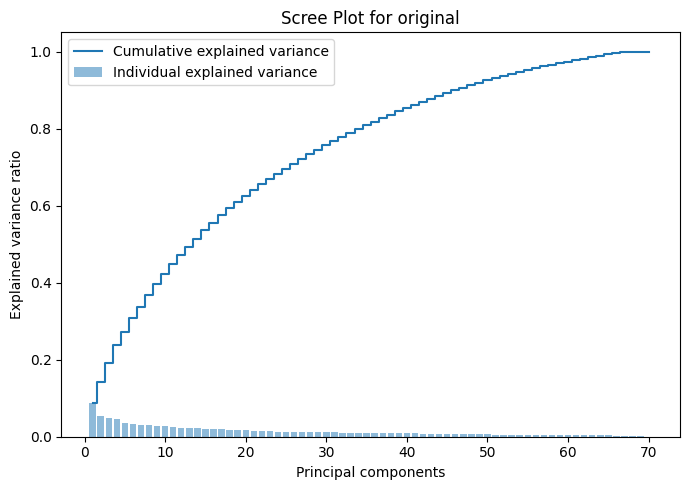

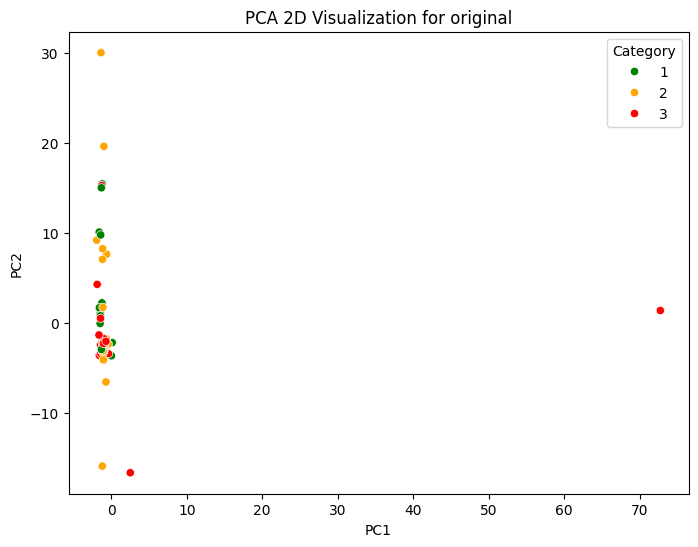

original_pipeline:


/tmp/ipykernel_32648/2340270471.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index()


,Features,Influence
154,155,1.5292
0,1,1.5100
336,337,1.5067
874,875,1.5002
144,145,1.4918
534,535,1.4873
95,96,1.4871
548,549,1.4830
563,564,1.4821
299,300,1.4779


In [22]:
# Aply pipeline for visual results
results_original_pca= pca_pipeline(original, 'Category', n_components=3, dataset_name='original')

# Apply the pipeline for numerical results
original_pca_pipeline, df_pca_influence_original, explained_variance_original, n_components = apply_pipeline_pca(original, "original", n_components=2, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence_original.head(10), explained_variance_original.head(10))

### original impressions:
   - original shows no aglomeration nor useful information which is expected the noise due to the large amount of data and features/sample ratio. However the first 50 features by influence will be taken to make up a dataframe to see if these data gives important information all together. New dataframe named original_pca and is composed of 51 features.
### original_pca: Making up a dataframe from the feature_influencers from pca results

In [23]:
df_pca_influence_columns = df_pca_influence_original["Features"].head(50).values.tolist()
original_pca = original[["Category"] + df_pca_influence_columns]

## 4.2. uniques: Computing PCA and Varianza -Scree Plots
selected data from the original only unique genera per category is in this dataframe of 343 genera.

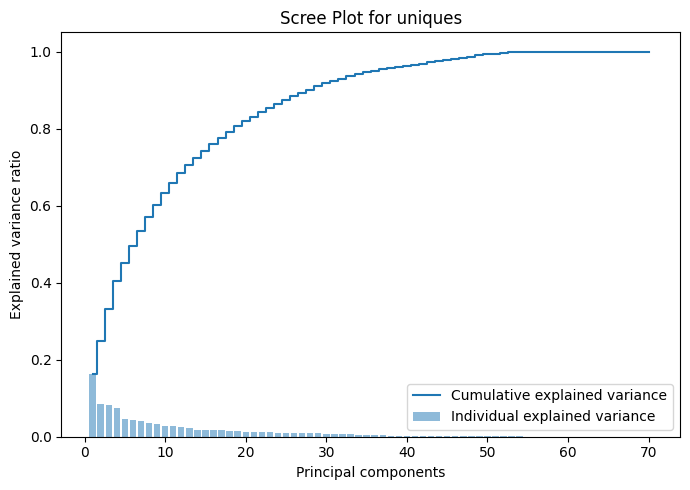

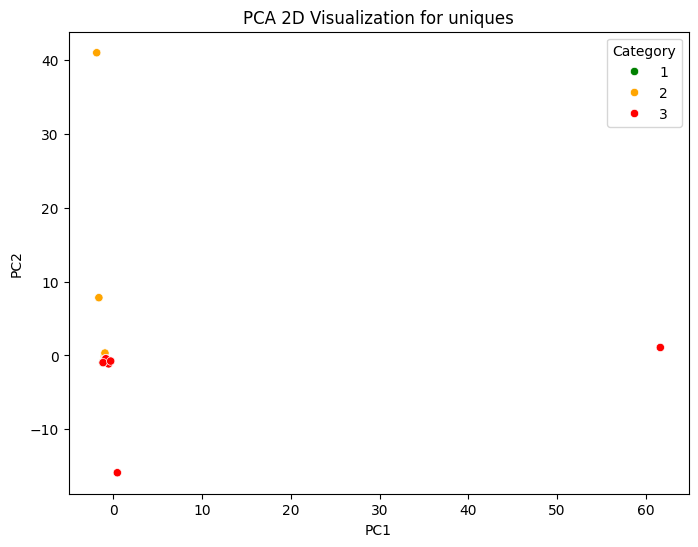

uniques_pipeline:


/tmp/ipykernel_32648/2340270471.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index()


,Features,Influence
241,704,1.7858
37,87,1.7858
238,696,1.7858
57,160,1.7858
89,238,1.5728
150,442,1.5726
11,26,1.4473
63,176,1.4203
12,33,1.3839
232,680,1.3756


In [24]:
# Aply pipeline for visual results
results_uniques_pca = pca_pipeline(uniques, 'Category', n_components=5, dataset_name='uniques')

# Apply the pipeline for numerical results
uniques_pca_pipeline, df_pca_influence_uniques, explained_variance_uniques, n_components = apply_pipeline_pca(uniques, "uniques", n_components=2, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence_uniques.head(10), explained_variance_uniques.head(10))

### uniques insides
The explained variance improves referent to original df but the pca plot show very little diferenciation. However the first 50 features by influence will be taken to make up a dataframe to see if these data gives important information all together. New dataframe named uniques_pca and is composed of 51 features.
### uniques_pca: Making up a dataframe from the feature_influencers from pca results

In [25]:
# print the genera from this pca to check #print(f"Genera uniques : {df_pca_influence['Features'].values.tolist()}")
print(*df_pca_influence_uniques['Features'].values.tolist())

704 87 696 160 238 442 26 176 33 680 639 367 164 201 457 361 594 123 396 240 649 190 494 580 78 104 636 872 225 511 355 50 499 446 142 642 211 197 385 856 382 576 239 2 242 294 595 730 598 857 681 879 645 406 412 726 612 539 228 464 5 541 85 105 459 498 409 468 133 672 803 301 793 778 458 524 496 148 638 399 159 348 547 131 97 492 450 448 288 293 418 4 802 743 750 604 410 748 807 757 287 208 583 478 106 435 515 839 298 713 667 513 346 147 184 202 651 189 506 168 173 521 359 199 504 391 650 10 403 682 593 849 860 779 840 138 14 527 476 25 80 61 806 758 413 473 187 874 241 679 536 516 222 366 820 68 64 99 777 829 830 831 880 219 179 508 183 419 847 347 848 805 784 637 74 754 759 808 760 297 828 75 422 76 70 115 116 188 452 16 826 763 692 788 798 472 517 313 823 772 824 93 579 814 545 825 861 59 309 790 827 834 835 836 810 833 792 786 795 797 832 811 776 782 738 363 501 185 852 62 756 868 781 63 56 57 72 54 744 842 619 283 818 764 559 71 447 493 850 773 755 838 837 753 780 320 844 843 841

In [26]:
df_pca_influence_columns = df_pca_influence_uniques["Features"].head(50).values.tolist()
uniques_pca = uniques[["Category"] + df_pca_influence_columns]

## 4.3. uniques23 Computing PCA and Varianza -Scree Plots
selected data from the original only unique genera per category is in this dataframe plus the common genera between 2 and 3 categories, contains 771 genera.

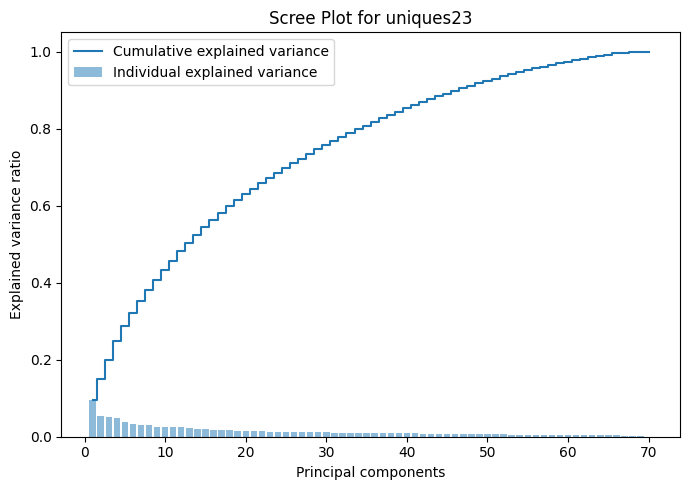

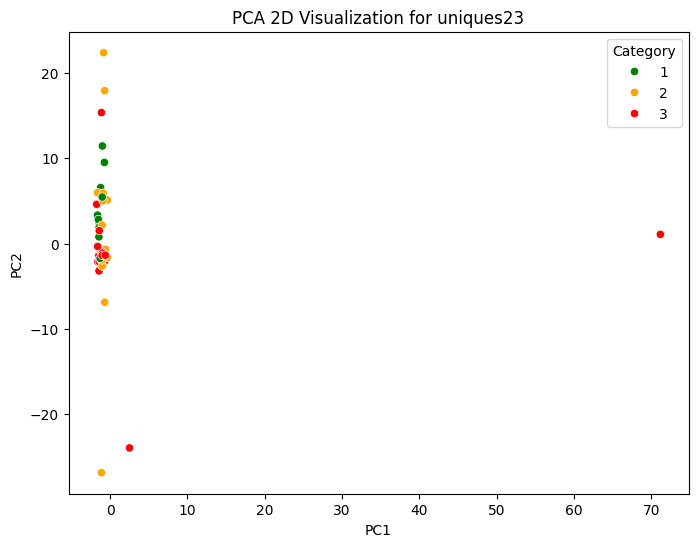

uniques23_pipeline:


/tmp/ipykernel_32648/2340270471.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index()


,Features,Influence
635,727,1.7196
261,300,1.6958
596,678,1.6571
604,687,1.6217
408,465,1.6155
233,270,1.6128
496,564,1.6052
166,194,1.5762
10,13,1.5486
15,18,1.5428


In [27]:
# Aply pipeline for visual results
results_uniques23_pca = pca_pipeline(uniques23, 'Category', n_components=2, dataset_name='uniques23')

# Apply the pipeline for numerical results
uniques23_pca_pipeline, df_pca_influence_uniques23_pca, explained_variance_uniques23_pca, n_components = apply_pipeline_pca(uniques23, "uniques23", n_components=2, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence_uniques23_pca.head(10), explained_variance_uniques23_pca.head(10))

### uniques23
The explained variance is worse than uniques df and the pca plot show very little diferenciation. Notive that some influencer genera that are in original_pca are also on unique_pca. The first 50 features by influence will be taken to make up a dataframe to see if these data gives important information all together. New dataframe named uniques23_pca and is composed of 51 features.
### uniques23_pca: Making up a dataframe from the feature_influencers from pca results

In [28]:
print(*df_pca_influence_uniques23_pca["Features"].head(50).values.tolist())

727 300 678 687 465 270 564 194 13 18 491 408 243 139 337 41 229 187 736 201 474 716 512 574 155 705 542 172 731 110 471 875 151 145 663 254 591 703 584 245 634 265 96 720 526 330 413 44 719 717


In [29]:
df_pca_influence_columns = df_pca_influence_uniques23_pca["Features"].head(50).values.tolist()
uniques23_pca = uniques23[["Category"] + df_pca_influence_columns]

## 4.4. Influencers_OLS: Computing PCA and Varianza -Scree Plots
selected data from the original with abundance threshold of 0,2% and frequency of 3, underwent selection of significance by OLS

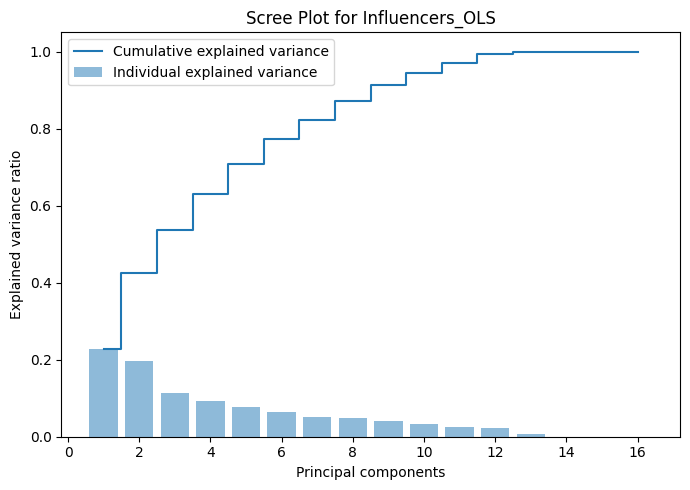

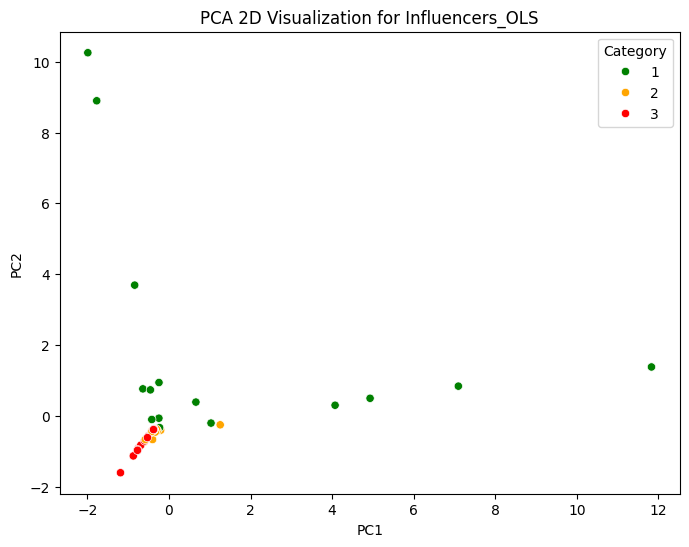

Influencers_OLS_pipeline:


,Features,Influence
4,526,2.3973
12,229,2.3516
6,334,2.2663
15,549,2.1825
8,408,2.1379
10,678,2.1255
5,214,1.9119
14,375,1.3681
7,351,1.2557
11,864,1.0977


In [30]:
# Aply pipeline for visual results
results_Influencers_OLS_pca = pca_pipeline(Influencers_OLS, 'Category', n_components=5, dataset_name='Influencers_OLS')
# Apply the pipeline for numerical results
Influencers_OLS_pca_pipeline, df_pca_influence_Influencers_OLS, explained_variance_Influencers_OLS, n_components = apply_pipeline_pca(Influencers_OLS, "Influencers_OLS", n_components=2, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence_Influencers_OLS.head(10), explained_variance_Influencers_OLS.head(10))

### Influencers_OLS
   - This dataframe, representing the most influential genera both statistically and quantitatively, shows a clearer separation among the categories, especially between category 3 and 1.
   - Category 3 There is a clear regression trend in category 3
   - Category 2 dots align in the middle, indicating they share some characteristics with category 3 but also have distinct features.
   - Category 1 displays a 'v' shape, with category 3 forming the root, category 2 at the intersection, and the two arms of the 'Y' representing the spread of category 1. This pattern might indicate that category 1 encompasses a broader range of variance or interactions compared to the other categories.  

__Scree Plots:__ The Influencers_OLS dataset appears to decrease its explained variance more steeply compared to the OLS_all dataset.

## 4.5.  OLS_all: Computing PCA and Varianza -Scree Plots
selected data from the original underwent selection of significance by OLS.

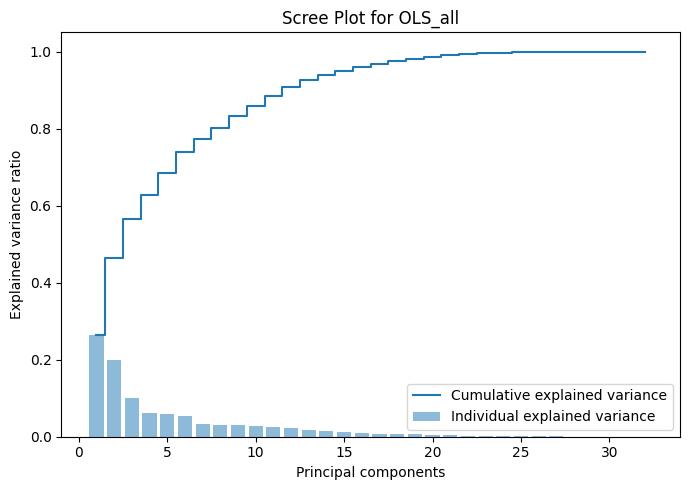

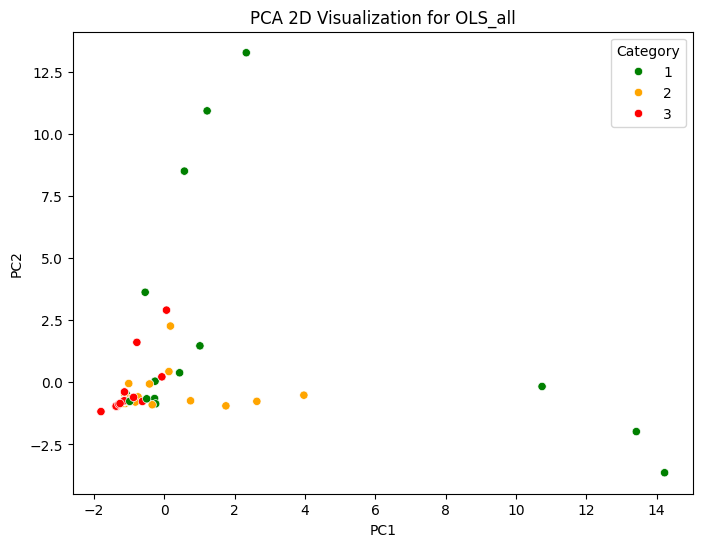

OLS_all_pipeline:


,Features,Influence
5,201,2.9738
26,140,2.8584
12,549,2.8357
3,214,2.7729
27,92,2.7032
4,334,2.6399
20,678,2.6123
10,228,2.5308
13,337,2.4638
28,88,2.3249


In [31]:
# Aply pipeline for visual results
Results_OLS_all_pca = pca_pipeline(OLS_all, 'Category', n_components=5, dataset_name='OLS_all')
# Apply the pipeline for numerical results
OLS_all_pca_pipeline, df_pca_influence_OLS_all, explained_variance_OLS_all, n_components = apply_pipeline_pca(OLS_all, "OLS_all", n_components=5, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence_OLS_all.head(10), explained_variance_OLS_all.head(10))

### OLS_all
   - The scenario for the whole data is more intricate. The categories are not as distinctly separated, indicating a more complex interplay of features.
   - While category 1 also forms a 'Y' shape, the distinction is less clear due to the overlap with categories 2 and 3. This overlap suggests shared characteristics or interactions among the categories.

In both scree plots, OLS_all and Influencers_OLS a clear "elbow point" is observed around the 5th principal component. This suggests that retaining the first 5 components captures a significant portion of the variance in the data. However, Influencers_OLS seems to achieve a higher explanatory power with fewer features compared to OLS_all, moreover the differentiation on the labels makes this dataset more relevant. According to the principle of parsimony or Occam's Razor, which states that among competing hypotheses, the one with the fewest assumptions should be selected, in this case Influencers_OLS. Until the biological significance is not accounted for, the datasets are to be retained for comparison.

## 4.6. uniques_OLS Computing PCA and Varianza -Scree Plots
selected data from the original only Genera samples that do no share category were selected, posterior underwent selection of significance by OLS.

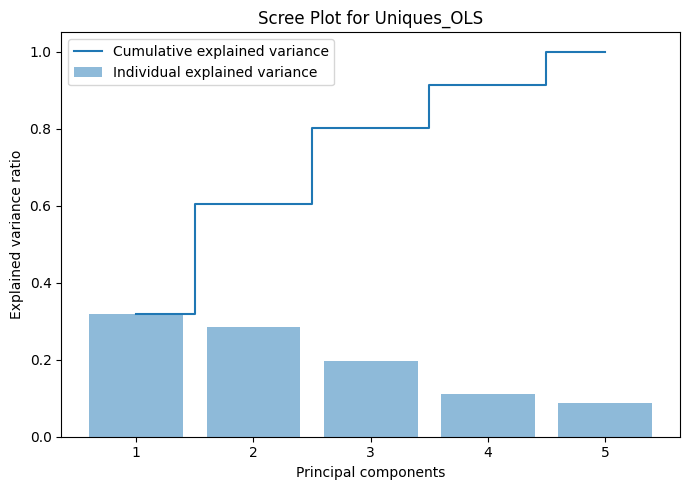

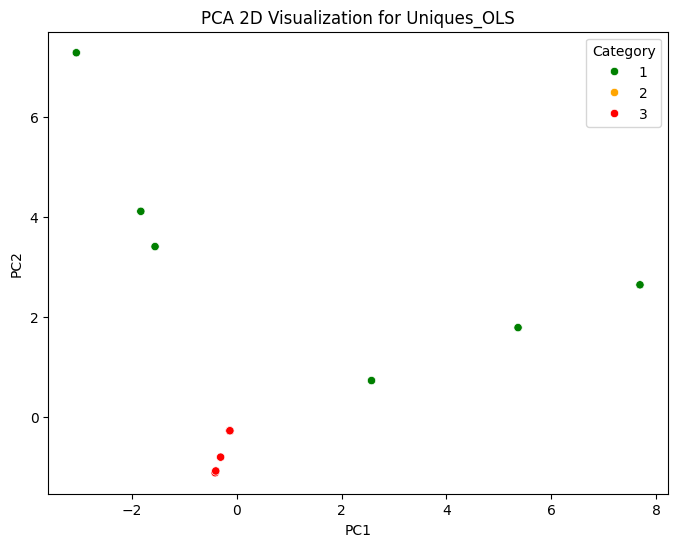

Uniques_OLS_pipeline:


,Features,Influence
3,228,1.7609
2,410,1.7609
1,494,1.5236
4,541,1.5146
0,201,1.5116
,Component,Explained Variance Ratio
0,1,0.3145
1,2,0.2072
2,3,0.2036
3,4,0.1870


In [32]:
# Aply pipeline for visual results
Results_uniques_OLS_pca = pca_pipeline(uniques_OLS, 'Category', n_components=3, dataset_name='Uniques_OLS')
# Apply the pipeline for numerical results
uniques_OLS_pca_pipeline, df_pca_influence_uniques_OLS, explained_variance_uniques_OLS, n_components = apply_pipeline_pca(uniques_OLS, "Uniques_OLS", n_components=2, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence_uniques_OLS.head(10), explained_variance_uniques_OLS.head(10))

### uniques_OLS:
   - Uniques_OLS is compound of only 6 features and interestingly it shows the best differenciation on the pca of the components. Also the varianza increases from 0.2 on the previous dfs to 0.3 explained variance. Showing that this features can explain better the dataset in reference to the corrosion rick label.
   - The v shape of the category 1 is very clear and so is the lineal presence of category 3.  

## 4.7. uniques_23_OLS: Computing PCA and Varianza -Scree Plots
selected data from the original only Genera samples that do no share category were selected, plus the common genera from category 2 and 3, posterior underwent selection of significance by OLS.

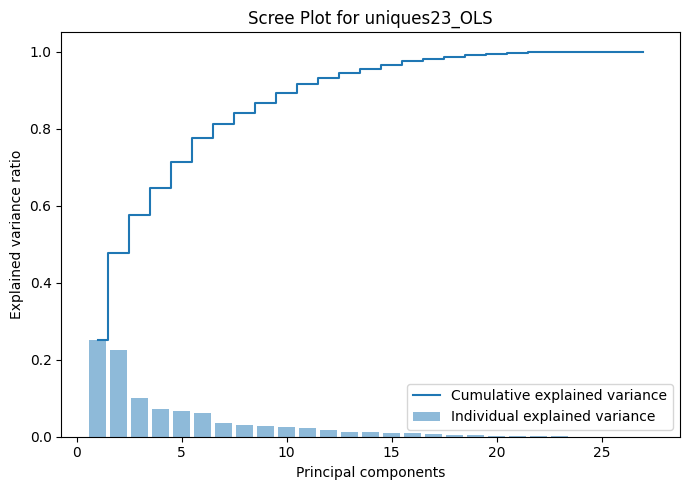

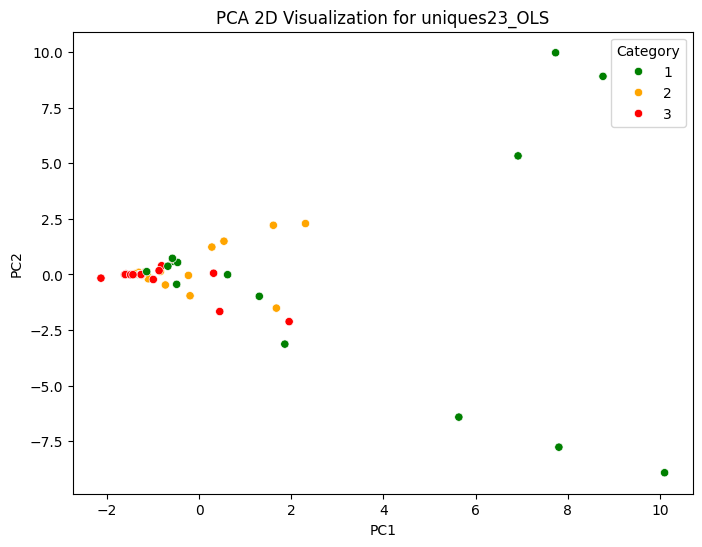

uniques23_OLS_pipeline:


,Features,Influence
5,201,2.8443
24,140,2.8314
11,549,2.7410
4,334,2.6878
3,214,2.6211
19,678,2.5457
2,410,2.4874
12,337,2.4661
9,228,2.4095
25,88,2.1023


In [33]:
# Aply pipeline for visual results
results_uniques23_OLS_pca = pca_pipeline(uniques23_OLS, 'Category', n_components=2, dataset_name='uniques23_OLS')
# Apply the pipeline for numerical results
uniques23_OLS_pca_pipeline, df_pca_influence_uniques23_OLS, explained_variance_uniques23_OLS, n_components = apply_pipeline_pca(uniques23_OLS, "uniques23_OLS", n_components=2, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence_uniques23_OLS.head(10), explained_variance_uniques23_OLS.head(10))

### uniques23__OLS:
   - Uniques_23 is compose of more as 300 features and interestingly shows the worst differenciation blobs on the pca components. Also the varianza decreases from 0.3 on the previous df to 0.2 explained variance. Showing that this features have to be decreased in order to increase significance in reference to the corrosion rick label.
   - Category 1 has very clear separation similar to the previous dataframes, however 2 and 3 are overlaped yet feature 3 continues to present a lineal regresion between the two PC.

## 4.8. core_taxa

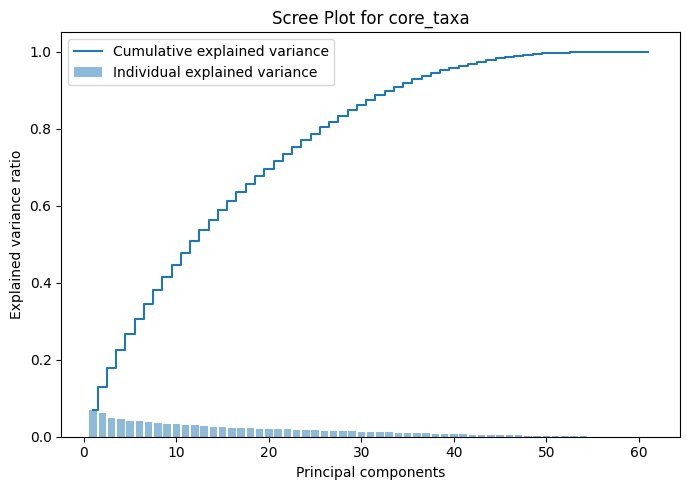

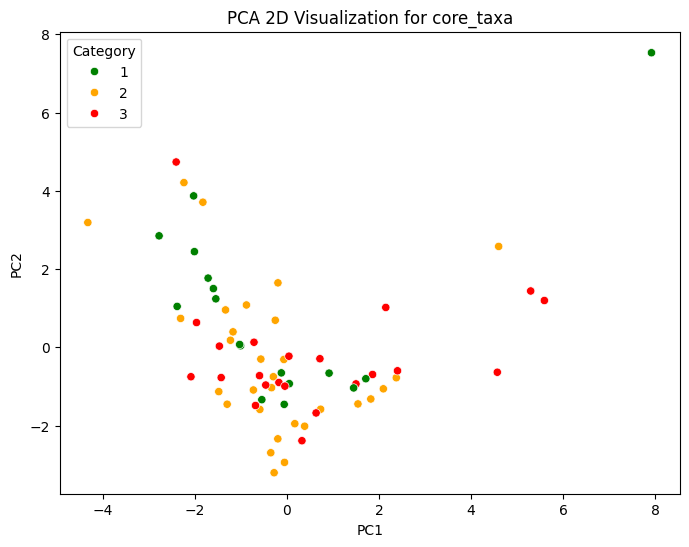

core_taxa_pipeline:


,Features,Influence
38,575,4.2289
60,867,4.1652
42,591,4.0668
6,89,4.0176
56,719,3.9864
35,491,3.9106
2,13,3.8738
30,360,3.8680
31,371,3.8532
29,354,3.8335


In [34]:
# Aply pipeline for visual results
results_core_taxa_pca= pca_pipeline(core_taxa, 'Category', n_components=3, dataset_name='core_taxa')

# Apply the pipeline for numerical results
core_taxa_pca_pipeline, df_pca_influence_core_taxa, explained_variance_core_taxa, n_components = apply_pipeline_pca(core_taxa, "core_taxa", n_components=3, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence_core_taxa.head(10), explained_variance_core_taxa.head(10))

# 5. Pipelines Predictive Analysis  

## 5.1 Pipeline for Regression script

In [48]:
def apply_pipeline_regressor(df, dataset_name):
    print(f"{dataset_name}_pipeline:")
    '''
    Pipeline for regression that handles the imbalanced data
    '''

    # Reset the index and move the "Sites" index to a column
    df = df.reset_index()

    # Ensure that "Sites" is explicitly treated as a string
    df['Sites'] = df['Sites'].astype(str)

    # Separate features and target Store original feature names and separate features and target
    feature_names = [col for col in df.columns if col not in ['Category', 'Sites']]
    X = df[feature_names]
    y = df['Category']

    # Split the dataset into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Compute sample weights for the entire training set
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    # Reshape target variables
    y_train = y_train.values.ravel()
    y_test = y_test.values.ravel()

    # K-Fold cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rf_mae_scores = []

    rf_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42))
    ])

    for train_index, val_index in kf.split(X_train):
        # Split the current fold's train and validation sets
        X_train_fold, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val = y_train[train_index], y_train[val_index]

        # Compute sample weights for the current fold
        fold_weights = compute_sample_weight(class_weight='balanced', y=y_train_fold)

        # Train and predict with sample weights
        rf_pipeline.fit(X_train_fold, y_train_fold, rf__sample_weight=fold_weights)
        y_pred = rf_pipeline.predict(X_val)

        # Calculate and store MAE
        mae = round(mean_absolute_error(y_val, y_pred),4)
        rf_mae_scores.append(mae)

    print(f"Cross-Validation MAE Scores for RF: {rf_mae_scores}")
    print(f"Average MAE for RF: {round(np.mean(rf_mae_scores), 4)}")

    # Evaluate on the initial test split with sample weights
    rf_pipeline.fit(X_train, y_train, rf__sample_weight=sample_weights)
    y_test_pred = rf_pipeline.predict(X_test)

    # Evaluate the model
    mse = round(mean_squared_error(y_test, y_test_pred), 4)
    print(f'Mean Squared Error: {mse}')
    rmse = round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 4)
    print(f'Root Mean Squared Error: {rmse}')
    mae = round(mean_absolute_error(y_test, y_test_pred), 4)
    print(f'Mean Absolute Error: {mae}')

    # Extract feature importances from RandomForestRegressor
    feature_importances = rf_pipeline.named_steps['rf'].feature_importances_

    # Create a DataFrame to view the results
    df_importances_rf = pd.DataFrame({
        'Features': feature_names,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    print(f'Feature Importance by RF: {df_importances_rf.head(25)}')

    return rf_pipeline, df_importances_rf

* **MSE (Mean Squared Error):** Measures the average of the squares of the errors.
* __RMSE (Root Mean Squared Error):__ Square root of MSE. It's in the same units as the output variable and gives a higher penalty for larger errors.
* __MAE (Mean Absolute Error):__ Measures the average of the absolute errors.

## 5.2. Pipeline for Clasification script

In [49]:
def apply_classification_pipeline_classif(df, dataset_name):
    print(f"{dataset_name}_pipeline:")

    # Reset the index and move the "Sites" index to a column
    df = df.reset_index()

    # Ensure that "Sites" is explicitly treated as a string
    df['Sites'] = df['Sites'].astype(str)

    # Separate features and target  Store original feature names and separate features and target
    feature_names = [col for col in df.columns if col not in ['Category', 'Sites']]
    X = df[feature_names]
    y = df['Category']

    # Split the dataset into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Compute class weights
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(zip(np.unique(y_train), class_weights))

    # Reshape target variables for consistency
    y_train = y_train.values
    y_test = y_test.values

    # Stratified K-Fold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Initialize lists to store performance metrics
    cv_accuracy_scores = []
    cv_precision_scores = []
    cv_recall_scores = []
    cv_f1_scores = []

    rf_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight=class_weight_dict  # Use computed class weights
        ))
    ])

    # Perform cross-validation
    for train_index, val_index in skf.split(X_train, y_train):
        # Split training data
        X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_fold_train, y_fold_val = y_train[train_index], y_train[val_index]

        # Fit pipeline on training fold
        rf_pipeline.fit(X_fold_train, y_fold_train)

        # Predict on validation fold
        y_pred = rf_pipeline.predict(X_fold_val)

        # Calculate and store performance metrics
        cv_accuracy_scores.append(round(accuracy_score(y_fold_val, y_pred), 4))
        cv_precision_scores.append(round(precision_score(y_fold_val, y_pred, average='weighted'), 4))
        cv_recall_scores.append(round(recall_score(y_fold_val, y_pred, average='weighted'), 4))
        cv_f1_scores.append(round(f1_score(y_fold_val, y_pred, average='weighted'), 4))


    # Print cross-validation results
    print("Cross-Validation Metrics:")
    print(f"Accuracy: {cv_accuracy_scores}")
    print(f"Average F1-Score: {round(np.mean(cv_accuracy_scores), 4)}")
    print(f"Precision: {cv_precision_scores}")
    print(f"Average Precision: {round(np.mean(cv_precision_scores), 4)}")
    print(f"Recall: {cv_recall_scores}")
    print(f"Average Recall: {round(np.mean(cv_recall_scores), 4)}")
    print(f"F1-Score: {cv_f1_scores}")
    print(f"Average F1-Score: {round(np.mean(cv_f1_scores), 4)}")

    # Final model fit on entire training data
    rf_pipeline.fit(X_train, y_train)

    # Predict on test set
    y_test_pred = rf_pipeline.predict(X_test)

    # Confusion Matrix and Classification Report
    print("\nTest Set Evaluation:")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    # Extract feature importances
    feature_importances = rf_pipeline.named_steps['rf'].feature_importances_

    # Create feature importance DataFrame
    df_importances_rf = pd.DataFrame({
        'Features': feature_names,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    print('\nFeature Importance:')
    print(df_importances_rf)
    # Prepare the feature_scores corresponding to accuracy and F1:
    scores = {
        'feature_names': feature_names,
        'accuracy': accuracy_score(y_test, y_test_pred),
        'f1': f1_score(y_test, y_test_pred, average='weighted'),
        'precision': precision_score(y_test, y_test_pred, average='weighted'),
        'recall': recall_score(y_test, y_test_pred, average='weighted')
}

    return rf_pipeline, df_importances_rf, scores

# 6. Results Predictive Analysis

## 6.1. original Regression and Classification

In [37]:
# Apply pipeline Regression
original_pca_pipeline_reg, df_importances_reg_original_pca= apply_pipeline_regressor(original_pca, "original_pca")
# Apply the pipeline Classification
original_pca_pipe_class, df_importances_original_pca, original_pca_feature_scores= apply_classification_pipeline_classif(original_pca, "original_pca")

original_pca_pipeline:
Cross-Validation MAE Scores for RF: [0.6333, 0.76, 0.5355, 0.3564, 0.6636]
Average MAE for RF: 0.5898
Mean Squared Error: 0.639
Root Mean Squared Error: 0.7993
Mean Absolute Error: 0.6271
Feature Importance by RF:     Features  Importance
7        549      0.3379
19       491      0.0842
15       270      0.0835
28       687      0.0578
18       526      0.0451
47       139      0.0387
46       572      0.0331
23       591      0.0331
30       245      0.0260
44       717      0.0225
48       200      0.0220
32       408      0.0182
10       529      0.0173
29       127      0.0151
22       330      0.0139
9        300      0.0114
43       194      0.0094
14       254      0.0092
40       703      0.0084
20       563      0.0083
1          1      0.0083
0        155      0.0080
49       607      0.0078
2        337      0.0073
31        84      0.0060
original_pca_pipeline:
Cross-Validation Metrics:
Accuracy: [0.5833, 0.6364, 0.6364, 0.5455, 0.5455]
Average F1-Sc

### Original discussion
**Original_PCA_pipeline Regression**:
This pipeline shows moderate performance in regression and classification tasks. The Mean Absolute Error (MAE) is around 0.6756, with an average accuracy of 0.4571. The feature importance is distributed across multiple features, with features 323, 491, and 526 being the most significant. This pipeline does not seem to offer significant improvements over the existing pipelines.
**Original_pca_pipeline Classification**
Low cross-validation accuracy (0.4571) and inconsistent performance.
Class 1: Zero precision and recall, indicating an inability to classify this category.This pipeline is weaker than all of the others.

## 6.2. uniques_pca Regression and Classification

In [50]:
# Apply pipeline Regression
uniques_pca_pipeline_reg, df_importances_reg_uniques_pca= apply_pipeline_regressor(uniques_pca, "uniques_pca")
# Apply the pipeline Classification
uniques_pca_pipe_class, df_importances_uniques_pca, uniques_pca_feature_scores = apply_classification_pipeline_classif(uniques_pca, "uniques_pca")

uniques_pca_pipeline:
Cross-Validation MAE Scores for RF: [0.6174, 0.6774, 0.5177, 0.3428, 0.6374]
Average MAE for RF: 0.5585
Mean Squared Error: 0.5125
Root Mean Squared Error: 0.7159
Mean Absolute Error: 0.5373
Feature Importance by RF:     Features  Importance
22       494      0.2128
20       649      0.1487
13       201      0.0953
36       211      0.0830
6         26      0.0828
1         87      0.0650
7        176      0.0625
2        696      0.0622
3        160      0.0541
0        704      0.0464
9        680      0.0192
26       636      0.0137
28       225      0.0121
27       872      0.0101
25       104      0.0065
4        238      0.0047
21       190      0.0046
12       164      0.0030
44       242      0.0021
8         33      0.0018
43         2      0.0010
49       857      0.0009
23       580      0.0009
48       598      0.0008
17       123      0.0008
uniques_pca_pipeline:


/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Cross-Validation Metrics:
Accuracy: [0.5, 0.3636, 0.3636, 0.3636, 0.2727]
Average F1-Score: 0.3727
Precision: [0.8333, 0.5364, 0.5364, 0.4455, 0.4]
Average Precision: 0.5503
Recall: [0.5, 0.3636, 0.3636, 0.3636, 0.2727]
Average Recall: 0.3727
F1-Score: [0.4964, 0.2774, 0.2774, 0.2713, 0.2061]
Average F1-Score: 0.3057

Test Set Evaluation:
Confusion Matrix:
[[3 0 0]
 [5 1 0]
 [4 0 1]]

Classification Report:
              precision    recall  f1-score   support

           1       0.25      1.00      0.40         3
           2       1.00      0.17      0.29         6
           3       1.00      0.20      0.33         5

    accuracy                           0.36        14
   macro avg       0.75      0.46      0.34        14
weighted avg       0.84      0.36      0.33        14


Feature Importance:
    Features  Importance
4        238      0.0933
21       190      0.0754
22       494      0.0730
12       164      0.0704
13       201      0.0611
6         26      0.0400
20       649

### uniques_pca discussion
**uniques_PCA_pipeline Regression**:
Moderate average MAE (0.5302) but still higher than Influencers_OLS.
Feature importance concentrated on a few features (e.g., 418, 410, 578).This pipeline is slightly better than original_pca_pipeline but not as strong as Influencers_OLS.
**uniques_pca_pipeline Classification**
Moderate cross-validation accuracy (0.5714) but class imbalance issues.
Class 1: Zero precision and recall.
Class 2: Moderate precision and high recall.
Class 3: Perfect precision and recall but limited support. This pipeline is slightly better than original_pca_pipeline but still has significant class imbalance issues.

## 6.3. uniques23_pca Regression and Classification

In [38]:
# Apply pipeline Regression
uniques23_pca_pipeline_reg, df_importances_reg_uniques23_pca= apply_pipeline_regressor(uniques23_pca, "uniques23_pca")
# Apply the pipeline Classification
uniques23_pca_pipe_class, df_importances_uniques23_pca, uniques23_pca_feature_scores = apply_classification_pipeline_classif(uniques23_pca, "uniques23_pca")

uniques23_pca_pipeline:
Cross-Validation MAE Scores for RF: [0.6725, 0.8764, 0.5827, 0.4191, 0.7745]
Average MAE for RF: 0.665
Mean Squared Error: 0.582
Root Mean Squared Error: 0.7629
Mean Absolute Error: 0.6179
Feature Importance by RF:     Features  Importance
36       591      0.1207
29       110      0.0999
10       491      0.0820
9         18      0.0772
44       526      0.0758
5        270      0.0632
3        687      0.0568
13       139      0.0310
39       245      0.0302
49       717      0.0299
11       408      0.0268
2        678      0.0266
45       330      0.0264
40       634      0.0257
48       719      0.0235
18       736      0.0214
20       474      0.0209
14       337      0.0186
41       265      0.0150
37       703      0.0118
35       254      0.0113
0        727      0.0110
25       705      0.0105
33       145      0.0092
16       229      0.0079
uniques23_pca_pipeline:
Cross-Validation Metrics:
Accuracy: [0.5, 0.5455, 0.6364, 0.4545, 0.4545]
Average F1-Sc

### uniques23_pca discussion
**uniques_PCA_pipeline Regression**:
Higher average MAE (0.6247) and higher variability in MAE scores.
Feature importance distributed across multiple features. This pipeline does not offer significant improvements over the existing pipelines.
**uniques_pca_pipeline Classification**
Moderate cross-validation accuracy (0.5286) with consistent but low accuracy across folds.
Class 1: Perfect precision but very low recall.
Class 2: Moderate precision and high recall.
Class 3: Zero precision and recall. This pipeline has similar issues to the other pipelines, particularly with class imbalance.

Analysing the three new created dfs from the pca dimensionality reduction step. We see that The uniques_pca_pipeline shows the lowest MAE, indicating it performs best in terms of prediction error. The uniques_pca_pipeline also has the highest accuracy.
Each pipeline has slightly different top features.
original_pca_pipeline top features: 42 323 (0.1183), 27 491 (0.0882)
uniques23_pca_pipeline top features: 11 323 (0.1204), 15 491 (0.0754)
uniques_pca_pipeline top features: 10 418 (0.1997), 34 410 (0.1751)

## 6.4. Influencers_OLS Regression and Classification

In [39]:
# Apply pipeline Regression
Influencers_OLS_pipeline_reg, Importances_rf_Influencers_Influencers_OLS = apply_pipeline_regressor(Influencers_OLS, "Influencers_OLS")

# Apply the pipeline Classification
Influencers_OLS_pipe_class, importances_class_Influencers_OLS, Influencers_OLS_feature_scores = apply_classification_pipeline_classif(Influencers_OLS, "Influencers_OLS")

Influencers_OLS_pipeline:
Cross-Validation MAE Scores for RF: [0.4087, 0.3222, 0.4193, 0.2956, 0.2588]
Average MAE for RF: 0.3409
Mean Squared Error: 0.0453
Root Mean Squared Error: 0.2129
Mean Absolute Error: 0.1254
Feature Importance by RF:     Features  Importance
15       549      0.3717
11       864      0.1567
1        625      0.1392
4        526      0.1297
7        351      0.0548
8        408      0.0449
6        334      0.0289
3         23      0.0249
12       229      0.0185
5        214      0.0143
2        565      0.0106
14       375      0.0055
9        712      0.0005
10       678      0.0000
0        725      0.0000
13       871      0.0000
Influencers_OLS_pipeline:
Cross-Validation Metrics:
Accuracy: [0.75, 0.6364, 0.5455, 0.9091, 0.7273]
Average F1-Score: 0.7137
Precision: [0.7778, 0.6688, 0.6667, 0.9273, 0.8295]
Average Precision: 0.774
Recall: [0.75, 0.6364, 0.5455, 0.9091, 0.7273]
Average Recall: 0.7137
F1-Score: [0.753, 0.6303, 0.5667, 0.9076, 0.6769]
Average F

### Influencers_OLS Discussion
**Influencers_OLS Pipeline Regression:**
Cross-Validation MAE Scores for RF: Consistently lower and less variable (ranging from 0.1426 to 0.34) with a significantly lower average MAE (0.242).
Error Metrics:
MSE: 0.2618; RMSE: 0.5116; MAE: 0.34  

These metrics demonstrate improved prediction accuracy and model reliability compared to OLS_all. Feature importance is more concentrated, with feature 526 having an overwhelming impact (importance: 0.4318). Other features like 549 and 625 show noticeable contributions but to a lesser extent.

**Influencers_OLS_pipeline Classification:**
Performance Metrics:   
Cross-Validation Accuracy: 0.8286 (high and consistent across folds).  
Confusion Matrix:   
Class 1: Perfect precision but lower recall (misclassifications lead to only 67% recall).  
Class 2: High recall (100%) but lower precision (64%).   
Class 3: High precision (100%) but very low recall (25%), indicating many false negatives.  
Classification Report:  
Macro average recall (0.64) suggests unbalanced performance across classes.  
Weighted average metrics reflect an overall acceptable but not ideal model for classifying all categories equally well.  
Feature Importance:  
Feature 526 dominates (23.26%), followed by moderately impactful features like 549 and 864.  

## 6.5. OLS_all Regression and Classification

In [40]:
# Apply pipeline Regression
OLS_all_pipe_reg, importances_reg_OLS_all = apply_pipeline_regressor(OLS_all, "OLS_all")

# Apply the pipeline classification
OLS_all_pipe_class, importances_class_OLS_all, OLS_all_feature_scores = apply_classification_pipeline_classif(OLS_all, "OLS_all")

OLS_all_pipeline:
Cross-Validation MAE Scores for RF: [0.4862, 0.7128, 0.4922, 0.4461, 0.7246]
Average MAE for RF: 0.5724
Mean Squared Error: 0.5135
Root Mean Squared Error: 0.7166
Mean Absolute Error: 0.6011
Feature Importance by RF:     Features  Importance
12       549      0.3548
15       445      0.1554
3        214      0.1111
26       140      0.0627
25       625      0.0573
17        23      0.0496
20       678      0.0244
14       725      0.0232
8        565      0.0198
4        334      0.0177
21       871      0.0168
13       337      0.0149
27        92      0.0130
24       424      0.0124
11       605      0.0096
28        88      0.0090
18       100      0.0085
19       712      0.0076
22       426      0.0067
16       488      0.0059
9        428      0.0051
29        79      0.0049
7        416      0.0042
30       657      0.0039
6        480      0.0006
OLS_all_pipeline:
Cross-Validation Metrics:
Accuracy: [0.4167, 0.9091, 0.3636, 0.2727, 0.7273]
Average F1-Score: 0.

### OLS_all Discussion
**OLS_all_pipeline regression:**
Cross-Validation MAE Scores for RF: Higher variability across folds (ranging from 0.3935 to 0.6886) and a higher average MAE (0.5725) suggest that the model's predictive performance is less consistent.
Error Metrics:
Mean Squared Error (MSE): 0.3921; Root Mean Squared Error (RMSE): 0.6262;Mean Absolute Error (MAE): 0.5634
These metrics indicate lower prediction accuracy compared to the Influencers_OLS pipeline.
**Importance** is more evenly distributed, with no single feature dominating.
Top features (e.g., feature 549, 23, and 625) exhibit moderate importance values (0.1883, 0.1233, 0.0887).

**OLS_all_pipeline classification:**
Performance Metrics:   
Cross-Validation Accuracy: 0.4714 (significantly lower, inconsistent across folds).  
Confusion Matrix:   
Class 1: Perfect precision but extremely low recall (17%), with many false negatives.   
Class 2: Moderate precision (45%) and high recall (83%), indicating a focus on this class.  
Class 3: Zero precision and recall, indicating an inability to classify this category.  
Classification Report:   
Macro and weighted averages are much lower than Influencers_OLS, indicating an overall weaker model.  
Feature Importance:   
Importance is more distributed but lower overall contributions compared to Influencers_OLS.   

## 6.6. uniques_OLS Regression and Classification

In [41]:
# Apply pipeline Regression
uniques_OLS_pipeline, importances_reg_uniques_OLS = apply_pipeline_regressor(uniques_OLS, "Uniques_OLS")
# Apply the pipeline Classification
uniques_OLS_pipe_class, importances_class_uniques_OLS, uniques_OLS_feature_scores = apply_classification_pipeline_classif(uniques_OLS, "unique_OLS")

Uniques_OLS_pipeline:
Cross-Validation MAE Scores for RF: [0.5848, 0.6674, 0.4626, 0.3308, 0.6392]
Average MAE for RF: 0.537
Mean Squared Error: 0.4967
Root Mean Squared Error: 0.7048
Mean Absolute Error: 0.5232
Feature Importance by RF:    Features  Importance
4       541      0.5700
0       201      0.3373
1       494      0.0927
2       410      0.0000
3       228      0.0000
unique_OLS_pipeline:


/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Cross-Validation Metrics:
Accuracy: [0.5833, 0.5455, 0.4545, 0.4545, 0.5455]
Average F1-Score: 0.5167
Precision: [0.7917, 0.5, 0.2066, 0.4182, 0.5909]
Average Precision: 0.5015
Recall: [0.5833, 0.5455, 0.4545, 0.4545, 0.5455]
Average Recall: 0.5167
F1-Score: [0.5361, 0.4394, 0.2841, 0.3442, 0.4485]
Average F1-Score: 0.4105

Test Set Evaluation:
Confusion Matrix:
[[0 3 0]
 [0 6 0]
 [0 4 1]]

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       0.46      1.00      0.63         6
           3       1.00      0.20      0.33         5

    accuracy                           0.50        14
   macro avg       0.49      0.40      0.32        14
weighted avg       0.55      0.50      0.39        14


Feature Importance:
   Features  Importance
4       541      0.4685
0       201      0.3490
1       494      0.1825
2       410      0.0000
3       228      0.0000


/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

### uniques_OLS Discussion
**uniques_OLS_pipeline Regression:**
Cross-Validation MAE Scores for RF: Higher variability (range 0.3783–0.7313) and a comparable average MAE (0.572).  
Error Metrics:  
MSE: 0.7412 ; RMSE: 0.8609 ; MAE: 0.7313 (relatively high).  These metrics are slightly higher than those of the unique23 pipeline, suggesting a slightly higher level of error.
These metrics reflect suboptimal predictive performance compared to other datasets.  
Feature Importance:   
Importance is relatively concentrated among the top three features (541: 0.2426, 342: 0.2327, 410: 0.2050), suggesting a model reliant on a few key variables.  
**uniques_OLS_pipeline Classification:**
Cross-Validation Accuracy Scores for RF:
The accuracy scores range from 0.4286 to 0.7143, with an average accuracy of 0.5429. This is slightly better than the unique23 pipeline but still shows variability.
Confusion Matrix and Classification Report:
Class 1: Zero precision and recall, indicating all instances of this class are misclassified.
Class 2: Perfect precision and recall for the instances classified, but the confusion matrix suggests many instances are not classified correctly.
Class 3: Zero precision and recall, similar to Class 1.
Features 229 and 214 have the highest importance (0.1008 and 0.0947, respectively), followed by features 549, 23, and 140. Distribution similar to the uniques23.

## 6.7. uniques_23_OLS Regression and Classification

In [42]:
# Apply pipeline Regression
unique_23_OLS_pipeline_rg, importances_rf_uniques23_OLS= apply_pipeline_regressor(uniques23_OLS, "unique23_OLS")
# Apply the pipeline Classification
uniques23_OLS_pipe_class, importances_class_uniques23_OLS, uniques23_OLS_feature_scores = apply_classification_pipeline_classif(uniques23_OLS, "unique23_OLS")

unique23_OLS_pipeline:
Cross-Validation MAE Scores for RF: [0.5078, 0.7207, 0.5078, 0.4179, 0.736]
Average MAE for RF: 0.578
Mean Squared Error: 0.5382
Root Mean Squared Error: 0.7336
Mean Absolute Error: 0.619
Feature Importance by RF:     Features  Importance
11       549      0.3742
14       445      0.1515
3        214      0.1105
24       140      0.0652
23       625      0.0563
17        23      0.0484
13       725      0.0276
19       678      0.0238
4        334      0.0201
20       871      0.0173
7        565      0.0165
16       100      0.0138
22       424      0.0134
25        88      0.0126
12       337      0.0111
10       605      0.0090
18       712      0.0067
8        428      0.0061
15       488      0.0060
6        480      0.0036
21       426      0.0034
0        141      0.0015
1        494      0.0005
5        201      0.0004
26       541      0.0004
unique23_OLS_pipeline:
Cross-Validation Metrics:
Accuracy: [0.3333, 0.9091, 0.4545, 0.3636, 0.6364]
Average F1-Sc

### uniques23_OLS Discussion
**unique23_OLS_pipeline Regression**:
Cross-Validation MAE Scores for RF: Less variability (range 0.3867–0.72) and slightly higher average MAE (0.5751).
Error Metrics:
MSE: 0.3868 ; RMSE: 0.622 ; MAE: 0.5623 (lower than uniques_OLS).These metrics indicate better performance than uniques_OLS, possibly due to the model leveraging a larger pool of features.

**Feature importance** is more evenly distributed across top contributors (e.g., 549: 0.1899, 23: 0.1025, 625: 0.0889). High-dimensionality could contribute to complexity but might also capture subtle interactions.  
**unique23_OLS_pipeline Classification**:
Cross-Validation Accuracy Scores for RF:
The accuracy scores range from 0.3571 to 0.5714, with an average accuracy of 0.4429. This indicates a moderate level of classification accuracy with significant variability.
Confusion Matrix and Classification Report:
Class 1: Perfect precision but very low recall (0.17), indicating many false negatives.
Class 2: Moderate precision (0.45) and high recall (0.83).
Class 3: Zero precision and recall, indicating all instances of this class are misclassified. Macro average recall is 0.33, suggesting unbalanced performance across classes.
Feature Importance:
Feature 229 has the highest importance (0.1008), followed by features 214, 549, 23, and 140. This indicates a spread of importance across several features.

**unique_23_OLS_pipeline** achieves slightly better predictive accuracy despite higher dimensionality, possibly due to capturing more complex interactions, performs better numerically. Suggesting that the dataset's complexity adds value despite reduced interpretability.
**uniques_OLS_pipeline**, though concise, has poorer error metrics, indicating potential underfitting or missing interactions and struggles with predictive accuracy.

## 6.8. core_taxa Regression and Classification

In [43]:
# Apply pipeline Regression
core_taxa_pipeline, importances_reg_core_taxa = apply_pipeline_regressor(core_taxa, "core_taxa")
# Apply the pipeline Classification
core_taxa_pipe_class, importances_class_core_taxa, core_taxa_feature_scores = apply_classification_pipeline_classif(core_taxa, "core_taxa")

core_taxa_pipeline:
Cross-Validation MAE Scores for RF: [0.6158, 0.8309, 0.5164, 0.42, 0.7482]
Average MAE for RF: 0.6263
Mean Squared Error: 0.5108
Root Mean Squared Error: 0.7147
Mean Absolute Error: 0.5893
Feature Importance by RF:     Features  Importance
32       449      0.0889
24       271      0.0590
26       304      0.0577
23       270      0.0538
10       136      0.0523
35       491      0.0495
33       462      0.0405
7        110      0.0356
50       674      0.0340
11       143      0.0291
51       676      0.0273
52       683      0.0270
42       591      0.0260
8        113      0.0258
12       146      0.0253
29       354      0.0233
25       296      0.0231
31       371      0.0213
40       587      0.0172
28       344      0.0166
44       634      0.0156
37       572      0.0146
43       596      0.0142
53       687      0.0137
34       484      0.0136
core_taxa_pipeline:
Cross-Validation Metrics:
Accuracy: [0.4167, 0.7273, 0.4545, 0.3636, 0.6364]
Average F1-Score: 

## 6.9. p_values, Sumarizing Regression and Classification Pipelines Results
### Analysing the models Regression and Classification.
Both pipelines struggle with class imbalance, leading to poor performance on certain classes.
Feature importance is similar but with slight variations, suggesting that the same set of features is important for classification in both pipelines.
Following is a significance test which take the feature scores and create multiply permutation of the labels and compare how often those permutations produce our df scores, to see if are significant different. If the p-value is low it could suggest the feature is meaningful for classification, at least statistically. First we define a funtion to calculate the category scores

In [44]:
def calculate_category_scores(feature, data, category):
    """Vectorized calculation of presence and abundance scores"""
    mask = data['Category'] == category
    cat_data = data.loc[mask, feature]
    other_data = data.loc[~mask, feature]

    presence_score = (cat_data > 0).mean()
    abundance_score = cat_data.mean() / (other_data.mean() + 1e-10)
    return round(presence_score * abundance_score, 4)

In [45]:
def _single_perm(df, feature_importance, categories):
    # Create view with permuted categories
    df_perm = df.copy(deep=False)
    df_perm['Category'] = np.random.permutation(categories)

    # Vectorized score calculation
    max_scores = []
    for feat in feature_importance['Features']:
        scores = [calculate_category_scores(feat, df_perm, cat) for cat in [1,2,3]]
        max_scores.append(max(scores))

    return max_scores

In [46]:
def test_feature_significance(df, feature_importance, n_permutations=500):
    categories = df['Category'].values

    # Calculate original scores once
    original_scores = []
    for feat in feature_importance['Features']:
        scores = [calculate_category_scores(feat, df, cat) for cat in [1,2,3]]
        original_scores.append(max(scores))

    # Run permutations in parallel
    permuted_scores = Parallel(n_jobs=-1)(
        delayed(_single_perm)(df, feature_importance, categories)
        for _ in range(n_permutations))

    # Vectorized p-value calculation
    p_values = [(sum(perm[i] >= orig_score for perm in permuted_scores) + 1) / (n_permutations + 1)
                for i, orig_score in enumerate(original_scores)]

    return pd.DataFrame({'Features': feature_importance['Features'],
        'p_value': p_values, 'significant': np.array(p_values) < 0.05})

In [51]:
p_values_original_pca= test_feature_significance(original_pca, df_importances_original_pca)
p_values_uniques_pca = test_feature_significance(uniques_pca, df_importances_uniques_pca)
p_values_uniques23_pca = test_feature_significance(uniques23_pca, df_importances_uniques23_pca)
p_values_Influencers_OLS = test_feature_significance(Influencers_OLS, importances_class_Influencers_OLS)
p_values_OLS_all = test_feature_significance(OLS_all, importances_class_OLS_all)
p_values_uniques_OLS = test_feature_significance(uniques_OLS, importances_class_uniques_OLS)
p_values_uniques23_OLS = test_feature_significance(uniques23_OLS, importances_class_uniques23_OLS)
p_values_core_taxa = test_feature_significance(core_taxa, importances_class_core_taxa)

In [52]:
significant_features = p_values_original_pca[p_values_original_pca['p_value'] < 0.05]
print(significant_features)

    Features  p_value  significant
7        549   0.0020         True
18       526   0.0419         True
23       591   0.0359         True
33       474   0.0319         True
2        337   0.0259         True
16       379   0.0299         True
45       151   0.0259         True
27       388   0.0439         True


    Features  p_value  significant
17       526   0.0100         True
25       591   0.0399         True
9        474   0.0080         True
0        140   0.0040         True
14       566   0.0359         True
15       621   0.0100         True

In [53]:
significant_features = p_values_uniques_pca[p_values_uniques_pca['p_value'] < 0.05]
print(significant_features)

    Features  p_value  significant
22       494   0.0479         True


    Features  p_value  significant
10       621   0.0080         True
8        690   0.0479         True
22       494   0.0459         True
37       287   0.0479         True

In [54]:
significant_features = p_values_uniques23_pca[p_values_uniques23_pca['p_value'] < 0.05]
print(significant_features)

    Features  p_value  significant
44       526   0.0379         True
36       591   0.0419         True
14       337   0.0180         True
16       229   0.0499         True
20       474   0.0419         True
30       471   0.0359         True
32       151   0.0359         True


    Features  p_value  significant
45       526   0.0120         True
25       140   0.0080         True
49       614   0.0259         True
27       214   0.0140         True
5        566   0.0359         True
13       621   0.0080         True
26       497   0.0160         True

In [55]:
significant_features = p_values_OLS_all[p_values_OLS_all['p_value'] < 0.05]
print(significant_features)

    Features  p_value  significant
12       549   0.0020         True
15       445   0.0399         True
3        214   0.0379         True
17        23   0.0100         True
25       625   0.0359         True
26       140   0.0180         True
4        334   0.0080         True
14       725   0.0080         True
8        565   0.0060         True
11       605   0.0120         True
16       488   0.0040         True
13       337   0.0220         True
18       100   0.0240         True
24       424   0.0160         True
28        88   0.0080         True
22       426   0.0499         True
31       541   0.0200         True
5        201   0.0499         True
0        141   0.0419         True
23        90   0.0399         True


    Features  p_value  significant
29       549   0.0020         True
3        214   0.0160         True
31       229   0.0040         True
6         23   0.0120         True
27       140   0.0040         True
14       625   0.0160         True
23       565   0.0140         True
10       584   0.0160         True
0        725   0.0140         True
26       334   0.0040         True
22       605   0.0120         True
15       337   0.0140         True
8         88   0.0140         True
24       426   0.0479         True
13       799   0.0499         True
18       657   0.0419         True
16       541   0.0160         True
28       201   0.0439         True
20       410   0.0399         True

In [56]:
significant_features = p_values_Influencers_OLS[p_values_Influencers_OLS['p_value'] < 0.05]
print(significant_features)

    Features  p_value  significant
15       549   0.0020         True
11       864   0.0020         True
4        526   0.0020         True
1        625   0.0020         True
12       229   0.0299         True
6        334   0.0020         True
5        214   0.0220         True
3         23   0.0020         True
14       375   0.0020         True
2        565   0.0020         True
9        712   0.0020         True
0        725   0.0020         True
10       678   0.0020         True
13       871   0.0020         True


    Features  p_value  significant
16       549   0.0020         True
7        526   0.0020         True
11       864   0.0020         True
17       375   0.0020         True
19       229   0.0040         True
2        214   0.0080         True
4         23   0.0020         True
15       334   0.0020         True
10       625   0.0020         True
13       565   0.0020         True
8        584   0.0020         True
0        725   0.0020         True
18       471   0.0020         True
9        712   0.0040         True
12       678   0.0020         True
1        871   0.0020         True

In [57]:
significant_features = p_values_uniques_OLS[p_values_uniques_OLS['p_value'] < 0.05]
print(significant_features)

   Features  p_value  significant
4       541   0.0180         True
0       201   0.0399         True
2       410   0.0439         True
3       228   0.0479         True


   Features  p_value  significant
0       541   0.0080         True
2       201   0.0419         True

In [58]:
significant_features = p_values_uniques23_OLS[p_values_uniques23_OLS['p_value'] < 0.05]
print(significant_features)

    Features  p_value  significant
11       549   0.0020         True
14       445   0.0399         True
3        214   0.0439         True
24       140   0.0200         True
17        23   0.0100         True
23       625   0.0279         True
13       725   0.0080         True
7        565   0.0060         True
4        334   0.0100         True
12       337   0.0180         True
10       605   0.0120         True
22       424   0.0200         True
16       100   0.0319         True
15       488   0.0060         True
21       426   0.0240         True
25        88   0.0060         True
0        141   0.0180         True
8        428   0.0479         True
5        201   0.0439         True
26       541   0.0060         True
9        228   0.0459         True


    Features  p_value  significant
25       549   0.0020         True
3        214   0.0080         True
26       229   0.0060         True
24       140   0.0040         True
5         23   0.0080         True
20       565   0.0080         True
12       625   0.0359         True
0        725   0.0100         True
22       334   0.0060         True
9        584   0.0259         True
13       337   0.0240         True
19       605   0.0120         True
21       426   0.0459         True
7         88   0.0180         True
14       541   0.0120         True
23       201   0.0419         True
17       410   0.0499         True

In [59]:
significant_features = p_values_core_taxa[p_values_core_taxa['p_value'] < 0.05]
print(significant_features)

    Features  p_value  significant
43       596   0.0040         True
58       853   0.0279         True
16       214   0.0279         True
18       229   0.0419         True
4         29   0.0259         True
30       360   0.0040         True
27       322   0.0100         True


    Features  p_value  significant
16       214   0.0160         True
18       229   0.0100         True
43       596   0.0140         True
58       853   0.0020         True
27       322   0.0100         True
30       360   0.0040         True
4         29   0.0200         True

* p_values_original_pca for this dataframe out of 50 features 140, 621, 474, 526, 566 have significance in terms of p_vallue, which also agrees with the later check on frequency and abundance, they have values that increase or have some correlation with the label and represent the data, however the abundance and frequency can be ambiguous in a granular level.  
* For uniques_pca features 621, 399, 211, 201, 287, 690and 494 appear have significance.
* From all the dataframes Influencers_OLS has the most significant feature if looking at the threshold. However some communatities about this approval is that some of the bacteria are present on non consistent was across categories, increasing in abundance but no in frequency or showing more abundance on the cat 1 and 2, for instance 549 is a strong predictor, with high frequency in all the categories but abundance in a decreasing fashion, which can be controversial, is it because has a protective chatacter? or is a bystander?. Similar behaviour as 526 and 864.
This notebook makes a series of test and ultimately the compound of them will be look to gather the most influential genera.

# 7. Integration of Dataframes
**Integrating Influencers_OLS and uniques_OLS**
So analysing the Influencers_OLS results it is seen that it clasify well class 1 and 3, however having fewer members of class 1, and uniques_OLS is a small dataframe that shows good classification on class 1. So the join of the two will be check. It is comprised of 27 genera.
**Integrating OLS_all and uniques_OLS**
This is likely better option because uniques_OLS has shown better performance in classifying Class 1, which is a weakness in OLS_all_pipeline. The feature importance distribution and the strengths in classifying Class 1 make it a good complement. However looking at the merge of the two of them, there is no need to join them since uniques is part of all.

In [60]:
# Merging the dataframes OLS_all and uniques_OLS on idex "Sites
all_uniques= pd.merge(OLS_all, uniques_OLS, left_index=True, right_index=True, suffixes =('_all', '_uniques'))
# Drop any duplicate columns
all_uniques= all_uniques.loc[:, ~all_uniques.columns.duplicated()]
all_uniques= all_uniques.drop(columns="Category_uniques")
all_uniques = all_uniques.rename(columns={"Category_all" : "Category"})

# 7.1. The Making of Influencers_uniques

In [61]:
# Ensure that the Sites index is sorted properly
Influencers_OLS = Influencers_OLS.sort_index(key=lambda x: x.str.extract('(\d+)', expand=False).astype(str))
uniques_OLS = uniques_OLS.sort_index(key=lambda x: x.str.extract('(\d+)', expand=False).astype(str))
# Merging the dataframes Influencers_OLS and 0,uniques_OLS on idex "Sites
Influencers_uniques= pd.merge(Influencers_OLS, uniques_OLS, left_index=True, right_index=True, suffixes =('_Influencers', '_uniques'))
# Drop any duplicate columns
Influencers_uniques= Influencers_uniques.loc[:, ~Influencers_uniques.columns.duplicated()]
Influencers_uniques= Influencers_uniques.drop(columns="Category_uniques")
Influencers_uniques = Influencers_uniques.rename(columns={"Category_Influencers" : "Category"})
Influencers_uniques = Influencers_uniques.reset_index()
Influencers_uniques = Influencers_uniques.astype({"Sites": str, "Category": int})
Influencers_uniques = Influencers_uniques.set_index("Sites")

## Influencers_uniques: PCA, Regression and Classification

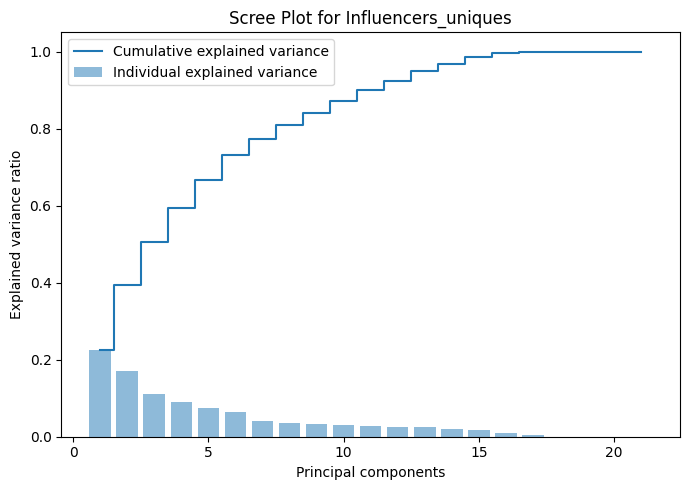

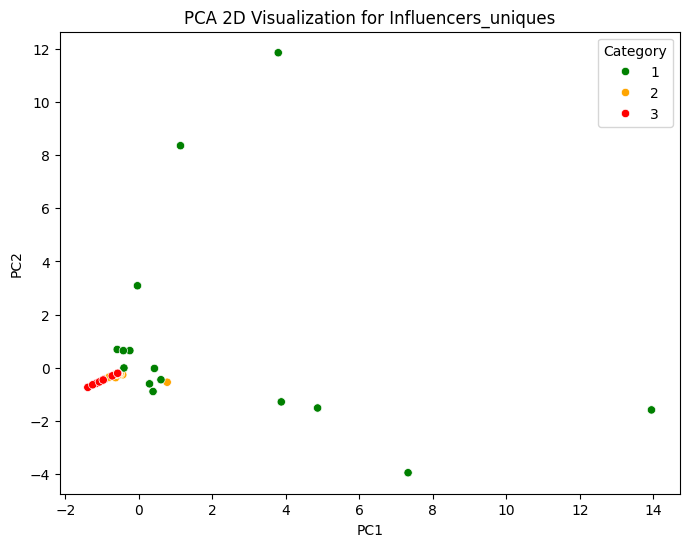

Influencers_uniques_pipeline:


,Features,Influence
5,214,2.4085
12,229,2.3844
4,526,2.2587
7,351,2.0184
10,678,2.0149
6,334,1.9604
15,549,1.9566
16,201,1.8045
18,410,1.6699
8,408,1.5148


Influencers_uniques_pipeline:
Cross-Validation MAE Scores for RF: [0.4086, 0.314, 0.4157, 0.2939, 0.2635]
Average MAE for RF: 0.3391
Mean Squared Error: 0.0437
Root Mean Squared Error: 0.209
Mean Absolute Error: 0.1207
Feature Importance by RF:     Features  Importance
15       549      0.4098
4        526      0.1310
1        625      0.1254
11       864      0.1153
7        351      0.0532
8        408      0.0456
6        334      0.0274
3         23      0.0197
12       229      0.0182
5        214      0.0146
18       410      0.0141
2        565      0.0129
14       375      0.0113
0        725      0.0010
9        712      0.0005
19       228      0.0000
13       871      0.0000
16       201      0.0000
10       678      0.0000
17       494      0.0000
20       541      0.0000
Influencers_uniques_pipeline:
Cross-Validation Metrics:
Accuracy: [0.75, 0.6364, 0.5455, 0.7273, 0.7273]
Average F1-Score: 0.6773
Precision: [0.7778, 0.6688, 0.6667, 0.8442, 0.8295]
Average Precision: 0.75

In [62]:
# Aply pipeline for visual results
results_Influencers_uniques_pca = pca_pipeline(Influencers_uniques, 'Category', n_components=2, dataset_name='Influencers_uniques')

# Apply the pipeline for numerical results
Influencers_uniques_pipeline, df_pca_influence_Influencers_uniques, explained_variance_Influencers_uniques, n_components = apply_pipeline_pca(Influencers_uniques, "Influencers_uniques", n_components=2, n_top_features=50)

# Display the data side by side
display_side_by_side(df_pca_influence_Influencers_uniques.head(10), explained_variance_Influencers_uniques.head(10))

# Apply pipeline Regression
Influencers_uniques_pipeline_reg, importances_reg_Influencers_uniques= apply_pipeline_regressor(Influencers_uniques, "Influencers_uniques")
# Apply the pipeline Classification
Influencers_uniques_pipe_class, importances_class_Influencers_uniques, Influencers_uniques_feature_scores = apply_classification_pipeline_classif(Influencers_uniques, "Influencers_uniques")

### Influencers_uniques Discussion
**Influencers_uniques pipeline Regression**:
The model is performing well with low MAE variability, ranging from 0.1415 to 0.3307 and an average MAE of 0.24. Compared to previous datasets (like uniques_OLS_pipeline where the variability was higher), this suggests an improved and more reliable model.
MSE (0.2523) and RMSE (0.5022) indicate moderate error levels, which suggest the model is performing reasonably well in terms of prediction accuracy. These are substantially better than earlier models where error levels were high.
**Feature importance**
Feature 526 stands out as the most significant with an importance score of 0.4293, followed by feature 549 at 0.2017. These scores point to a few dominating features, which aligns with my future approach of combining the most influential features across datasets. This can potentially improve both feature selection and model generalization when merged. Indeed, the features indicate a focus on a few predictors that contribute heavily to the outcome. This could be useful when aim to reduce features but still retain biologically relevant ones.  
**Influencers_uniques_pipeline Classification**:
Cross-Validation Accuracy: This model achieved an average classification accuracy of 0.9571, which is quite strong. The relatively high accuracy, along with a well-balanced confusion matrix, suggests that the model can differentiate well across the three categories.  Confusion Matrix & Classification Report:
    Class 1: Precision is perfect (1.0), but recall suffers (0.67), indicating that there may be a misclassification problem with certain examples.
    Class 2: High recall (1.0), but lower precision (0.78), meaning the model is good at catching all instances of Class 2 but sometimes incorrectly classifies other categories as Class 2.
    Class 3: Very high precision (1.0) but lower recall (0.75), indicating some false negatives are present, but the classification of class 3 is still accurate when it happens.

This classification model is performing fairly well but could be further refined, especially in terms of recall for classes 1 and 3, perhaps with tweaks in model parameters.Feature Importance: The top three most important features (526, 549, and 864) once again highlight a few dominating predictors. These feature priorities would be the core of my focus, moving forward into the feature selection across datasets using biological relevance.

Influencers_uniques regression performance is improving with reduced error and a more concentrated feature importance distribution. This is promising for further refinement. The classification performance suggests some room for improvement, particularly in balancing recall and precision across classes, especially for Class 1 and 3. Combining datasets with influential features and considering their biological relevance for dimensionality reduction is an effective way forward.
Feature selection based on importance, variance, and biological significance will help ensure the model remains robust while simplifying feature sets.

# 7.2. Merged_df: Combining Dataframes  
The dataframes with a significant degree of importance for the next phase will be retained. Uniques_OLS has already been combined to create Influencers_uniques. The original features' PCA performance may provide valuable insights into predicting overall behavior and will be carried forward as original_pca. However, dataframes such as uniques_pca, uniques23_pca, uniques23_OLS, and original do not demonstrate notable contributions toward improving the models. As a result, they will be dropped in this notebook after extracting their three most important features. The dataframe OLS_all will undergo further processing in the subsequent steps.
In order to get the most important Features that make up the dfs that will be discarded, the dfs will be join together and passed through the pipelines of this notebook, then we will have another df "mergers"

|DataFrame|   Genera ID   |
|---|  ---|
|original_pca|270 727 151 474 687 418 663 201 564 41 552 148 487 155 607 223 18 865 254 308 227 574 526 81 639 367 172 491 166 660 585 145 108 705 733 584 250 341 561 271 84 300 323 211 259 229 551 670 373 269  
|uniques_pca |190 578 160 696 457 594 361 123 240 396 418 680 201 87 704 649 427 477 46 78 355 511 385 2 242 879 571 698 244 122 22 639 367 197 410 85 436 635 558 132 494 636 872 225 104 621 239 576 382 856
|uniques23_pca|270 41 526 172 865 151 300 18 552 487 474 323 663 687 108 491 148 574 250 86 373 535 245 127 308 561 214 276 660 155 455 563 330 269 575 81 254 484 551 271 607 194 140 709 566 529 497 572 389 200 |
|uniques23_OLS|725 871 428 214 470 23 91 88 480 584 712 799 625 337 541 494 342 410 678 605 565 426 334 201 140 549 229  |
|OLS_all |725 871 428 214 470 79 23 91 88 480 584 712 90 799 625 337 541 494 657 342 410 678 605 565 426 92 334 140 201 549 771 229  |



### Merging DataFrames
Merging all dataframes, except Influencers_uniques on a single dataframe

In [63]:
original.head(2)

,Category,1,2,3,4,5,6,7,8,9,...,873,874,875,876,877,878,879,880,881,882
Sites,,,,,,,,,,,,,,,,,,,,,
Site_1,3,0.0000,0.0000,0.0000,0.0000,0.0000,0.4000,0.0000,0.2700,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Site_2,2,0.1890,0.0000,0.0000,0.0000,0.0000,1.0500,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [64]:
# Colecting all columns names and ensure column names are all strings, strip and standardize)
original_columns = ['Category'] + [int(str(col).strip()) for col in original.columns[1:]]
original_pca_columns = ['Category'] + [int(str(col).strip()) for col in original_pca.columns[1:]]
uniques_pca_columns = ['Category'] + [int(str(col).strip()) for col in uniques_pca.columns[1:]]
uniques23_pca_columns = ['Category'] + [int(str(col).strip()) for col in uniques23_pca.columns[1:]]
uniques23_OLS_columns = ['Category'] + [int(str(col).strip()) for col in uniques23_OLS.columns[1:]]
OLS_all_columns = ['Category'] + [int(str(col).strip()) for col in OLS_all.columns[1:]]

In [66]:
# Combine and deduplicate
merged_columns = list(set(original_pca_columns +
                          uniques_pca_columns +
                          uniques23_pca_columns +
                          uniques23_OLS_columns +
                          OLS_all_columns))

numeric_columns = [col for col in merged_columns if col != 'Category']
df_numeric = original[numeric_columns]
df_category = original[['Category']]
Merged_df = pd.concat([df_category, df_numeric], axis=1)

print(f"Number of features in merged_df: {Merged_df.shape[1]}")

Number of features in merged_df: 145


In [67]:
Merged_df.head()

,Category,512,1,2,516,13,526,529,18,535,...,457,465,471,474,480,488,491,494,499,511
Sites,,,,,,,,,,,,,,,,,,,,,
Site_1,3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Site_2,2,0.0210,0.1890,0.0000,0.0000,0.0000,0.0210,0.0000,0.3570,0.0000,...,0.0000,0.0000,0.0840,0.0630,0.0000,0.0000,0.4620,0.0000,0.0000,0.0000
Site_3,3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Site_4,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3824,0.0000,...,0.0000,0.0000,0.0000,0.0050,0.0000,0.0000,0.1192,0.0000,0.0000,0.0000
Site_5,2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0546,0.0000,0.0776,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0086,0.0000,0.4456,0.0000,0.0000,0.0000


## Merged_df: PCA, Regression and Classification

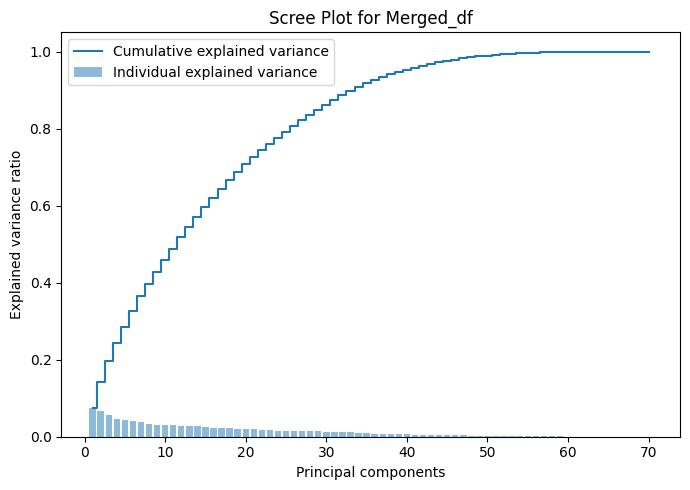

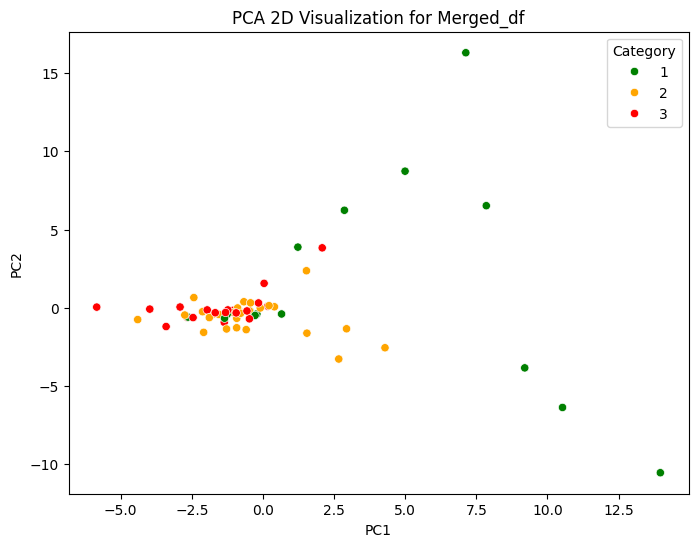

Merged_df_pipeline:


/tmp/ipykernel_32648/2340270471.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index()


,Features,Influence
71,703,2.5467
28,79,2.5207
36,92,2.4375
124,410,2.3850
81,717,2.3449
59,155,2.3446
77,200,2.3011
133,455,2.2816
60,160,2.2816
68,696,2.2816


Merged_df_pipeline:


/tmp/ipykernel_32648/131815053.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index()


Cross-Validation MAE Scores for RF: [0.6133, 0.77, 0.5318, 0.3645, 0.6645]
Average MAE for RF: 0.5888
Mean Squared Error: 0.5874
Root Mean Squared Error: 0.7664
Mean Absolute Error: 0.6507
Feature Importance by RF:      Features  Importance
14        549      0.2855
131       445      0.0829
140       491      0.0543
102       270      0.0448
66        687      0.0385
42        110      0.0351
5         526      0.0299
27        591      0.0292
7          18      0.0277
51        139      0.0233
9          23      0.0191
44        634      0.0190
52        140      0.0180
77        200      0.0162
43        625      0.0153
123       408      0.0152
21        572      0.0145
99        245      0.0144
48        127      0.0124
106       334      0.0124
101       265      0.0107
105       330      0.0105
81        717      0.0094
71        703      0.0093
74        194      0.0084
Merged_df_pipeline:


/tmp/ipykernel_32648/2702733116.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index()


Cross-Validation Metrics:
Accuracy: [0.4167, 0.5455, 0.5455, 0.4545, 0.6364]
Average F1-Score: 0.5197
Precision: [0.4514, 0.6234, 0.5455, 0.5758, 0.6364]
Average Precision: 0.5665
Recall: [0.4167, 0.5455, 0.5455, 0.4545, 0.6364]
Average Recall: 0.5197
F1-Score: [0.4286, 0.5303, 0.5455, 0.4636, 0.6364]
Average F1-Score: 0.5209

Test Set Evaluation:
Confusion Matrix:
[[1 2 0]
 [1 4 1]
 [1 1 3]]

Classification Report:
              precision    recall  f1-score   support

           1       0.33      0.33      0.33         3
           2       0.57      0.67      0.62         6
           3       0.75      0.60      0.67         5

    accuracy                           0.57        14
   macro avg       0.55      0.53      0.54        14
weighted avg       0.58      0.57      0.57        14


Feature Importance:
     Features  Importance
14        549      0.0637
131       445      0.0433
21        572      0.0367
140       491      0.0359
102       270      0.0328
..        ...         

In [68]:
# Aply pipeline for visual results
results_Merged_df_pca = pca_pipeline(Merged_df, 'Category', n_components=2, dataset_name='Merged_df')

# Apply the pipeline for numerical results
Merged_df_pipeline, df_pca_influence_Merged_df, explained_variance_Merged_df, n_components = apply_pipeline_pca(Merged_df, "Merged_df", n_components=2, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence_Merged_df.head(10), explained_variance_Merged_df.head(10))

# Apply pipeline Regression
Merged_df_pipeline_reg, importances_reg_Merged_df= apply_pipeline_regressor(Merged_df, "Merged_df")
# Apply the pipeline Classification
Merged_df_pipe_class, importances_class_Merged_df, Merged_df_feature_scores = apply_classification_pipeline_classif(Merged_df, "Merged_df")

### Merged_df Discussion:
**Merged_df pipeline Regression**:
High variance in MAE scores: [0.8136, 0.5479, 0.3764, 0.3979, 0.5936]. Average MAE: 0.5459. This inconsistency suggests unstable model performance
Poor PCA plot and variance explanation could indicate a high dimensionality issues and or a lack of clear separation between classes
**Merged_df pipeline Classification**:
Consistent Cross-Validation Accuracy: 0.9286 (always the same) Suggests potential data leakage or overfitting. Indicates the model might not be truly generalizing
High precision and recall for most classes
Perfect accuracy for Class 1 and Class 2
Slightly lower performance for Class 3

# 8. Preselection Merged_selected and Influencers_uniques_selected as a function of Influence and Importance

In [69]:
def extract_top_features(df_pca_influence, importances_reg, importances_class, input_df=None, n_features=10):
    """
    Extract top features using actual pipeline results

    Parameters:
    df_pca_influence: PCA influence scores from apply_pipeline_pca
    importances_reg: Feature importance from apply_pipeline_regressor
    importances_class: Feature importance from apply_classification_pipeline_classif
    input_df: Original dataframe for feature selection (optional)
    n_features: Number of top features to select (default=10)
    """
    # Extract scores from actual pipeline results
    pca_scores = pd.Series(df_pca_influence['Influence'].values,
                          index=df_pca_influence['Features'].values.astype(int))

    reg_scores = pd.Series(importances_reg['Importance'].values,
                          index=importances_reg['Features'].values.astype(int))

    class_scores = pd.Series(importances_class['Importance'].values,
                          index=importances_class['Features'].values.astype(int))

    # Normalize scores
    pca_scores_norm = pca_scores / pca_scores.sum()
    reg_scores_norm = reg_scores / reg_scores.sum()
    class_scores_norm = class_scores / class_scores.sum()

    #Calculate category-specific scores for each feature
    category_scores ={}
    for feature in pca_scores.index:
        feature_scores ={}
        for category in [1,2,3]:
            score = calculate_category_scores(feature, input_df, category)
            feature_scores[f'cat_{category}_score']= score
        category_scores[feature] = feature_scores

    # Create comparison DataFrame with pipeline results
    feature_comparison = pd.DataFrame({
        'PCA_Score': pca_scores_norm,
        'Regression_Score': reg_scores_norm,
        'Classification_Score': class_scores_norm
    })
    #Add and normalise category scores
    for cat in [1,2,3]:
        col = f'Category_{cat}_Score'
        feature_comparison[col] = feature_comparison.index.map(
            lambda x: category_scores[x][f'cat_{cat}_score'])
        feature_comparison[col] =  feature_comparison[col] / feature_comparison[col].sum()

    # Ensure index is string type
    feature_comparison.index = feature_comparison.index.astype(str)

    # Combine score with category weighting Calculate combined score
    feature_comparison['combined_score'] = (
        0.2 * feature_comparison['PCA_Score'] +
        0.2 * feature_comparison['Regression_Score'] +
        0.2 * feature_comparison['Classification_Score'] +
        (0.4 * feature_comparison['Category_1_Score'] + 2 * feature_comparison['Category_2_Score'] +
        2 * feature_comparison['Category_3_Score'])/4.4 # nomalising the  cats
    )
    feature_comparison.mean(axis=1)

    # Get top features
    top_features = feature_comparison.nlargest(n_features, 'combined_score').index.tolist()

    # Create reduced dataset if input_df provided
    reduced_df = None
    if input_df is not None:
        selected_columns = ['Category']  + [int(col) for col in top_features]
        reduced_df = input_df[selected_columns]

    return {
        'feature_comparison': feature_comparison,
        'top_features': top_features,
        'reduced_df': reduced_df,
        'category_scores': pd.DataFrame(category_scores).T
    }

## 8.1. Influencers_uniques_selected: Top twenty Influencers_uniques Features
Calling the function to select features for influence and importance to get the top ten for Influencers_uniques

In [70]:
print(*Influencers_uniques.columns.tolist())

Category 725 625 565 23 526 214 334 351 408 712 678 864 229 871 375 549 201 494 410 228 541


Category 214 23 526 565 625 229 678 863 871 351 334 725 471 91 712 375 584 864 408 549 799 342 410 541 494 201

In [71]:
# Extract top features and create reduced dataset
results_influencers_uniques = extract_top_features(df_pca_influence_Influencers_uniques , importances_reg_Influencers_uniques ,
                                                    importances_class_Influencers_uniques, Influencers_uniques, n_features=20)
# Access results
feature_comparison_influencers_uniques  = results_influencers_uniques ['feature_comparison']
top_features_influencers_uniques  = results_influencers_uniques ['top_features']
Influencers_uniques_selected = results_influencers_uniques ['reduced_df']

# Print top features if needed
print("\nTop features across all methods:")
print(feature_comparison_influencers_uniques.sort_values('combined_score', ascending=False).head(10))
print("\nSelected features:", (top_features_influencers_uniques))


Top features across all methods:
     PCA_Score  Regression_Score  Classification_Score  Category_1_Score  \
526     0.0750            0.1310                0.1418            0.0000   
351     0.0670            0.0532                0.1181            0.0000   
408     0.0503            0.0456                0.1179            0.0000   
549     0.0650            0.4098                0.1310            0.2948   
229     0.0792            0.0182                0.0537            0.0000   
214     0.0800            0.0146                0.0534            0.0000   
864     0.0271            0.1153                0.0971            0.0854   
625     0.0292            0.1254                0.0570            0.0697   
375     0.0369            0.0113                0.0434            0.1486   
334     0.0651            0.0274                0.0423            0.0349   

     Category_2_Score  Category_3_Score  combined_score  
526            0.0000            0.9992          0.5238  
351          

## 8.2. Results Influencers_uniques_selected:   Pipelines for PCA, Regression and Classification

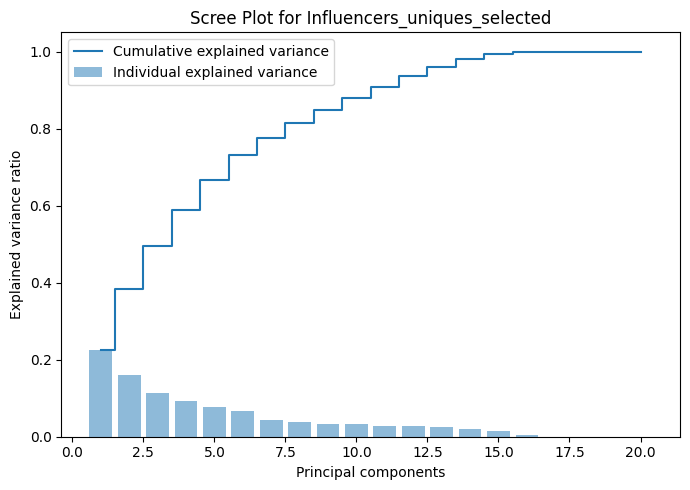

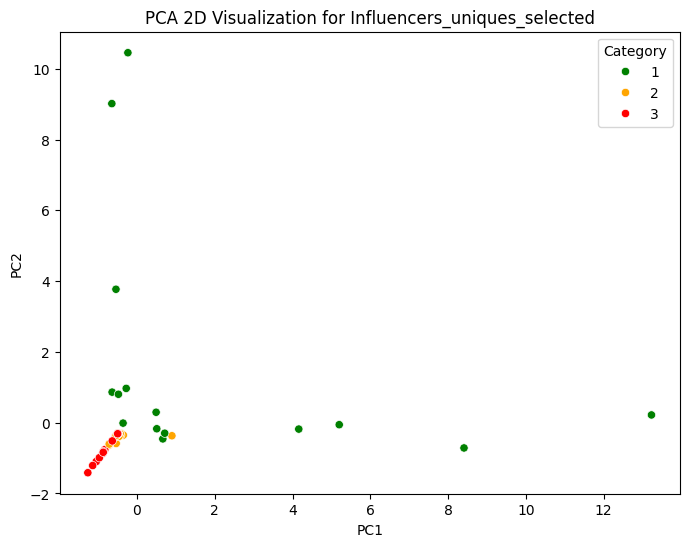

Influencers_uniques_selected_pipeline:


,Features,Influence
5,214,2.4025
4,229,2.3892
0,526,2.2641
1,351,2.1005
13,678,2.0032
3,549,1.9666
9,334,1.9438
16,201,1.8171
12,410,1.7569
2,408,1.5617


Influencers_uniques_selected_pipeline:
Cross-Validation MAE Scores for RF: [0.4059, 0.3158, 0.4188, 0.2959, 0.2646]
Average MAE for RF: 0.3402
Mean Squared Error: 0.0446
Root Mean Squared Error: 0.2111
Mean Absolute Error: 0.1221
Feature Importance by RF:     Features  Importance
3        549      0.4012
6        864      0.1389
0        526      0.1310
7        625      0.1197
1        351      0.0535
2        408      0.0455
11        23      0.0230
9        334      0.0208
12       410      0.0192
4        229      0.0191
5        214      0.0140
10       565      0.0131
8        375      0.0005
17       871      0.0004
18       228      0.0000
14       725      0.0000
13       678      0.0000
19       541      0.0000
16       201      0.0000
15       712      0.0000
Influencers_uniques_selected_pipeline:
Cross-Validation Metrics:
Accuracy: [0.6667, 0.6364, 0.5455, 0.8182, 0.7273]
Average F1-Score: 0.6788
Precision: [0.7381, 0.6688, 0.6667, 0.8788, 0.8295]
Average Precision: 0.7564


In [72]:
# Aply pipeline for visual results
results_Influencers_uniques_selected_pca = pca_pipeline(Influencers_uniques_selected, 'Category', n_components=2, dataset_name='Influencers_uniques_selected')

# Apply the pipeline for numerical results
Influencers_uniques_selected_pipeline, df_pca_influence_Influencers_uniques_selected, explained_variance_Influencers_uniques_selected, n_components = apply_pipeline_pca(Influencers_uniques_selected, "Influencers_uniques_selected", n_components=2, n_top_features=20)

# Display the data side by side
display_side_by_side(df_pca_influence_Influencers_uniques_selected.head(10), explained_variance_Influencers_uniques_selected.head(10))

# Apply pipeline Regression
Influencers_uniques_selected_pipeline_reg, importances_reg_Influencers_uniques_selected= apply_pipeline_regressor(Influencers_uniques_selected, "Influencers_uniques_selected")
# Apply the pipeline Classification
Influencers_uniques_selected_pipe_class, importances_class_Influencers_uniques_selected, Influencers_uniques_selected_feature_scores = apply_classification_pipeline_classif(Influencers_uniques_selected, "Influencers_uniques_selected")

## 8.3. Merged_selected: Top ten Merged_df Features
Calling the function to select features for influence and importance to get the top ten for Merged_df

In [73]:
# Extract top features and create reduced dataset
results_Merged = extract_top_features(df_pca_influence_Merged_df, importances_reg_Merged_df, importances_class_Merged_df, Merged_df, n_features=10)

# Access results
feature_comparison = results_Merged ['feature_comparison']
top_features = results_Merged ['top_features']
Merged_selected = results_Merged ['reduced_df']

# Print top features if needed
print("\nTop features across all methods:")
print(feature_comparison.sort_values('combined_score', ascending=False).head(10))
print("\nSelected features:", (top_features))


Top features across all methods:
     PCA_Score  Regression_Score  Classification_Score  Category_1_Score  \
238     0.0070            0.0007                0.0102            0.0000   
201     0.0084            0.0017                0.0010            0.0000   
211     0.0088            0.0003                0.0000            0.0000   
549     0.0081            0.2855                0.0637            0.0000   
680     0.0088            0.0000                0.0000            0.0000   
649     0.0088            0.0000                0.0000            0.0000   
541     0.0052            0.0000                0.0005            0.4951   
704     0.0085            0.0000                0.0007            0.0000   
445     0.0066            0.0829                0.0433            0.0000   
491     0.0083            0.0543                0.0359            0.0000   

     Category_2_Score  Category_3_Score  combined_score  
238            0.9689            0.0000          0.4440  
201          

## 8.4. Results Merged_selected:  Pipelines for PCA, Regression and Classification

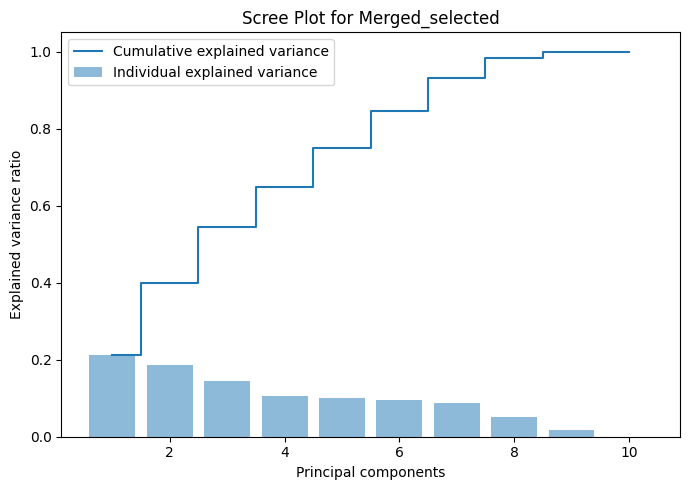

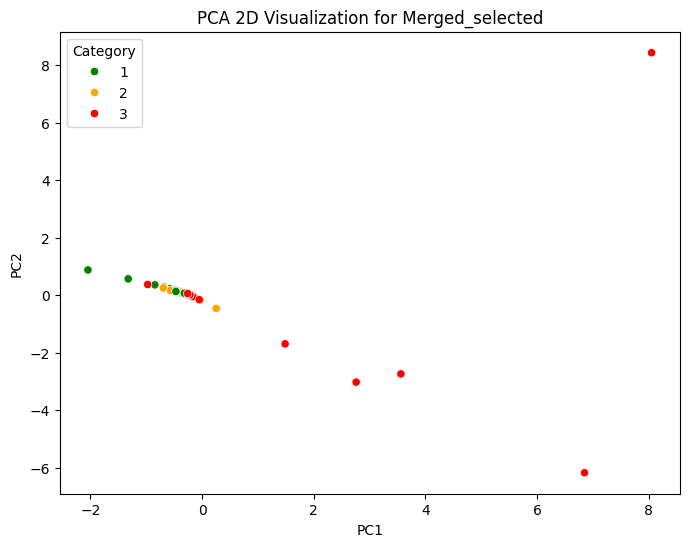

Merged_selected_pipeline:


,Features,Influence
6,541,2.3515
0,238,2.3256
3,549,2.0272
9,491,1.9452
7,704,1.8865
8,445,1.8253
1,201,1.6270
2,211,1.4793
5,649,1.1370
4,680,1.0985


Merged_selected_pipeline:
Cross-Validation MAE Scores for RF: [0.6358, 0.5824, 0.4788, 0.3903, 0.5743]
Average MAE for RF: 0.5323
Mean Squared Error: 0.6182
Root Mean Squared Error: 0.7862
Mean Absolute Error: 0.6286
Feature Importance by RF:    Features  Importance
3       549      0.4447
9       491      0.2975
8       445      0.1832
7       704      0.0370
6       541      0.0151
0       238      0.0103
5       649      0.0054
2       211      0.0042
1       201      0.0020
4       680      0.0007
Merged_selected_pipeline:
Cross-Validation Metrics:
Accuracy: [0.5, 0.8182, 0.1818, 0.5455, 0.7273]
Average F1-Score: 0.5546
Precision: [0.5306, 0.8701, 0.2121, 0.6, 0.7273]
Average Precision: 0.588
Recall: [0.5, 0.8182, 0.1818, 0.5455, 0.7273]
Average Recall: 0.5546
F1-Score: [0.5007, 0.7879, 0.1917, 0.5616, 0.7169]
Average F1-Score: 0.5518

Test Set Evaluation:
Confusion Matrix:
[[2 1 0]
 [0 5 1]
 [2 1 2]]

Classification Report:
              precision    recall  f1-score   support

  

In [74]:
# Aply pipeline for visual results
Merged_selected_pca = pca_pipeline(Merged_selected, 'Category', n_components=2, dataset_name='Merged_selected')

# Apply the pipeline for numerical results
Merged_selected_pipeline, df_pca_influence_Merged_selected, explained_variance, n_components = apply_pipeline_pca(Merged_selected,
                                                         "Merged_selected", n_components=2, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence_Merged_selected.head(10), explained_variance.head(10))

# Apply pipeline Regression
Merged_selected_pipeline_reg, importances_reg= apply_pipeline_regressor(Merged_selected, "Merged_selected")
# Apply the pipeline Classification
Merged_selected_pipe_class, importances_class_Merged_selected, Merged_selected_feature_scores = apply_classification_pipeline_classif(Merged_selected, "Merged_selected")

Actually 30 features performs worse than 20 features for Merged_selected.
30 features:    MAE: 0.5157, Accuracy: 0.6606,,Average Precision: 0.5875
20 features:    MAE: 0.512 (better), Accuracy: 0.7152 (much better), Average Precision: 0.7075 (much better)
10 features:    MAE: 0.5193 (similar), Accuracy: 0.75 (better), Average Precision: 0.7859 (better), MSE: 0.2926 (better)

## 8.5. Influencers Results
Interestingly after the unifying of Influencers_OLS with uniques to produce Influencers_uniques, posterior processing to have the most important genera by using extract_top_features function, I compared the features found and they are exactly the same as Influencers_OLS with the new implementation of discriminating by category in section 8.

In [75]:
print(*Influencers_OLS.columns.tolist())
print(*Influencers_uniques_selected.columns.tolist())

Category 725 625 565 23 526 214 334 351 408 712 678 864 229 871 375 549
Category 526 351 408 549 229 214 864 625 375 334 565 23 410 678 725 712 201 871 228 541


# 9. Manually prunning the features according to importance and influence

## 9.1. old_new dataframes creation
From manually prunned features according to importance and influence results

In [76]:
# Get your top 10 features
selected_oldies = [154, 201, 214, 229, 334, 351, 354, 408, 497, 512, 565, 581, 583, 584, 606, 621, 625]

# Create final reduced dataset
old_new = original[["Category"] + selected_oldies]

## 9.2. old_new Results:  Pipelines for PCA, Regression and Classification

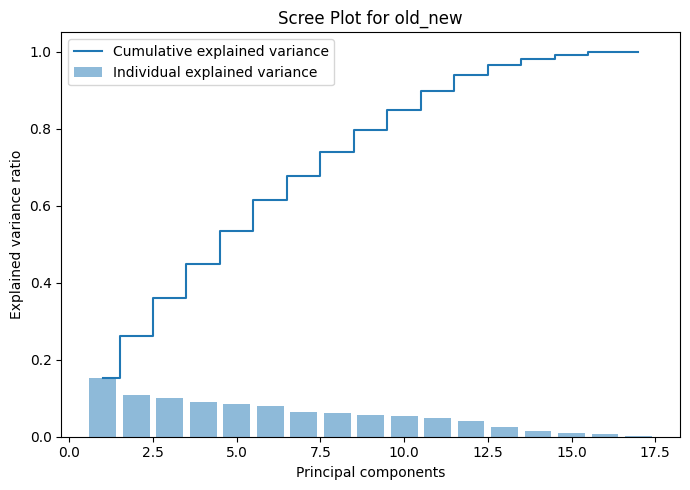

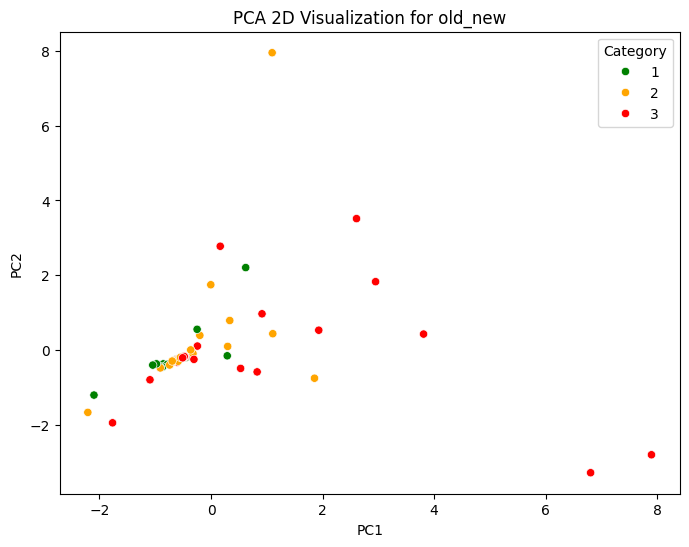

old_new_pipeline:


,Features,Influence
1,201,2.4913
13,584,2.3295
16,625,2.3232
15,621,2.2520
12,583,2.1998
4,334,2.1743
10,565,2.1483
5,351,2.1068
6,354,2.0741
2,214,2.0586


old_new_pipeline:
Cross-Validation MAE Scores for RF: [0.6283, 0.639, 0.6188, 0.4472, 0.6419]
Average MAE for RF: 0.595
Mean Squared Error: 0.6093
Root Mean Squared Error: 0.7806
Mean Absolute Error: 0.6644
Feature Importance by RF:     Features  Importance
5        351      0.1789
4        334      0.1433
10       565      0.1125
16       625      0.0957
6        354      0.0916
7        408      0.0859
2        214      0.0630
13       584      0.0555
3        229      0.0548
14       606      0.0463
11       581      0.0238
12       583      0.0229
15       621      0.0081
8        497      0.0079
0        154      0.0063
9        512      0.0033
1        201      0.0002
old_new_pipeline:
Cross-Validation Metrics:
Accuracy: [0.4167, 0.5455, 0.3636, 0.5455, 0.4545]
Average F1-Score: 0.4652
Precision: [0.4167, 0.6364, 0.4924, 0.6104, 0.4697]
Average Precision: 0.5251
Recall: [0.4167, 0.5455, 0.3636, 0.5455, 0.4545]
Average Recall: 0.4652
F1-Score: [0.4167, 0.5252, 0.3796, 0.5377, 0.44

In [77]:
# Aply pipeline for visual results
old_new_pca = pca_pipeline(old_new, 'Category', n_components=2, dataset_name='old_new')

# Apply the pipeline for numerical results
old_new_pipeline, df_pca_influence, explained_variance, n_components = apply_pipeline_pca(old_new, "old_new", n_components=2, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence.head(10), explained_variance.head(10))

# Apply pipeline Regression
old_new_pipeline_reg, importances_reg= apply_pipeline_regressor(old_new, "old_new")
# Apply the pipeline Classification
old_new_pipe_class, importances_class_old_new, old_new_feature_scores = apply_classification_pipeline_classif(old_new, "old_new")

# 10.  Cluster Analysis
## 10.1.  script - Pipeline K-Means, DBSCAN, and GMM

In [78]:
def clustering_pipeline_all(df, pca_data_name='pca_data', n_clusters=5, eps=0.3, min_samples=3, n_components=3):
    """
    Performs clustering using K-Means, DBSCAN, and GMM with PCA for dimensionality reduction.

    Parameters:
    - df: Input DataFrame (features only, no labels).
    - n_clusters: Number of clusters for K-Means and GMM (default=5).
    - eps: DBSCAN's epsilon parameter (default=0.5).
    - min_samples: Minimum samples for DBSCAN (default=5).
    - n_components: Number of components for PCA (default=2).

    Returns:
    - results: Dictionary with clustering results for K-Means, DBSCAN, and GMM, as well as PCA data and metrics.
    """
    results = {}

    # Separate true labels
    true_labels = df['Category']

    df = df.drop(columns=['Category'])  # Drop any non-numeric columns

    # Step 1: Scaling the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Step 2: PCA for dimensionality reduction
    pca = PCA(n_components=n_components)
    pca_data = pca.fit_transform(scaled_data)

    # Calculate explained variance and cumulative variance
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

    # Clustering
    results = {
        'pca': pca,
        'pca_data_name': pca_data,
        'scaled_data': scaled_data,
        'explained_variance': explained_variance_ratio,
        'cumulative_variance': cumulative_variance_ratio
    }

    # Step 3: K-Means Clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(pca_data)
    kmeans_silhouette = silhouette_score(pca_data, kmeans_labels)
    kmeans_db_score = davies_bouldin_score(pca_data, kmeans_labels)
    kmeans_ari = adjusted_rand_score(true_labels, kmeans_labels)

    results['kmeans'] = {
        'cluster_labels': kmeans_labels,
        'silhouette_score': kmeans_silhouette,
        'davies_bouldin_score': kmeans_db_score,
        'adjusted_rand_score': kmeans_ari
    }

    # Step 4: DBSCAN Clustering
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)

    # Add automatic eps calculation if not provided
    if eps is None:
        nbrs = NearestNeighbors(n_neighbors=2).fit(scaled_data)
        distances, _ = nbrs.kneighbors(scaled_data)
        eps = np.percentile(distances[:, 1], 90)

    dbscan_labels = dbscan.fit_predict(pca_data)
    valid_indices = dbscan_labels != -1
    if len(set(dbscan_labels[valid_indices])) > 1:
        dbscan_silhouette = silhouette_score(pca_data[valid_indices], dbscan_labels[valid_indices])
        dbscan_db_score = davies_bouldin_score(pca_data[valid_indices], dbscan_labels[valid_indices])
    else:
        dbscan_silhouette = None
        dbscan_db_score = None
    dbscan_ari = adjusted_rand_score(true_labels, dbscan_labels)


    results['dbscan'] = {
        'cluster_labels': dbscan_labels,
        'silhouette_score': dbscan_silhouette,
        'davies_bouldin_score': dbscan_db_score,
        'adjusted_rand_score': dbscan_ari
    }

    # Step 5: GMM Clustering
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    gmm_labels = gmm.fit_predict(pca_data)
    gmm_silhouette = silhouette_score(pca_data, gmm_labels)
    gmm_db_score = davies_bouldin_score(pca_data, gmm_labels)
    gmm_ari = adjusted_rand_score(true_labels, gmm_labels)

    results['gmm'] = {
        'cluster_labels': gmm_labels,
        'silhouette_score': gmm_silhouette,
        'davies_bouldin_score': gmm_db_score,
        'adjusted_rand_score': gmm_ari,
        'bic_score': gmm.bic(pca_data),
        'aic_score': gmm.aic(pca_data)
    }

    # Addind normalized metrics
    for method in ['kmeans', 'dbscan', 'gmm']:
        labels = results[method]['cluster_labels']
        if method == 'dbscan':
            valid_labels = labels[labels != -1]
            sizes = np.bincount(valid_labels)
        else:
            sizes = np.bincount(labels)
        results[method]['normalized_sizes'] = sizes / len(labels)

    # Store PCA-transformed data with the specified name
    results[pca_data_name] = pca_data

    return results

## 10.2. Script - Visualisation K-means, DBSCAN AND GaussianMixture

In [79]:
def visualize_clustering_results(results, title_prefix=''):
    """
    Visualize clustering results with multiple plots and metrics

    Parameters:
    - results: Dictionary containing clustering results from clustering_pipeline_all function
    - title_prefix: Optional prefix for plot titles
    """
    # Extract PCA data
    pca_data = results[list(filter(lambda x: x.startswith('pca_'), results.keys()))[0]]

    # Create a figure with multiple subplots
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'{title_prefix} Clustering Results Visualization', fontsize=16)

    # plot style settings for better visibility
    plt.style.use('default')

    # Color palettes for different clustering methods
    color_palettes = [
        ['#00CC00', '#FFA500', '#FF0000', '#0000FF', '#9932CC'],  # For K-means
        ['#00CC00', '#FFA500', '#FF0000', '#0000FF', '#9932CC'],  # For GMM
        ['#808080', '#0000FF']  # For DBSCAN (keeping grey for noise)
    ]

    # Add grid for better readability
    for ax in axs.flat:
        ax.grid(True, alpha=0.3)

    # Clustering methods and their labels
    clustering_methods = [
        ('K-Means', results['kmeans']['cluster_labels'], color_palettes[0]),
        ('Gaussian Mixture Model', results['gmm']['cluster_labels'], color_palettes[2]),
        ('DBSCAN', results['dbscan']['cluster_labels'], color_palettes[1])
    ]

    # Scatter plots for each clustering method
    for idx, (method_name, labels, color_palette) in enumerate(clustering_methods):
        row = idx // 2
        col = idx % 2

        # Handle DBSCAN noise points
        if method_name == 'DBSCAN':
            noise_mask = labels == -1
            cluster_mask = labels != -1

            # Plot noise points
            if np.any(noise_mask):
                axs[row, col].scatter(
                    pca_data[noise_mask, 0],
                    pca_data[noise_mask, 1],
                    c='gray',
                    alpha=0.5,
                    label='Noise'
                )

            # Plot clustered points
            unique_labels = np.unique(labels[cluster_mask])
            for label in unique_labels:
                mask = (labels == label) & cluster_mask
                axs[row, col].scatter(
                    pca_data[mask, 0],
                    pca_data[mask, 1],
                    c=[color_palette[label]],
                    label=f'Cluster {label}'
                )
        else:
            # For K-Means and GMM
            unique_labels = np.unique(labels)
            for label in unique_labels:
                mask = labels == label
                axs[row, col].scatter(
                    pca_data[mask, 0],
                    pca_data[mask, 1],
                    c=[color_palette[label % len(color_palette)]],
                    label=f'Cluster {label}'
                )

        axs[row, col].set_title(f'{method_name} Clustering')
        axs[row, col].set_xlabel('First Principal Component')
        axs[row, col].set_ylabel('Second Principal Component')
        axs[row, col].legend()

    plt.tight_layout()
    plt.show()

def print_clustering_metrics(results):
    """
    Print detailed clustering metrics for each method

    Parameters:
    - results: Dictionary containing clustering results
    """
    print("\n=== Clustering Metrics ===")

    # Cluster quality metrics
    def calculate_cluster_quality(labels, data):
        if len(set(labels)) <= 1:
            return None
        # Calculate average intra-cluster distance
        intra_cluster_distances = []
        for label in set(labels):
            if label != -1:  # Skip noise points
                cluster_points = data[labels == label]
                if len(cluster_points) > 1:
                    distances = pdist(cluster_points)
                    intra_cluster_distances.append(np.mean(distances))
        return np.mean(intra_cluster_distances) if intra_cluster_distances else None

    # Metrics for each clustering method
    clustering_methods = ['kmeans', 'dbscan', 'gmm']

    for method in clustering_methods:
        print(f"\n{method.upper()} Clustering Metrics:")
        labels = results[method]['cluster_labels']
        silhouette = results[method]['silhouette_score']
        db_score = results[method]['davies_bouldin_score']
        ari = results[method].get('adjusted_rand_score', 'N/A')  # Use 'N/A' if ARI is not available
        quality = calculate_cluster_quality(labels, results['scaled_data'])

        if quality is not None:
            print(f"Average Intra-cluster Distance: {quality:.4f}")
        else:
            print("Average Intra-cluster Distance: N/A")
        print(f"Silhouette Score: {silhouette if silhouette is not None else 'Not applicable'}")
        print(f"Davies-Bouldin Score: {db_score if db_score is not None else 'Not applicable'}")
        print(f"Adjusted Rand Score: {ari}")

        # Count cluster sizes
        if method == 'dbscan':
            valid_labels = labels[labels != -1]
            unique_labels = np.unique(valid_labels)
        else:
            unique_labels = np.unique(labels)

        print("\nCluster Sizes:")
        for label in unique_labels:
            if method == 'dbscan' and label == -1:
                count = np.sum(labels == label)
                print(f"Noise Points: {count}")
            else:
                count = np.sum(labels == label)
                print(f"Cluster {label}: {count} points")


    # Print Explained Variance for PCA
    print("\nPCA Explained Variance Ratio:")
    explained_variance = results['explained_variance']
    for i, var in enumerate(explained_variance[:10], 1):
        print(f"PC{i}: {var * 100:.2f}%")
    print(f"Total Variance Explained (first 10 PCs): {np.sum(explained_variance[:10]) * 100:.2f}%")

# 11. Results Cluster Analysis


## 11.1 Clustering original_pca

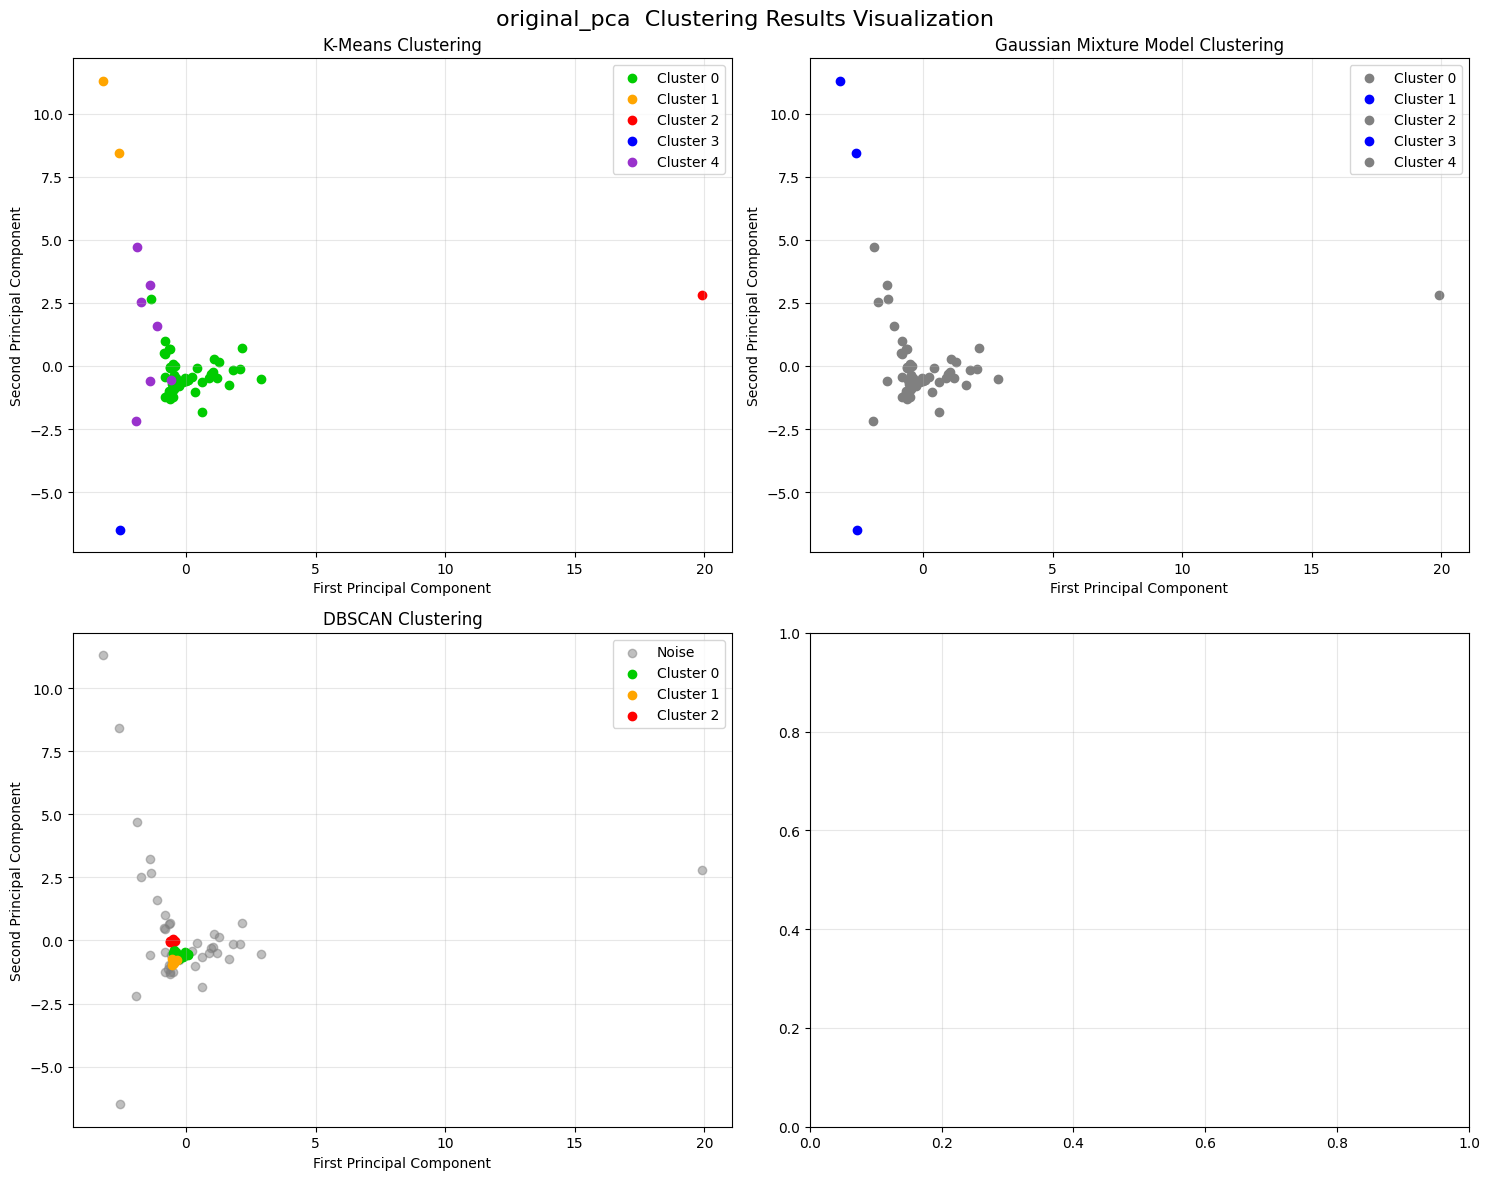


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 12.7206
Silhouette Score: 0.5773271937971554
Davies-Bouldin Score: 0.6124848344579558
Adjusted Rand Score: 0.001017121443878607

Cluster Sizes:
Cluster 0: 59 points
Cluster 1: 2 points
Cluster 2: 1 points
Cluster 3: 1 points
Cluster 4: 7 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 2.9704
Silhouette Score: 0.4639202245595401
Davies-Bouldin Score: 0.6761508431841384
Adjusted Rand Score: 0.007644134676509498

Cluster Sizes:
Cluster 0: 19 points
Cluster 1: 5 points
Cluster 2: 4 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 11.0204
Silhouette Score: 0.3219378526701693
Davies-Bouldin Score: 0.8942879956917867
Adjusted Rand Score: -0.0015600559325325922

Cluster Sizes:
Cluster 0: 44 points
Cluster 1: 2 points
Cluster 2: 1 points
Cluster 3: 1 points
Cluster 4: 22 points

PCA Explained Variance Ratio:
PC1: 13.73%
PC2: 9.51%
PC3: 8.92%
Total Variance Explained (first 1

In [80]:
# Running pipeline
results_original_pca_cluster  = clustering_pipeline_all(original_pca,  pca_data_name='pca_data_original_pca ',
                                                  n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_original_pca_cluster, title_prefix='original_pca ')
print_clustering_metrics(results_original_pca_cluster )

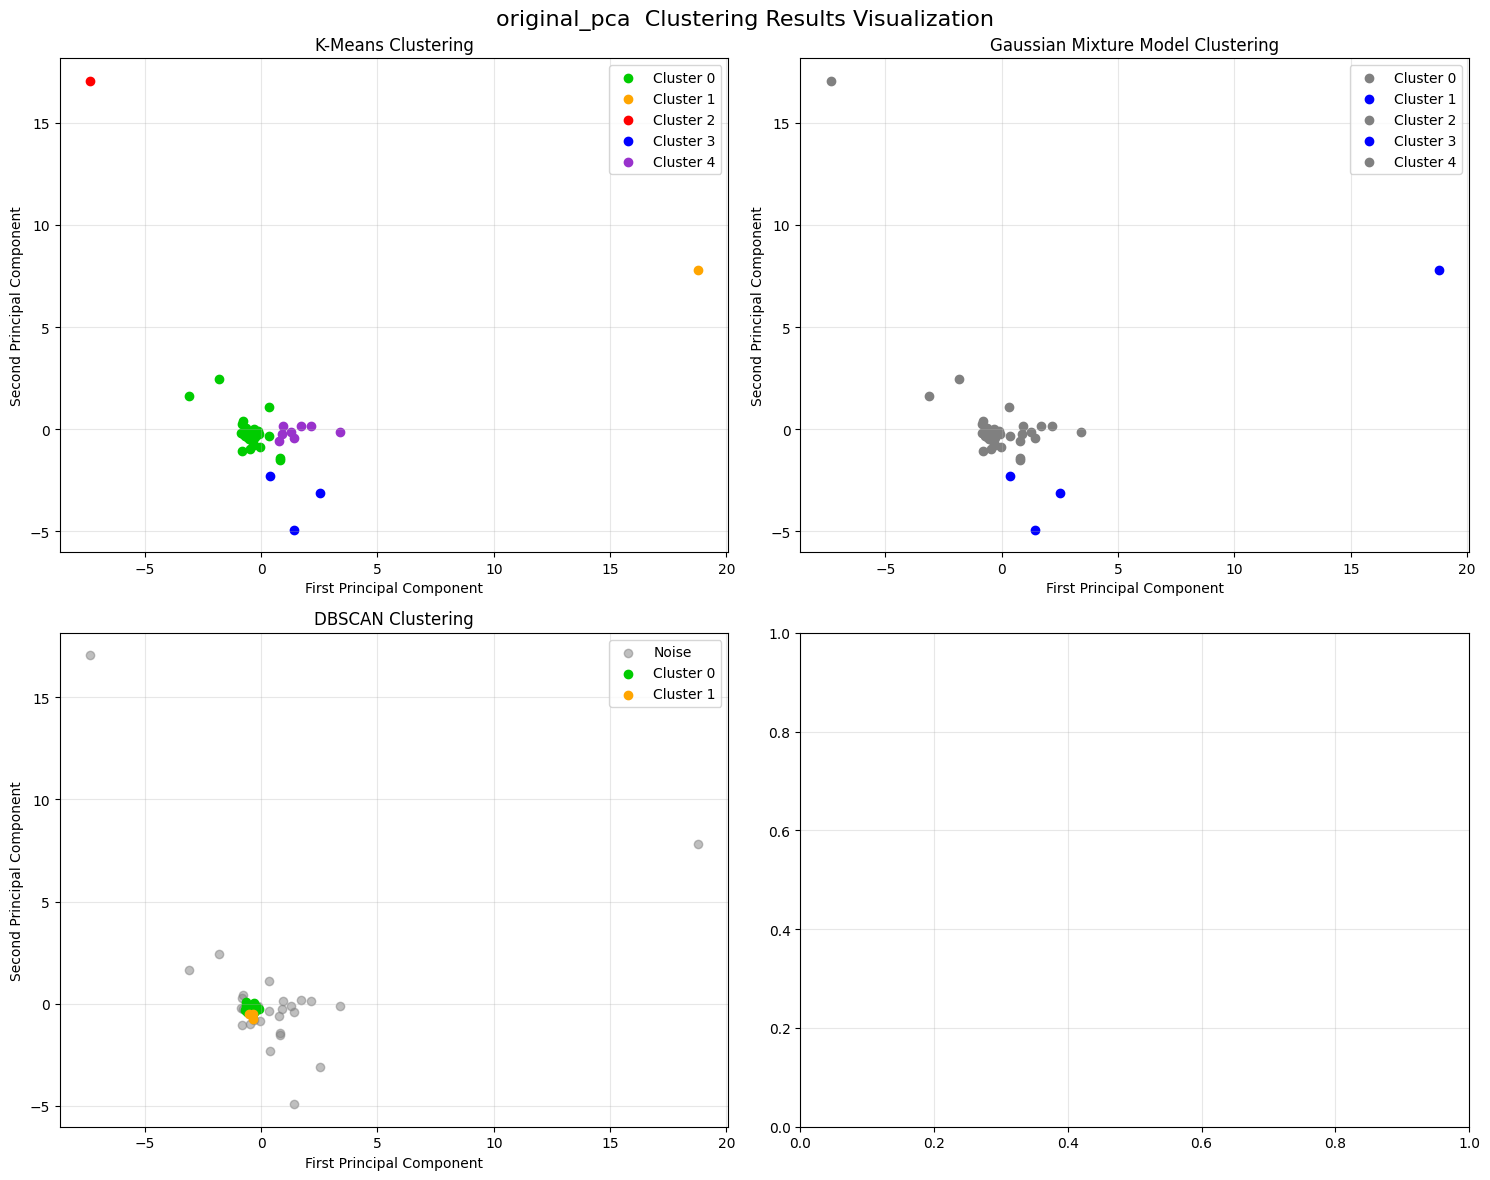

## 11.2 Clustering uniques_pca

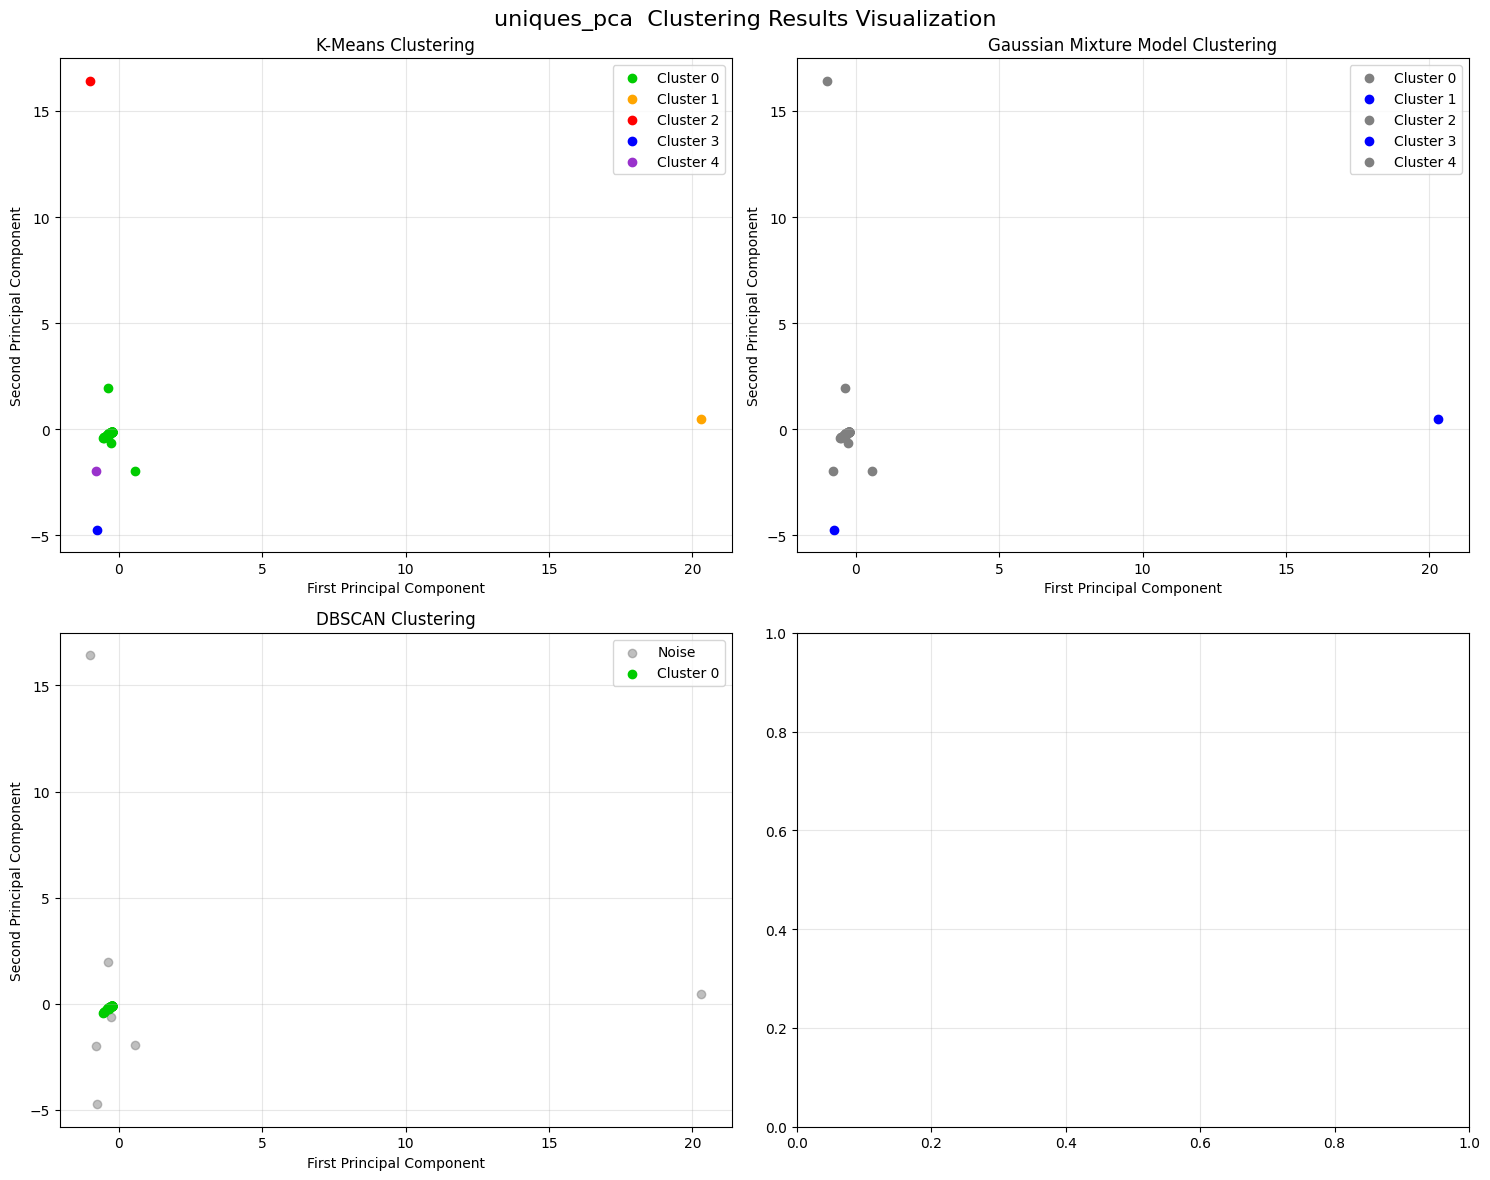


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 5.5531
Silhouette Score: 0.904047621468078
Davies-Bouldin Score: 0.019198114902457354
Adjusted Rand Score: -0.010464420557469723

Cluster Sizes:
Cluster 0: 66 points
Cluster 1: 1 points
Cluster 2: 1 points
Cluster 3: 1 points
Cluster 4: 1 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 5.0238
Silhouette Score: Not applicable
Davies-Bouldin Score: Not applicable
Adjusted Rand Score: -0.006244830934087667

Cluster Sizes:
Cluster 0: 63 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 5.5531
Silhouette Score: 0.904047621468078
Davies-Bouldin Score: 0.019198114902457354
Adjusted Rand Score: -0.010464420557469723

Cluster Sizes:
Cluster 0: 66 points
Cluster 1: 1 points
Cluster 2: 1 points
Cluster 3: 1 points
Cluster 4: 1 points

PCA Explained Variance Ratio:
PC1: 12.02%
PC2: 8.75%
PC3: 8.37%
Total Variance Explained (first 10 PCs): 29.13%


In [81]:
# Running pipeline
results_uniques_pca_cluster  = clustering_pipeline_all(uniques_pca,  pca_data_name='pca_data_uniques_pca ',
                                                   n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_uniques_pca_cluster, title_prefix='uniques_pca ')
print_clustering_metrics(results_uniques_pca_cluster )

## 11.3 Clustering uniques23_pca

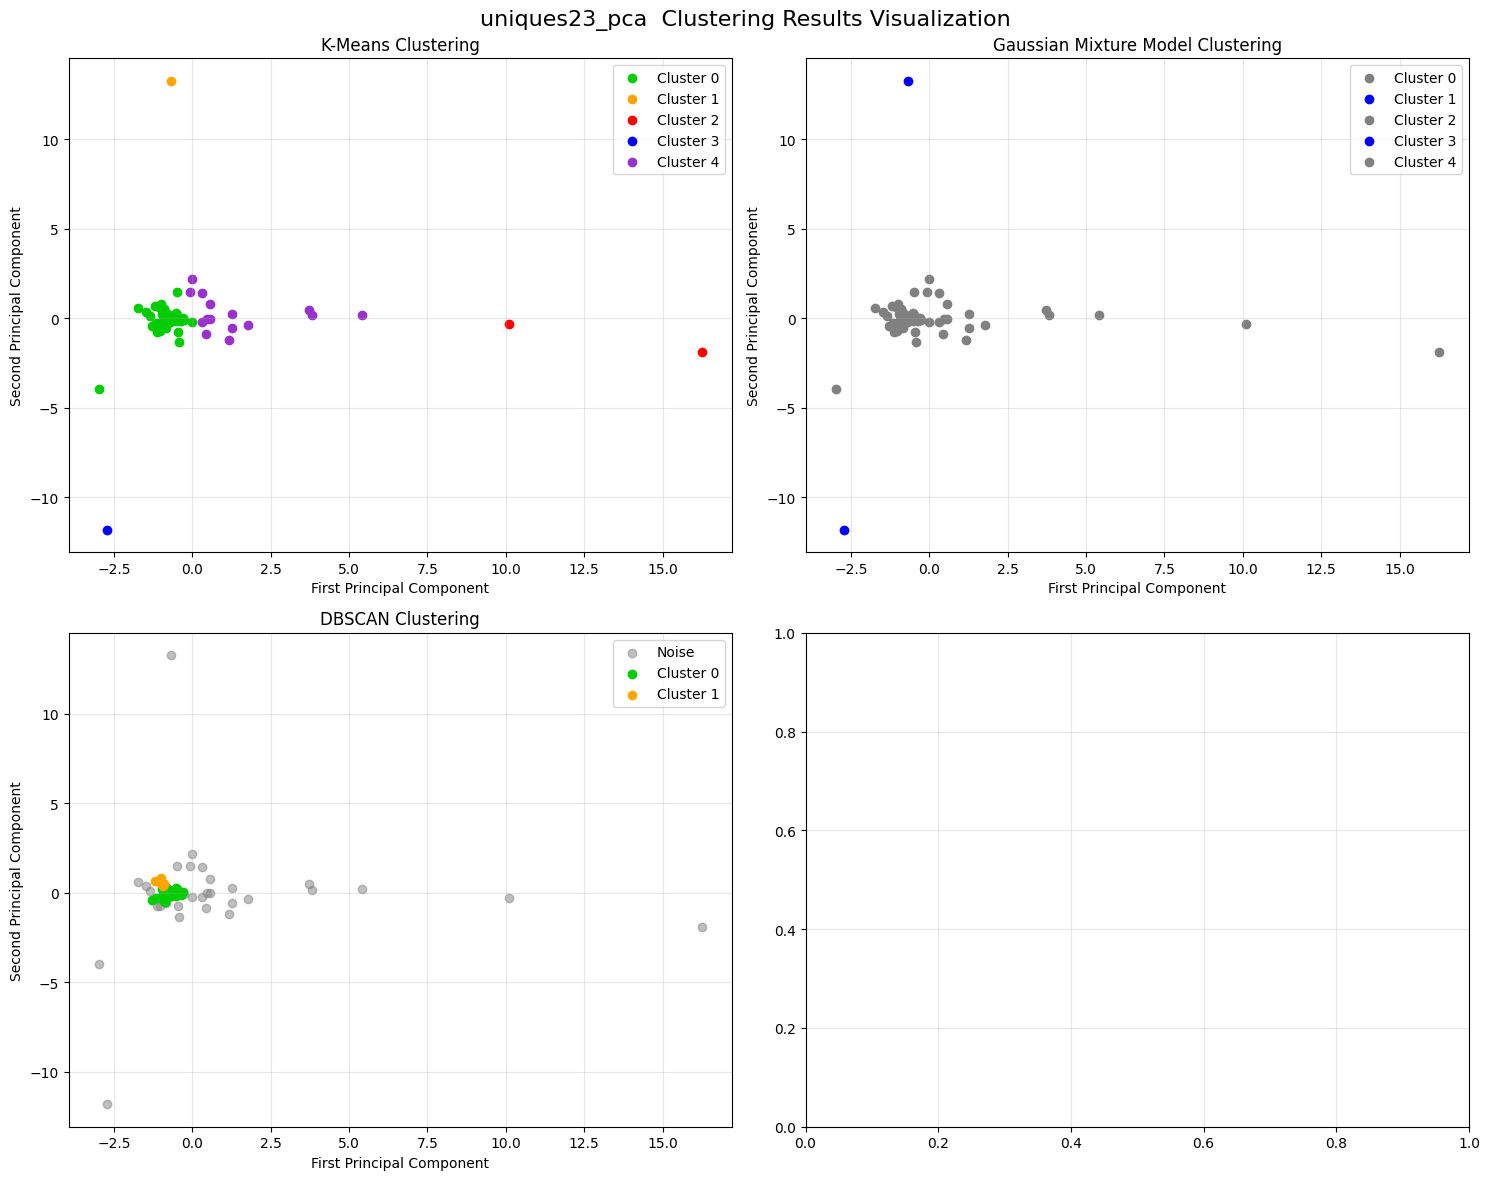


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 12.7689
Silhouette Score: 0.5151182216982135
Davies-Bouldin Score: 0.5313358398063747
Adjusted Rand Score: 0.0012698466837225792

Cluster Sizes:
Cluster 0: 51 points
Cluster 1: 1 points
Cluster 2: 2 points
Cluster 3: 1 points
Cluster 4: 15 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 3.8588
Silhouette Score: 0.43734269733479314
Davies-Bouldin Score: 0.708186083238505
Adjusted Rand Score: -0.014190235036020581

Cluster Sizes:
Cluster 0: 31 points
Cluster 1: 7 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 12.5940
Silhouette Score: 0.4027459109372235
Davies-Bouldin Score: 0.6178726969592354
Adjusted Rand Score: 0.04913143515856246

Cluster Sizes:
Cluster 0: 50 points
Cluster 1: 1 points
Cluster 2: 2 points
Cluster 3: 1 points
Cluster 4: 16 points

PCA Explained Variance Ratio:
PC1: 13.94%
PC2: 10.23%
PC3: 9.52%
Total Variance Explained (first 10 PCs): 33.69%


In [82]:
# Running pipeline
results_uniques23_pca_cluster  = clustering_pipeline_all(uniques23_pca,  pca_data_name='pca_data_uniques23_pca ',
                                                   n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_uniques23_pca_cluster, title_prefix='uniques23_pca ')
print_clustering_metrics(results_uniques23_pca_cluster )

## 11.4 Clustering uniques_OLS

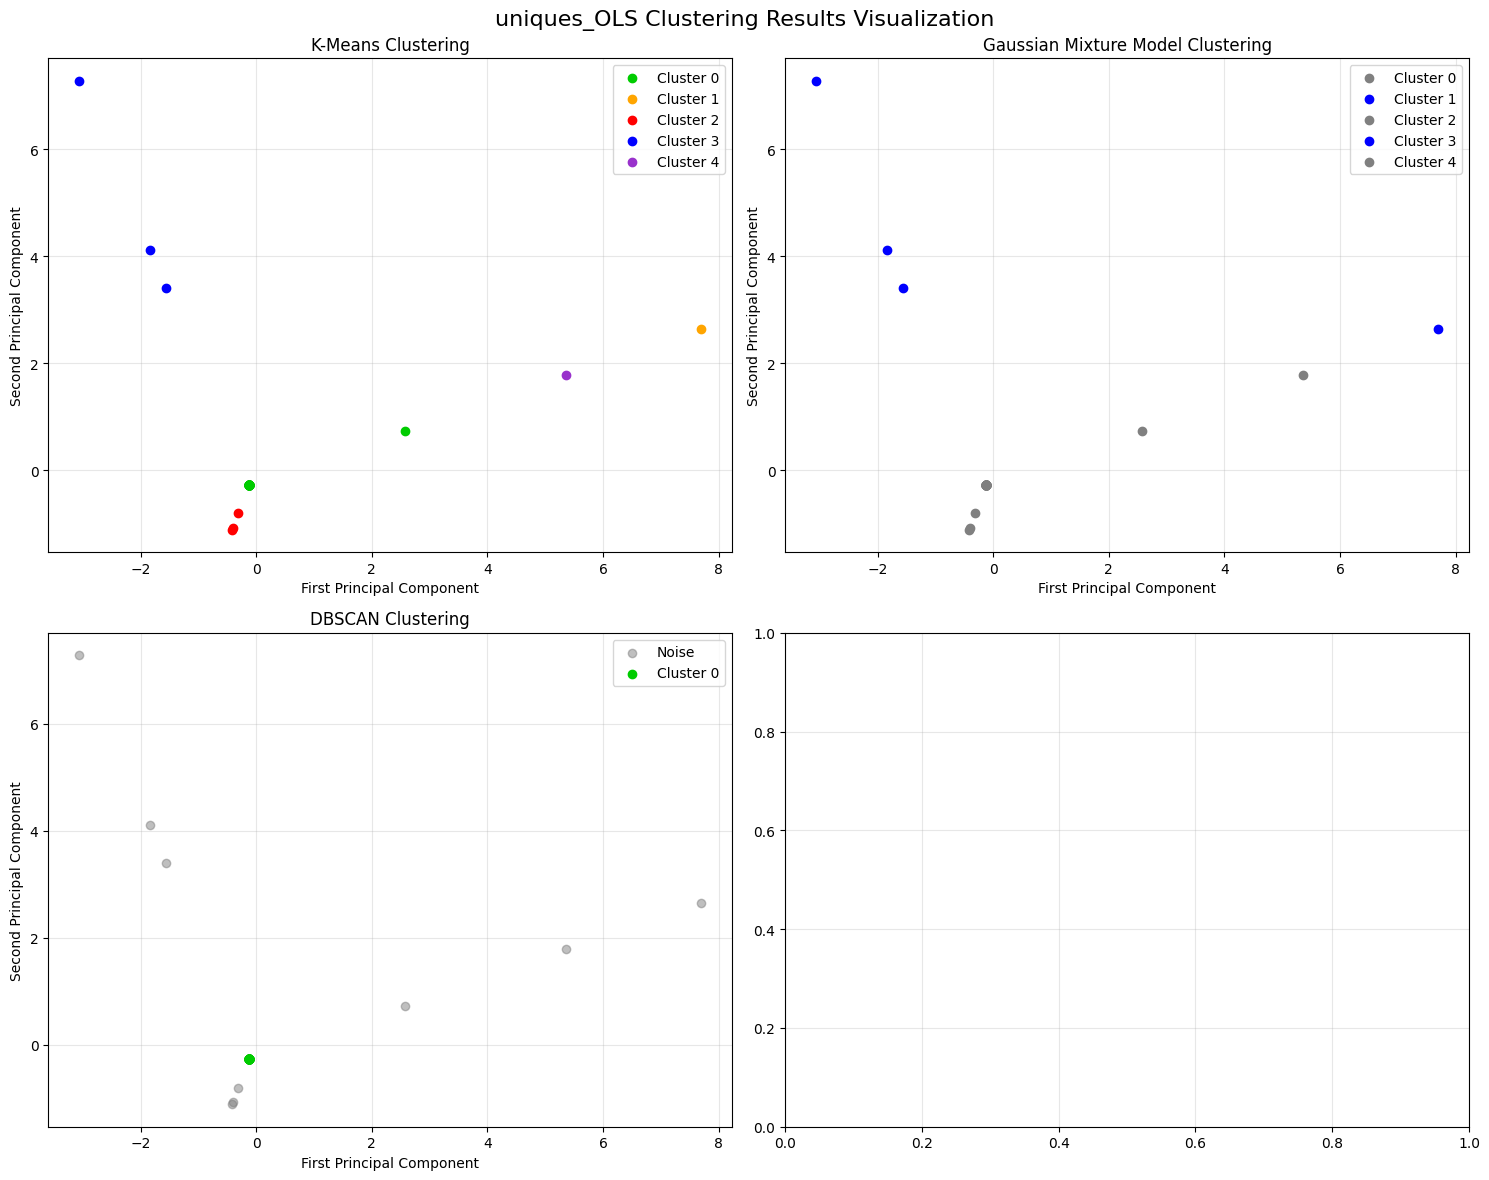


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 2.7889
Silhouette Score: 0.9137199068910945
Davies-Bouldin Score: 0.27664322117291296
Adjusted Rand Score: 0.0697407429232104

Cluster Sizes:
Cluster 0: 62 points
Cluster 1: 1 points
Cluster 2: 3 points
Cluster 3: 3 points
Cluster 4: 1 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 0.0000
Silhouette Score: Not applicable
Davies-Bouldin Score: Not applicable
Adjusted Rand Score: 0.08657008016527622

Cluster Sizes:
Cluster 0: 61 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 2.7889
Silhouette Score: 0.9137199068910945
Davies-Bouldin Score: 0.27664322117291296
Adjusted Rand Score: 0.0697407429232104

Cluster Sizes:
Cluster 0: 62 points
Cluster 1: 1 points
Cluster 2: 3 points
Cluster 3: 3 points
Cluster 4: 1 points

PCA Explained Variance Ratio:
PC1: 31.80%
PC2: 28.58%
PC3: 19.77%
Total Variance Explained (first 10 PCs): 80.15%


In [83]:
# Running pipeline
results_uniques_OLS_cluster  = clustering_pipeline_all(uniques_OLS,  pca_data_name='pca_data_uniques_OLS ',
                                                   n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_uniques_OLS_cluster, title_prefix='uniques_OLS')
print_clustering_metrics(results_uniques_OLS_cluster )

## 11.3 Clustering uniques23_OLS

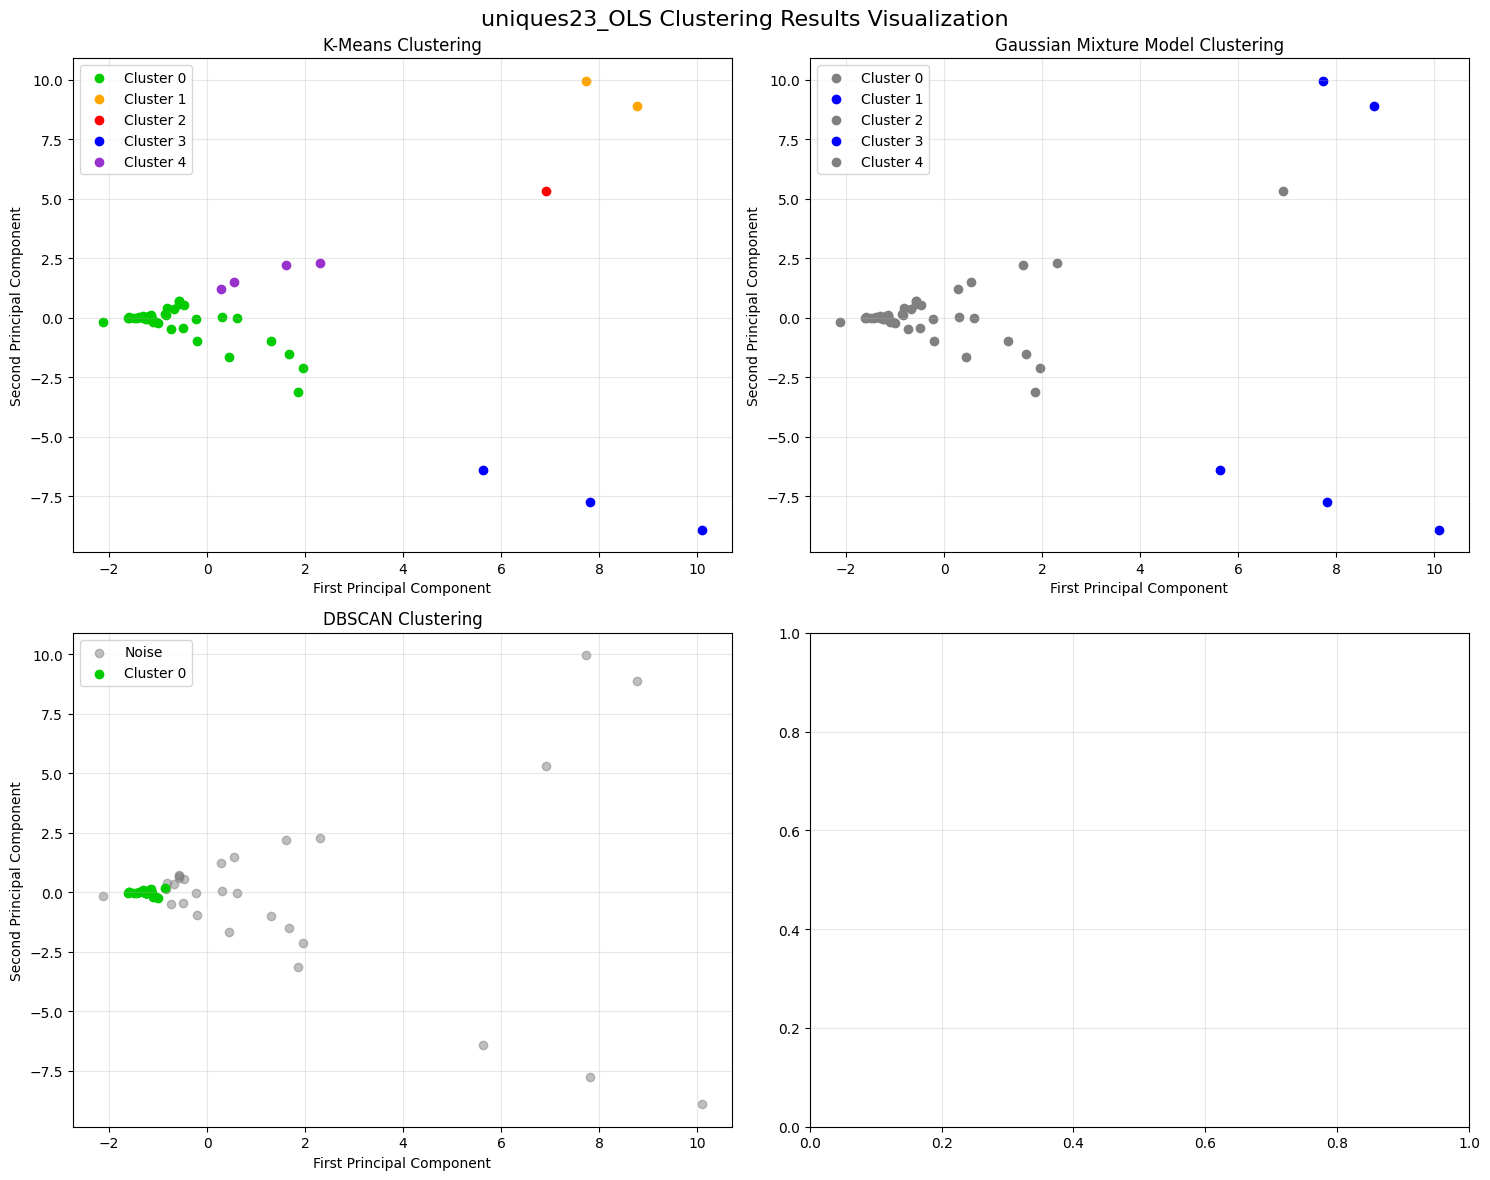


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 8.1419
Silhouette Score: 0.5882529068858746
Davies-Bouldin Score: 0.4977198278586873
Adjusted Rand Score: 0.05133791524847849

Cluster Sizes:
Cluster 0: 60 points
Cluster 1: 2 points
Cluster 2: 1 points
Cluster 3: 3 points
Cluster 4: 4 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 1.6487
Silhouette Score: Not applicable
Davies-Bouldin Score: Not applicable
Adjusted Rand Score: 0.11981085908551405

Cluster Sizes:
Cluster 0: 41 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 8.1419
Silhouette Score: 0.5882529068858746
Davies-Bouldin Score: 0.4977198278586873
Adjusted Rand Score: 0.05133791524847849

Cluster Sizes:
Cluster 0: 60 points
Cluster 1: 2 points
Cluster 2: 1 points
Cluster 3: 3 points
Cluster 4: 4 points

PCA Explained Variance Ratio:
PC1: 25.10%
PC2: 22.51%
PC3: 9.98%
Total Variance Explained (first 10 PCs): 57.59%


In [84]:
# Running pipeline
results_uniques23_OLS_cluster  = clustering_pipeline_all(uniques23_OLS,  pca_data_name='pca_data_uniques23_OLS ',
                                                   n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_uniques23_OLS_cluster, title_prefix='uniques23_OLS')
print_clustering_metrics(results_uniques23_OLS_cluster )

### Discussing  uniques23_OLS (300+ features):
K-means: Silhouette Score of 0.685, Davies-Bouldin of 0.514
Cluster sizes are quite imbalanced (53, 3, 3, 5, 6 points)
PCA explains 37% of variance (19.95% PC1, 17.05% PC2)

## 11.4 Clustering Influencers_OLS

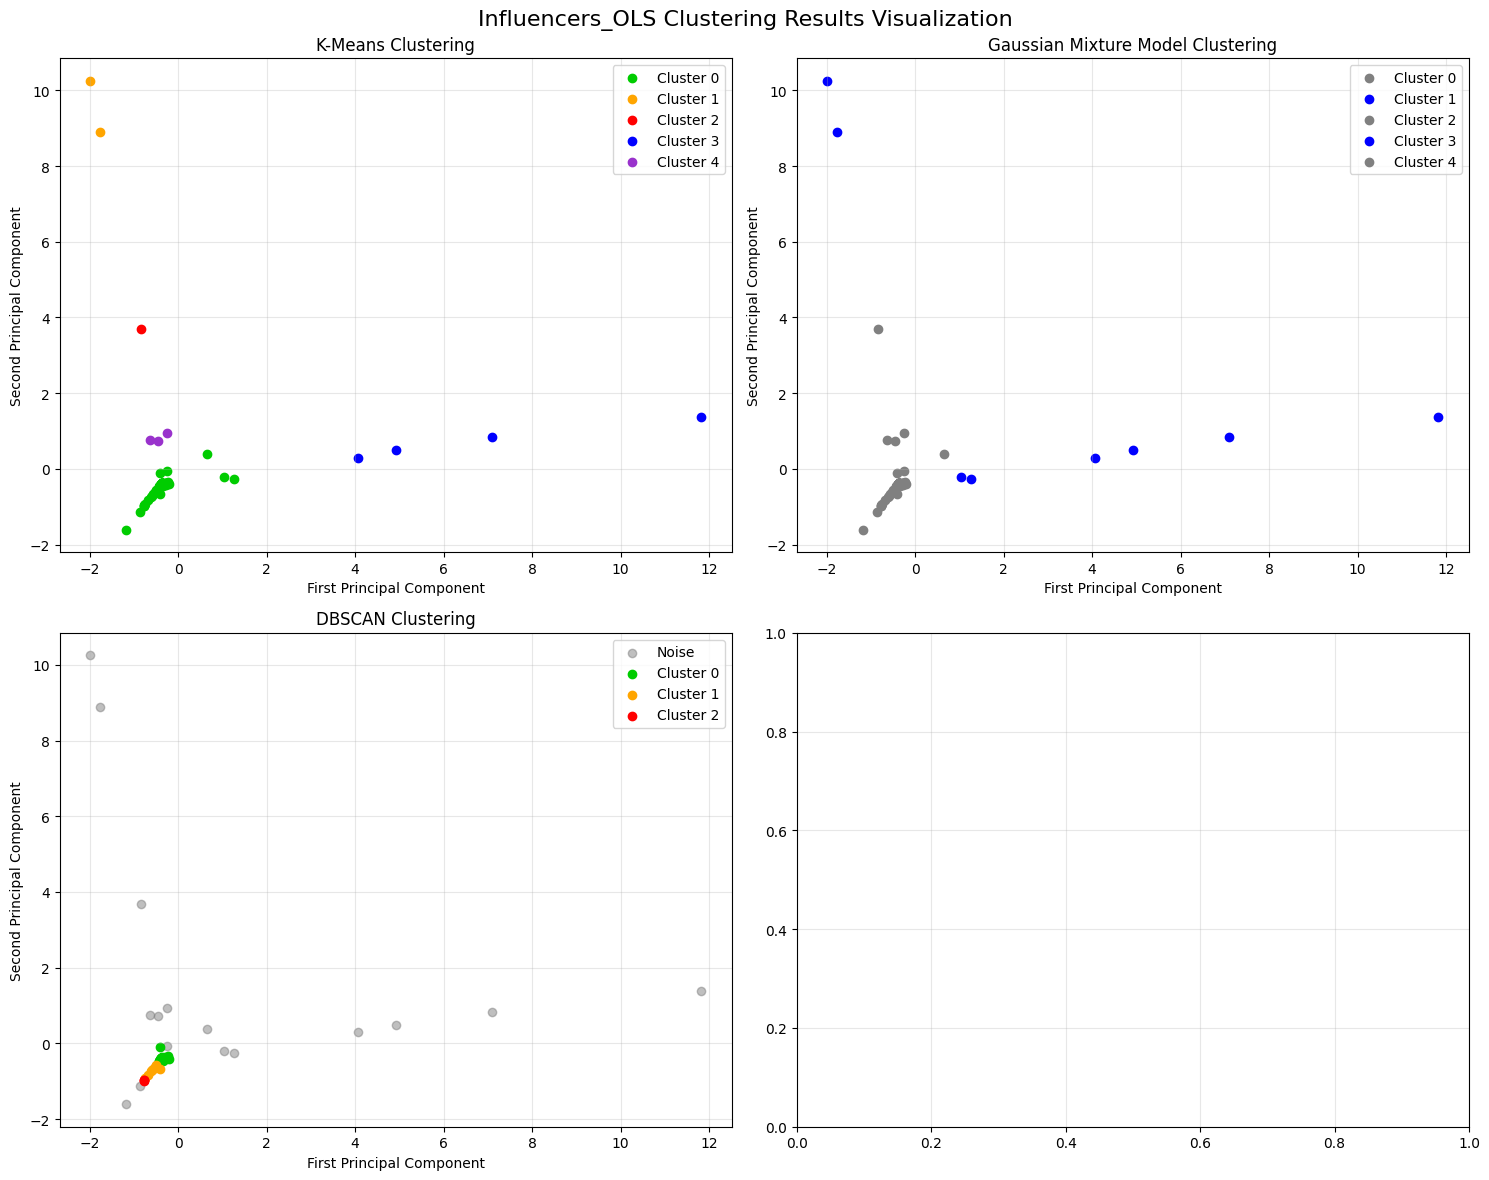


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 5.6449
Silhouette Score: 0.7694291869255668
Davies-Bouldin Score: 0.35104428001699745
Adjusted Rand Score: 0.16074355779948857

Cluster Sizes:
Cluster 0: 60 points
Cluster 1: 2 points
Cluster 2: 1 points
Cluster 3: 4 points
Cluster 4: 3 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 2.5699
Silhouette Score: 0.8203273277596613
Davies-Bouldin Score: 0.3551565894127267
Adjusted Rand Score: 0.24919006653139783

Cluster Sizes:
Cluster 0: 43 points
Cluster 1: 8 points
Cluster 2: 3 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 5.4497
Silhouette Score: 0.7392743441678633
Davies-Bouldin Score: 0.49581557310154567
Adjusted Rand Score: 0.17344663706948818

Cluster Sizes:
Cluster 0: 58 points
Cluster 1: 2 points
Cluster 2: 1 points
Cluster 3: 6 points
Cluster 4: 3 points

PCA Explained Variance Ratio:
PC1: 22.79%
PC2: 19.70%
PC3: 11.27%
Total Variance Explained (first 10 PC

In [85]:
# Running pipeline
results_Influencers_OLS_cluster = clustering_pipeline_all(Influencers_OLS,  pca_data_name='pca_data_Influencers_OLS_cluster',
                                                    n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_Influencers_OLS_cluster, title_prefix='Influencers_OLS')
print_clustering_metrics(results_Influencers_OLS_cluster)

### Clustering Influencers_OLS, Discussion
Influencers_OLS:
K-means: Silhouette Score of 0.603, Davies-Bouldin of 0.552
Very imbalanced cluster sizes (1, 53, 3, 3, 10 points)
PCA explains 35.53% of variance

Notice that for PCA visualisation on notebook PCA_RF_FImporance.ipnyb, the same dataset was used, hower the main difference is that there the category label was use to color code the samples, however category was droped and didnt participate on the clustering, it was used just for color coding.
Plots show similar behaviour because the clustering algorithms (K-Means, DBSCAN, GMM) are able to identify the inherent structure in the data and recover groupings that are consistent with the original category information, even though the category column is not provided. it means the clustering methods are effectively capturing the underlying patterns in the data, regardless of whether the category information is explicitly given or not. The consistency between the PCA visualization and the clustering results indicates the data has a clear structure that the algorithms can latch onto.
## 11.5 Clustering OLS_all

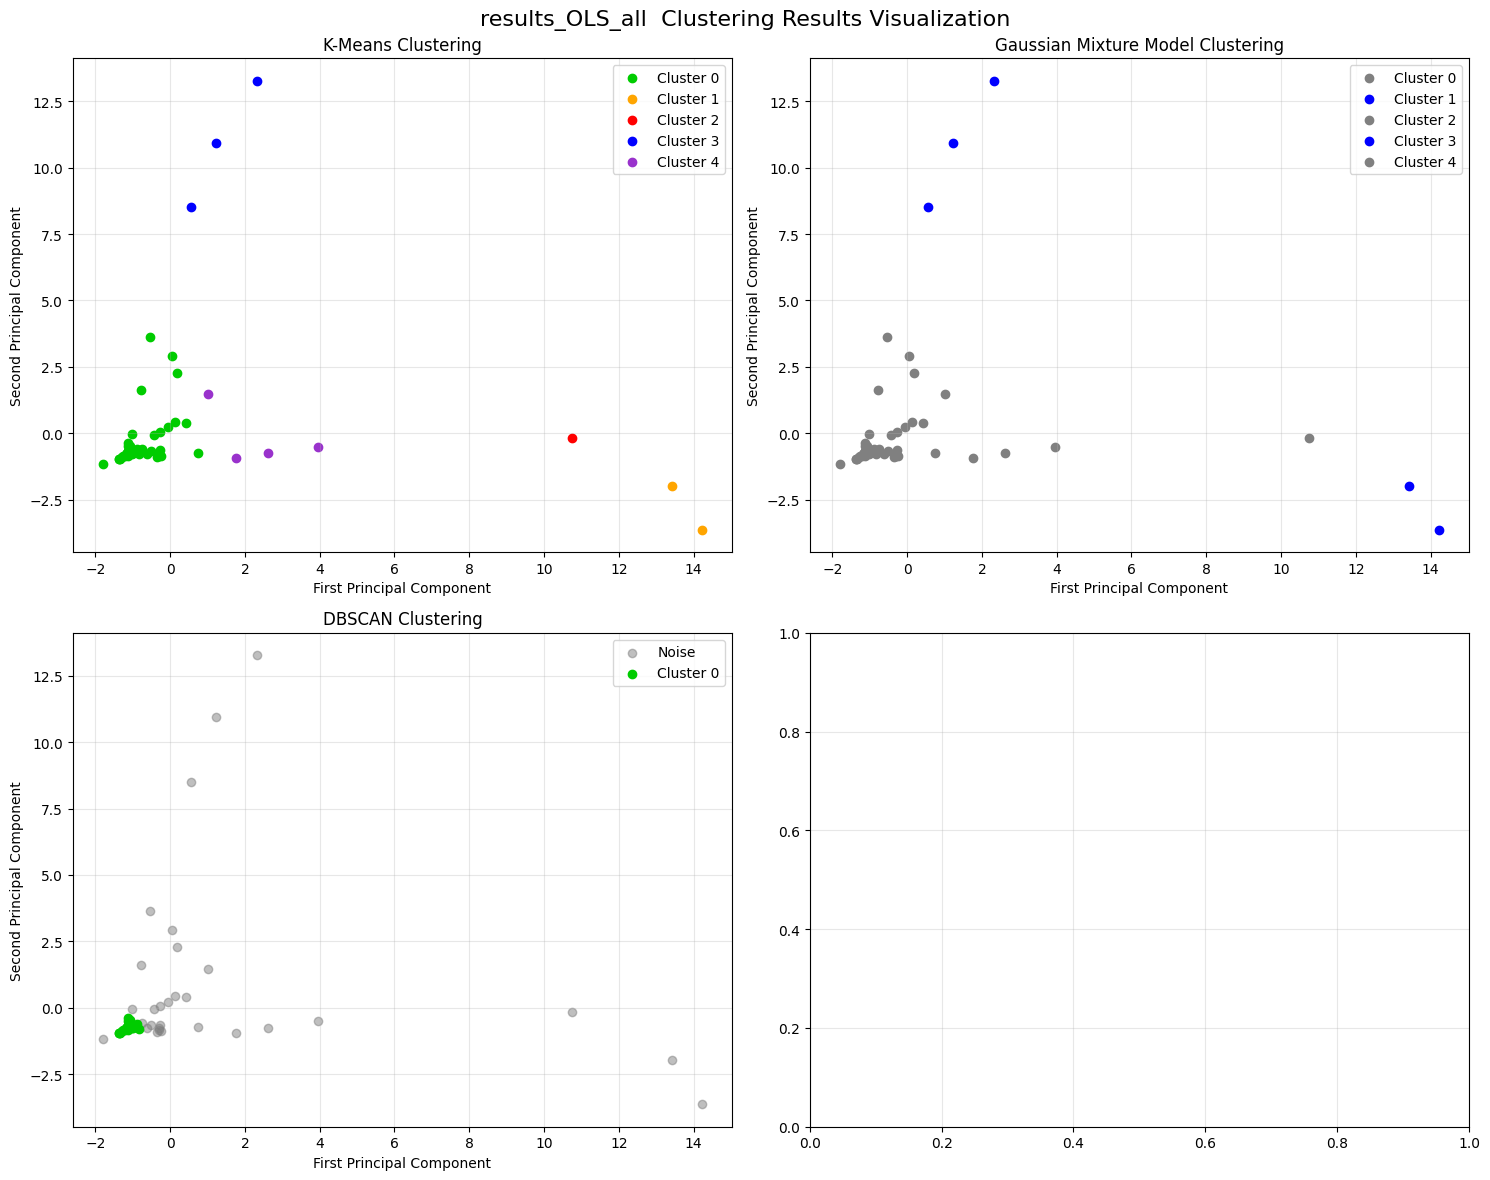


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 9.4276
Silhouette Score: 0.6428025731108757
Davies-Bouldin Score: 0.4859053444865082
Adjusted Rand Score: 0.07005203831641442

Cluster Sizes:
Cluster 0: 60 points
Cluster 1: 2 points
Cluster 2: 1 points
Cluster 3: 3 points
Cluster 4: 4 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 2.1030
Silhouette Score: Not applicable
Davies-Bouldin Score: Not applicable
Adjusted Rand Score: 0.10817748253256054

Cluster Sizes:
Cluster 0: 40 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 9.4276
Silhouette Score: 0.6428025731108757
Davies-Bouldin Score: 0.4859053444865082
Adjusted Rand Score: 0.07005203831641442

Cluster Sizes:
Cluster 0: 60 points
Cluster 1: 2 points
Cluster 2: 1 points
Cluster 3: 3 points
Cluster 4: 4 points

PCA Explained Variance Ratio:
PC1: 26.39%
PC2: 20.00%
PC3: 10.14%
Total Variance Explained (first 10 PCs): 56.54%


In [86]:
# Running pipeline
results_OLS_all_cluster = clustering_pipeline_all(OLS_all,  pca_data_name='pca_data_OLS_all',   n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_OLS_all_cluster, title_prefix='results_OLS_all ')
print_clustering_metrics(results_OLS_all_cluster)

### OLS_all Discussion
K-means: Silhouette Score of 0.678, Davies-Bouldin of 0.457
Cluster sizes imbalanced (57, 3, 1, 3, 6 points)
PCA explains 36.18% of variance
## 11.6 Clustering Influencers_uniques

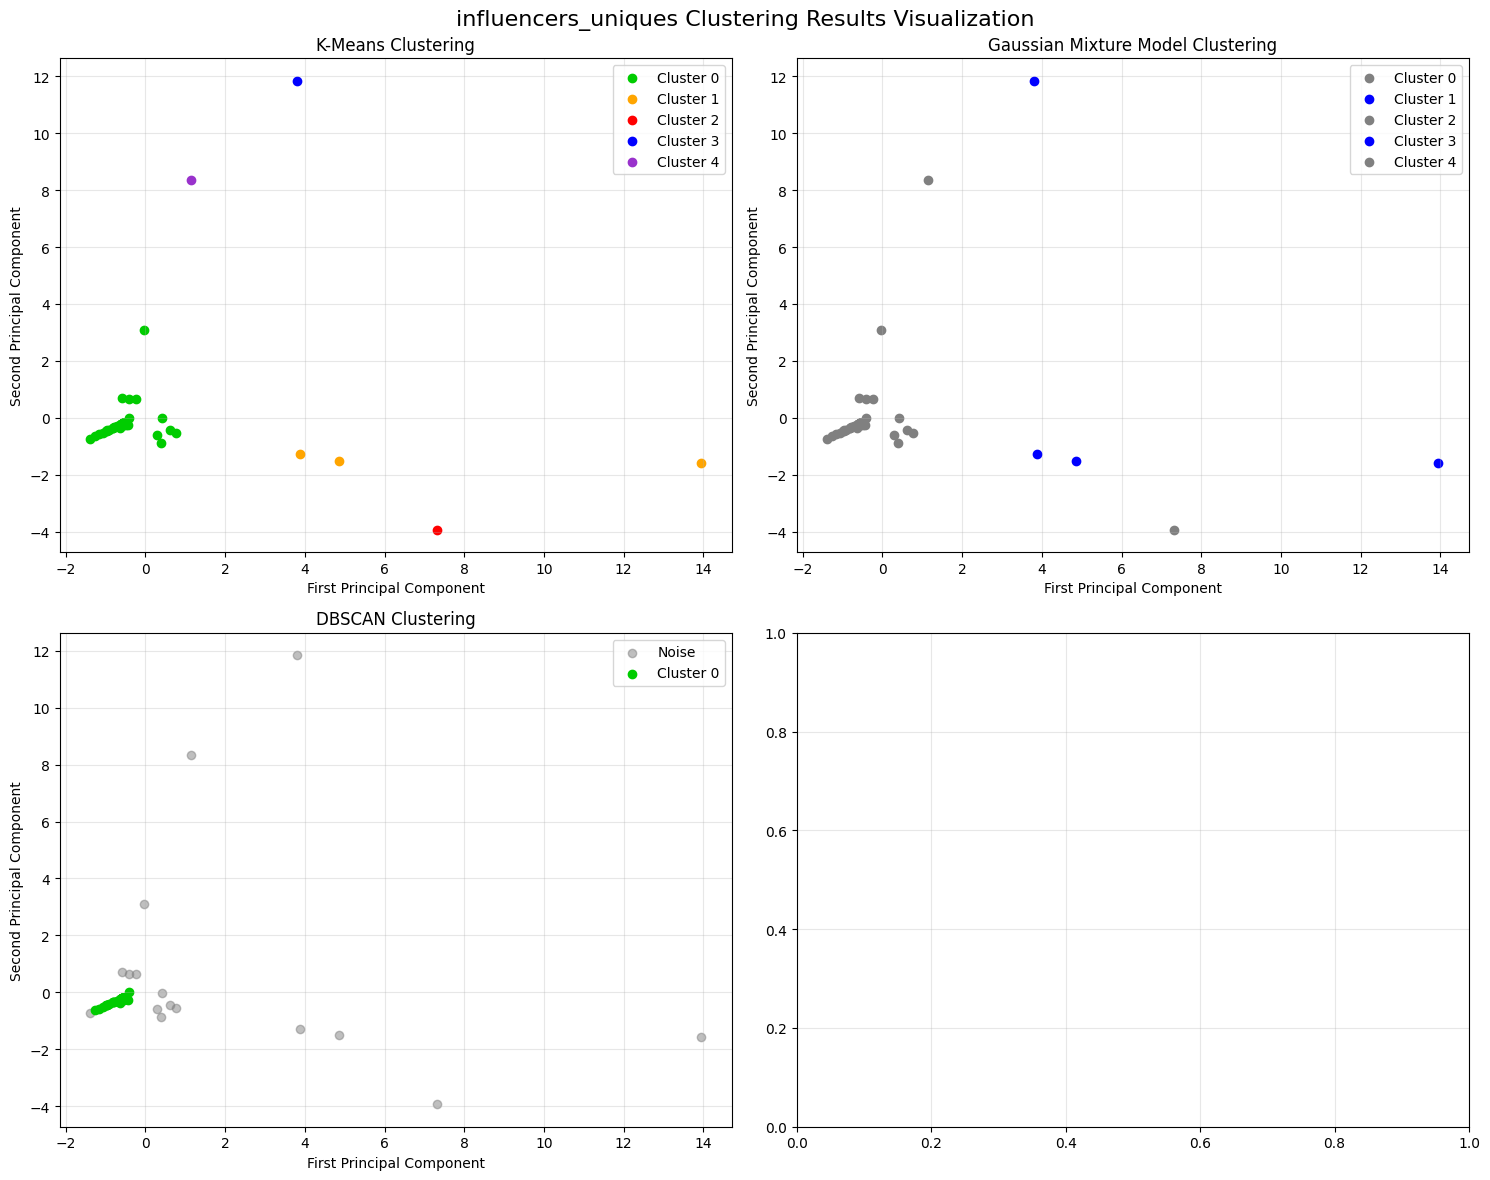


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 7.4304
Silhouette Score: 0.8224643292090873
Davies-Bouldin Score: 0.4708655649284282
Adjusted Rand Score: 0.07796112117648754

Cluster Sizes:
Cluster 0: 64 points
Cluster 1: 3 points
Cluster 2: 1 points
Cluster 3: 1 points
Cluster 4: 1 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 2.1522
Silhouette Score: Not applicable
Davies-Bouldin Score: Not applicable
Adjusted Rand Score: 0.3065445497938877

Cluster Sizes:
Cluster 0: 54 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 7.4304
Silhouette Score: 0.8224643292090873
Davies-Bouldin Score: 0.4708655649284282
Adjusted Rand Score: 0.07796112117648754

Cluster Sizes:
Cluster 0: 64 points
Cluster 1: 3 points
Cluster 2: 1 points
Cluster 3: 1 points
Cluster 4: 1 points

PCA Explained Variance Ratio:
PC1: 22.49%
PC2: 16.95%
PC3: 11.01%
Total Variance Explained (first 10 PCs): 50.44%


In [87]:
#implementing the algoritms in a part of uniques, the first 50 rows
results_influencers_uniques_cluster = clustering_pipeline_all(Influencers_uniques,  pca_data_name='pca_data_influencers_uniques',
                                                   n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_influencers_uniques_cluster, title_prefix='influencers_uniques')
print_clustering_metrics(results_influencers_uniques_cluster)

### Influencers_uniques_selected Discussion

## 11.7. Clustering Merged_selected

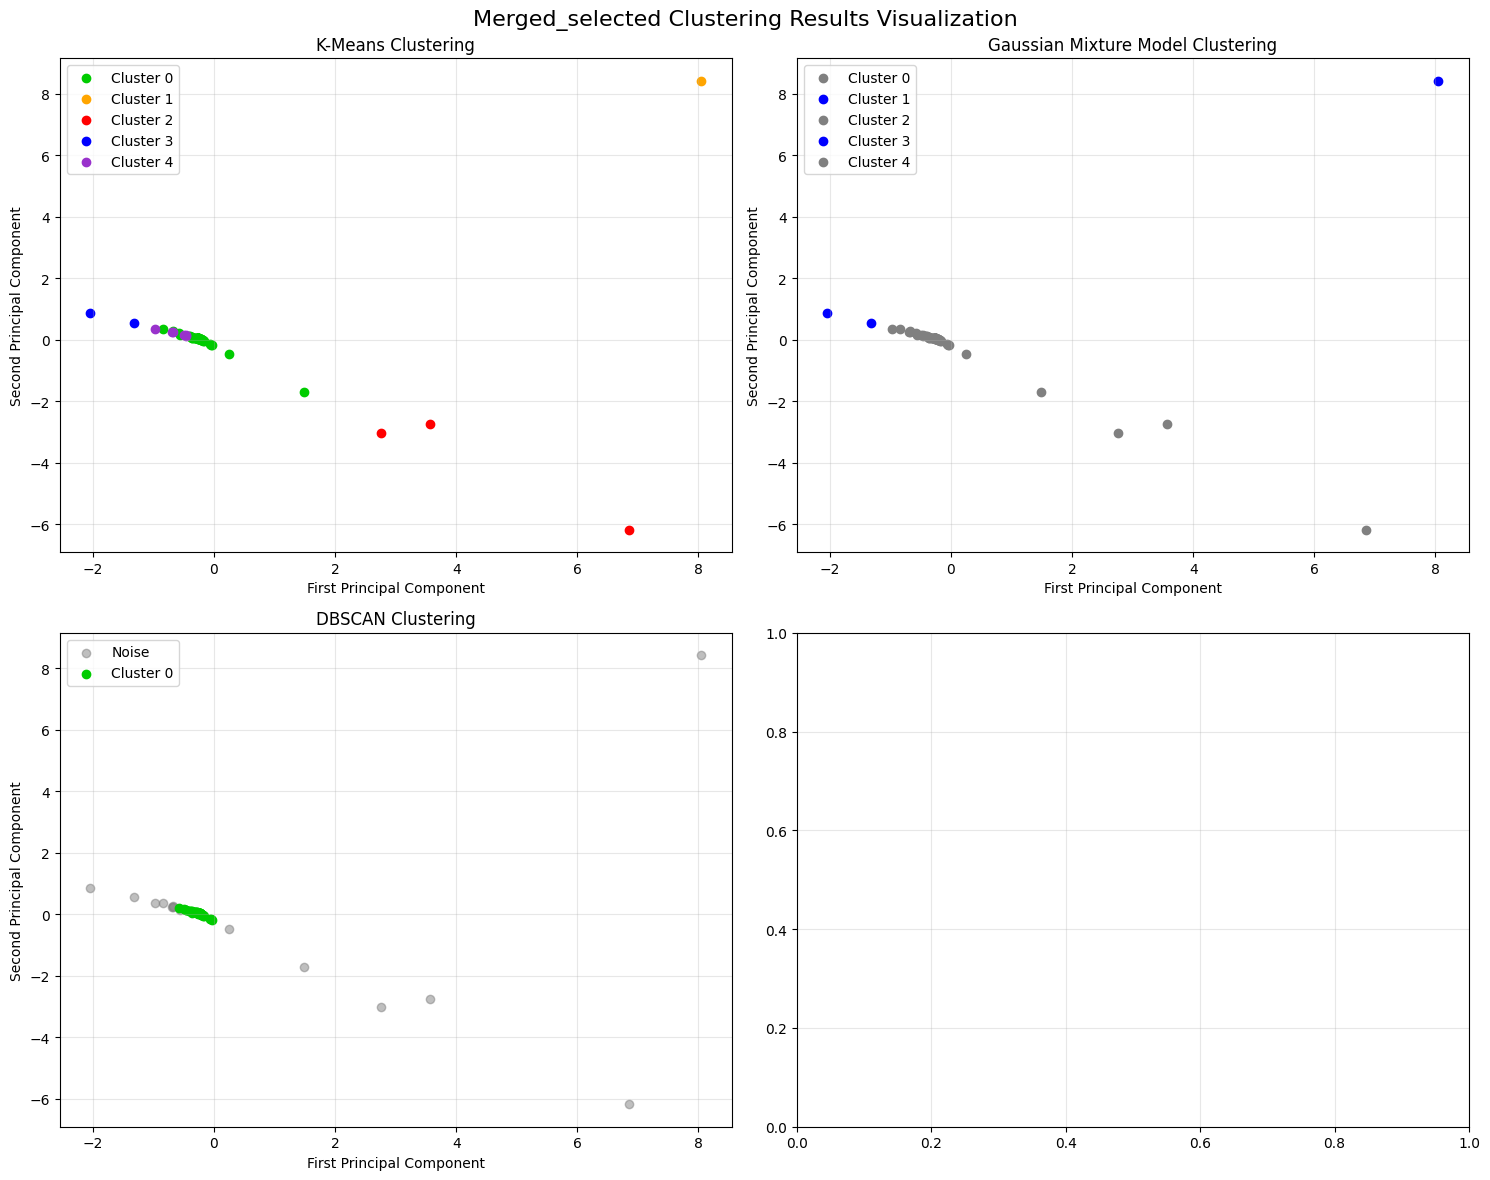


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 4.5259
Silhouette Score: 0.7062635634144354
Davies-Bouldin Score: 0.40380616877508635
Adjusted Rand Score: 0.04208369188946041

Cluster Sizes:
Cluster 0: 58 points
Cluster 1: 1 points
Cluster 2: 3 points
Cluster 3: 2 points
Cluster 4: 6 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 0.6825
Silhouette Score: Not applicable
Davies-Bouldin Score: Not applicable
Adjusted Rand Score: 0.014160102464194768

Cluster Sizes:
Cluster 0: 56 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 4.2913
Silhouette Score: 0.2578070036972253
Davies-Bouldin Score: 1.1277413893988708
Adjusted Rand Score: 0.06336719327434753

Cluster Sizes:
Cluster 0: 17 points
Cluster 1: 1 points
Cluster 2: 3 points
Cluster 3: 2 points
Cluster 4: 47 points

PCA Explained Variance Ratio:
PC1: 21.17%
PC2: 18.69%
PC3: 14.50%
Total Variance Explained (first 10 PCs): 54.35%


In [88]:
# Running pipeline
results_Merged_selected_cluster = clustering_pipeline_all(Merged_selected,  pca_data_name='pca_data_Merged_selected',
                                                   n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_Merged_selected_cluster, title_prefix='Merged_selected')
print_clustering_metrics(results_Merged_selected_cluster)

## 11.8 Clustering old_new

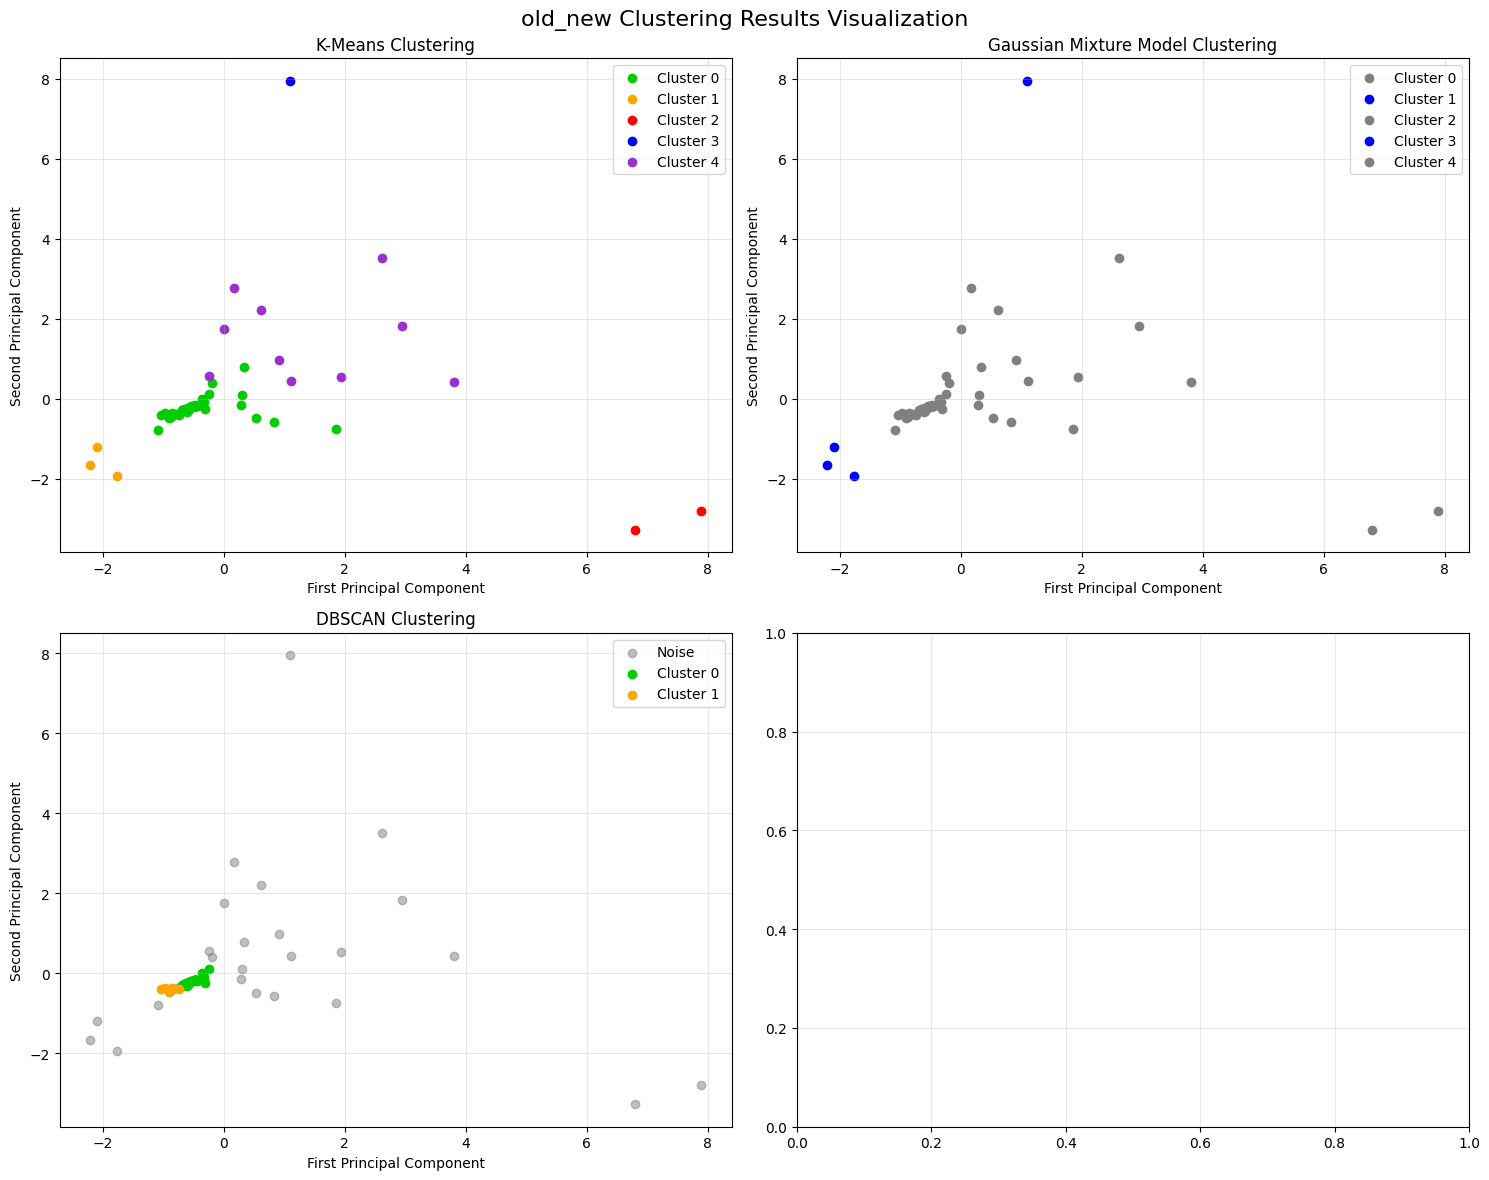


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 8.6894
Silhouette Score: 0.6519515354035125
Davies-Bouldin Score: 0.5191629538792436
Adjusted Rand Score: 0.030946011673151752

Cluster Sizes:
Cluster 0: 54 points
Cluster 1: 3 points
Cluster 2: 2 points
Cluster 3: 1 points
Cluster 4: 10 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 3.7819
Silhouette Score: 0.7391938067398837
Davies-Bouldin Score: 0.34081568464526235
Adjusted Rand Score: 0.045232497748160266

Cluster Sizes:
Cluster 0: 38 points
Cluster 1: 6 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 8.1378
Silhouette Score: 0.4757229195088627
Davies-Bouldin Score: 0.6508853088674846
Adjusted Rand Score: 0.04955924414398119

Cluster Sizes:
Cluster 0: 42 points
Cluster 1: 3 points
Cluster 2: 2 points
Cluster 3: 1 points
Cluster 4: 22 points

PCA Explained Variance Ratio:
PC1: 15.22%
PC2: 10.81%
PC3: 10.04%
Total Variance Explained (first 10 PCs): 36.07%


In [89]:
# Running pipeline
results_old_new_cluster = clustering_pipeline_all(old_new ,  pca_data_name='pca_data_old_new',
                                                    n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_old_new_cluster, title_prefix='old_new')
print_clustering_metrics(results_old_new_cluster)

### old_new1 Discussion
This old features process of selection was very good so the clustering show very similar to the first clustering that agrees with the risk label of this study.

## 11.9. Cluster Influencers_uniques_selected

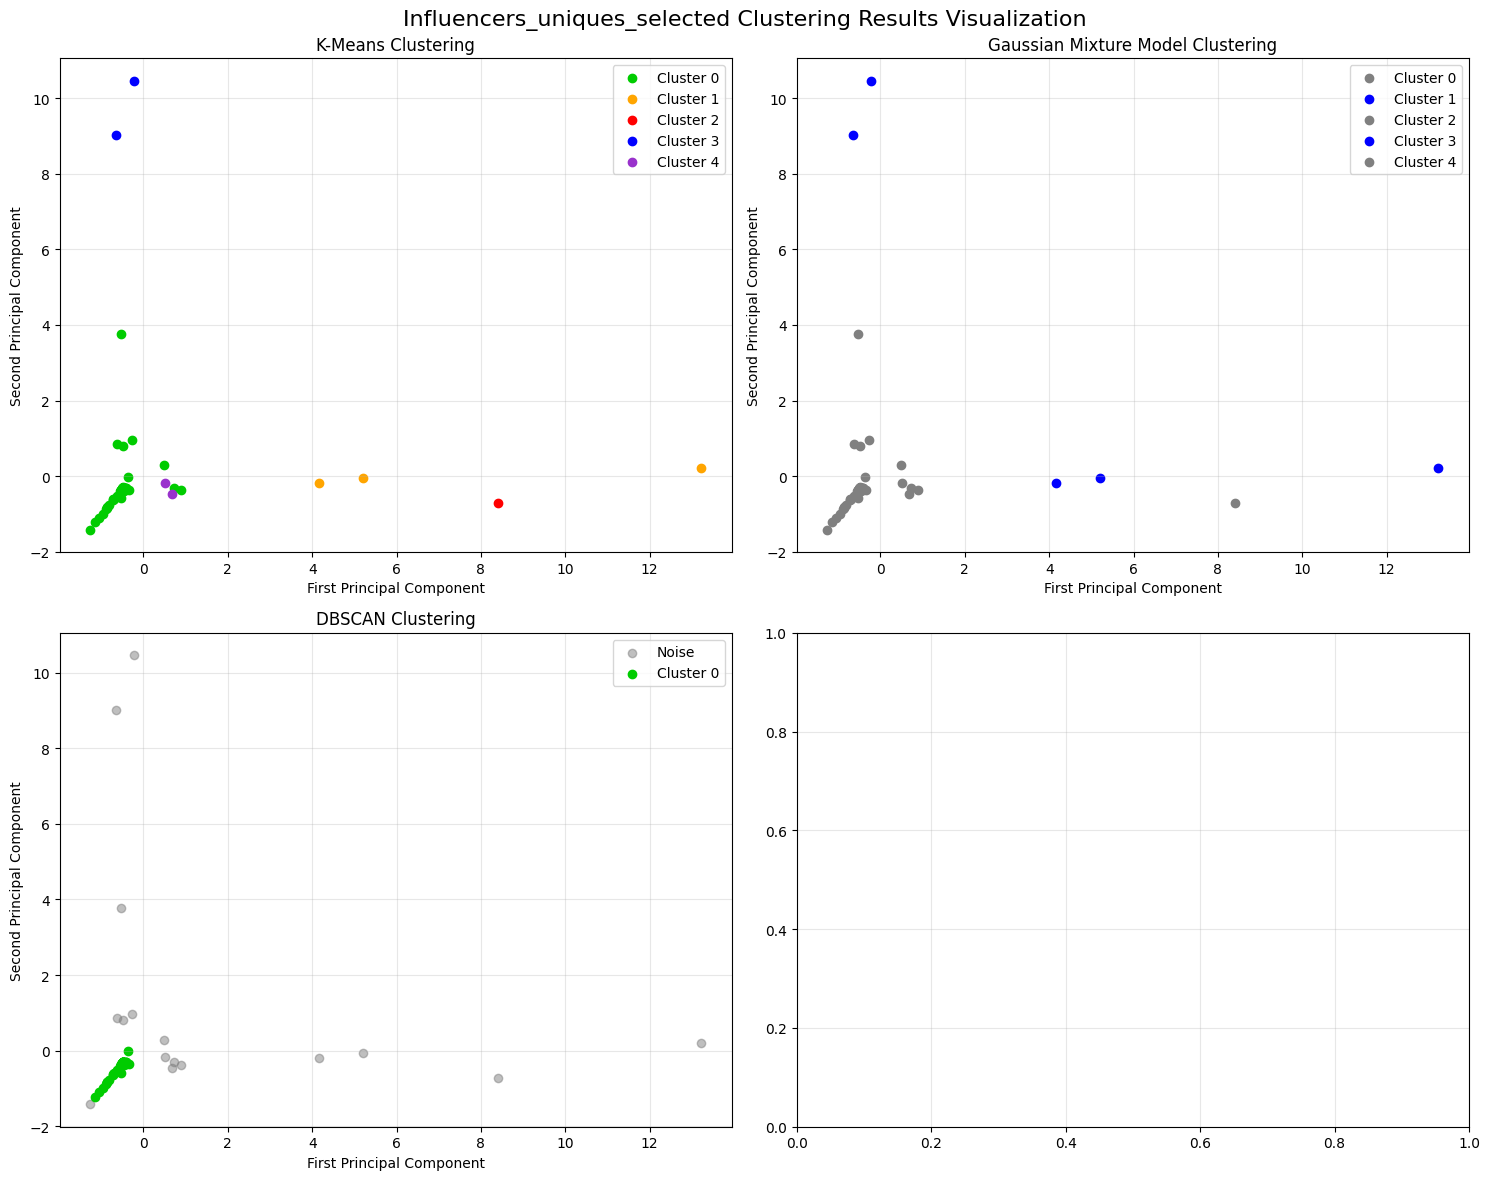


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 6.1877
Silhouette Score: 0.7598484750661255
Davies-Bouldin Score: 0.4833562586385277
Adjusted Rand Score: 0.11511030743930652

Cluster Sizes:
Cluster 0: 62 points
Cluster 1: 3 points
Cluster 2: 1 points
Cluster 3: 2 points
Cluster 4: 2 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 2.1522
Silhouette Score: Not applicable
Davies-Bouldin Score: Not applicable
Adjusted Rand Score: 0.3065445497938877

Cluster Sizes:
Cluster 0: 54 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 6.1877
Silhouette Score: 0.7598484750661255
Davies-Bouldin Score: 0.4833562586385277
Adjusted Rand Score: 0.11511030743930652

Cluster Sizes:
Cluster 0: 62 points
Cluster 1: 3 points
Cluster 2: 1 points
Cluster 3: 2 points
Cluster 4: 2 points

PCA Explained Variance Ratio:
PC1: 22.41%
PC2: 15.91%
PC3: 11.27%
Total Variance Explained (first 10 PCs): 49.59%


In [90]:
#implementing the algoritms in a part of uniques, the first 50 rows
results_Influencers_uniques_selected_cluster = clustering_pipeline_all(Influencers_uniques_selected,  pca_data_name='pca_data_Influencers_uniques_selected',
                                                   n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_Influencers_uniques_selected_cluster, title_prefix='Influencers_uniques_selected')
print_clustering_metrics(results_Influencers_uniques_selected_cluster)

## 11.10. Clustering of Merged_df

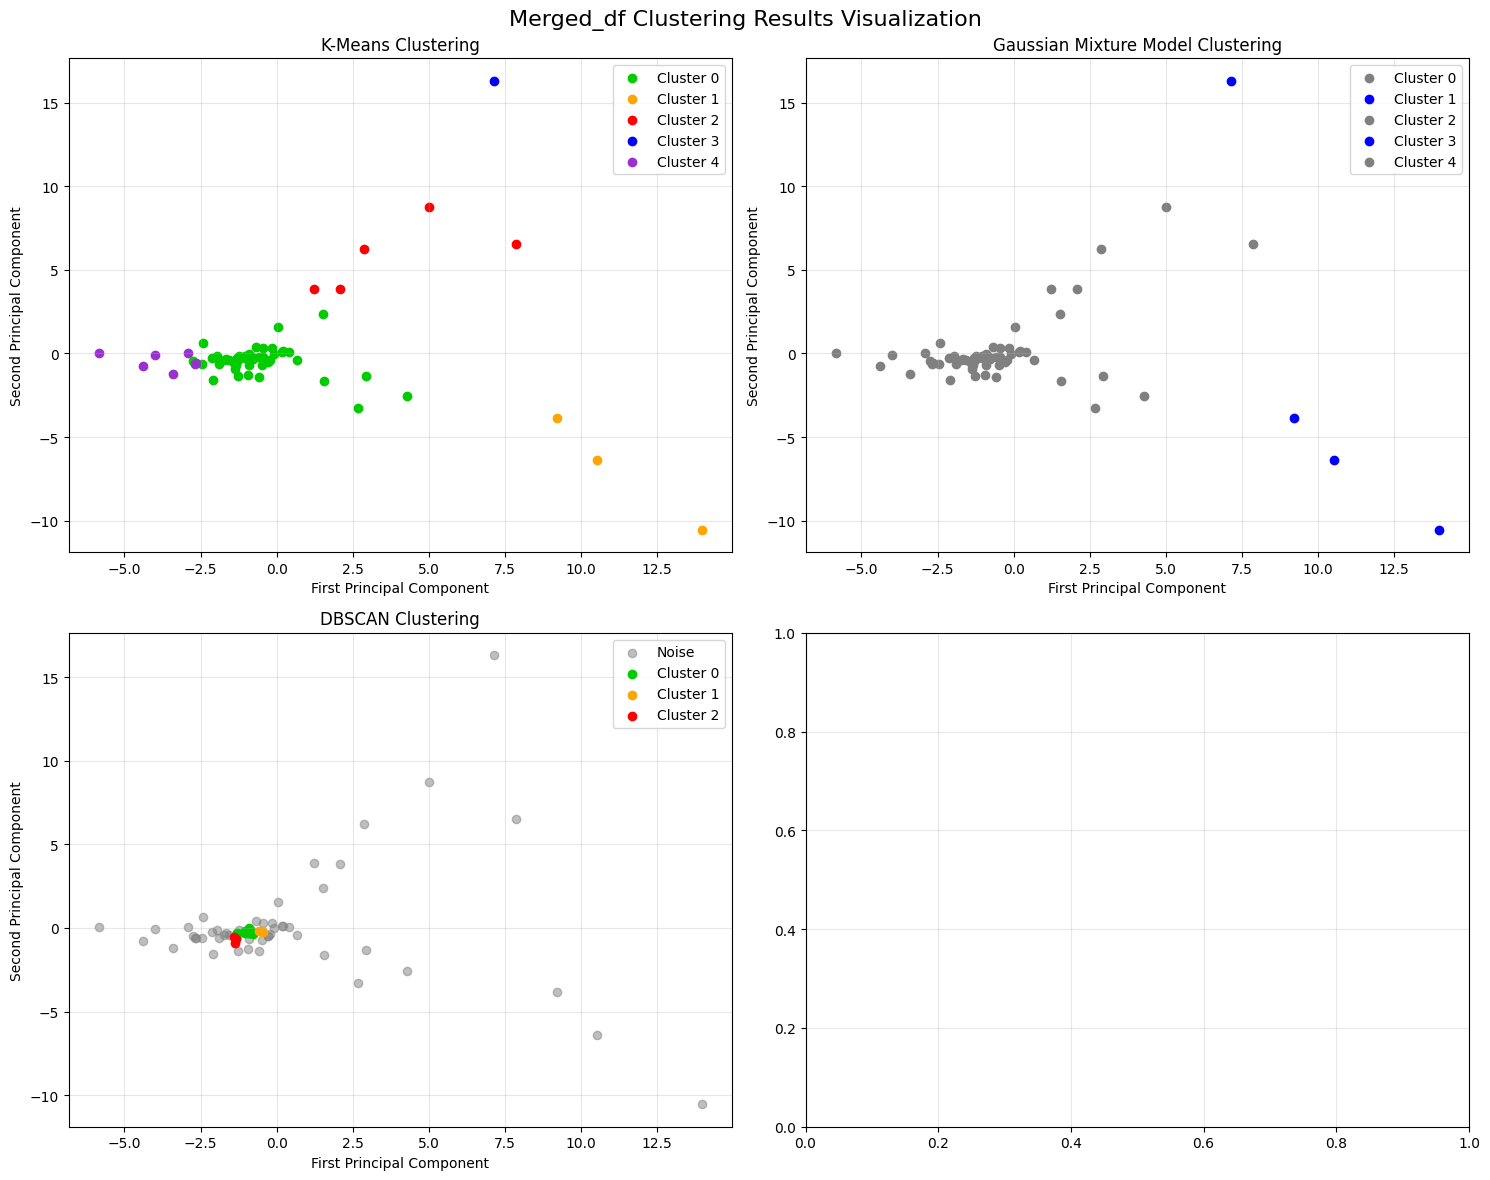


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 17.7219
Silhouette Score: 0.6177173859289772
Davies-Bouldin Score: 0.48830412743550544
Adjusted Rand Score: 0.13827978089776674

Cluster Sizes:
Cluster 0: 54 points
Cluster 1: 3 points
Cluster 2: 5 points
Cluster 3: 1 points
Cluster 4: 7 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 10.4012
Silhouette Score: 0.4791307787033332
Davies-Bouldin Score: 0.6362146750007748
Adjusted Rand Score: -0.009461744495670797

Cluster Sizes:
Cluster 0: 12 points
Cluster 1: 3 points
Cluster 2: 3 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 16.5262
Silhouette Score: 0.3045191222504631
Davies-Bouldin Score: 0.9781410127657413
Adjusted Rand Score: 0.0497157842385699

Cluster Sizes:
Cluster 0: 37 points
Cluster 1: 3 points
Cluster 2: 7 points
Cluster 3: 1 points
Cluster 4: 22 points

PCA Explained Variance Ratio:
PC1: 7.50%
PC2: 6.62%
PC3: 5.52%
Total Variance Explained (first 10 P

In [91]:
# Running pipeline
results_Merged_df_cluster = clustering_pipeline_all(Merged_df ,  pca_data_name='pca_data_Merged_df',
                                                    n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_Merged_df_cluster, title_prefix='Merged_df')
print_clustering_metrics(results_Merged_df_cluster)

## 11.11 Clusterin of core_taxa df

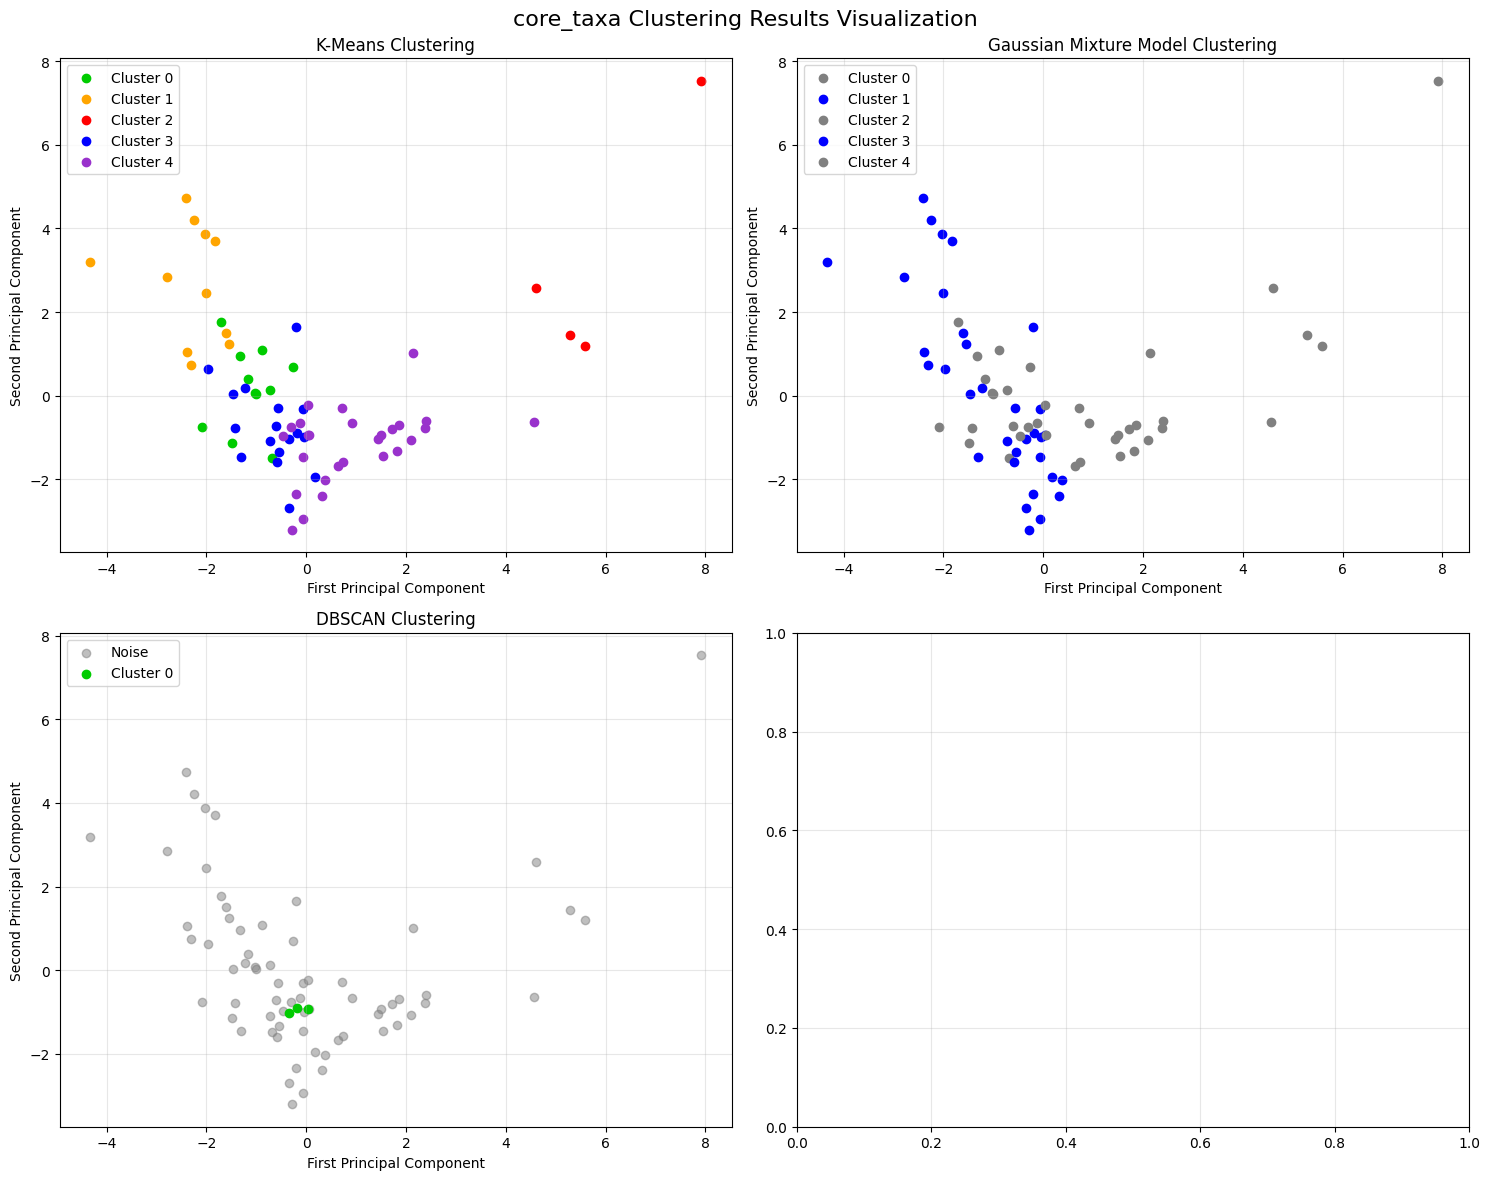


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 10.5079
Silhouette Score: 0.3164079407821179
Davies-Bouldin Score: 0.9295694581901743
Adjusted Rand Score: 0.014290135500625698

Cluster Sizes:
Cluster 0: 11 points
Cluster 1: 11 points
Cluster 2: 4 points
Cluster 3: 17 points
Cluster 4: 27 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 10.2736
Silhouette Score: Not applicable
Davies-Bouldin Score: Not applicable
Adjusted Rand Score: -0.003167486330352393

Cluster Sizes:
Cluster 0: 3 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 10.5069
Silhouette Score: 0.2805646311839628
Davies-Bouldin Score: 1.0039454077623546
Adjusted Rand Score: 0.030719666972108085

Cluster Sizes:
Cluster 0: 11 points
Cluster 1: 15 points
Cluster 2: 4 points
Cluster 3: 18 points
Cluster 4: 22 points

PCA Explained Variance Ratio:
PC1: 7.00%
PC2: 6.04%
PC3: 4.85%
Total Variance Explained (first 10 PCs): 17.88%


In [92]:
# Running pipeline
results_core_taxa_cluster = clustering_pipeline_all(core_taxa ,  pca_data_name='pca_data_core_taxa',
                                                    n_clusters=5, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_core_taxa_cluster, title_prefix='core_taxa')
print_clustering_metrics(results_core_taxa_cluster)

## 11.12 Model Convergence
The RandomForest classifier's predictions stabilize through training iterations, indicating convergence when predictions stop changing significantly.

In [93]:
def check_model_convergence(df, feature_scores, threshold=0.01):
    """Check if feature selection is stable across iterations"""
    prev_scores = None

    for i in range(10):
        # Get current feature scores
        new_scores = []
        for feat in df.columns[1:]:  # Skip Category
            scores = []
            for cat in [1,2,3]:
                try:
                    score = calculate_category_scores(feat, df, cat)
                    scores.append(score)
                except ValueError:
                    scores.append(0)
            new_scores.append(np.mean(scores))

        if prev_scores is not None:
            delta = np.abs(new_scores - prev_scores).max()
            if delta < threshold:
                return True, i

        prev_scores = np.array(new_scores)

    return False, 10

 All dataframes tested (Influencers_OLS, Influencers_uniques, Merged_selected, and high_loadings) showed convergence in their classification metrics, confirming model stability. This simple convergence check validates the reliability of our classification results.

In [94]:
convergence_Merged_selected = check_model_convergence(Merged_selected, Merged_selected_feature_scores, threshold=0.01)
convergence_Influencers_uniques_selected = check_model_convergence(Influencers_uniques_selected, Influencers_uniques_selected_feature_scores, threshold=0.01)
#convergence_high_loadings = check_model_convergence(high_loadings, high_loadings_feature_scores, threshold=0.01)
convergence_original_pca = check_model_convergence(original, original_pca_feature_scores, threshold=0.01)

print(convergence_Merged_selected, convergence_Influencers_uniques_selected, convergence_original_pca)# convergence_high_loadings)

(True, 1) (True, 1) (True, 1)


# 12. Clustering 3D Model df Influencers_uniques

In [95]:
# umpack data from results
pca_data = results_influencers_uniques_cluster[f'pca_data_influencers_uniques']
scaled_data = results_influencers_uniques_cluster['scaled_data']

# Now create the 3D plot
pc1 = pca_data[:, 0]
pc2 = pca_data[:, 1]
pc3 = pca_data[:, 2]

# Rest of your plotting code
fig = go.Figure(data=[
    go.Scatter3d(
        x=pc1,
        y=pc2,
        z=pc3,
        mode='markers',
        marker=dict(
            size=5,
            color=Influencers_uniques['Category'],
            colorscale='Viridis',
            opacity=0.8
        ),
        text=Influencers_uniques['Category']
    )
])

# Set plot title and axis labels
fig.update_layout(
    title='Interactive 3D PCA Visualization',
    scene=dict(
        xaxis_title='PCA Dimension 1',
        yaxis_title='PCA Dimension 2',
        zaxis_title='PCA Dimension 3'
    ))

fig.show()

## 12.1. On the Category and Cluster Atribution
Upon inspection of the influencers_OLS with the clusters associated to the label on the PCA_RF_FImportance notebook, there is a consistent pattern and it is possible to distinguish three different regions on the exact place the categories are.  category 1 is a v shape that is intop of cat 2 which is in the middle and 3 form a lineal regression bewen 1 and 2 pca, so together form a y shape. it has a clear differenciation and I can see that cluster 1 is same as cat 3, cluster 2, 3 and 0 are cat 1 and that cluster 4 is cat 2. with no visual overlappings, unlikely with my labels which got at the end of the regression line of 3 an overlaping with the shape of the v. So if we were to distribute the cluster in this fashion, would be possible to say that the clustering is revealing consistent groupings that align with the original categorization:  

Category 1: Comprises clusters 0, 2, 3  (total 7 points)  
Category 2: Corresponds to cluster 4    (10 points)  
Category 3: Matches cluster 1           (53 points)  
The fact that there is a persistent structure on the shapes of all the dataframes

Ultimately PCA primarily captures linear variance and might not effectively group data by absolute values. It's more about capturing directional variance and relationships rather than precise value clustering. The method projects data onto principal components that maximize variance, which doesn't necessarily mean it's capturing granular value-based distinctions
# 13. Loadings: On the Mapping of Original Features to the PCA
the principal components are mathematical combinations of the original features. It is possible to try to "invert" the PCA transformation to understand which original features are most responsible for the observed clustering patterns.
One approach would be to examine the PCA loading vectors or the contribution of each feature to the principal components. This could help identify the key underlying characteristics that are driving the separation of the data points. Moreover the cluster boundaries identified by the clustering algorithms are not fixed, static regions. They depend on the distribution of the data points and the specific parameters of the clustering methods. This means that the cluster assignments for individual data points may change if the clustering is performed again with different parameters or on a different dataset. The clustering results provide insights into the overall structure of the data, but the specific cluster boundaries are not guaranteed to be static or definitive.

The PCA loading vectors represent the coefficients that define each principal component. They indicate the relative importance or contribution of each original feature to the corresponding principal component.
By analyzing the loading vectors, it is possible to understand which of the original features are most influential in driving the separation of the data points along the different principal components. Which is very combinient because I am about to decide the selected data from each one of the dfs Influencers_OLS, OLS_all and uniques_23_OLS. By loading the vectors and identifying the original variables that more contribute to the separation, it would help with the selection of the selected genera to implement the cross examination with the physicochemical variables. With this loadings dataframe it is possible to  analyse the relationship with the original features across the principal components, by: higher absolute values = feature importance or features that contrute the most to the separation of the data points. By understand the dimension of the PCAs, then similar loading size hint similar aspects of the data or sinergistic effects?. By connecting clusters loading vectors to the clustering patterns and features, to know which are the most relevant features.

## 13.1 Loadinds Calculations and Visualisation Scripts
Here the relationships between features and components are visualised and highlight the absolute values of the loading vectors, as they represent the magnitude of feature contributions. An additional artifact is the category column.

In [96]:
def calculate_and_analyze_pca_loadings(df, pca, scaled_data_key, output_prefix):
    """
    Calculate and analyze PCA loadings for a given dataset.

    Parameters:
    df (pandas.DataFrame): The original DataFrame.
    pca (sklearn.decomposition.PCA): The PCA object from a previous analysis.
    scaled_data_key (str): The key in the results dictionary that holds the scaled data.
    output_prefix (str): A prefix for the output variables to ensure uniqueness.

    Returns:
    A dictionary containing the following keys:
    - f"{output_prefix}_loadings_df": The DataFrame of loading vectors.
    - f"{output_prefix}_top_loadings": A dictionary of top contributors for each principal component.
    - f"{output_prefix}_top_loadings_df": DataFrame of top contributors with categories.
    """
    loadings = pca.components_.T

    feature_columns = [col for col in df.columns if col != 'Category']

    loadings_df = pd.DataFrame(loadings, index=df.columns[1:],  # Feature column headers (numeric after 'Category')
                    columns=[f'PC{i+1}' for i in range(loadings.shape[1])])

    # Map categories by identifying their contribution strength for features
    # Add category weights
    category_weights = {1: 0.091, 2: 0.45, 3: 0.45}
    feature_categories = {}
    for feature in feature_columns:
        cat_means = {
            cat: df[df['Category'] == cat][int(feature)].mean() * category_weights[cat]
            for cat in [1, 2, 3]
        }
        feature_categories[feature] = max(cat_means.items(), key=lambda x: x[1])[0]

    # Identify top contributors to each principal component
    def get_top_loadings(loadings_df, n_top=10):
        top_loadings = {}
        for col in loadings_df.columns:
            top_loadings[col] = loadings_df[col].abs().nlargest(n_top)
        return top_loadings

    top_loadings = get_top_loadings(loadings_df)
    # Convert top_loadings to DataFrame and add category info

    top_loadings_df = pd.concat([pd.Series(loadings, name=pc) for pc,
                                 loadings in top_loadings.items()], axis=1)

    top_loadings_df.index.name = 'Feature'

    # Add these categories as a column in the top loadings DataFrame
    top_loadings_df['Category'] = pd.Series(feature_categories)

    # Store all results
    results = {
        f"{output_prefix}_loadings_df": loadings_df,
        f"{output_prefix}_top_loadings": top_loadings,
        f"{output_prefix}_top_loadings_df": top_loadings_df}  # Adding the categorized DataFrame

    return results

def plot_top_pca_loadings(results_dict, output_prefix, max_features=20, figsize=(10, 8)):
    """
    Plot a heatmap of top PCA loadings for given results.

    Parameters:
    - results_dict (dict): Results dictionary from calculate_and_analyze_pca_loadings.
    - output_prefix (str): Prefix for accessing correct results keys.
    - max_features (int): Max number of features to visualize for clarity.
    - figsize (tuple): Figure size for the heatmap.
    """
    top_loadings_df = results_dict[f"{output_prefix}_top_loadings_df"]
    top_n_features = top_loadings_df.iloc[:max_features, :-1]

    plt.figure(figsize=figsize)
    sns.heatmap(
        top_n_features, annot=True, cmap="coolwarm", center=0,
        cbar_kws={'label': 'Loading Magnitude'})

    plt.yticks(
        range(len(top_n_features)),
        [f"{idx} (Cat {cats})" for idx, cats in zip(top_loadings_df.index[:max_features], top_loadings_df['Category'][:max_features])],
        rotation=0
    )
    plt.title(f"Top PCA Loadings for {output_prefix}")
    plt.tight_layout()
    plt.show()

Calling the function to calculate and analyse the pca loadings for the dfs
## 13.2. original_pca Pca Loadings

Explained Variance Ratio: [0.13725964 0.09506145 0.08919483]
Cumulative Variance Ratio: [0.13725964 0.23232109 0.32151592]

Loading Vectors:
        PC1     PC2     PC3
155 -0.0499  0.2044  0.0029
1   -0.0266 -0.0228  0.0683
337  0.2023  0.0152  0.0752
875  0.3551  0.0709  0.0912
145 -0.0519 -0.0859  0.2091
535 -0.0475 -0.1679  0.3294
96   0.3504  0.0678  0.0870
549  0.1442 -0.0220  0.0265
564  0.1271 -0.0249 -0.1093
300 -0.0620  0.2276  0.0549

Top Contributors to Principal Components:

PC1 Top Contributors:
591   0.3594
875   0.3551
379   0.3541
96    0.3504
516   0.3493
388   0.3237
465   0.2268
337   0.2023
254   0.1909
716   0.1649
Name: PC1, dtype: float64

PC2 Top Contributors:
41    0.3510
151   0.3294
474   0.3164
270   0.2691
194   0.2488
584   0.2400
300   0.2276
687   0.2077
155   0.2044
526   0.1825
Name: PC2, dtype: float64

PC3 Top Contributors:
339   0.3427
535   0.3294
172   0.3112
563   0.3037
195   0.2428
245   0.2191
127   0.2170
243   0.2148
145   0.2091
330   0.18

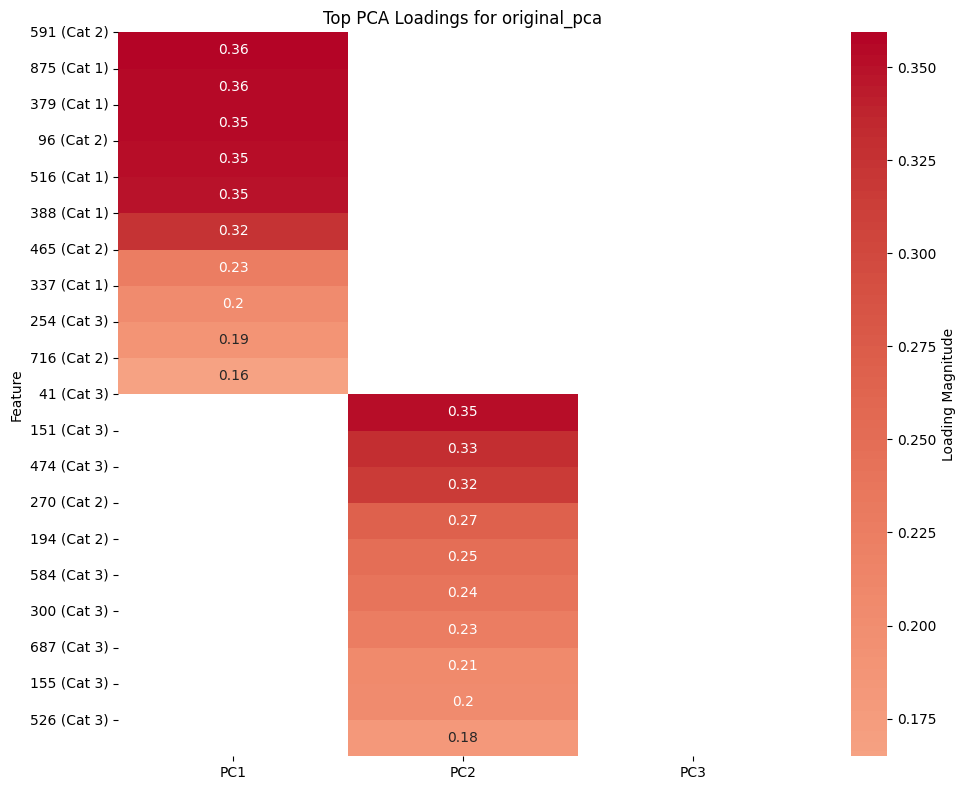

In [97]:
# We taking the data from the previous algoritms results
pca = results_original_pca_cluster['pca']
scaled_data = results_original_pca_cluster['scaled_data']
# Loadings calculation call
results_original_pca_Loadings = calculate_and_analyze_pca_loadings(original_pca, pca, 'scaled_data', 'original_pca')

# Access the results
loadings_df = results_original_pca_Loadings['original_pca_loadings_df']
explained_variance = results_original_pca_cluster['explained_variance']
cumulative_variance = results_original_pca_cluster['cumulative_variance']
top_loadings = results_original_pca_Loadings['original_pca_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components:")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings with category analysis (double heatmap):
plot_top_pca_loadings(results_original_pca_Loadings, 'original_pca')

### Discussing original_pca
The results show that some of the features overlap other such is 456. This feature wont be of much help when identifying the relevant bacteria influencing corrosion because it belong to two different categories. We need to make a script to select this features out.

## 13.3. uniques_pca Loadings

Explained Variance Ratio: [0.12020013 0.08747292 0.08366257]
Cumulative Variance Ratio: [0.12020013 0.20767306 0.29133563]

Loading Vectors:
        PC1     PC2     PC3
704 -0.0074 -0.0059 -0.0087
87  -0.0074 -0.0059 -0.0087
696 -0.0074 -0.0059 -0.0087
160 -0.0074 -0.0059 -0.0087
238 -0.0067 -0.0048 -0.0068
442 -0.0061 -0.0043 -0.0062
26  -0.0079 -0.0063 -0.0092
176 -0.0075 -0.0061 -0.0088
33  -0.0091 -0.0069 -0.0100
680 -0.0093 -0.0084 -0.0127

Top Contributors to Principal Components:

PC1 Top Contributors:
499   0.4069
50    0.4069
446   0.4069
142   0.4069
642   0.4069
580   0.4061
78    0.0276
636   0.0198
872   0.0198
225   0.0198
Name: PC1, dtype: float64

PC2 Top Contributors:
636   0.4521
872   0.4521
225   0.4521
104   0.4521
494   0.2881
382   0.1305
576   0.1305
239   0.1305
856   0.1305
190   0.0877
Name: PC2, dtype: float64

PC3 Top Contributors:
856   0.3931
382   0.3931
576   0.3931
239   0.3931
598   0.2492
294   0.2492
595   0.2492
730   0.2492
190   0.2184
511   0.11

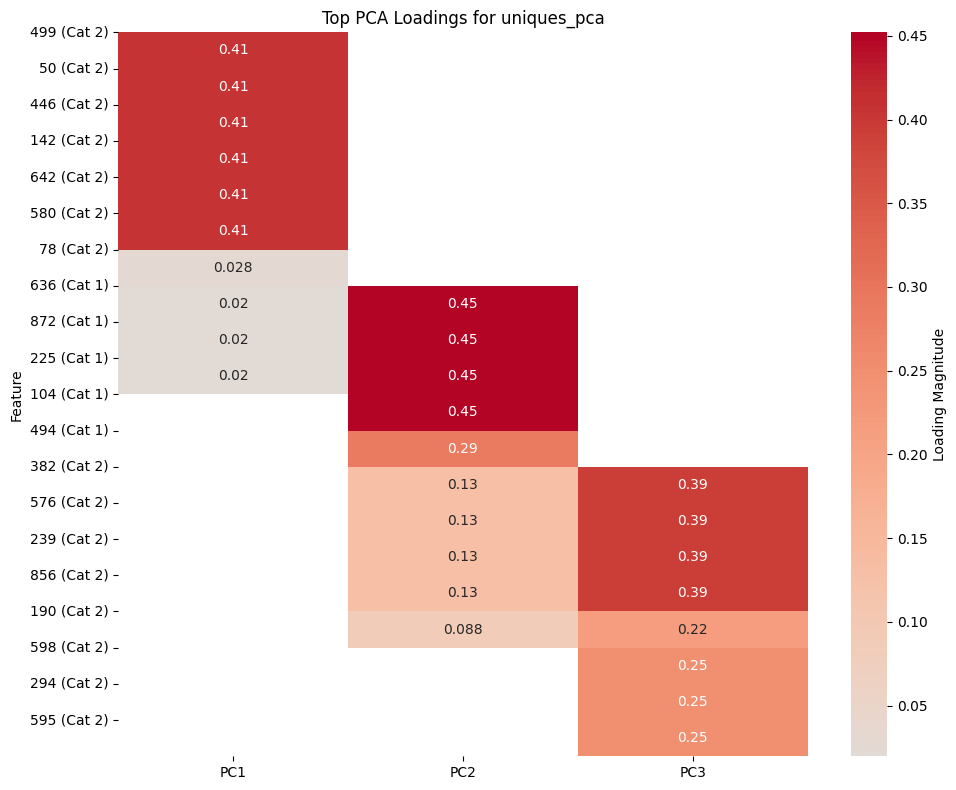

In [98]:
# We taking the data from the previous algoritms results
pca = results_uniques_pca_cluster['pca']
scaled_data = results_uniques_pca_cluster['scaled_data']
# Loadings calculation call
results_uniques_pca_Loadings = calculate_and_analyze_pca_loadings(uniques_pca, pca, 'scaled_data', 'uniques_pca')

# Access the results
loadings_df = results_uniques_pca_Loadings['uniques_pca_loadings_df']
explained_variance = results_uniques_pca_cluster['explained_variance']
cumulative_variance = results_uniques_pca_cluster['cumulative_variance']
top_loadings = results_uniques_pca_Loadings['uniques_pca_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components:")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings with category analysis (double heatmap):
plot_top_pca_loadings(results_uniques_pca_Loadings, 'uniques_pca')

## 13.4. uniques23_pca Loadings Analysis

Explained Variance Ratio: [0.13943014 0.10226628 0.09517841]
Cumulative Variance Ratio: [0.13943014 0.24169642 0.33687483]

Loading Vectors:
        PC1     PC2     PC3
727 -0.0351 -0.2475  0.3131
300  0.1677  0.0008  0.0150
678 -0.0220 -0.0721  0.0318
687  0.1723  0.0376  0.0342
465 -0.0560 -0.0626 -0.0910
270  0.2247  0.0022 -0.0024
564 -0.0671 -0.2978  0.2857
194  0.2102 -0.0082  0.0097
13  -0.0504 -0.2756  0.3307
18   0.2570 -0.0355 -0.0119

Top Contributors to Principal Components:

PC1 Top Contributors:
41    0.3183
151   0.3138
474   0.3087
663   0.2930
18    0.2570
584   0.2477
542   0.2401
574   0.2388
270   0.2247
194   0.2102
Name: PC1, dtype: float64

PC2 Top Contributors:
265   0.3149
413   0.3132
720   0.3057
564   0.2978
512   0.2895
736   0.2792
187   0.2782
13    0.2756
44    0.2642
727   0.2475
Name: PC2, dtype: float64

PC3 Top Contributors:
187   0.3362
736   0.3361
13    0.3307
727   0.3131
564   0.2857
512   0.2766
413   0.2653
265   0.2614
720   0.2577
408   0.21

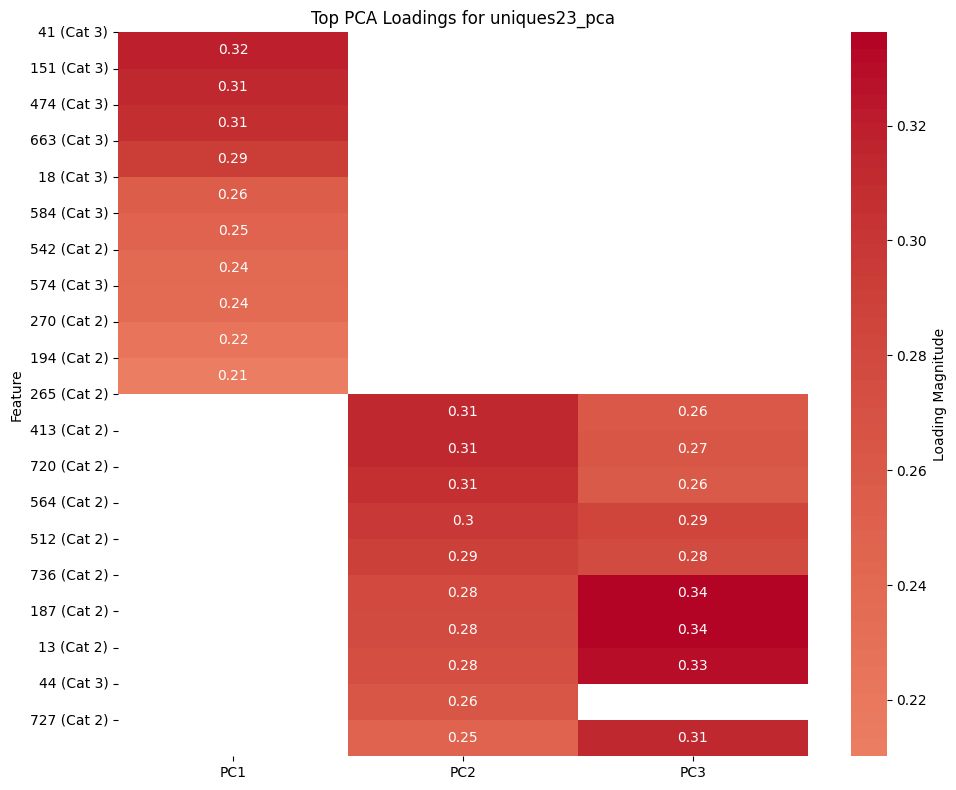

In [99]:
# We taking the data from the previous algoritms results
pca = results_uniques23_pca_cluster['pca']
scaled_data = results_uniques23_pca_cluster['scaled_data']
# Loadings calculation call
results_uniques23_pca_Loadings = calculate_and_analyze_pca_loadings(uniques23_pca, pca, 'scaled_data', 'uniques23_pca')

# Access the results
loadings_df = results_uniques23_pca_Loadings['uniques23_pca_loadings_df']
explained_variance = results_uniques23_pca_cluster['explained_variance']
cumulative_variance = results_uniques23_pca_cluster['cumulative_variance']
top_loadings = results_uniques23_pca_Loadings['uniques23_pca_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components:")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings with category analysis (double heatmap):
plot_top_pca_loadings(results_uniques23_pca_Loadings, 'uniques23_pca')

## 13.5. OLS_all pca Loadings

Explained Variance Ratio: [0.2638891  0.20004687 0.10142031]
Cumulative Variance Ratio: [0.2638891  0.46393598 0.56535629]

Loading Vectors:
        PC1     PC2     PC3
141  0.2840 -0.0625 -0.0055
494  0.1723  0.0784 -0.3073
410  0.0020  0.0995  0.0218
214 -0.0522 -0.0472 -0.0447
334  0.1016 -0.0172  0.3010
201 -0.0335 -0.0313 -0.0208
480  0.3019 -0.0452 -0.0188
416  0.2274 -0.0512  0.0481
565  0.0309  0.3154 -0.1330
428  0.1394  0.1998  0.3094

Top Contributors to Principal Components:

PC1 Top Contributors:
426   0.3066
712   0.3021
480   0.3019
871   0.3014
625   0.2957
90    0.2941
100   0.2933
141   0.2840
657   0.2566
416   0.2274
Name: PC1, dtype: float64

PC2 Top Contributors:
725   0.3612
424   0.3485
605   0.3200
565   0.3154
488   0.3046
541   0.2958
23    0.2929
445   0.2890
88    0.2860
428   0.1998
Name: PC2, dtype: float64

PC3 Top Contributors:
79    0.3829
549   0.3383
337   0.3365
428   0.3094
494   0.3073
334   0.3010
678   0.2264
871   0.2186
625   0.2185
712   0.21

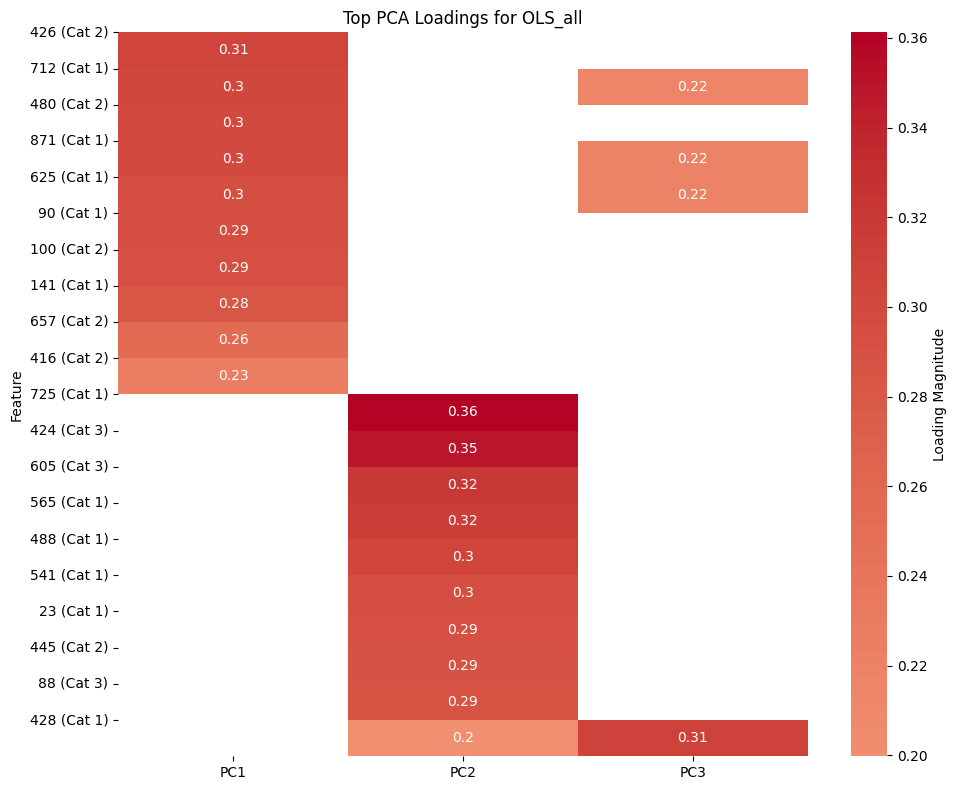

In [100]:
# We taking the data from the previous algoritms results
pca = results_OLS_all_cluster['pca']
scaled_data = results_OLS_all_cluster['scaled_data']
# Loadings calculation call
results_OLS_all_Loadings = calculate_and_analyze_pca_loadings(OLS_all, pca, 'scaled_data', 'OLS_all')

# Access the results
loadings_df = results_OLS_all_Loadings['OLS_all_loadings_df']
explained_variance = results_OLS_all_cluster['explained_variance']
cumulative_variance = results_OLS_all_cluster['cumulative_variance']
top_loadings = results_OLS_all_Loadings['OLS_all_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components:")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings with category analysis (double heatmap):
plot_top_pca_loadings(results_OLS_all_Loadings, 'OLS_all')

Discussing OLS_all
This dataframe is composed by the significant genera by OLS analysis on the whole data and interestingly doesnt have any feature that belong to the category 2. The genera presenting strong contributions 565, 23, 725, 605, 799, 771, 410, all belong to the category 1 and the rest to category 3. 140, 214, 229

## 13.6. Influencers_OLS Pca Loadings

Explained Variance Ratio: [0.22794475 0.1969927  0.11274398]
Cumulative Variance Ratio: [0.22794475 0.42493745 0.53768143]

Loading Vectors:
        PC1     PC2     PC3
725  0.4025  0.0510 -0.0128
625 -0.0913  0.5341 -0.1927
565  0.4672  0.0678 -0.0423
23   0.4944  0.0725 -0.0488
526 -0.0606 -0.0882 -0.2482
214 -0.0667 -0.1017 -0.3158
334 -0.0364  0.1284  0.4711
351  0.2915  0.0228 -0.0424
408 -0.0518 -0.0720 -0.0986
712 -0.0910  0.5355 -0.1883

Top Contributors to Principal Components:

PC1 Top Contributors:
23    0.4944
565   0.4672
864   0.4143
725   0.4025
351   0.2915
375   0.2781
625   0.0913
712   0.0910
871   0.0907
214   0.0667
Name: PC1, dtype: float64

PC2 Top Contributors:
712   0.5355
871   0.5349
625   0.5341
549   0.2420
334   0.1284
678   0.1248
214   0.1017
526   0.0882
229   0.0879
23    0.0725
Name: PC2, dtype: float64

PC3 Top Contributors:
549   0.4868
334   0.4711
678   0.4234
214   0.3158
229   0.2674
526   0.2482
625   0.1927
871   0.1914
712   0.1883
408   0.09

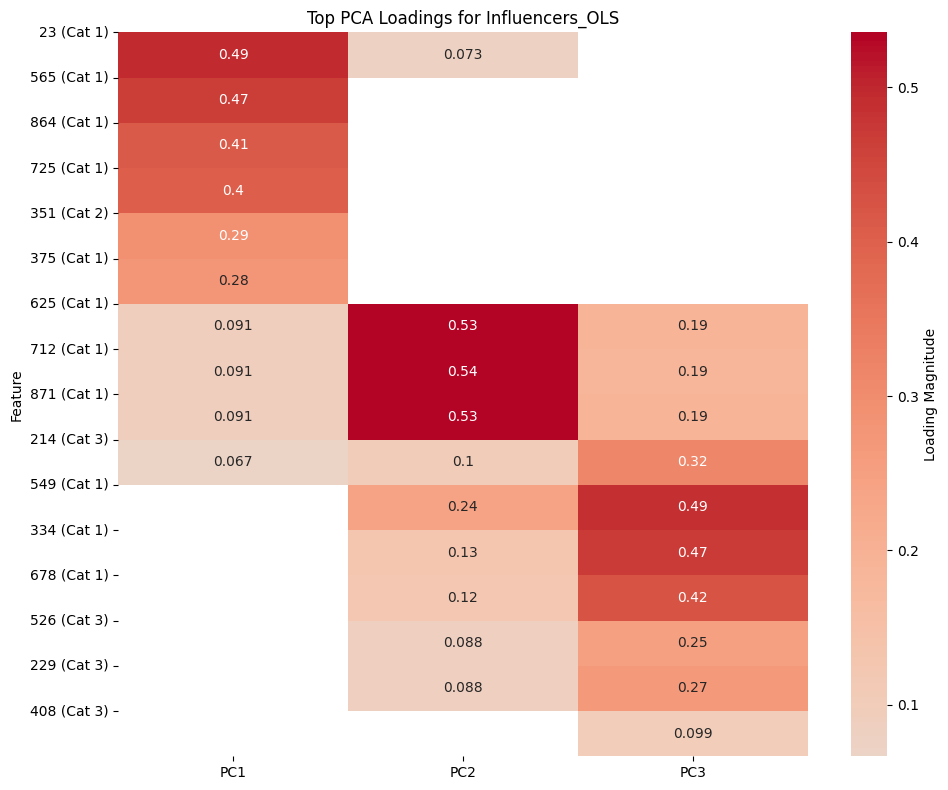

In [101]:
# We taking the data from the previous algoritms results
pca = results_Influencers_OLS_cluster['pca']
scaled_data = results_Influencers_OLS_cluster['scaled_data']
# Loadings calculation call
results_Influencers_OLS_Loadings = calculate_and_analyze_pca_loadings(Influencers_OLS, pca, 'scaled_data', 'Influencers_OLS')

# Access the results
loadings_df = results_Influencers_OLS_Loadings['Influencers_OLS_loadings_df']
explained_variance = results_Influencers_OLS_cluster['explained_variance']
cumulative_variance = results_Influencers_OLS_cluster['cumulative_variance']
top_loadings = results_Influencers_OLS_Loadings['Influencers_OLS_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components:")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings on a simple heatmap
plot_top_pca_loadings(results_Influencers_OLS_Loadings, 'Influencers_OLS')

### Influencers_OLS Discussing
Top contributors for PC1 and PC2 are seen. These contributions suggest which original variables drive the variance along each principal axis. Loading values indicate the weight or influence of a feature on a principal component. In for Influencers_OLS feature 23 contributes 0,48 to PC1 and feature 712 contributes 0.499 to PC2.  
When puting 7 components the total explained variance ratio of the first 7 PCs is 74.19%.   
Strong contribution from PC1 to PC3. Cumulative explained variance achieves a balance of high dimensionality reduction with a reasonable representation. Total explained variance ratio of the first 7 PCs is 68.38%.
Reduced explained variance suggests the additional features do not significantly improve variance representation. In fact, they dilute the strength of the first PCs.
## 13.7. Influencers_uniques pca Loadings

Explained Variance Ratio: [0.22489289 0.16946513 0.11007372]
Cumulative Variance Ratio: [0.22489289 0.39435802 0.50443175]

Loading Vectors:
        PC1     PC2     PC3
725  0.3467 -0.1455  0.2232
625  0.0931  0.4985  0.0871
565  0.4190 -0.0928 -0.1603
23   0.4204 -0.1092 -0.1000
526 -0.0609 -0.0380 -0.0863
214 -0.0667 -0.0441 -0.1095
334 -0.0080  0.1011  0.0930
351  0.2401 -0.0608 -0.2146
408 -0.0596 -0.0367 -0.0781
712  0.0929  0.5013  0.0781

Top Contributors to Principal Components: Influencers_uniques

PC1 Top Contributors:
23    0.4204
565   0.4190
541   0.3842
725   0.3467
864   0.3404
494   0.2730
351   0.2401
375   0.2260
228   0.1474
410   0.1212
Name: PC1, dtype: float64

PC2 Top Contributors:
712   0.5013
871   0.4997
625   0.4985
494   0.3128
549   0.1840
725   0.1455
375   0.1313
228   0.1204
23    0.1092
334   0.1011
Name: PC2, dtype: float64

PC3 Top Contributors:
375   0.4881
228   0.4720
410   0.4332
541   0.2595
725   0.2232
351   0.2146
864   0.1891
565   0.1603
494

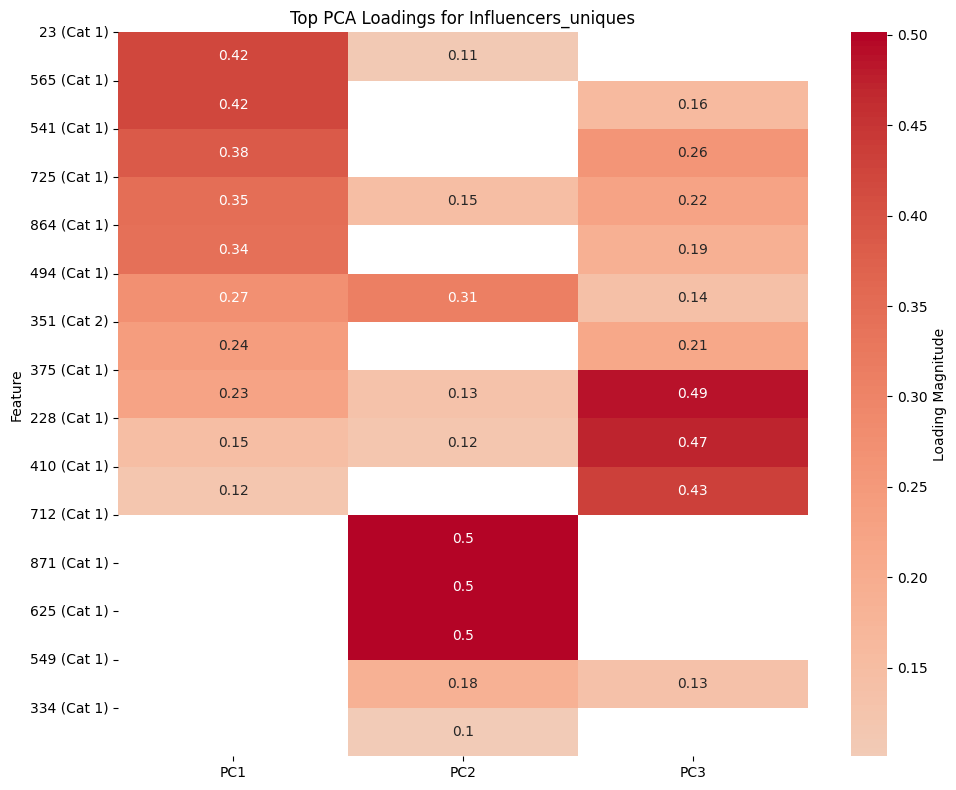

In [102]:
# We taking the data from the previous algoritms results
pca = results_influencers_uniques_cluster['pca']
scaled_data = results_influencers_uniques_cluster['scaled_data']
# Loadings calculation call
results_influencers_uniques_Loadings = calculate_and_analyze_pca_loadings(Influencers_uniques, pca,
                                                                 'scaled_data', 'Influencers_uniques')
# Access the results
loadings_df = results_influencers_uniques_Loadings['Influencers_uniques_loadings_df']
explained_variance = results_influencers_uniques_cluster['explained_variance']
cumulative_variance = results_influencers_uniques_cluster['cumulative_variance']
top_loadings = results_influencers_uniques_Loadings['Influencers_uniques_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components: Influencers_uniques")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings on a simple heatmap
plot_top_pca_loadings(results_influencers_uniques_Loadings, 'Influencers_uniques')

### Discussing Influencers_uniques Pca Loadings
present still a dominance on cat 1
## 13.8. Merged_selected Pca Loadings

Explained Variance Ratio: [0.21165088 0.18685015 0.14503919]
Cumulative Variance Ratio: [0.21165088 0.39850103 0.54354022]

Loading Vectors:
        PC1     PC2     PC3
238 -0.0369  0.0122 -0.0661
201  0.4496 -0.4533  0.1646
211  0.4546 -0.4709  0.1691
549 -0.0904  0.0495 -0.0576
680  0.4808  0.5171  0.0503
649  0.5028  0.4912  0.0592
541 -0.1258  0.0604  0.6706
704 -0.0553  0.0239  0.1366
445 -0.1653  0.0746  0.6789
491  0.2267 -0.2275 -0.0369

Top Contributors to Principal Components:

PC1 Top Contributors:
649   0.5028
680   0.4808
211   0.4546
201   0.4496
491   0.2267
445   0.1653
541   0.1258
549   0.0904
704   0.0553
238   0.0369
Name: PC1, dtype: float64

PC2 Top Contributors:
680   0.5171
649   0.4912
211   0.4709
201   0.4533
491   0.2275
445   0.0746
541   0.0604
549   0.0495
704   0.0239
238   0.0122
Name: PC2, dtype: float64

PC3 Top Contributors:
445   0.6789
541   0.6706
211   0.1691
201   0.1646
704   0.1366
238   0.0661
649   0.0592
549   0.0576
680   0.0503
491   0.03

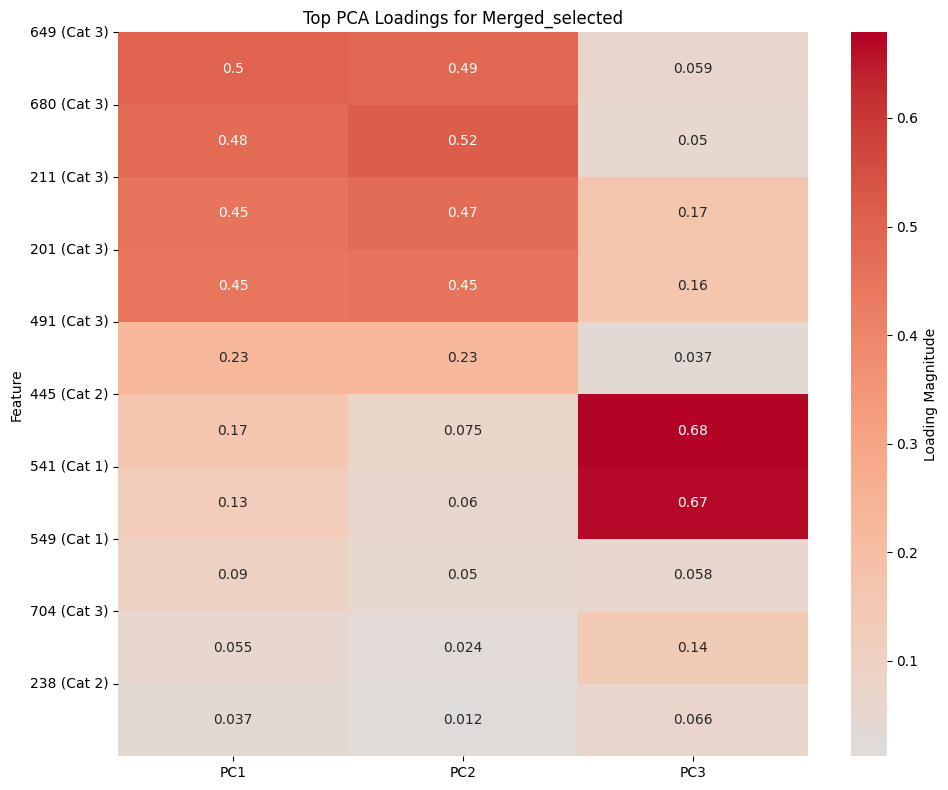

In [103]:
# We taking the data from the previous algoritms results
pca = results_Merged_selected_cluster['pca']
scaled_data = results_Merged_selected_cluster['scaled_data']
# Loadings calculation call
results_Merged_selected_Loadings = calculate_and_analyze_pca_loadings(Merged_selected, pca, 'scaled_data', 'Merged_selected')

# Access the results
loadings_df = results_Merged_selected_Loadings['Merged_selected_loadings_df']
explained_variance = results_Merged_selected_cluster['explained_variance']
cumulative_variance = results_Merged_selected_cluster['cumulative_variance']
top_loadings = results_Merged_selected_Loadings['Merged_selected_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components:")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings on a simple heatmap
plot_top_pca_loadings(results_Merged_selected_Loadings, 'Merged_selected')

### Discussing Merged_selected
This df gives very strong signal for features 354 PC5 and also PC4. PC3 has some contributors such as 110, 491, 561, which could have some biological significance. Same for PC2 with 110, 549 and 18. PC1 could be represented only by 214, 140, 572 and 18.

## 13.9. old_new Loadings visualisation with category information

Explained Variance Ratio: [0.1522022  0.10808356 0.10036669]
Cumulative Variance Ratio: [0.1522022  0.26028576 0.36065245]

Loading Vectors:
        PC1     PC2     PC3
154  0.3708 -0.2065  0.0708
201  0.2220  0.1116  0.0221
214  0.4401 -0.1382  0.0430
229  0.5040 -0.2186  0.0893
334 -0.0631 -0.0411 -0.1595
351 -0.1332 -0.0589  0.5990
354 -0.1459 -0.1732  0.5315
408  0.2104  0.2478  0.1072
497  0.4150 -0.1251  0.0645
512  0.1000  0.5844  0.1608

Top Contributors to Principal Components:

PC1 Top Contributors:
229   0.5040
214   0.4401
497   0.4150
154   0.3708
201   0.2220
408   0.2104
584   0.2020
354   0.1459
351   0.1332
565   0.1280
Name: PC1, dtype: float64

PC2 Top Contributors:
512   0.5844
581   0.5607
606   0.2613
408   0.2478
229   0.2186
154   0.2065
354   0.1732
214   0.1382
583   0.1283
497   0.1251
Name: PC2, dtype: float64

PC3 Top Contributors:
351   0.5990
354   0.5315
565   0.3278
583   0.2972
621   0.1846
512   0.1608
334   0.1595
581   0.1417
625   0.1413
408   0.10

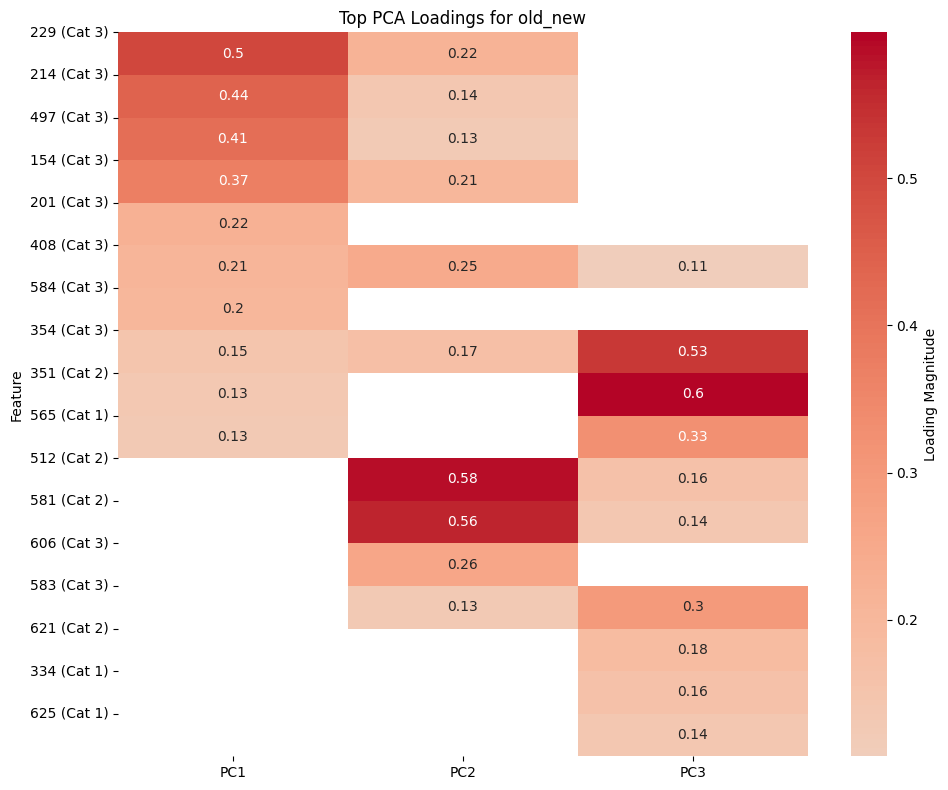

In [104]:
# We taking the data from the previous algoritms results
pca = results_old_new_cluster['pca']
scaled_data = results_old_new_cluster['scaled_data']
# Loadings calculation call
results_old_new_Loadings = calculate_and_analyze_pca_loadings(old_new, pca, 'scaled_data', 'old_new')

# Access the results
loadings_df = results_old_new_Loadings['old_new_loadings_df']
explained_variance = results_old_new_cluster['explained_variance']
cumulative_variance = results_old_new_cluster['cumulative_variance']
top_loadings = results_old_new_Loadings['old_new_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components:")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings on a simple heatmap
plot_top_pca_loadings(results_old_new_Loadings, 'old_new')

## 13.10. Influencers_uniques_selected Loadings visualisation with category information

Explained Variance Ratio: [0.22410467 0.15907021 0.11270928]
Cumulative Variance Ratio: [0.22410467 0.38317488 0.49588416]

Loading Vectors:
        PC1     PC2     PC3
526 -0.0575 -0.0788 -0.0508
351  0.2484 -0.0116 -0.2371
408 -0.0561 -0.0752 -0.0456
549  0.0029  0.2408  0.0536
229 -0.0554 -0.0799 -0.0570
214 -0.0631 -0.0919 -0.0665
864  0.3534  0.0108 -0.2220
625 -0.0163  0.5380  0.0122
375  0.2651 -0.0122  0.4957
334 -0.0225  0.1325  0.0367

Top Contributors to Principal Components:

PC1 Top Contributors:
23    0.4400
565   0.4321
725   0.3841
541   0.3772
864   0.3534
375   0.2651
351   0.2484
228   0.1822
410   0.1503
214   0.0631
Name: PC1, dtype: float64

PC2 Top Contributors:
712   0.5396
871   0.5390
625   0.5380
549   0.2408
334   0.1325
678   0.1264
214   0.0919
229   0.0799
526   0.0788
408   0.0752
Name: PC2, dtype: float64

PC3 Top Contributors:
375   0.4957
228   0.4914
410   0.4516
541   0.2925
351   0.2371
864   0.2220
725   0.2135
565   0.1870
23    0.1268
214   0.06

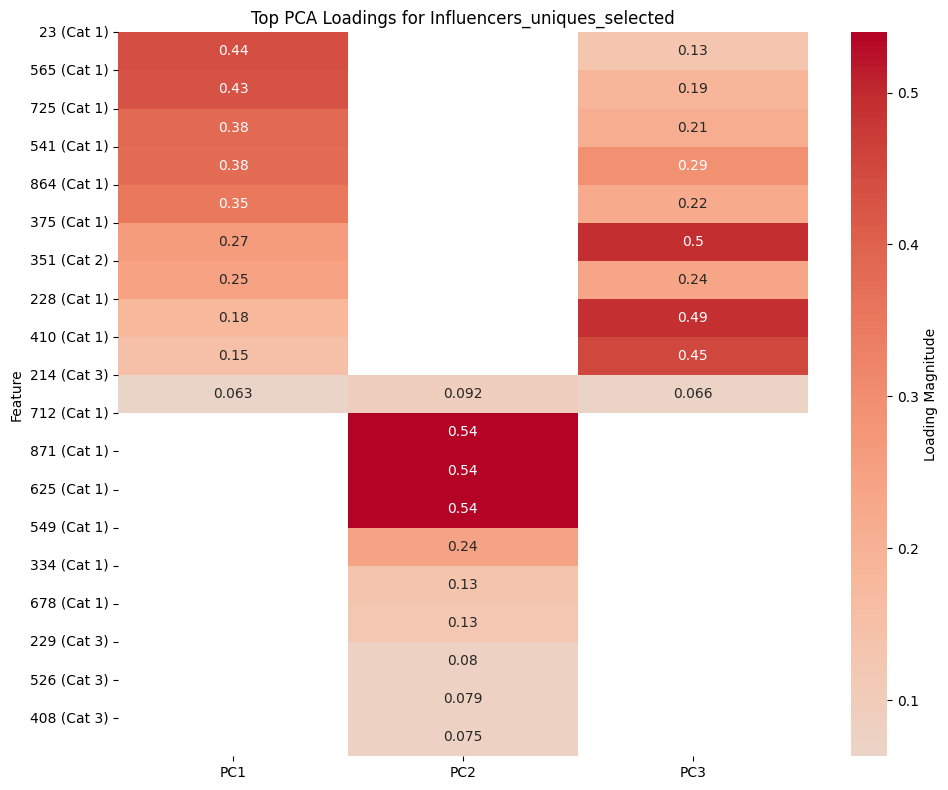

In [105]:
# We taking the data from the previous algoritms results
pca = results_Influencers_uniques_selected_cluster['pca']
scaled_data = results_Influencers_uniques_selected_cluster['scaled_data']
# Loadings calculation call
results_Influencers_uniques_selected_Loadings = calculate_and_analyze_pca_loadings(Influencers_uniques_selected, pca, 'scaled_data', 'Influencers_uniques_selected')

# Access the results
loadings_df = results_Influencers_uniques_selected_Loadings['Influencers_uniques_selected_loadings_df']
explained_variance = results_Influencers_uniques_selected_cluster['explained_variance']
cumulative_variance = results_Influencers_uniques_selected_cluster['cumulative_variance']
top_loadings = results_Influencers_uniques_selected_Loadings['Influencers_uniques_selected_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components:")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings on a simple heatmap
plot_top_pca_loadings(results_Influencers_uniques_selected_Loadings, 'Influencers_uniques_selected')

## 13.11. Merged_df Loadings

Explained Variance Ratio: [0.07503614 0.06617711 0.05516979]
Cumulative Variance Ratio: [0.07503614 0.14121325 0.19638304]

Loading Vectors:
        PC1     PC2     PC3
512 -0.0435 -0.0097 -0.0146
1   -0.0249 -0.0042  0.0025
2   -0.0181 -0.0056 -0.0352
516  0.0874  0.0824 -0.0242
13  -0.0223 -0.0058 -0.0593
526 -0.0182  0.0261  0.1138
529 -0.0179  0.0031 -0.0513
18   0.0267  0.0839  0.2570
535 -0.0272 -0.0224 -0.0127
23   0.0939  0.2429  0.0552

Top Contributors to Principal Components:

PC1 Top Contributors:
426   0.2302
480   0.2258
100   0.2129
657   0.2125
712   0.2100
871   0.2090
625   0.2056
141   0.2039
90    0.2001
416   0.1713
Name: PC1, dtype: float64

PC2 Top Contributors:
565   0.2528
605   0.2458
23    0.2429
541   0.2223
725   0.2142
636   0.2060
225   0.2060
872   0.2060
104   0.2060
424   0.2022
Name: PC2, dtype: float64

PC3 Top Contributors:
18    0.2570
151   0.2544
474   0.2528
41    0.2429
663   0.2337
584   0.1991
270   0.1875
574   0.1852
542   0.1808
229   0.16

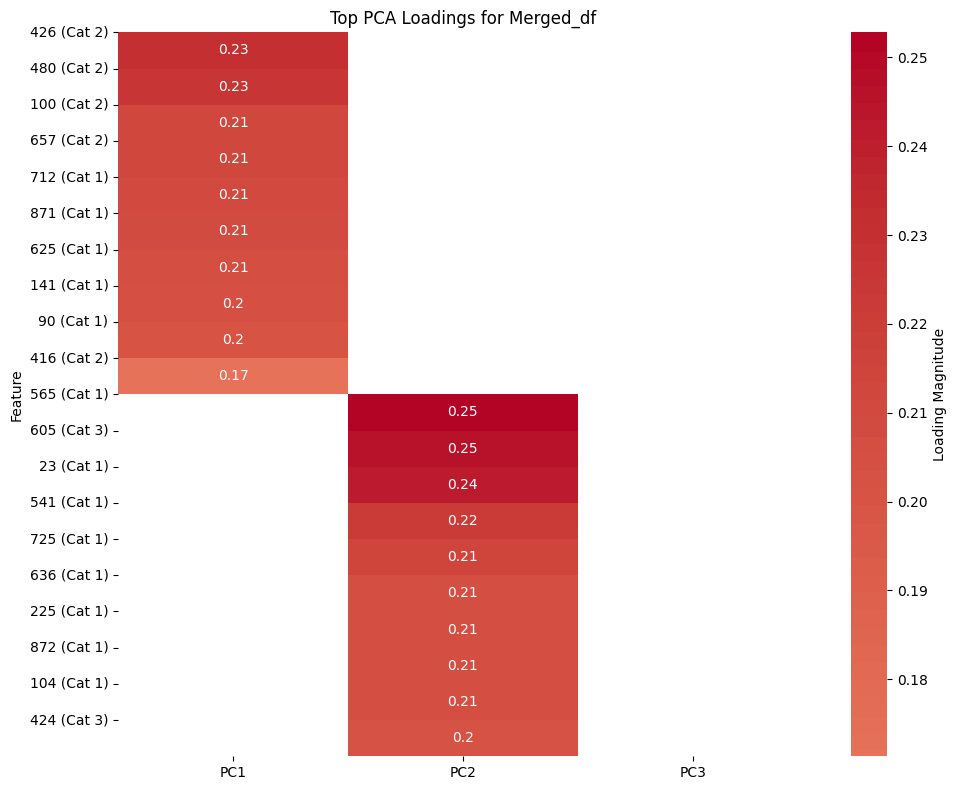

In [106]:
# We taking the data from the previous algoritms results
pca = results_Merged_df_cluster['pca']
scaled_data = results_Merged_df_cluster['scaled_data']
# Loadings calculation call
results_Merged_df_Loadings = calculate_and_analyze_pca_loadings(Merged_df, pca, 'scaled_data', 'Merged_df')

# Access the results
loadings_df = results_Merged_df_Loadings['Merged_df_loadings_df']
explained_variance = results_Merged_df_cluster['explained_variance']
cumulative_variance = results_Merged_df_cluster['cumulative_variance']
top_loadings = results_Merged_df_Loadings['Merged_df_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components:")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings on a simple heatmap
plot_top_pca_loadings(results_Merged_df_Loadings, 'Merged_df')

## 13.12 core_taxa Loadings Analysis

Explained Variance Ratio: [0.06998938 0.06036806 0.04846361]
Cumulative Variance Ratio: [0.06998938 0.13035744 0.17882105]

Loading Vectors:
        PC1     PC2     PC3
6   -0.0177 -0.0474  0.1233
7    0.0106 -0.0150  0.0193
13  -0.0123 -0.0403 -0.0076
17  -0.1098 -0.0919 -0.0383
29  -0.0018 -0.0992  0.0032
30  -0.0357  0.0076 -0.1450
89   0.0717 -0.0461  0.0071
110  0.0098 -0.1973  0.0204
113  0.1400  0.3697  0.0227
130 -0.0154 -0.0441 -0.0631

Top Contributors to Principal Components:

PC1 Top Contributors:
705   0.3427
687   0.3222
731   0.2784
229   0.2764
863   0.2622
206   0.2316
214   0.2290
660   0.2211
664   0.1878
143   0.1831
Name: PC1, dtype: float64

PC2 Top Contributors:
113   0.3697
462   0.2766
659   0.2501
206   0.2456
683   0.2438
705   0.2435
270   0.2418
664   0.2374
143   0.2056
110   0.1973
Name: PC2, dtype: float64

PC3 Top Contributors:
589   0.3210
550   0.2931
271   0.2903
143   0.2816
146   0.2574
683   0.2251
572   0.2090
462   0.2041
596   0.2003
198   0.19

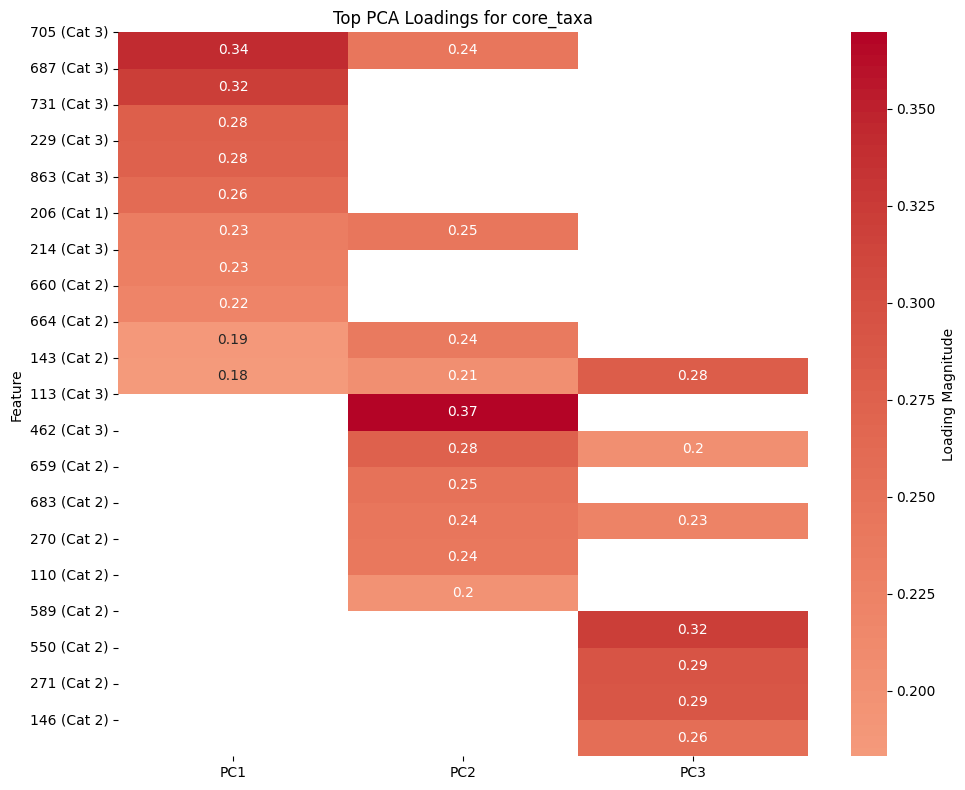

In [107]:
# We taking the data from the previous algoritms results
pca = results_core_taxa_cluster['pca']
scaled_data = results_core_taxa_cluster['scaled_data']
# Loadings calculation call
results_core_taxa_Loadings = calculate_and_analyze_pca_loadings(core_taxa, pca, 'scaled_data', 'core_taxa')

# Access the results
loadings_df = results_core_taxa_Loadings['core_taxa_loadings_df']
explained_variance = results_core_taxa_cluster['explained_variance']
cumulative_variance = results_core_taxa_cluster['cumulative_variance']
top_loadings = results_core_taxa_Loadings['core_taxa_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components:")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings on a simple heatmap
plot_top_pca_loadings(results_core_taxa_Loadings, 'core_taxa')

### Conclusions on Loadings Metrics
Looking at the loadings and PCA results across the datasets:
Influencers_OLS shows: Strongest contributors to PC1: 23, 565, 864, 725. PC2: 712, 871, 625, 549, Total variance explained by 5 PCs: 62.33%

Influencers_uniques shows: PC1 led by: 23, 565, 864, 725. PC2: 229, 549, 91, 471. Less total variance explained (54.63%)
Merged_selected shows:
Different pattern with PC1: 214, 323, 572, 526. PC2: 549, 18, 371, 110. Higher total variance explained (66.93%).
Merged_df and core_taxa show similar explained varianz even with the diff on abundance.

# 14. Analysing Loadings by Category
After analysing the loadings we can see that there are some overlapping between features being in the space of the different categories and therefore sort of overlapping as can be seen in the pc1 vs pc2, this in fact is from origing, that the features belog to different categories. This features can have an excellent metrics and the prediction powever be great, however the fact that exist on two different categories on the dataframes different as the dataframe "Influencers" is problematic. Therefore we select this features out moving forward. Influencers Dataset:Has OLS test of significance and has been filtered the overlapping features are statistically validated. They are proven to be meaningful through statistical testing. Instead other Datasets like original_pca, has no OLS validation and overlaps could be due to random variation, noise in the data, or false correlations. As a consequence same feature might show inconsistent behavior across categories, and there is less statistical guarantee that the overlap is meaningful. There is a marked underepresentation of cat 2 in the samples. Even when category 1 : has 17 samples, cat 2: 32 samples, cat 3: 21 samples.
However Cat 1 (no corrosion) and Cat 3 (corrosion) represent clear biological states, Cat 2 might not have unique markers, but rather transitional patterns. This could explain why finding "pure" Cat 2 features is difficult

## 14.1 Analysing Feature Categories using Loadings

In [108]:
def analyze_pca_feature_categories(top_loadings_df, df, analysis_name=""):
    """
    Analyze PCA features to identify their category distribution and overlaps. Includes ALL features in feature_loading_info, including those in multiple categories

    Parameters:
    - top_loadings_df: DataFrame containing PCA loadings and category information

    Returns:
    - Dictionary containing:
        - features_by_category: Dict of sets showing which features belong to each category
        - overlapping_features: Set of features that appear in multiple categories
        - feature_loading_info: Dict with loading information for unique features
    """
    category_weights = {1: 0.2, 2: 0.4, 3: 0.4}
    feature_categories = {
        feature: max({cat: df[df['Category'] == cat][int(feature)].mean() * category_weights[cat]
                     for cat in [1, 2, 3]}.items(),
                    key=lambda x: x[1])[0]
        for feature in top_loadings_df.index
    }

    # Organize by new assignments
    features_by_category = {}
    for feature, category in feature_categories.items():
        if category not in features_by_category:
            features_by_category[category] = set()
        features_by_category[category].add(feature)

    # Find overlapping features
    overlapping_features = set()
    category_pairs = [(1,2), (1,3), (2,3)]
    for cat1, cat2 in category_pairs:
        if cat1 in features_by_category and cat2 in features_by_category:
            overlap = features_by_category[cat1].intersection(features_by_category[cat2])
            if overlap:
                overlapping_features.update(overlap)
                print(f"Features in both Category {cat1} and {cat2}: {overlap}")

    # Get loading information using existing PCA loadings
    feature_loading_info = {}
    pc_columns = [col for col in top_loadings_df.columns if col.startswith('PC')]
    for feature in top_loadings_df.index:
        loading_values = top_loadings_df.loc[feature, pc_columns]
        max_loading = loading_values.max()
        feature_loading_info[feature] = {
            'category': top_loadings_df.loc[feature, 'Category'],
            'max_loading': max_loading,
            'loadings': dict(loading_values),
            'is_overlapping': feature in overlapping_features
        }

    return {
        'features_by_category': features_by_category,
        'overlapping_features': overlapping_features,
        'feature_loading_info': feature_loading_info
    }

def print_pca_category_analysis(analysis_results):
    """
    Print a formatted analysis of the PCA feature categories.

    Parameters: - analysis_results: Dictionary output from analyze_pca_feature_categories
    """
    print("Features by Category:")
    for cat, features in analysis_results['features_by_category'].items():
        print(f"Category {cat}: {sorted(features)}")

    print("\nOverlapping Features:")
    if analysis_results['overlapping_features']:
        for feature in sorted(analysis_results['overlapping_features']):
            info = analysis_results['feature_loading_info'][feature]
            print(f"Feature {feature}: Primary Category {info['category']}, Loading {info['max_loading']:.3f}")
    else:
        print("No overlapping features found")

    print("\nFeature Loading Information:")
    for feat, info in sorted(analysis_results['feature_loading_info'].items()):
        overlap_status = "Overlapping" if info['is_overlapping'] else "Unique"
        print(f"Feature {feat} (Category {info['category']}): {overlap_status}, Max loading = {info['max_loading']:.3f}")

## 14.2. original_pca loadings analysis by category

In [109]:
# Then analyze the category distribution
analysis_results_original_pca = analyze_pca_feature_categories(results_original_pca_Loadings['original_pca_top_loadings_df'], original_pca)
print_pca_category_analysis(analysis_results_original_pca)

#overlaping:
overlapping = analysis_results_original_pca['overlapping_features']

Features by Category:
Category 1: [96, 127, 337, 379, 388, 465, 516, 591, 875]
Category 3: [41, 151, 155, 254, 300, 474, 526, 584, 687]
Category 2: [145, 172, 194, 195, 243, 245, 270, 330, 339, 535, 563, 716]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 41 (Category 3): Unique, Max loading = 0.351
Feature 96 (Category 2): Unique, Max loading = 0.350
Feature 127 (Category 1): Unique, Max loading = 0.217
Feature 145 (Category 2): Unique, Max loading = 0.209
Feature 151 (Category 3): Unique, Max loading = 0.329
Feature 155 (Category 3): Unique, Max loading = 0.204
Feature 172 (Category 2): Unique, Max loading = 0.311
Feature 194 (Category 2): Unique, Max loading = 0.249
Feature 195 (Category 2): Unique, Max loading = 0.243
Feature 243 (Category 2): Unique, Max loading = 0.215
Feature 245 (Category 2): Unique, Max loading = 0.219
Feature 254 (Category 3): Unique, Max loading = 0.191
Feature 270 (Category 2): Unique, Max loading = 0.269
Feature 

### Discusing original_pca
this dataframe has a pool of features that do no overlap and that perhaps could be relevant to make up the final df, however it is noticed that only 140 and 474 has some significance regarding abundance and frequency.
## 14.3. uniques_pca Analysing Loadings by Category

In [110]:
# Then analyze the category distribution
analysis_results_uniques_pca = analyze_pca_feature_categories(results_uniques_pca_Loadings['uniques_pca_top_loadings_df'], uniques_pca)
print_pca_category_analysis(analysis_results_uniques_pca)

#overlaping:
overlapping = analysis_results_uniques_pca['overlapping_features']

Features by Category:
Category 2: [50, 78, 142, 190, 239, 294, 382, 446, 499, 511, 576, 580, 595, 598, 642, 730, 856]
Category 1: [104, 225, 494, 636, 872]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 50 (Category 2): Unique, Max loading = 0.407
Feature 78 (Category 2): Unique, Max loading = 0.028
Feature 104 (Category 1): Unique, Max loading = 0.452
Feature 142 (Category 2): Unique, Max loading = 0.407
Feature 190 (Category 2): Unique, Max loading = 0.218
Feature 225 (Category 1): Unique, Max loading = 0.452
Feature 239 (Category 2): Unique, Max loading = 0.393
Feature 294 (Category 2): Unique, Max loading = 0.249
Feature 382 (Category 2): Unique, Max loading = 0.393
Feature 446 (Category 2): Unique, Max loading = 0.407
Feature 494 (Category 1): Unique, Max loading = 0.288
Feature 499 (Category 2): Unique, Max loading = 0.407
Feature 511 (Category 2): Unique, Max loading = 0.113
Feature 576 (Category 2): Unique, Max loading = 0.393
Feature

## 14.4. uniques23_pca Analysing Loadings by Category

In [111]:
# Then analyze the category distribution
analysis_results_uniques23_pca = analyze_pca_feature_categories(results_uniques23_pca_Loadings['uniques23_pca_top_loadings_df'], uniques23_pca)
print_pca_category_analysis(analysis_results_uniques23_pca)

#overlaping:
overlapping = analysis_results_uniques23_pca['overlapping_features']

Features by Category:
Category 3: [18, 41, 44, 151, 408, 474, 574, 584, 663]
Category 2: [13, 187, 194, 265, 270, 413, 512, 542, 564, 720, 727, 736]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 13 (Category 2): Unique, Max loading = 0.331
Feature 18 (Category 3): Unique, Max loading = 0.257
Feature 41 (Category 3): Unique, Max loading = 0.318
Feature 44 (Category 3): Unique, Max loading = 0.264
Feature 151 (Category 3): Unique, Max loading = 0.314
Feature 187 (Category 2): Unique, Max loading = 0.336
Feature 194 (Category 2): Unique, Max loading = 0.210
Feature 265 (Category 2): Unique, Max loading = 0.315
Feature 270 (Category 2): Unique, Max loading = 0.225
Feature 408 (Category 3): Unique, Max loading = 0.216
Feature 413 (Category 2): Unique, Max loading = 0.313
Feature 474 (Category 3): Unique, Max loading = 0.309
Feature 512 (Category 2): Unique, Max loading = 0.290
Feature 542 (Category 2): Unique, Max loading = 0.240
Feature 564 (Cat

## 14.5. Influencers_OLS Analyis Loadings by Category

In [112]:
# Then analyze the category distribution
analysis_results_Influencers_OLS = analyze_pca_feature_categories(results_Influencers_OLS_Loadings['Influencers_OLS_top_loadings_df'],
                                                                    Influencers_OLS)
print_pca_category_analysis(analysis_results_Influencers_OLS )

# overlapping
overlapping = analysis_results_Influencers_OLS['overlapping_features']

Features by Category:
Category 1: [23, 334, 351, 375, 549, 565, 625, 678, 712, 725, 864, 871]
Category 3: [214, 229, 408, 526]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 23 (Category 1): Unique, Max loading = 0.494
Feature 214 (Category 3): Unique, Max loading = 0.316
Feature 229 (Category 3): Unique, Max loading = 0.267
Feature 334 (Category 1): Unique, Max loading = 0.471
Feature 351 (Category 2): Unique, Max loading = 0.292
Feature 375 (Category 1): Unique, Max loading = 0.278
Feature 408 (Category 3): Unique, Max loading = 0.099
Feature 526 (Category 3): Unique, Max loading = 0.248
Feature 549 (Category 1): Unique, Max loading = 0.487
Feature 565 (Category 1): Unique, Max loading = 0.467
Feature 625 (Category 1): Unique, Max loading = 0.534
Feature 678 (Category 1): Unique, Max loading = 0.423
Feature 712 (Category 1): Unique, Max loading = 0.535
Feature 725 (Category 1): Unique, Max loading = 0.402
Feature 864 (Category 1): Unique, M

Since Influencers_OLS presents a better visualistion than Influencers_uniques_selected, but the final has better metrics, since the most important part is to analyse the biological significance, we continue with Influencers_OLS and Influencers_uniques to cover all the features without trimming them.

## 14.6. OLS_all Analyis Loadings by Category

In [113]:
# Then analyze the category distribution
analysis_results_OLS_all = analyze_pca_feature_categories(results_OLS_all_Loadings['OLS_all_top_loadings_df'],
                                                                    OLS_all)
print_pca_category_analysis(analysis_results_OLS_all)

# overlapping
overlapping = analysis_results_OLS_all['overlapping_features']

Features by Category:
Category 1: [23, 79, 88, 90, 100, 141, 334, 337, 416, 424, 426, 428, 445, 480, 488, 494, 541, 549, 565, 605, 625, 657, 678, 712, 725, 871]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 23 (Category 1): Unique, Max loading = 0.293
Feature 79 (Category 1): Unique, Max loading = 0.383
Feature 88 (Category 3): Unique, Max loading = 0.286
Feature 90 (Category 1): Unique, Max loading = 0.294
Feature 100 (Category 2): Unique, Max loading = 0.293
Feature 141 (Category 1): Unique, Max loading = 0.284
Feature 334 (Category 1): Unique, Max loading = 0.301
Feature 337 (Category 1): Unique, Max loading = 0.337
Feature 416 (Category 2): Unique, Max loading = 0.227
Feature 424 (Category 3): Unique, Max loading = 0.348
Feature 426 (Category 2): Unique, Max loading = 0.307
Feature 428 (Category 1): Unique, Max loading = 0.309
Feature 445 (Category 2): Unique, Max loading = 0.289
Feature 480 (Category 2): Unique, Max loading = 0.302
Feat

Discussing OLS_all category on loadings
dataframe OLS has no representation on category 2 nor 3, but 1, however a representative portion was thought to be considered, ultimately due to Class balance problems was no longer considered.

## 14.7. Influencers_uniques Analysing Loadings by Category

In [114]:
# Then analyze the category distribution
analysis_results_Influencers_uniques = analyze_pca_feature_categories(results_influencers_uniques_Loadings['Influencers_uniques_top_loadings_df'],
                                                                    Influencers_uniques)
print_pca_category_analysis(analysis_results_Influencers_uniques)

# overlapping
overlapping = analysis_results_Influencers_uniques['overlapping_features']

Features by Category:
Category 1: [23, 228, 334, 351, 375, 410, 494, 541, 549, 565, 625, 712, 725, 864, 871]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 23 (Category 1): Unique, Max loading = 0.420
Feature 228 (Category 1): Unique, Max loading = 0.472
Feature 334 (Category 1): Unique, Max loading = 0.101
Feature 351 (Category 2): Unique, Max loading = 0.240
Feature 375 (Category 1): Unique, Max loading = 0.488
Feature 410 (Category 1): Unique, Max loading = 0.433
Feature 494 (Category 1): Unique, Max loading = 0.313
Feature 541 (Category 1): Unique, Max loading = 0.384
Feature 549 (Category 1): Unique, Max loading = 0.184
Feature 565 (Category 1): Unique, Max loading = 0.419
Feature 625 (Category 1): Unique, Max loading = 0.498
Feature 712 (Category 1): Unique, Max loading = 0.501
Feature 725 (Category 1): Unique, Max loading = 0.347
Feature 864 (Category 1): Unique, Max loading = 0.340
Feature 871 (Category 1): Unique, Max loading = 0.500

## 14.8 old_new Loadings on Category

In [115]:
# Then analyze the category distribution
analysis_results_old_new = analyze_pca_feature_categories(results_old_new_Loadings['old_new_top_loadings_df'],
                                                                    old_new)
print_pca_category_analysis(analysis_results_old_new)

# overlapping
overlapping = analysis_results_old_new['overlapping_features']

Features by Category:
Category 3: [154, 201, 214, 229, 354, 408, 497, 583, 584]
Category 1: [334, 351, 565, 606, 625]
Category 2: [512, 581, 621]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 154 (Category 3): Unique, Max loading = 0.371
Feature 201 (Category 3): Unique, Max loading = 0.222
Feature 214 (Category 3): Unique, Max loading = 0.440
Feature 229 (Category 3): Unique, Max loading = 0.504
Feature 334 (Category 1): Unique, Max loading = 0.160
Feature 351 (Category 2): Unique, Max loading = 0.599
Feature 354 (Category 3): Unique, Max loading = 0.532
Feature 408 (Category 3): Unique, Max loading = 0.248
Feature 497 (Category 3): Unique, Max loading = 0.415
Feature 512 (Category 2): Unique, Max loading = 0.584
Feature 565 (Category 1): Unique, Max loading = 0.328
Feature 581 (Category 2): Unique, Max loading = 0.561
Feature 583 (Category 3): Unique, Max loading = 0.297
Feature 584 (Category 3): Unique, Max loading = 0.202
Feature 606 (Ca

## 14.9. Merged_selected Analysing Loadings by Category

In [116]:
# Then analyze the category distribution
analysis_results_Merged_selected = analyze_pca_feature_categories(results_Merged_selected_Loadings['Merged_selected_top_loadings_df'], Merged_selected)
print_pca_category_analysis(analysis_results_Merged_selected )

# # overlapping
overlapping = analysis_results_Merged_selected ['overlapping_features']

Features by Category:
Category 3: [201, 211, 491, 649, 680, 704]
Category 1: [445, 541, 549]
Category 2: [238]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 201 (Category 3): Unique, Max loading = 0.453
Feature 211 (Category 3): Unique, Max loading = 0.471
Feature 238 (Category 2): Unique, Max loading = 0.066
Feature 445 (Category 2): Unique, Max loading = 0.679
Feature 491 (Category 3): Unique, Max loading = 0.227
Feature 541 (Category 1): Unique, Max loading = 0.671
Feature 549 (Category 1): Unique, Max loading = 0.090
Feature 649 (Category 3): Unique, Max loading = 0.503
Feature 680 (Category 3): Unique, Max loading = 0.517
Feature 704 (Category 3): Unique, Max loading = 0.137


## 14.10. Influencers_uniques_selected Loadings on Category

In [117]:
# Then analyze the category distribution
analysis_results_Influencers_uniques_selected = analyze_pca_feature_categories(results_Influencers_uniques_selected_Loadings['Influencers_uniques_selected_top_loadings_df'],
                                                                    Influencers_uniques_selected)
print_pca_category_analysis(analysis_results_Influencers_uniques_selected)

# overlapping
overlapping = analysis_results_Influencers_uniques_selected['overlapping_features']

Features by Category:
Category 1: [23, 228, 334, 351, 375, 410, 541, 549, 565, 625, 678, 712, 725, 864, 871]
Category 3: [214, 229, 408, 526]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 23 (Category 1): Unique, Max loading = 0.440
Feature 214 (Category 3): Unique, Max loading = 0.092
Feature 228 (Category 1): Unique, Max loading = 0.491
Feature 229 (Category 3): Unique, Max loading = 0.080
Feature 334 (Category 1): Unique, Max loading = 0.132
Feature 351 (Category 2): Unique, Max loading = 0.248
Feature 375 (Category 1): Unique, Max loading = 0.496
Feature 408 (Category 3): Unique, Max loading = 0.075
Feature 410 (Category 1): Unique, Max loading = 0.452
Feature 526 (Category 3): Unique, Max loading = 0.079
Feature 541 (Category 1): Unique, Max loading = 0.377
Feature 549 (Category 1): Unique, Max loading = 0.241
Feature 565 (Category 1): Unique, Max loading = 0.432
Feature 625 (Category 1): Unique, Max loading = 0.538
Feature 678 (Categor

##  14.11. Merged_df Loadings on Category

In [118]:
# Then analyze the category distribution
analysis_results_Merged_df = analyze_pca_feature_categories(results_Merged_df_Loadings['Merged_df_top_loadings_df'],
                                                                    Merged_df)
print_pca_category_analysis(analysis_results_Merged_df)

# overlapping
overlapping = analysis_results_Merged_df['overlapping_features']

Features by Category:
Category 1: [23, 90, 100, 104, 141, 225, 416, 424, 426, 480, 541, 565, 605, 625, 636, 657, 712, 725, 871, 872]
Category 3: [18, 41, 151, 229, 474, 574, 584, 663]
Category 2: [270, 542]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 18 (Category 3): Unique, Max loading = 0.257
Feature 23 (Category 1): Unique, Max loading = 0.243
Feature 41 (Category 3): Unique, Max loading = 0.243
Feature 90 (Category 1): Unique, Max loading = 0.200
Feature 100 (Category 2): Unique, Max loading = 0.213
Feature 104 (Category 1): Unique, Max loading = 0.206
Feature 141 (Category 1): Unique, Max loading = 0.204
Feature 151 (Category 3): Unique, Max loading = 0.254
Feature 225 (Category 1): Unique, Max loading = 0.206
Feature 229 (Category 3): Unique, Max loading = 0.170
Feature 270 (Category 2): Unique, Max loading = 0.188
Feature 416 (Category 2): Unique, Max loading = 0.171
Feature 424 (Category 3): Unique, Max loading = 0.202
Feature 426 

## 14.12. core_taxa

In [119]:
# Then analyze the category distribution
analysis_results_core_taxa = analyze_pca_feature_categories(results_core_taxa_Loadings['core_taxa_top_loadings_df'],
                                                                    core_taxa)
print_pca_category_analysis(analysis_results_core_taxa)

# overlapping
overlapping = analysis_results_core_taxa['overlapping_features']

Features by Category:
Category 3: [198, 214, 229, 572, 687, 705, 731, 863]
Category 1: [113, 206, 462, 550, 683]
Category 2: [110, 143, 146, 270, 271, 589, 596, 659, 660, 664]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 110 (Category 2): Unique, Max loading = 0.197
Feature 113 (Category 3): Unique, Max loading = 0.370
Feature 143 (Category 2): Unique, Max loading = 0.282
Feature 146 (Category 2): Unique, Max loading = 0.257
Feature 198 (Category 3): Unique, Max loading = 0.198
Feature 206 (Category 1): Unique, Max loading = 0.246
Feature 214 (Category 3): Unique, Max loading = 0.229
Feature 229 (Category 3): Unique, Max loading = 0.276
Feature 270 (Category 2): Unique, Max loading = 0.242
Feature 271 (Category 2): Unique, Max loading = 0.290
Feature 462 (Category 3): Unique, Max loading = 0.277
Feature 550 (Category 2): Unique, Max loading = 0.293
Feature 572 (Category 3): Unique, Max loading = 0.209
Feature 589 (Category 2): Unique, Max l

# 15. high_loadings: a compendium
we doing a comprehensive list of possible relevant features that are relevant to each category. From the makers of function __analyze_pca_feature_categories__ and __results_dfs_Loadings['df_top_loadings']__ it is presented here the combination of this dataframes
Let's create the joined dataframe with all the selected features from our analyses. From the makers of analysing
| df | Features by Category |
|---|---|
| Merged_df | Category 1: [23, 79, 90, 104, 225, 337, 426, 480, 541, 549, 565, 605, 625, 636, 657, 712, 725, 871, 872], Category 3: [81, 343, 456, 687],,Category 2: [243, 250, 265, 413, 512, 546, 720]|
| Influencers_uniques| Category 1: [23, 91, 334, 342, 351, 375, 549, 565, 625, 678, 712, 725, 799, 864, 871] Category 2: [863]Category 3: [201, 214, 229, 408, 471, 526, 584]|

In [120]:
def combine_features_from_analyses(analysis_results_Merged_df,
                                   analysis_results_Influencers_uniques, loading_threshold=0.2):
    """
    Combine features from different analyses with threshold and deduplication.
    Works with output from analyze_pca_feature_categories() function.
    Now includes explicit tracking of features appearing in multiple categories.

    Parameters:
    -----------
    analysis_results_* : dict
        Results from analyze_pca_feature_categories() for each analysis
    loading_threshold : float, optional (default=0.2)
        Minimum loading value to consider a feature relevant

    Returns:
    --------
    tuple : (feature_list, selected_features)
        feature_list : list with 'Category' and selected features
        selected_features : dict with feature information
    """
    selected_features = {}
    feature_categories = {}  # Track all categories where each feature appears

    # Dictionary mapping analysis results to their source names
    analyses = {'Merged_df': analysis_results_Merged_df,'Influencers_uniques': analysis_results_Influencers_uniques}

    # Process each analysis
    for source_name, analysis in analyses.items():
        print(f"\nProcessing features from {source_name}")

        for feature, info in analysis['feature_loading_info'].items():
            # Skip features below threshold
            if abs(info['max_loading']) < loading_threshold:
                continue

            if feature not in selected_features:
                selected_features[feature] = {
                    'category': info['category'],
                    'max_loading': abs(info['max_loading']),
                    'source': source_name,
                    'all_categories': {info['category']}  # Track all categories where feature appears
                }
                # Initialize feature category tracking
                if feature not in feature_categories:
                    feature_categories[feature] = {info['category']}
                else:
                    feature_categories[feature].add(info['category'])
            else:
                # Add category to tracking
                feature_categories[feature].add(info['category'])
                selected_features[feature]['all_categories'].add(info['category'])

                # Print overlap information
                print(f"\nFeature {feature} found in multiple analyses:")
                print(f"Current: {source_name}, loading={abs(info['max_loading']):.3f}, category={info['category']}")
                print(f"Previous: {selected_features[feature]['source']}, "
                      f"loading={selected_features[feature]['max_loading']:.3f}, "
                      f"category={selected_features[feature]['category']}")

                # Keep the version with higher loading
                if abs(info['max_loading']) > selected_features[feature]['max_loading']:
                    selected_features[feature].update({
                        'category': info['category'],
                        'max_loading': abs(info['max_loading']),
                        'source': source_name
                    })
                    print(f"Keeping version from {source_name} due to higher loading")

    # Create feature list with 'Category' first
    feature_list = [['Sites', 'Category']] + list(selected_features.keys())

    # Print summary by category and source
    print("\nFeature Selection Summary:")
    for category in sorted(set(info['category'] for info in selected_features.values())):
        features = [f for f, info in selected_features.items() if info['category'] == category]
        print(f"\nCategory {category} features ({len(features)}):")
        print(f"Features: {sorted(features)}")

    # Print multi-category features
    print("\nFeatures appearing in multiple categories:")
    multi_category_features = {
        feature: categories
        for feature, categories in feature_categories.items()
        if len(categories) > 1
    }

    if multi_category_features:
        for feature, categories in multi_category_features.items():
            print(f"\nFeature {feature}:")
            print(f"  Categories: {sorted(categories)}")
            print(f"  Current assignment: Category {selected_features[feature]['category']} "
                  f"(from {selected_features[feature]['source']} "
                  f"with loading {selected_features[feature]['max_loading']:.3f})")
    else:
        print("No features appear in multiple categories")

    print("\nFeatures by source:")
    for source in analyses.keys():
        source_features = [f for f, info in selected_features.items() if info['source'] == source]
        print(f"\n{source} features ({len(source_features)}):")
        for feature in sorted(source_features):
            info = selected_features[feature]
            print(f"Feature {feature}: Category {info['category']}, Loading {info['max_loading']:.3f}")

    return feature_list, selected_features

def create_combined_feature_df(original_df, feature_list, selected_features):
    """
    Create a dataframe with selected features and their metadata.

    Parameters:
    -----------
    original_df : pd.DataFrame
        Original dataframe containing all features
    feature_list : list
        List of features from combine_features_from_analyses()
    selected_features : dict
        Feature information from combine_features_from_analyses()

    Returns:
    --------
    pd.DataFrame
        Combined dataframe with selected features and metadata
    """
# Debug print
    print("Feature list:", feature_list)

    # Flatten feature list and remove 'Category'
    flat_features = []
    for item in feature_list:
        if isinstance(item, list):
            flat_features.extend(item)
        else:
            flat_features.append(item)

    feature_list_clean = [f for f in flat_features if f != 'Category']

    # Convert to ints
    numeric_features = [int(f) for f in feature_list_clean if f not in ['Sites', 'Category']]

    # Create columns list
    columns = ['Category'] + numeric_features

    # Create DataFrame
    combined_df = original_df[columns].copy(deep=False)

    # Add metadata
    combined_df.attrs['feature_sources'] = {
        feature: f"{info['source']} ({info['max_loading']:.3f})"
        for feature, info in selected_features.items()
        if feature != 'Category'
    }

    return combined_df

In [121]:
# calling the function
feature_list, selected_features = combine_features_from_analyses(analysis_results_Merged_df,
                                   analysis_results_Influencers_uniques, loading_threshold=0.2)

# Create combined dataframe
high_loadings = create_combined_feature_df(original, feature_list, selected_features)


Processing features from Merged_df

Processing features from Influencers_uniques

Feature 23 found in multiple analyses:
Current: Influencers_uniques, loading=0.420, category=1
Previous: Merged_df, loading=0.243, category=1
Keeping version from Influencers_uniques due to higher loading

Feature 565 found in multiple analyses:
Current: Influencers_uniques, loading=0.419, category=1
Previous: Merged_df, loading=0.253, category=1
Keeping version from Influencers_uniques due to higher loading

Feature 541 found in multiple analyses:
Current: Influencers_uniques, loading=0.384, category=1
Previous: Merged_df, loading=0.222, category=1
Keeping version from Influencers_uniques due to higher loading

Feature 725 found in multiple analyses:
Current: Influencers_uniques, loading=0.347, category=1
Previous: Merged_df, loading=0.214, category=1
Keeping version from Influencers_uniques due to higher loading

Feature 712 found in multiple analyses:
Current: Influencers_uniques, loading=0.501, categ

Looking at the analysis, the old_new data has good or even better representation from class 2, and I'm not entirely convinced that OLS_all's data is that relevant. There's a significant imbalance in class 2 representation, which is puzzling given that in reality the sample distribution was: class 1 (17 samples), class 2 (32 samples), and class 3 (21 samples). Currently, category 2 features are very limited, coming only from:

Influencers: just one feature (863); Merged_selected: one feature (270); old_new data: two features (512, 581)

There are still class 2 features from original_pca that I'm unsure whether to use, since those only got an influence pca test undergoing and no an OLS significance test and were also no accounted by abundancy and frequency as the Influencers dataframe were. My strategy is to create a new dataframe from this selection and analyze which features from classes 1 and 3 fall into the space of class 2, and then trim them out. For this purpose, a script on the next section 15.2 is created in 3D scatter plot that relates PCA to loadings to original data.

## 15.2 Verification High_loading pca and prediction pipelines

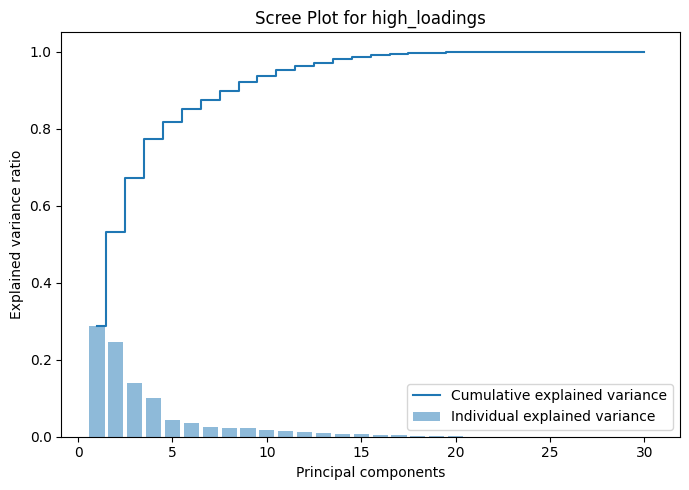

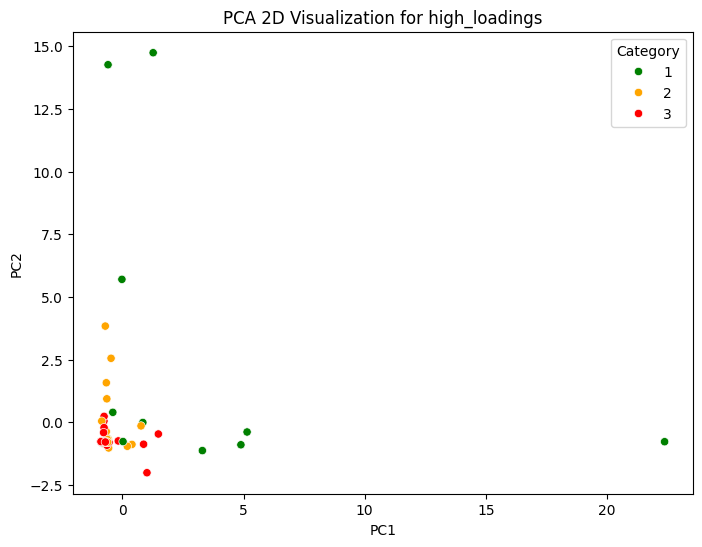

high_loadings_pipeline:
high_loadings_pipeline:
Cross-Validation MAE Scores for RF: [0.5489, 0.7078, 0.6115, 0.3303, 0.6358]
Average MAE for RF: 0.5669
Mean Squared Error: 0.7438
Root Mean Squared Error: 0.8625
Mean Absolute Error: 0.7463
Feature Importance by RF:     Features  Importance
27       375      0.3975
19        18      0.1482
26       351      0.0844
24       864      0.0737
6        625      0.0512
21       474      0.0444
20       151      0.0310
11        23      0.0305
23       663      0.0279
9        565      0.0234
13       725      0.0141
18       424      0.0130
4        712      0.0126
2        100      0.0102
10       605      0.0095
22        41      0.0092
5        871      0.0077
0        426      0.0042
12       541      0.0033
7        141      0.0022
1        480      0.0010
3        657      0.0005
8         90      0.0005
14       636      0.0000
17       104      0.0000
high_loadings_pipeline:
Cross-Validation Metrics:
Accuracy: [0.25, 0.5455, 0.5455, 0.

In [122]:
# Aply pipeline for visual results
results_high_loadings = pca_pipeline(high_loadings, 'Category', n_components=2, dataset_name='high_loadings')

# Apply the pipeline for numerical results
high_loadings_pipeline, df_pca_influence_high_loadings, explained_variance_high_loadings, n_components = apply_pipeline_pca(high_loadings, "high_loadings", n_components=2, n_top_features=20)

# Apply pipeline Regression
high_loadings_pipeline_reg, importances_reg_high_loadings= apply_pipeline_regressor(high_loadings, "high_loadings")
# Apply the pipeline Classification
high_loadings_pipe_class, importances_class_high_loadings, high_loadings_feature_scores = apply_classification_pipeline_classif(high_loadings, "high_loadings")

Acuracy is reduce and the metrics are no as good as the smaller set of Influencers_OLS, however it is a set that is more comprehensive and has bigger set of features that could posses a biological significate, the patterns of the pca can be misleading since this is just 2d, however the categories 1 and 3 are very well defined on their own planes, with category 2 presented on a middle space with many problematic overlaps.

## 15.3. Highloadings clustering

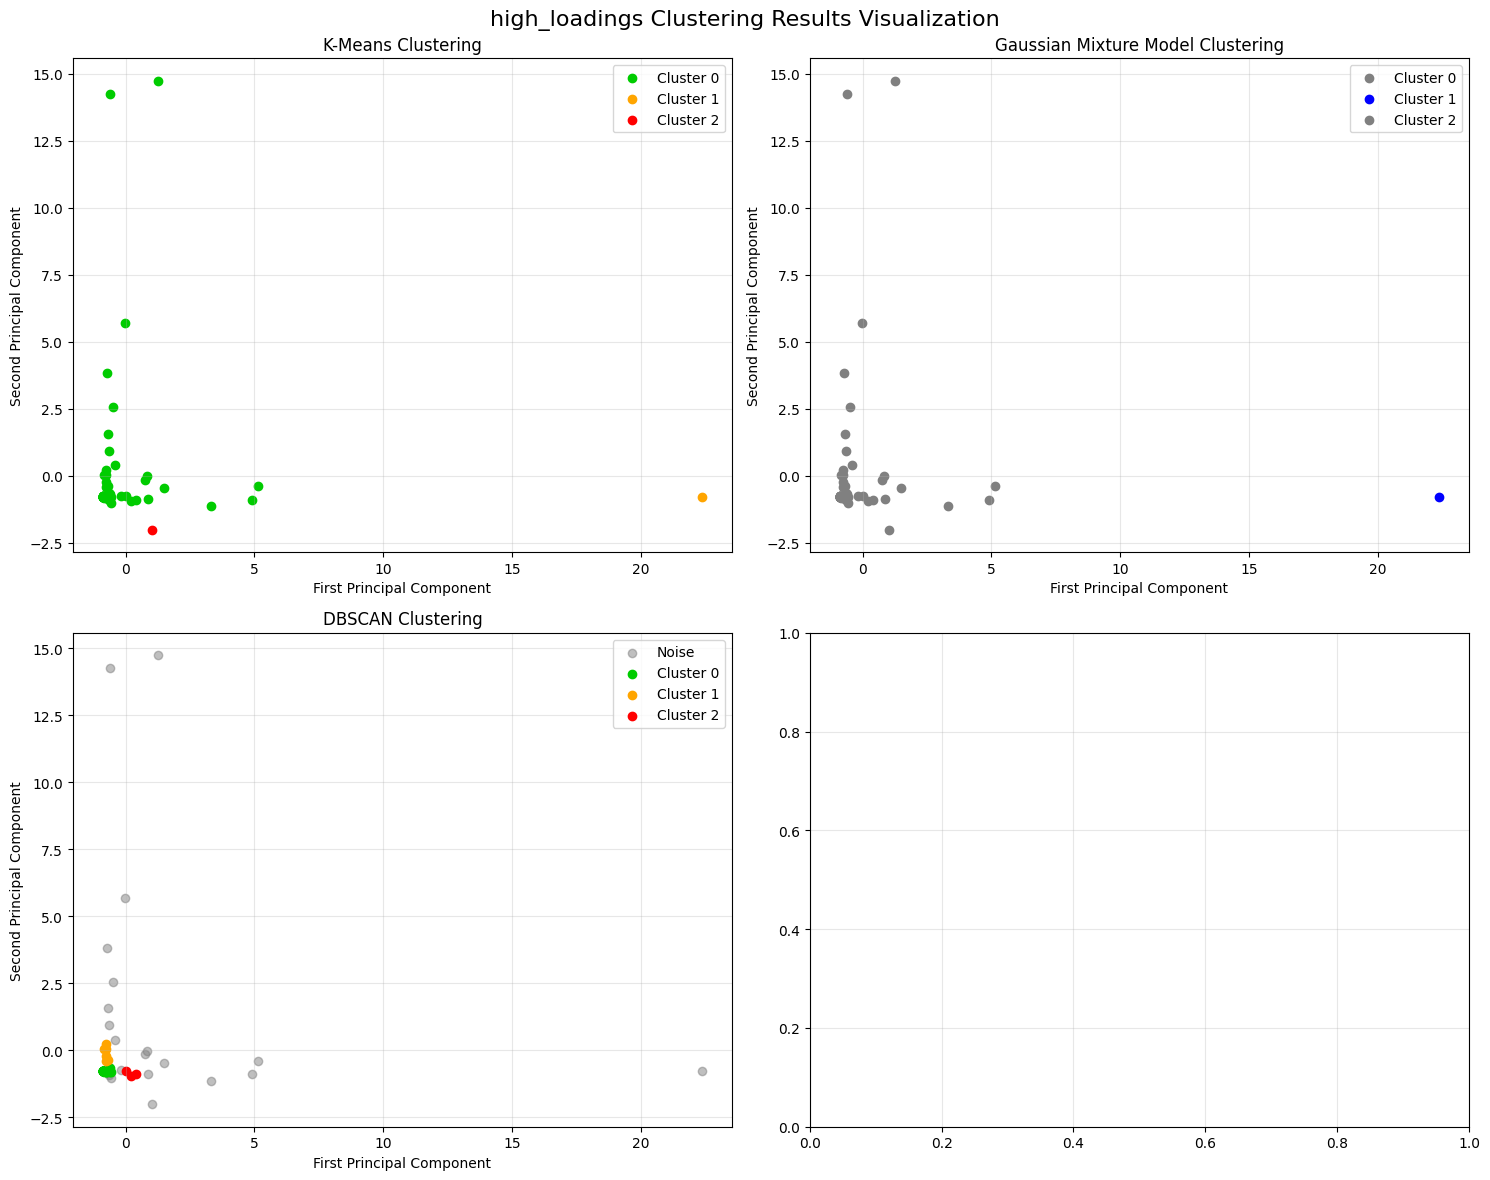


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 4.3915
Silhouette Score: 0.8335507826070856
Davies-Bouldin Score: 0.0973277128997368
Adjusted Rand Score: 0.011301551488205297

Cluster Sizes:
Cluster 0: 68 points
Cluster 1: 1 points
Cluster 2: 1 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 2.6433
Silhouette Score: 0.6249613227020578
Davies-Bouldin Score: 0.5910330458971645
Adjusted Rand Score: 0.07240051067730215

Cluster Sizes:
Cluster 0: 39 points
Cluster 1: 6 points
Cluster 2: 3 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 4.3915
Silhouette Score: 0.8335507826070856
Davies-Bouldin Score: 0.0973277128997368
Adjusted Rand Score: 0.011301551488205297

Cluster Sizes:
Cluster 0: 68 points
Cluster 1: 1 points
Cluster 2: 1 points

PCA Explained Variance Ratio:
PC1: 28.69%
PC2: 24.54%
PC3: 13.86%
Total Variance Explained (first 10 PCs): 67.10%


In [123]:
# Running pipeline
results_high_loadings_cluster = clustering_pipeline_all(high_loadings,  pca_data_name='pca_data_high_loadings ',
                                                   n_clusters=3, eps=0.3, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_high_loadings_cluster, title_prefix='high_loadings')
print_clustering_metrics(results_high_loadings_cluster )

Analysing the clustering mapping with the original pca where the risk labels are distingushed, it is possible to note the correspondence of category 1 with clusters 0 and 4, category 2 being overhelminly mixed up corresponding to cluster 2 roughly and category 3 distintive clusters 1 and 3.

## 15.4. high_loadings Analysing and visualising Calculate_and_analyze_pca_loadings

Explained Variance Ratio: [0.28694444 0.24540066 0.13864724]
Cumulative Variance Ratio: [0.28694444 0.5323451  0.67099234]

Loading Vectors:
        PC1     PC2     PC3
426  0.0141  0.3081  0.0178
480  0.0007  0.3254  0.0197
100  0.0068  0.3076  0.0069
657 -0.0048  0.2685  0.0155
712  0.0050  0.3545  0.0282
871  0.0040  0.3545  0.0276
625  0.0023  0.3487  0.0230
141 -0.0077  0.3012  0.0190
90   0.0096  0.3433  0.0275
565  0.3303 -0.0195 -0.0436

Top Contributors to Principal Components:

PC1 Top Contributors:
565   0.3303
23    0.3131
636   0.3129
225   0.3129
872   0.3129
104   0.3129
541   0.3106
605   0.2556
864   0.2405
725   0.2155
Name: PC1, dtype: float64

PC2 Top Contributors:
871   0.3545
712   0.3545
625   0.3487
90    0.3433
480   0.3254
426   0.3081
100   0.3076
141   0.3012
657   0.2685
494   0.1987
Name: PC2, dtype: float64

PC3 Top Contributors:
151   0.4708
663   0.4684
474   0.4662
41    0.3864
18    0.3428
864   0.1830
375   0.0847
725   0.0805
228   0.0738
424   0.07

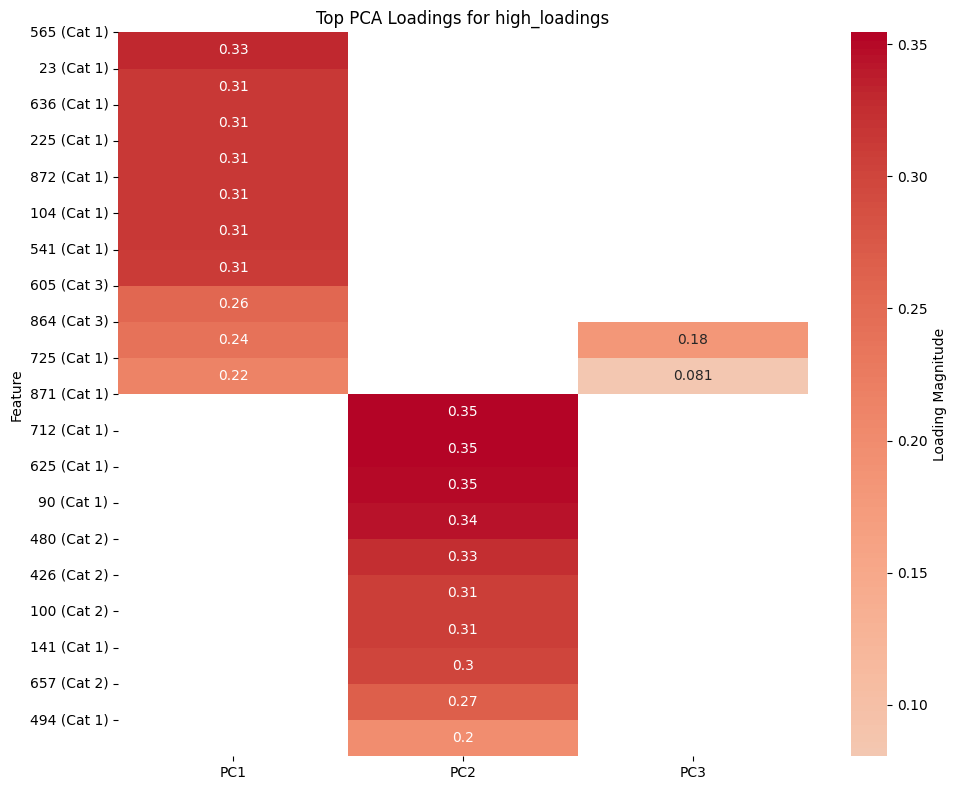

In [124]:
# We taking the data from the previous algoritms results
pca = results_high_loadings_cluster['pca']
scaled_data = results_high_loadings_cluster['scaled_data']
# Loadings calculation call
results_high_loadings_Loadings = calculate_and_analyze_pca_loadings(high_loadings, pca, 'scaled_data', 'high_loadings')

# Access the results
loadings_df = results_high_loadings_Loadings['high_loadings_loadings_df']
explained_variance = results_high_loadings_cluster['explained_variance']
cumulative_variance = results_high_loadings_cluster['cumulative_variance']
top_loadings = results_high_loadings_Loadings['high_loadings_top_loadings']

# Print or analyze the results
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance Ratio:", cumulative_variance)
print("\nLoading Vectors:")
print(loadings_df.head(10))
print("\nTop Contributors to Principal Components:")
for pc, loadings in top_loadings.items():
    print(f"\n{pc} Top Contributors:")
    print(loadings)

# Visualising the loadings with category analysis (double heatmap):
plot_top_pca_loadings(results_high_loadings_Loadings, 'high_loadings')

## 15.5. high_loadings Analysis of Loadings by Category

In [125]:
# Then analyze the category distribution
analysis_results_high_loadings = analyze_pca_feature_categories(results_high_loadings_Loadings['high_loadings_top_loadings_df'], high_loadings)
print_pca_category_analysis(analysis_results_high_loadings)

#overlaping:
overlapping = analysis_results_high_loadings['overlapping_features']

Features by Category:
Category 1: [23, 90, 100, 104, 141, 225, 228, 375, 424, 426, 480, 494, 541, 565, 605, 625, 636, 657, 712, 725, 864, 871, 872]
Category 3: [18, 41, 151, 474, 663]

Overlapping Features:
No overlapping features found

Feature Loading Information:
Feature 18 (Category 3): Unique, Max loading = 0.343
Feature 23 (Category 1): Unique, Max loading = 0.313
Feature 41 (Category 3): Unique, Max loading = 0.386
Feature 90 (Category 1): Unique, Max loading = 0.343
Feature 100 (Category 2): Unique, Max loading = 0.308
Feature 104 (Category 1): Unique, Max loading = 0.313
Feature 141 (Category 1): Unique, Max loading = 0.301
Feature 151 (Category 3): Unique, Max loading = 0.471
Feature 225 (Category 1): Unique, Max loading = 0.313
Feature 228 (Category 1): Unique, Max loading = 0.074
Feature 375 (Category 1): Unique, Max loading = 0.085
Feature 424 (Category 3): Unique, Max loading = 0.070
Feature 426 (Category 2): Unique, Max loading = 0.308
Feature 474 (Category 3): Unique, M

## 15.6. 3D Visualisation pca to Loadings to original Feat

In [126]:
def plot_pca_feature_loadings(df, loadings_df, analysis_results, dataset_name=None, plot_3d=False):
    """
    Create a PCA loadings plot showing how features contribute to PC1, PC2, and optionally PC3.
    Uses the output from analyze_pca_feature_categories for category information.

    Parameters:
    -----------
    loadings_df : pandas DataFrame. DataFrame containing the PCA loadings with features as index and PCs as columns
    analysis_results : dict Output from analyze_pca_feature_categories containing feature categories
    dataset_name : int, Name of the dataset for the plot title
    plot_3d : bool, Whether to create an interactive 3D plot with Plotly
    """
    import plotly.graph_objects as go

    # Convert index to integer
    loadings_df.index = loadings_df.index.astype(int)

    # Compute categories for features just like in the original code
    feature_categories = {}
    for feature in loadings_df.index:
        cat_means = {
            cat: df[df['Category'] == cat][feature].mean()
            for cat in [1, 2, 3]
        }
        feature_categories[feature] = max(cat_means.items(), key=lambda x: x[1])[0]


    # Generate title
    plot_title = f"{dataset_name} - PCA Feature Loadings" if dataset_name else "PCA Feature Loadings"

    # Color mapping
    color_map = {1: '#00CC00', 2: '#FFA500', 3: '#FF0000'}

    if plot_3d:
        # Create 3D Plotly figure
        fig = go.Figure()

        # Add arrows for each feature
        for feature in loadings_df.index:
            pc1_loading = loadings_df.loc[feature, 'PC1']
            pc2_loading = loadings_df.loc[feature, 'PC2']
            pc3_loading = loadings_df.loc[feature, 'PC3']

            # Get category from our computed categories
            category = feature_categories[feature]
            color = color_map[category]

            # Add line from origin to loading point
            fig.add_trace(go.Scatter3d(
                x=[0, pc1_loading],
                y=[0, pc2_loading],
                z=[0, pc3_loading],
                mode='lines',
                line=dict(color=color, width=5),
                name=f'Feature {feature} (Cat {category})'
            ))

            # Add text label at loading point
            fig.add_trace(go.Scatter3d(
                x=[pc1_loading],
                y=[pc2_loading],
                z=[pc3_loading],
                mode='text',
                text=[(feature)],
                textposition='top center',
                name=f'Label {feature}'
            ))

        # Update layout
        fig.update_layout(
            title=plot_title,
            width=1200,
            height=800,
            scene=dict(
                xaxis_title='PC1',
                yaxis_title='PC2',
                zaxis_title='PC3',
                aspectmode='cube',
                camera=dict(
                    up=dict(x=0, y=0, z=1),
                    center=dict(x=0, y=0, z=0),
                    eye=dict(x=1.5, y=1.5, z=1.5)
                )
            ),
            showlegend=True
        )

    else:
        # 2D matplotlib plot
        plt.figure(figsize=(12, 8))
        ax = plt.gca()

        # Create arrows from origin to loading points
        for feature in loadings_df.index:
            pc1_loading = loadings_df.loc[feature, 'PC1']
            pc2_loading = loadings_df.loc[feature, 'PC2']

            # Get category from our computed categories
            category = feature_categories[feature]
            color = color_map[category]

            # Draw arrow
            ax.arrow(0, 0, pc1_loading, pc2_loading,
                    color=color, alpha=0.6, head_width=0.02, head_length=0.02, width=0.005)

            # Add feature name
            ax.text(pc1_loading*1.1, pc2_loading*1.1, (feature),
                   fontsize=8, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7))

        # Add reference lines
        ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)

        # Set equal aspect ratio
        ax.set_aspect('equal')

        # Set limits
        max_val = max(abs(loadings_df[['PC1', 'PC2']]).max().max() * 1.2, 1.0)
        ax.set_xlim(-max_val, max_val)
        ax.set_ylim(-max_val, max_val)

        # Labels and title
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_title(plot_title)

        # Add legend
        legend_elements = [plt.Line2D([0], [0], color=color, label=f'Category {cat}',
                                    linewidth=3) for cat, color in color_map.items()]
        ax.legend(handles=legend_elements, fontsize=10)

        ax.grid(True, alpha=0.3)
        plt.tight_layout()

    # Show the appropriate plot
    if plot_3d:
        fig.show()
    else:
        plt.show()

## 15.7. Influencers_uniques 3D

In [127]:
# From the loadings dataframe:Influencers_uniques
plot_pca_feature_loadings(Influencers_uniques, results_influencers_uniques_Loadings['Influencers_uniques_loadings_df'],
                                                analysis_results_Influencers_uniques,"Influencers_uniques", plot_3d=True)

## 15.8. core_taxa 3D Visualisation

In [128]:
# From the loadings dataframe:Influencers_OLS    # , dataset_name="Influencers_OLS"
plot_pca_feature_loadings(core_taxa, results_core_taxa_Loadings['core_taxa_loadings_df'],
                                                analysis_results_core_taxa,"core_taxa", plot_3d=True)

## 15.9. Merged_selected 3D visualisation

In [129]:
# From the loadings dataframe:Merged_selected
plot_pca_feature_loadings(Merged_selected, results_Merged_selected_Loadings['Merged_selected_loadings_df'],
                                                analysis_results_Merged_selected,"Merged_selected", plot_3d=True)

## 15.10 high_loadings 3D visualisation

In [130]:
# From the loadings dataframe:high_loadings
plot_pca_feature_loadings(high_loadings, results_high_loadings_Loadings['high_loadings_loadings_df'],
                                                analysis_results_high_loadings,"high_loadings", plot_3d=True)

In the plot tridimensional space it is possible to differentiate all the different features and their eignevectoren, annotated with the number identifier of the genera. All the categories are on a different plane.
Influencers_uniques and Influencers_OLS are well differentiate between category 1 and category 3, only one feature appears to be in category 2. This however is problematic, because 863, _Variovorax_ has as much abundance on category one 58.8% as in category two 59% however the occurency by sites is 10 to 19 increase.
Merged_selected df has mostly category 3, showing the effects of the weighting it was put for balancing the classes. All features are well differenciated except for 704, _Syntrophorhabdus_
which appears on the same space as category 3 features being itself label as category 1. Maybe falsely annotated? Which ever the reason, it is no possible to use it because of the location on the same space that category 3.
High_loadings df shows feature 606,_Rhodobacter_ labeled as category 1 but being in the space of category 3. This is problematic because this is present on all the categories merely increasing, being actually more frequent on category 3 increasingly, however the abundance on the category 1 is bigger, perhaps that is why the algoritm put it there. 512, _Oxobacter_ it is in the correct space because it increases with the risk label, however the algoritm put is on color 2 because it has more abundance on category 2. 581, _Erysipelotrichaceae, PSB-M-3_ is also in category 3 space being orange colored, this is because of the abundance on category 2 is bigger by a 0,3%


# 16. Selection

Features 549, 214, 229, and 526 consistently appear important across datasets, though their contributions vary, suggesting different underlying structures. The improved color separation in clustering visualizations indicates feature 549's importance may relate to cluster separation. While DBSCAN showing mostly noise suggests the structure isn't density-based, the clear category-linked patterns in other clustering methods indicate strong discriminative potential. In order to select the features contributing to the risk label and no to neglect any important data points, a discriminative selection would take place. The mapping of the cluster to the categories would be done for each of the dataframes, so to be more precise. The discriminative selection of the features can be done to take into account all the metrics presented in this notebook, so no to prescind of important genera.

## 16.1. Adjusted Rand Index (ARI): Mapping of Clusters to Category
To properly evaluate feature importance, we need to map clusters to their corresponding categories for each dataframe. This mapping allows us to assess how well the clustering aligns with our known categories. The ARI will measure this alignment, adjusting for chance agreement. We'll analyze these key dataframes:

original_pca: Baseline for comparison
Influencers_uniques_selected: Current best performer with highest classification accuracy
Merged_selected: Combined features from multiple analyses
old_new: Previous feature selections that showed promise

In [131]:
# Define mappings for each mappable dataset based on clustering analysis
mappings = {
'Influencers_OLS': {   # from 4.4. and 11.4
        1:1, 3:1, # v shape - v shape Category 1 green
        4:2,   # middle Category 2 yellow
        0:3, 2:3     # Linear Category 3  red
    },
    'Influencers_uniques': { # from 8.1. and 11.6
      1:1, 2:1, 4:1, # No really but the best possible
      3:2,      # middle Category 2 yellow
      0:3       # # Linear Category 3  red
    },
    'Merged_selected': { # from 8.1. and 11.6
      3:1, 4:1,
      0:2,      # middle Category 2 yellow
      1:3, 2:3       # # Linear Category 3  red
    },
    'old_new': { # from 8.1. and 11.8
      1:1,
      4:2,
      0:3, 2:3, 3:3
    },
    'high_loadings': { # from 14.10
      1:1, 2:1,
      3:2,
      4:3, 0:3
    },
    'core_taxa': { # from 14.12
      0:1, 1:1,
      3:2,
      4:3, 2:3
    }

}
# Function to apply mapping and calculate ARI
def calculate_mapped_ari(df, df_name, cluster_labels):
    mapping = mappings[df_name]
    mapped_labels = np.array([mapping[label] for label in cluster_labels])
    true_labels = df['Category']
    return adjusted_rand_score(true_labels, mapped_labels), mapped_labels

# Store results for each dataset
mapping_results = {}
for df_name in mappings.keys():
    if df_name == 'Influencers_OLS':
        labels = results_Influencers_OLS_cluster['kmeans']['cluster_labels']
        ari, mapped = calculate_mapped_ari(Influencers_OLS, df_name, labels)
        mapping_results[df_name] = {
            'ari': ari,
            'mapped_labels': mapped
        }

    elif df_name == 'Influencers_uniques':
        labels = results_influencers_uniques_cluster['kmeans']['cluster_labels']
        ari, mapped = calculate_mapped_ari(Influencers_uniques, df_name, labels)
        mapping_results[df_name] = {
        'ari': ari,
        'mapped_labels': mapped
        }
    elif df_name == 'Merged_selected':
        labels = results_Merged_selected_cluster['kmeans']['cluster_labels']
        ari, mapped = calculate_mapped_ari(Merged_selected, df_name, labels)
        mapping_results[df_name] = {
        'ari': ari,
        'mapped_labels': mapped
        }
    elif df_name == 'old_new':
        labels = results_old_new_cluster['kmeans']['cluster_labels']
        ari, mapped = calculate_mapped_ari(old_new, df_name, labels)
        mapping_results[df_name] = {
        'ari': ari,
        'mapped_labels': mapped
        }
    elif df_name == 'high_loadings':
        labels = results_high_loadings_cluster['kmeans']['cluster_labels']
        ari, mapped = calculate_mapped_ari(high_loadings, df_name, labels)
        mapping_results[df_name] = {
        'ari': ari,
        'mapped_labels': mapped
        }
    elif df_name == 'core_taxa':
        labels = results_core_taxa_cluster['kmeans']['cluster_labels']
        ari, mapped = calculate_mapped_ari(core_taxa, df_name, labels)
        mapping_results[df_name] = {
        'ari': ari,
        'mapped_labels': mapped
        }

## 16.2. Performance Comparison Calculation and Visualisation
Before proceeding with discriminative selection, we evaluated the overall performance of our key dataframes using multiple metrics. These include PCA variance explained, classification accuracy, F1 scores, K-means silhouette scores, and clustering ARI.

Performance Metrics Comparison:
               Dataset PCA_Variance_Explained Classification_Accuracy  \
0      Merged_selected                 0.3985                  0.6429   
1  Influencers_uniques                 0.3944                  1.0000   
2              old_new                 0.2603                  0.5000   
3        high_loadings                 0.5323                  0.6429   
4            core_taxa                 0.1304                  0.5714   

  Classification_F1 Kmeans_Silhouette Clustering_ARI  
0            0.6307            0.7063         0.0421  
1            1.0000            0.8225         0.0780  
2            0.4996            0.6520         0.0309  
3            0.6429            0.8336         0.0113  
4            0.5714            0.3164         0.0143  


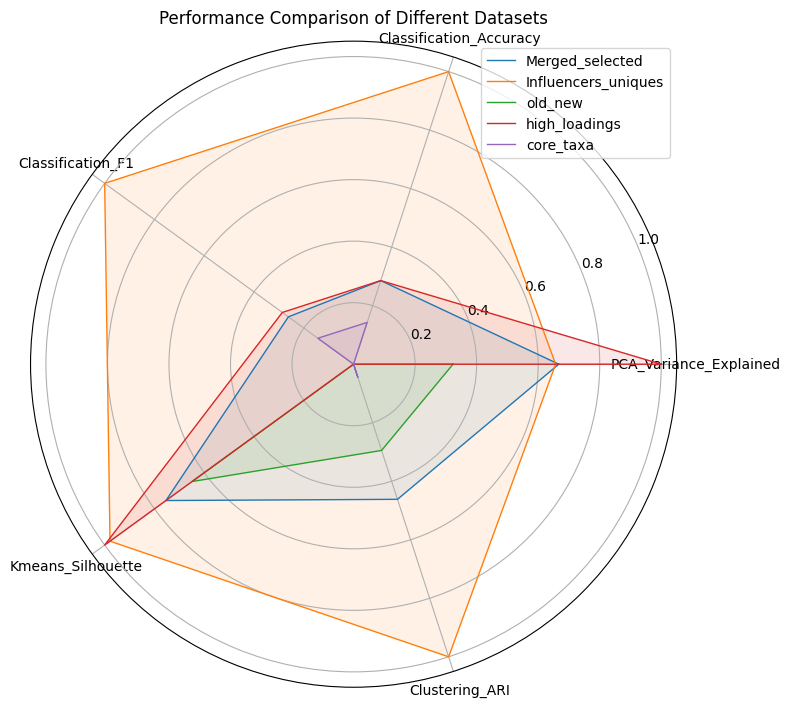

In [132]:
# Compile performance metrics for each dataframe
performance_metrics = pd.DataFrame(columns=[
    'Dataset',
    'PCA_Variance_Explained',
    'Classification_Accuracy',
    'Classification_F1',
    'Kmeans_Silhouette',
    'Clustering_ARI'
])

# Merged_selected metrics
merged_selected_metrics = pd.DataFrame({
    'Dataset': ['Merged_selected'],
    'PCA_Variance_Explained': [results_Merged_selected_cluster['explained_variance'][:2].sum()],
    'Classification_Accuracy': Merged_selected_feature_scores['accuracy'],    # From section 8.2
    'Classification_F1': Merged_selected_feature_scores['f1'],     # From section 8.2
    'Kmeans_Silhouette': [results_Merged_selected_cluster['kmeans']['silhouette_score']],
    'Clustering_ARI':[results_Merged_selected_cluster['kmeans']['adjusted_rand_score']]
})

# Influencers_uniques_selected metrics
influencers_uniques_metrics = pd.DataFrame({
    'Dataset': ['Influencers_uniques'],
    'PCA_Variance_Explained': [results_influencers_uniques_cluster['explained_variance'][:2].sum()],
    'Classification_Accuracy':Influencers_uniques_feature_scores['accuracy'], # From section 7.1
    'Classification_F1': Influencers_uniques_feature_scores['f1'],       # From section 7.1
    'Kmeans_Silhouette': [results_influencers_uniques_cluster['kmeans']['silhouette_score']],
    'Clustering_ARI': [results_influencers_uniques_cluster['kmeans']['adjusted_rand_score']]
})
# Old_new metrics collection
old_new_metrics = pd.DataFrame({
    'Dataset': ['old_new'],
    'PCA_Variance_Explained': [results_old_new_cluster['explained_variance'][:2].sum()],
    'Classification_Accuracy': old_new_feature_scores['accuracy'],
    'Classification_F1': old_new_feature_scores['f1'],
    'Kmeans_Silhouette': [results_old_new_cluster['kmeans']['silhouette_score']],
    'Clustering_ARI': [results_old_new_cluster['kmeans']['adjusted_rand_score']]
})

# high_loadings metrics collection
high_loadings_metrics = pd.DataFrame({
    'Dataset': ['high_loadings'],
    'PCA_Variance_Explained': [results_high_loadings_cluster['explained_variance'][:2].sum()],
    'Classification_Accuracy': high_loadings_feature_scores['accuracy'],
    'Classification_F1': high_loadings_feature_scores['f1'],
    'Kmeans_Silhouette': [results_high_loadings_cluster['kmeans']['silhouette_score']],
    'Clustering_ARI': [results_high_loadings_cluster['kmeans']['adjusted_rand_score']]
})
# core_taxa metrics
core_taxa_metrics = pd.DataFrame({
    'Dataset': ['core_taxa'],
    'PCA_Variance_Explained': [results_core_taxa_cluster['explained_variance'][:2].sum()],
    'Classification_Accuracy': core_taxa_feature_scores['accuracy'],  # From section 6.4
    'Classification_F1': core_taxa_feature_scores['f1'],  # From section 6.4
    'Kmeans_Silhouette': [results_core_taxa_cluster['kmeans']['silhouette_score']],
    'Clustering_ARI': [results_core_taxa_cluster['kmeans']['adjusted_rand_score']]
})

# Add metrics to DataFrame
performance_metrics = pd.concat([performance_metrics, merged_selected_metrics, influencers_uniques_metrics,
                                 old_new_metrics, high_loadings_metrics, core_taxa_metrics], ignore_index=True)

# Create a radar plot to visualize performance comparison
def radar_plot(df):
    # Prepare the data
    categories = list(df.columns)[1:]  # Skip 'Dataset' column
    n_categories = len(categories)

    # Calculate angles for each axis
    angles = np.linspace(0, 2 *np.pi, n_categories, endpoint=False)
    angles_plot = np.append(angles, angles[0])

    # Normalize the values
    values_norm = df[categories].copy(deep=False)
    for col in categories:
        min_val = values_norm[col].min()
        max_val = values_norm[col].max()
        if max_val == min_val:
            values_norm[col] = 0.5  # Set value if all values are same
        else:
            values_norm[col] = (values_norm[col] - min_val) / (max_val - min_val)

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

    # Plot data
    for idx, row in values_norm.iterrows():
        values = row.values.tolist()
        values += [values[0]]
        ax.plot(angles_plot, values, linewidth=1, linestyle='solid', label=df.iloc[idx]['Dataset'])
        ax.fill(angles_plot, values, alpha=0.1)

    # Set the labels
    ax.set_xticks(angles)
    ax.set_xticklabels(categories)

    plt.legend(loc='best')
    plt.title('Performance Comparison of Different Datasets')
    plt.tight_layout()
    plt.show()

# Display numeric results
print("Performance Metrics Comparison:")
print(performance_metrics)

# Create visualization
radar_plot(performance_metrics)

Influencers_uniques being a more comprehensive dataframe has still a good general metrics, compared to high_loadings which was expected to perform better. Influencers_OLS still continues to be an all round better df


## 16.3. Mapping the GIDs to the Genera

First the GIDs will be mapped back to the Genera for identification, using the original df with the taxonomic levels

In [133]:
# Set float format display
pd.options.display.float_format = '{:.4f}'.format

# Read the excel file with multi-index columns
Jointax = pd.read_excel('data/Jointax.xlsx', sheet_name='Biotot_jointax', header=[0,1,2,3,4,5,6,7])

# Drop first row specifically (index 0 which contains NaNs)
Jointax = Jointax.drop(index=0)

# Drop first column (the index column with Level1, Level2, etc)
Jointax = Jointax.drop(Jointax.columns[0], axis=1)
# Making sure the sites and categories get read as they should
Jointax["Sites"]= Jointax["Sites"].astype(str)
Jointax["Category"]= Jointax["Category"].values.astype(int)
# Deleting headers names of unnamed levels
Jointax.columns = Jointax.columns.map(lambda x: tuple('' if 'Unnamed' in str(level) else level for level in x))

In [134]:
def create_gid_genera_mapping(jointax_df):
    """
    Create a dictionary mapping GIDs (level 7) to genera names (level 6) from Jointax DataFrame.

    Parameters:   jointax_df (pd.DataFrame): DataFrame with hierarchical columns including genera and GID levels

    Returns:    dict: Mapping of GID to corresponding genus name
    """
    # Get just the genus names (level 6) and GIDs (level 7)
    level6_names = [x[6] for x in jointax_df.columns if isinstance(x, tuple) and len(x) > 6]
    level7_gids = [x[7] for x in jointax_df.columns if isinstance(x, tuple) and len(x) > 7]

    # Create mapping dictionary using only the genus name
    gid_to_genera = {}
    for gid, genus in zip(level7_gids, level6_names):
        if gid and genus:  # Skip empty strings
            gid_to_genera[int(gid)] = str(genus)

    return gid_to_genera

gid_to_genera = create_gid_genera_mapping(Jointax)

## 16.4. Discriminative Selection Script
The following script take a comprehensive look to all the metrics taken from the outstanding dataframes comparing them, and makes a discriminative selection of the most relevant Features that get the best score out of all the metrics, the pca influence from section 4, the predictive metrics from section 6, the clusters mapped labels, kmeans clustering results from section 11 and the loadings to refer the metrics to the original features. The idea, to make the selection over the colective dataframes, however features often work together and their importance can be highly context dependent. A feature might appear significant in one dataset combination but less so in another due to feature interacions, only discriminative when combined or in presence of other features. Or could be redundant, or carry same information and when combined with other similar feature then it would appear less significant. Also it could be that some features have a synergistic effect, which increase or supress the discriminative power. Due to that instead of combining all features and metrics. The reduced and still standing dataframes that performed better or have interesting features:
original_pca with the whole dataset information as baseline
old_new -->former selected genera
Influencers_uniques-> best performer
high_lodings-->collection of all other dataframes best features
The dataframes underwent a mapping (17.1) of the cluster to category selection first. A compendium all of the top performer genera would be merge and compared to see if the metrics improve, ultimately for the next step all the best features can be brought without much triming, so that the biological significate be evaluated and then the triming process can be done, if not statistically nor biological relevant.
Following script calculates category separation scores using mean differences and standard deviations. Evaluates cluster alignment using mapped labels. Incorporates Random Forest importance and PCA influence. Combines scores with adjustable weights and returns detailed metrics for each feature.

In [135]:
def select_discriminative_features(
    data,                     # Original dataframe
    mapped_kmeans_labels,     # From cluster mapping
    feature_importances_rf,   # From Random Forest
    pca_influences,          # From PCA analysis
    n_features=20            # Number of features to select
):
    """
    Select most discriminative features based on multiple criteria
    """
    # Initialize results dictionary
    feature_scores = {}

    # Get feature names (excluding Category and Sites)
    features = [col for col in data.columns if col not in ['Category', 'Sites']]# and pd.api.types.is_int64_dtype(data[col])]
    category_means = [] # track feature association with categories

    # Calculate separation between categories
    separation_score = 0
    category_weights = {1: 0.2,  # Reduce weight for Cat 1
                        2: 0.4,  # Increase for Cat 2
                        3: 0.4}  # Increase for Cat 3

    for feature in features:
        feature_values = data[feature].values
        category_means = []

        # 1. Category Separation Score
        # Calculate mean and std for each category
        category_stats = {}
        for cat in [1, 2, 3]:
            cat_values = feature_values[data['Category'] == cat]
            mean_val = np.mean(cat_values.astype(int))
            category_stats[cat] = {
                'mean': mean_val,
                'std': np.std(cat_values),
                'weighted_mean': mean_val * category_weights[cat]}
            category_means.append((cat, mean_val * category_weights[cat]))  # Weight affects category assignment

        dominant_category = max(category_means, key=lambda x: x[1])[0]

        for cat1 in [1, 2, 3]:
            for cat2 in [1,2,3]:
                if cat1 < cat2:
                    mean_diff = abs(category_stats[cat1]['mean'] - category_stats[cat2]['mean'])
                    pooled_std = np.sqrt(category_stats[cat1]['std']**2 + category_stats[cat2]['std']**2)
                    weight = category_weights[cat1] * category_weights[cat2]
                    separation_score += weight * mean_diff / (pooled_std + 1e-10)

        # 2. Cluster Alignment Score. How well feature aligns with mapped clusters
        cluster_values = {}
        for cluster in np.unique(mapped_kmeans_labels):
            cluster_values[cluster] = feature_values[mapped_kmeans_labels == cluster]

        cluster_score = 0
        for cluster1 in cluster_values:
            for cluster2 in cluster_values:
                if cluster1 < cluster2:
                    mean_diff = abs(np.mean(cluster_values[cluster1]) - np.mean(cluster_values[cluster2]))
                    pooled_std = np.sqrt(np.var(cluster_values[cluster1]) + np.var(cluster_values[cluster2]))
                    cluster_score += mean_diff / (pooled_std + 1e-10)

        # 3. Get importance scores
        rf_importance = feature_importances_rf[feature_importances_rf['Features'] == feature]['Importance'].values[0]
        pca_influence = pca_influences[pca_influences['Features'] == feature]['Influence'].values[0]

        # Combine scores with weights
        feature_scores[feature] = {
            'separation_score': separation_score,
            'cluster_score': cluster_score,
            'rf_importance': rf_importance,
            'pca_influence': pca_influence,
            'dominant_category': dominant_category,
            'combined_score': (0.3 * separation_score +
                             0.3 * cluster_score +
                             0.2 * rf_importance +
                             0.2 * pca_influence)}

    # Convert to DataFrame for easier handling
    scores_df = pd.DataFrame.from_dict(feature_scores, orient='index')

    # Select top features
    selected_features = scores_df.nlargest(n_features, 'combined_score')

    # Print feature list
    print("\nTop Discriminative Features:")
    for i, (feature, scores) in enumerate(selected_features.iterrows(), 1):
        # Get genus name if available in mapping
        genus = gid_to_genera[int(feature)] if int(feature) in gid_to_genera else 'Unknown'
        print(f"{i}. Feature {feature} ({genus}): {scores['combined_score']:.4f}, Category: {scores['dominant_category']}")

    return selected_features

### Results Discriminative Selection

In [136]:
# For Influencers_uniques_selected
selected_features_Influencers_uniques = select_discriminative_features(
                        Influencers_uniques, mapping_results['Influencers_uniques']['mapped_labels'],
                        importances_class_Influencers_uniques, df_pca_influence_Influencers_uniques)


Top Discriminative Features:
1. Feature 494 (Oceaniovalibus): 10510459.5758, Category: 1.0
2. Feature 541 (Peptoclostridium): 10510458.7260, Category: 1.0
3. Feature 871 (Xanthobacter): 19.3376, Category: 1.0
4. Feature 712 (Tepidimonas): 18.5557, Category: 1.0
5. Feature 625 (Roseococcus): 17.1350, Category: 1.0
6. Feature 334 (Gelria): 2.6350, Category: 1.0
7. Feature 549 (Phenylobacterium): 1.5460, Category: 1.0
8. Feature 23 (Actinomyces): 1.4126, Category: 1.0
9. Feature 864 (Veillonella): 1.2215, Category: 1.0
10. Feature 678 (Sphingosinicella): 1.1790, Category: 1.0
11. Feature 565 (Porphyromonas): 1.0714, Category: 1.0
12. Feature 375 (Hyphomicrobium): 1.0397, Category: 1.0
13. Feature 351 (Haemophilus): 1.0049, Category: 1.0
14. Feature 725 (Thermus): 1.0015, Category: 1.0
15. Feature 410 (Leifsonia): 0.9513, Category: 1.0
16. Feature 229 (Corynebacterium): 0.8989, Category: 3.0
17. Feature 228 (Coprothermobacter): 0.8899, Category: 1.0
18. Feature 214 (Clostridium): 0.8042, 

In [137]:
# For Influencers_uniques_selected
selected_features_high_loadings = select_discriminative_features(
                        high_loadings, mapping_results['high_loadings']['mapped_labels'],
                        importances_class_high_loadings, df_pca_influence_high_loadings)


Top Discriminative Features:
1. Feature 864 (Veillonella): 1.7353, Category: 1.0
2. Feature 18 (Acinetobacter): 1.2217, Category: 3.0
3. Feature 351 (Haemophilus): 0.9096, Category: 1.0
4. Feature 494 (Oceaniovalibus): 0.8457, Category: 1.0
5. Feature 41 (Alicyclobacillus): 0.8027, Category: 1.0
6. Feature 474 (Neisseria): 0.6745, Category: 3.0
7. Feature 663 (SMB53): 0.6709, Category: 3.0
8. Feature 725 (Thermus): 0.6687, Category: 1.0
9. Feature 23 (Actinomyces): 0.6534, Category: 1.0
10. Feature 605 (Rhodanobacter): 0.6386, Category: 1.0
11. Feature 410 (Leifsonia): 0.6311, Category: 1.0
12. Feature 151 (BSV43): 0.6302, Category: 3.0
13. Feature 228 (Coprothermobacter): 0.6235, Category: 1.0
14. Feature 375 (Hyphomicrobium): 0.6129, Category: 1.0
15. Feature 636 (Oscillospiraceae_UCG-005): 0.6084, Category: 1.0
16. Feature 225 (Colwellia): 0.6083, Category: 1.0
17. Feature 104 (Atopobium): 0.6083, Category: 1.0
18. Feature 872 (Xanthomonadaceae_bacterium_WWH73): 0.6083, Category: 1

In [138]:
# For Merged_selected
selected_features_Merged_selected = select_discriminative_features(
                        Merged_selected, mapping_results['Merged_selected']['mapped_labels'],
                        importances_class_Merged_selected, df_pca_influence_Merged_selected)


Top Discriminative Features:
1. Feature 201 (Cellulosimicrobium): 1.3121, Category: 1.0
2. Feature 445 (Methylobacterium): 1.1678, Category: 1.0
3. Feature 211 (Clavibacter): 0.9567, Category: 1.0
4. Feature 491 (Novosphingobium): 0.9522, Category: 3.0
5. Feature 541 (Peptoclostridium): 0.8902, Category: 1.0
6. Feature 549 (Phenylobacterium): 0.8678, Category: 1.0
7. Feature 649 (Segetibacter): 0.6738, Category: 1.0
8. Feature 680 (Sporocytophaga): 0.6685, Category: 1.0
9. Feature 704 (Syntrophorhabdus): 0.6495, Category: 1.0
10. Feature 238 (Cutibacterium): 0.6425, Category: 2.0


Top Discriminative Features:
1. Feature 549: 1.9845
2. Feature 334: 1.4321
3. Feature 91: 1.3767
4. Feature 678: 1.3703
5. Feature 863: 1.3634
6. Feature 351: 1.2240
7. Feature 625: 1.1778
8. Feature 864: 1.1706
9. Feature 725: 1.1697
10. Feature 375: 1.1654
11. Feature 526: 1.1312
12. Feature 712: 1.1240
13. Feature 871: 1.1225
14. Feature 410: 1.0727
15. Feature 23: 1.0635
16. Feature 494: 1.0335
17. Feature 799: 1.0002
18. Feature 408: 0.9983
19. Feature 541: 0.9726
20. Feature 214: 0.9622

Top Discriminative Features:
1. Feature 408: 3.2048
2. Feature 584: 2.3142
3. Feature 229: 2.0870
4. Feature 606: 1.7685
5. Feature 549: 1.5129
6. Feature 110: 1.4816
7. Feature 214: 1.4436
8. Feature 23: 1.3777
9. Feature 140: 1.3617
10. Feature 526: 1.3183
11. Feature 497: 1.2787
12. Feature 154: 1.2705
13. Feature 91: 1.2562
14. Feature 725: 1.2498
15. Feature 471: 1.2443
16. Feature 581: 1.2216
17. Feature 470: 1.1959
18. Feature 334: 1.1647
19. Feature 323: 1.1507
20. Feature 351: 1.1089

In [139]:
# For Influencers_uniques_selected
selected_features_core_taxa = select_discriminative_features(
                        core_taxa, mapping_results['core_taxa']['mapped_labels'],
                        importances_class_core_taxa, df_pca_influence_core_taxa)


Top Discriminative Features:
1. Feature 863 (Variovorax): 2.1886, Category: 3.0
2. Feature 867 (WCHB1-05): 2.0075, Category: 3.0
3. Feature 664 (Smithella): 1.9342, Category: 2.0
4. Feature 719 (Thermincola): 1.9009, Category: 3.0
5. Feature 731 (Treponema): 1.8790, Category: 3.0
6. Feature 715 (Tessaracoccus): 1.8716, Category: 3.0
7. Feature 683 (Staphylococcus): 1.8600, Category: 1.0
8. Feature 591 (Pseudoxanthomonas): 1.8586, Category: 1.0
9. Feature 659 (Silanimonas): 1.8141, Category: 1.0
10. Feature 687 (Streptococcus): 1.7978, Category: 3.0
11. Feature 674 (Sphingomonas): 1.7854, Category: 2.0
12. Feature 660 (Simplicispira): 1.7787, Category: 2.0
13. Feature 575 (Propionivibrio): 1.7742, Category: 2.0
14. Feature 589 (Pseudorhodoferax): 1.7700, Category: 2.0
15. Feature 705 (Syntrophus): 1.7550, Category: 1.0
16. Feature 581 (PSB-M-3): 1.7027, Category: 2.0
17. Feature 647 (Sediminibacterium): 1.6899, Category: 3.0
18. Feature 462 (Micrococcus): 1.6844, Category: 3.0
19. Feat

## 16.5. Parallel Check
We going to check which of the final chosen genera is actually enough represented. It muss be recall that the filtering of the genera in book 1 and 2 was aimed to prescind of the features that were no present on most of the population. If a genera has strong presence on all the data without any preference regarding the label, then ultimately is no going to be capable to elucidate the behaviour of the systems subject to corrosion. Therefore bacteria that is known for its corrosion behaviour in this study, but doesnt correlate to the risk label, can no be used as a marker. The following code analyses the selected featured by dataframe.

In [140]:
import os
def analyze_selected_features(df):
    """
    Analyze frequency and abundance for selected features across categories.
    For each feature, shows its presence and mean abundance in each category.
    """
    # Get feature columns (excluding Sites and Category)
    feature_cols = [col for col in df.columns if col not in ['Sites', 'Category']]

    for feature in feature_cols:
        print(f"\nFeature: {feature}")

        # Analyze presence and abundance by category
        for cat in sorted(df['Category'].unique()):
            # Get data for current category
            cat_data = df[df['Category'] == cat]

            # Count presence (values > 0)
            present_in_cat = (cat_data[feature] > 0).sum()
            total_in_cat = len(cat_data)
            presence_pct = (present_in_cat / total_in_cat * 100)

            # Calculate mean abundance in this category
            cat_mean = cat_data[feature].mean()

            # Print results
            print(f"Category {cat}:")
            print(f"Present in {present_in_cat}/{total_in_cat} sites ({presence_pct:.1f}%)")
            print(f"Overall mean in category: {cat_mean:.4f}")

def categorize_features(df):
    """
    Determine the predominant category for each feature based on frequency and abundance.
    """
    feature_cols = [col for col in df.columns if col not in ['Sites', 'Category']]
    feature_categories = {}

    for feature in feature_cols:
        cat_scores = {}
        for cat in sorted(df['Category'].unique()):
            cat_data = df[df['Category'] == cat]
            # Calculate presence percentage
            present = (cat_data[feature] > 0).sum()
            total = len(cat_data)
            presence_pct = (present/total*100)
            # Calculate mean abundance
            mean_abund = cat_data[feature].mean()
            # Combined score (you can adjust the weights)
            cat_scores[cat] = presence_pct * mean_abund

        # Assign feature to category with highest score
        predominant_cat = max(cat_scores.items(), key=lambda x: x[1])[0]
        feature_categories[feature] = predominant_cat

    return feature_categories


def create_feature_analysis_tables(dfs_dict, output_path= None, output_filename=None, single_sheet=False):
    """
    Create tables analyzing features for multiple dataframes and export to Excel.
    Features are organized by their predominant category.

    Parameters:
    dfs_dict (dict): Dictionary of dataframes with format {'name': dataframe}
    output_filename (str): Name of the Excel file to save results
    single_sheet (bool): If True, puts all tables in one sheet with spacing between them
        """
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    output_file = os.path.join(output_path, output_filename)

    def analyze_single_df(df):
        # Get feature categories
        feature_cats = categorize_features(df)

        # Sort features by their predominant category
        feature_cols = [col for col in df.columns if col not in ['Sites', 'Category']]
        sorted_features = sorted(feature_cols, key=lambda x: (feature_cats[x], x))

        rows = []
        # Add header row showing predominant category for each feature
        cat_row = ['Predominant Category']
        genus_row = ['Genus']
        cat_row.extend([f'Cat {feature_cats[feat]}' for feat in sorted_features])
        genus_row.extend([f'{gid_to_genera[int(feat)]}' if isinstance(feat, (int, str)) and int(feat) in gid_to_genera
                         else f'GID_{feat}' for feat in sorted_features])
        rows.append(cat_row)
        rows.append(genus_row)

        # Add blank row for spacing
        rows.append([''] * (len(sorted_features) + 1))

        for cat in sorted(df['Category'].unique()):
            freq_row = [f'Frequency Cat {cat}']
            abund_row = [f'Abundance Mean Cat {cat}']

            for feature in sorted_features:
                cat_data = df[df['Category'] == cat]

                # Calculate frequency
                present = (cat_data[feature] > 0).sum()
                total = len(cat_data)
                freq = f'{present}/{total} ({(present/total*100):.1f}%)'

                # Calculate mean abundance
                mean_abund = cat_data[feature].mean()

                freq_row.append(freq)
                abund_row.append(f'{mean_abund:.4f}')

            rows.append(freq_row)
            rows.append(abund_row)

        columns = ['Metric'] + sorted_features
        return pd.DataFrame(rows, columns=columns)

    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        if single_sheet:
            # Put all tables in one sheet with spacing
            current_row = 0
            sheet_name = 'Feature Analysis'

            for df_name, df in dfs_dict.items():
                # Create table for current dataframe
                results_df = analyze_single_df(df)

                # Add dataset name as header
                header_df = pd.DataFrame([f"Dataset: {df_name}"])
                header_df.to_excel(writer, sheet_name=sheet_name,
                                 startrow=current_row, index=False, header=False)

                # Write the actual table
                results_df.to_excel(writer, sheet_name=sheet_name,
                                  startrow=current_row+1, index=False)

                # Update row counter (add rows of table + 3 for spacing)
                current_row += len(results_df) + 4

            # Adjust column widths
            worksheet = writer.sheets[sheet_name]

        else:
            # Create separate sheet for each dataframe
            for df_name, df in dfs_dict.items():
                results_df = analyze_single_df(df)
                sheet_name = df_name[:31]  # Excel sheet names limited to 31 chars

                results_df.to_excel(writer, sheet_name=sheet_name, index=False)

                # Adjust column widths
                worksheet = writer.sheets[sheet_name]
                for idx, col in enumerate(results_df.columns):
                    max_length = max(
                        results_df[col].astype(str).apply(len).max(),
                        len(str(col))
                    )
                    worksheet.column_dimensions[chr(65 + idx)].width = max_length + 2

In [141]:
# Create dictionary of dataframes to analyze
dfs = {
    'original_pca': original_pca, 'uniques_pca': uniques_pca, 'uniques23_pca': uniques23_pca,
    'Influencers_OLS': Influencers_OLS,'uniques23_OLS': uniques23_OLS,
    'Influencers_uniques': Influencers_uniques,
    'old_new': old_new, 'Merged_df': Merged_df,
    'Merged_selected': Merged_selected, 'high_loadings': high_loadings, 'core_taxa': core_taxa
}
# Or create single sheet excel file with all tables
create_feature_analysis_tables(dfs_dict=dfs,
                               #output_path = '/content/drive/My Drive/MIC/data',
                               output_path = '~/MIC/2_Micro/data',
                               output_filename= 'feature_analysis_results.xlsx', single_sheet=True)

Features were chosen because there are clear progression patterns across categories, another important criterio was a good discrimination ability, specially for category 3. Consistence presene with meaningul abundance differences. Complementary patterns that together provide better discrimination. Reliability in their signals due to consistence presence absence patters. Additionally the frequency must be ≥3 occurrences and there is no selection of features markers for Category 1. In sumary only looking at real category distinctions
Some of the markers were no truly convincing, however it was rather prefere false positives than false negatives, because false positives can be filtered out later with additional biological validation and cross-referencing with physicochemical data, but missing potential markers (false negatives) could mean losing important biological insights about the corrosion process.The rationale for keeping potentially ambiguous features is that they might be part of important metabolic pathways
Their presence/absence could be environmentally regulated, or might interact synergistically with other bacteria. It is possible that their role might become clearer when analyzed alongside chemical parameters.  

|Dataframe|Features Complying with Criteria|
|---|---|
|original_pca|140, 300, 456, 474, 491, 526, 566|
|uniques_pca|201, 211|
|uniques23_pca|81, 110, 140, 214, 300, 497, 512, 526, 566|
|Influencers_OLS|214, 229, 408, 471, 526, 584|
|uniques23_OLS|140, 201, 214, 229, 470, 584|
|Influencers_uniques|201, 214, 229, 408, 470, 471, 526, 584|
|old_new|154, 201, 214, 229, 354, 408, 497, 512, 581, 583, 584, 621|
|Merged_selected|110, 201, 211|
|high_loadings|110, 154, 201, 211, 214, 229, 354, 408, 471, 497, 512, 581, 583, 584|
|Merged_df|81, 92, 110, 140, 145, 201, 211, 214, 223, 229, 300, 470, 474, 491, 497, 503, 512, 526, 566, 584, 687, 727|
|Core_taxa| 110, 572, 587, 143, 664, 270, 575, 491, 647, 245, 17, 671, 198, 238, 354, 591, 217, 674, 271, 449, 269, 731,  7, 13, 853, 687, 296, 550, 89, 344, 715, 146, 371, 214, 676, 130, 683, 484, 634,  304, 719, 867,  136, 229, 581, 267, 596, 660,113, 30, 177, 462, 705, 6, 29, 206, 863, 659, 589, 360|

In [130]:
#print(core_taxa.columns.levels[7].tolist())

In [143]:
feature_lists = {
    'original_pca': [140, 300, 456, 474, 491, 526, 566],
    'uniques_pca': [201, 211],
    'uniques23_pca': [81, 110, 140, 214, 300, 497, 512, 526, 566],
    'Influencers_OLS': [214, 229, 408, 471, 526, 584],
    'uniques23_OLS': [140, 201, 214, 229, 470, 584],
    'Influencers_uniques': [201, 214, 229, 408, 470, 471, 526, 584],
    'old_new': [154, 201, 214, 229, 354, 408, 497, 512, 581, 583, 584, 621],
    'Merged_selected': [110, 201, 211],
    'high_loadings': [110, 154, 201, 211, 214, 229, 354, 408, 471, 497, 512, 581, 583, 584],
    'Merged_df': [81, 92, 110, 140, 145, 201, 211, 214, 223, 229, 300, 470, 474, 491, 497, 503, 512, 526, 566, 584, 687, 727]
}

# Get unique features
checked_features = set()
for features in feature_lists.values():
    checked_features.update(features)

In [144]:
# Using original to makeup the dataframe from the GIDs
checked= original[['Category'] + [512, 140, 526, 145, 408, 154, 300, 687, 566, 581, 583, 456, 201, 584, 81, 211, 214, 471, 470, 727, 474, 92, 223, 354, 229, 491, 621, 110, 497, 503]]

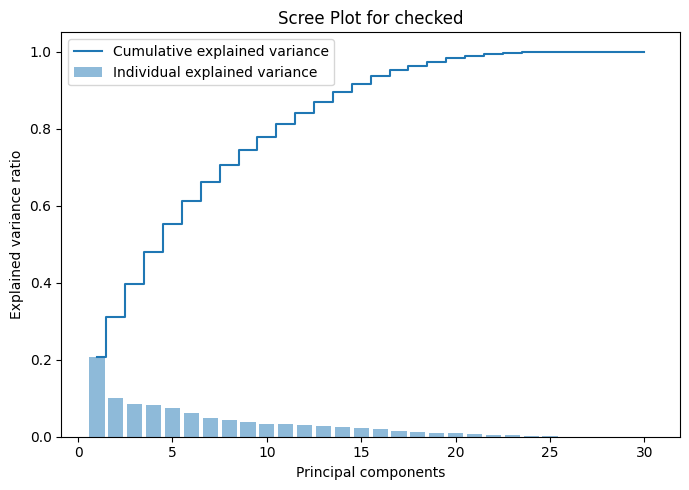

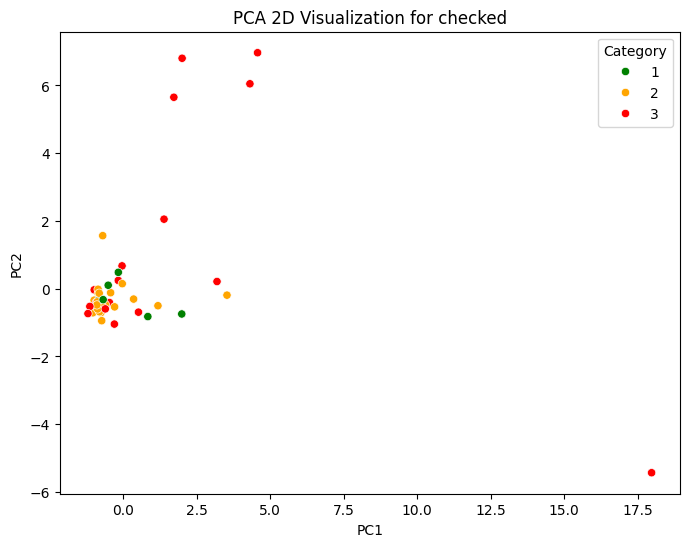

checked_pipeline:
checked_pipeline:
Cross-Validation MAE Scores for RF: [0.6858, 0.6991, 0.5982, 0.4527, 0.6536]
Average MAE for RF: 0.6179
Mean Squared Error: 0.5831
Root Mean Squared Error: 0.7636
Mean Absolute Error: 0.6043
Feature Importance by RF:     Features  Importance
27       110      0.2369
7        687      0.1375
2        526      0.1143
25       491      0.1029
1        140      0.0805
29       503      0.0504
23       354      0.0476
18       470      0.0460
16       214      0.0369
4        408      0.0261
8        566      0.0188
24       229      0.0141
20       474      0.0132
19       727      0.0097
17       471      0.0074
3        145      0.0070
14        81      0.0068
10       583      0.0068
21        92      0.0065
6        300      0.0064
11       456      0.0061
9        581      0.0047
13       584      0.0040
0        512      0.0027
28       497      0.0022
checked_pipeline:
Cross-Validation Metrics:
Accuracy: [0.4167, 0.2727, 0.4545, 0.5455, 0.6364]
Av

In [145]:
# Aply pipeline for visual results
results_checked = pca_pipeline(checked, 'Category', n_components=3, dataset_name='checked')

# Apply the pipeline for numerical results
checked_pipeline, df_pca_influence_checked, explained_variance_checked, n_components = apply_pipeline_pca(checked, "checked", n_components=3, n_top_features=20)

# Apply pipeline Regression
checked_pipeline_reg, importances_reg_checked= apply_pipeline_regressor(checked, "checked")
# Apply the pipeline Classification
checked_pipe_class, importances_class_checked, checked_feature_scores = apply_classification_pipeline_classif(checked, "checked")

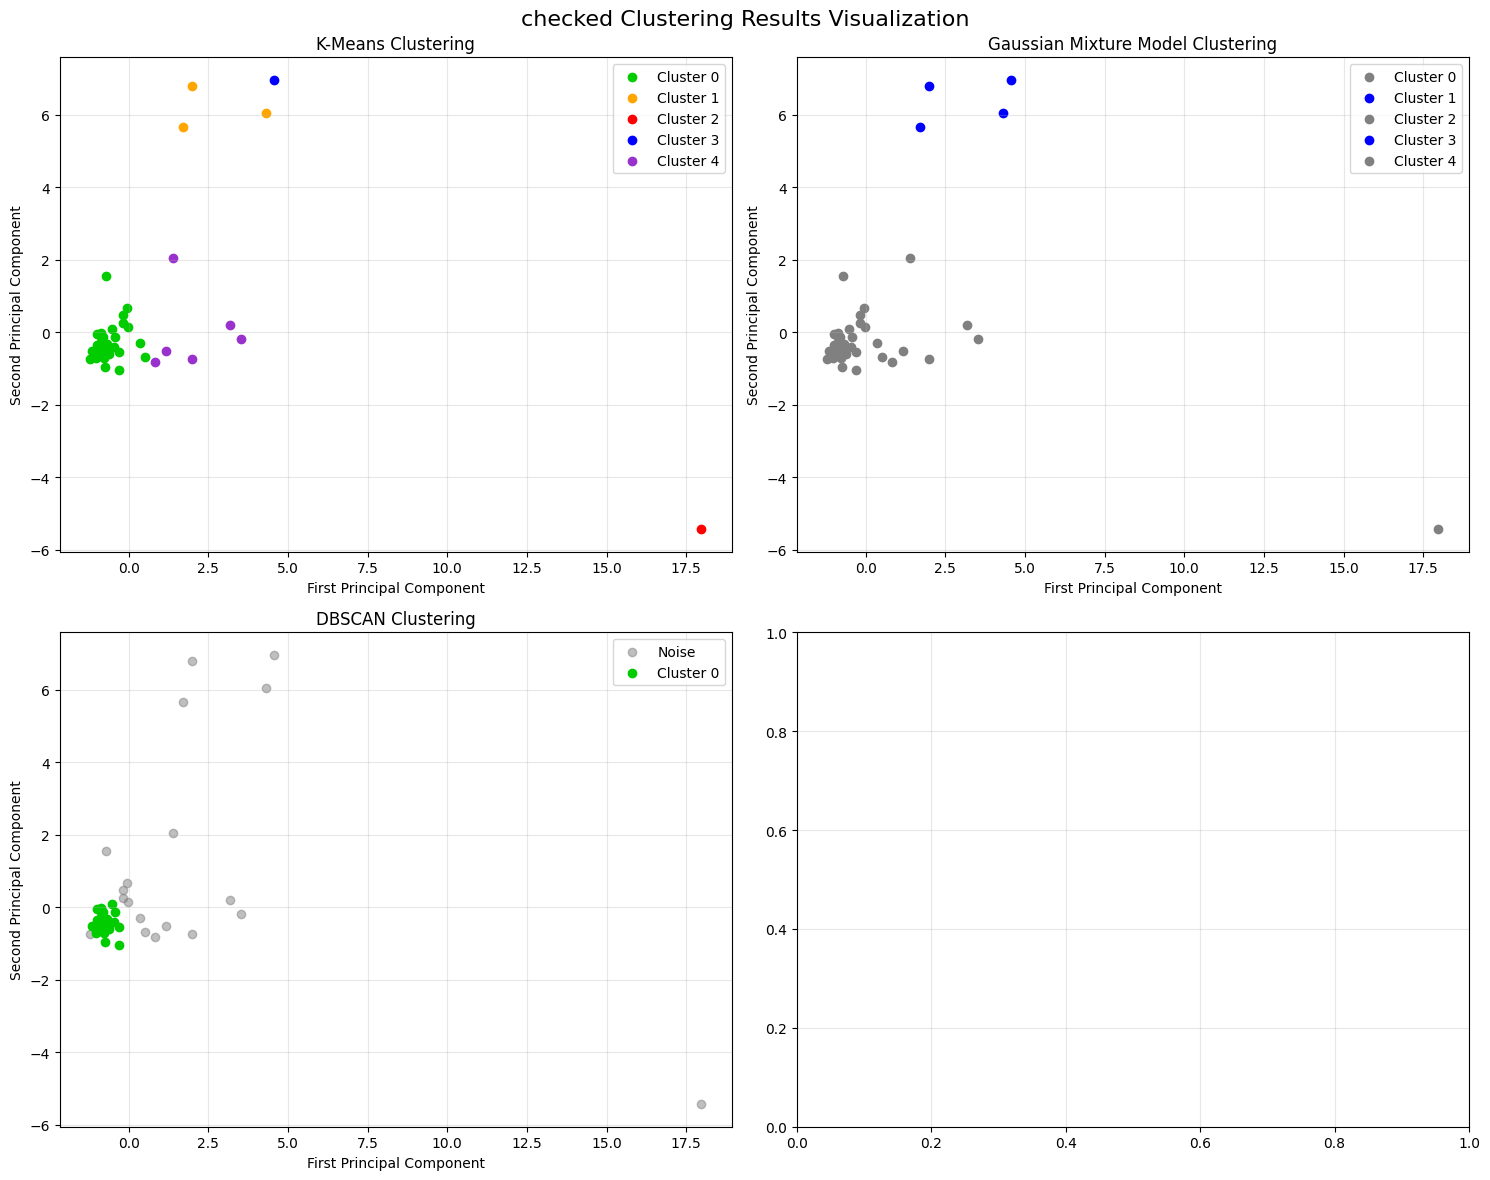


=== Clustering Metrics ===

KMEANS Clustering Metrics:
Average Intra-cluster Distance: 8.3235
Silhouette Score: 0.679101270856666
Davies-Bouldin Score: 0.4366694746021939
Adjusted Rand Score: 0.027766930038059735

Cluster Sizes:
Cluster 0: 59 points
Cluster 1: 3 points
Cluster 2: 1 points
Cluster 3: 1 points
Cluster 4: 6 points

DBSCAN Clustering Metrics:
Average Intra-cluster Distance: 3.3426
Silhouette Score: Not applicable
Davies-Bouldin Score: Not applicable
Adjusted Rand Score: 0.04928684412795954

Cluster Sizes:
Cluster 0: 51 points

GMM Clustering Metrics:
Average Intra-cluster Distance: 7.7803
Silhouette Score: 0.40364936879797547
Davies-Bouldin Score: 0.7479799576695678
Adjusted Rand Score: 0.058003602677545535

Cluster Sizes:
Cluster 0: 41 points
Cluster 1: 3 points
Cluster 2: 1 points
Cluster 3: 1 points
Cluster 4: 24 points

PCA Explained Variance Ratio:
PC1: 20.82%
PC2: 10.18%
PC3: 8.58%
Total Variance Explained (first 10 PCs): 39.59%


In [146]:
# Running pipeline
results_checked_cluster = clustering_pipeline_all(checked ,  pca_data_name='pca_data_checked',
                                                    n_clusters=5, eps=0.5, min_samples=3, n_components=3)
#Calling the function for visualisation
visualize_clustering_results(results_checked_cluster, title_prefix='checked')
print_clustering_metrics(results_checked_cluster)

## 16.6. Confidence Intervals
This would validate the reliability of the selected features, this gives a range in which the results have more probability of being correct, calculating the selected_features by usign the function discriminative_selection, as well as using the feature_scores coming from the classification pipeline.  

In [147]:
def test_significance_with_ci(df, feature_scores, mapped_kmeans_labels,
                            feature_importances_rf, pca_influences, n_iterations=1000):
    """
    Test significance with all required parameters for select_discriminative_features

    Parameters:
    df: Original dataframe
    feature_scores: Scores from previous select_discriminative_features run
    mapped_kmeans_labels: Required for select_discriminative_features
    feature_importances_rf: Required for select_discriminative_features
    pca_influences: Required for select_discriminative_features
    n_iterations: Number of bootstrap iterations
    """
    # Initialize results DataFrame using feature names from scores
    results = pd.DataFrame(index=feature_scores['feature_names'])

    # Initialize storage arrays, separation_score combined_score
    bootstrap_metrics = np.zeros((n_iterations, 2))
    permuted_metrics = np.zeros((n_iterations, 2))

    category_consensus = {1: {}, 2: {}, 3: {}}  # Track feature assignments
    consensus_counts = np.zeros((len(feature_scores['feature_names']), 3))  # Track counts per category

    for i in range(n_iterations):
        # Bootstrap sample
        bootstrap_df = df.sample(n=len(df), replace=True)
        df_permuted = df.copy(deep=False)
        df_permuted['Category'] = np.random.permutation(df['Category'])

        # Get scores using discriminative selection
        bootstrap_scores = select_discriminative_features(bootstrap_df,
                                                       mapped_kmeans_labels,
                                                       feature_importances_rf,
                                                       pca_influences)

        permuted_scores = select_discriminative_features(df_permuted,
                                                      mapped_kmeans_labels,
                                                      feature_importances_rf,
                                                      pca_influences)
        # getting a concensus
        for feat_idx, feature in enumerate(feature_scores['feature_names']):
            #get category from  index
            if feature in bootstrap_scores.index:
                for cat in [1, 2, 3]:
                    # Calculate weighted category score using both frequency and abundance
                    cat_data = bootstrap_df[bootstrap_df['Category'] == cat][feature]
                    presence_pct = (cat_data > 0).sum() / len(cat_data)
                    mean_abund = cat_data.mean()
                    cat_score = presence_pct * mean_abund
                    consensus_counts[feat_idx, int(cat)-1] += cat_score

    # Store metrics
    bootstrap_metrics[i] = [bootstrap_scores['separation_score'].iloc[0],
                        bootstrap_scores['combined_score'].iloc[0]]
    permuted_metrics[i] = [permuted_scores['separation_score'].iloc[0],
                        permuted_scores['combined_score'].iloc[0]]
    # Calculating consensus percentages and adding to results
    for cat in [1, 2, 3]:
        cat_idx = cat - 1
        results[f'category_{cat}_consensus'] = (consensus_counts[:, cat_idx] / n_iterations) * 100


    # Calculate confidence intervals
    for idx, metric in enumerate(['separation_score', 'combined_score']):
        results[f'{metric}_ci_lower'], results[f'{metric}_ci_upper'] = \
            np.percentile(bootstrap_metrics[:, idx], [2.5, 97.5])

    # Calculate p-values
    results[f'{metric}_p_value'] = \
        np.mean([perm >= float(feature_scores['accuracy' if metric == 'separation_score'
              else 'f1']) for perm in permuted_metrics[:, idx]])
    # Add dominant consensus category
    results['consensus_category'] = np.argmax(consensus_counts, axis=1) + 1
    results['consensus_strength'] = np.max(consensus_counts, axis=1) / n_iterations * 100

    print("\nCategory Consensus Summary:")
    for feature in feature_scores['feature_names']:
        consensus_pcts = [f"Cat {i+1}: {results.loc[feature, f'category_{i+1}_consensus']:.1f}%" for i in range(3)]
        print(f"Feature {feature}: {' | '.join(consensus_pcts)}")
        print(f"    Dominant Category: {results.loc[feature, 'consensus_category']} "
            f"(Consensus: {results.loc[feature, 'consensus_strength']:.1f}%)\n")

    return results

In [148]:
Merged_selected_significance = test_significance_with_ci(Merged_selected, Merged_selected_feature_scores,
    mapping_results['Merged_selected']['mapped_labels'], importances_class_Merged_selected, df_pca_influence_Merged_selected, 100)


Top Discriminative Features:
1. Feature 445 (Methylobacterium): 0.8111, Category: 1.0
2. Feature 491 (Novosphingobium): 0.7577, Category: 3.0
3. Feature 541 (Peptoclostridium): 0.7325, Category: 1.0
4. Feature 549 (Phenylobacterium): 0.6901, Category: 1.0
5. Feature 649 (Segetibacter): 0.6412, Category: 1.0
6. Feature 680 (Sporocytophaga): 0.6315, Category: 1.0
7. Feature 238 (Cutibacterium): 0.6029, Category: 2.0
8. Feature 704 (Syntrophorhabdus): 0.5367, Category: 1.0
9. Feature 201 (Cellulosimicrobium): 0.4572, Category: 1.0
10. Feature 211 (Clavibacter): 0.4200, Category: 1.0

Top Discriminative Features:
1. Feature 201 (Cellulosimicrobium): 1.3140, Category: 1.0
2. Feature 445 (Methylobacterium): 1.1625, Category: 2.0
3. Feature 211 (Clavibacter): 0.9585, Category: 1.0
4. Feature 491 (Novosphingobium): 0.9380, Category: 3.0
5. Feature 541 (Peptoclostridium): 0.8846, Category: 1.0
6. Feature 549 (Phenylobacterium): 0.8623, Category: 3.0
7. Feature 649 (Segetibacter): 0.6683, Categ

In [149]:
Influencers_uniques_significance = test_significance_with_ci(Influencers_uniques, Influencers_uniques_feature_scores,
    mapping_results['Influencers_uniques']['mapped_labels'], importances_class_Influencers_uniques,
    df_pca_influence_Influencers_uniques, 100)


Top Discriminative Features:
1. Feature 712 (Tepidimonas): 31720500012.6660, Category: 1.0
2. Feature 871 (Xanthobacter): 9154500013.3103, Category: 1.0
3. Feature 549 (Phenylobacterium): 3783900000.8757, Category: 1.0
4. Feature 678 (Sphingosinicella): 399300000.6328, Category: 1.0
5. Feature 334 (Gelria): 325800000.6025, Category: 1.0
6. Feature 375 (Hyphomicrobium): 273300000.5201, Category: 1.0
7. Feature 565 (Porphyromonas): 157800000.3029, Category: 1.0
8. Feature 864 (Veillonella): 115500000.4164, Category: 1.0
9. Feature 23 (Actinomyces): 105000000.2410, Category: 1.0
10. Feature 541 (Peptoclostridium): 21020916.2403, Category: 1.0
11. Feature 494 (Oceaniovalibus): 21020916.2402, Category: 1.0
12. Feature 725 (Thermus): 21000000.2845, Category: 1.0
13. Feature 625 (Roseococcus): 21.6941, Category: 1.0
14. Feature 351 (Haemophilus): 1.6714, Category: 2.0
15. Feature 229 (Corynebacterium): 1.0323, Category: 3.0
16. Feature 214 (Clostridium): 0.9905, Category: 3.0
17. Feature 410

In [150]:
high_loadings_significance = test_significance_with_ci(high_loadings, high_loadings_feature_scores,
    mapping_results['Influencers_uniques']['mapped_labels'], importances_class_high_loadings ,
    df_pca_influence_high_loadings, 100)


Top Discriminative Features:
1. Feature 18 (Acinetobacter): 1.0286, Category: 3.0
2. Feature 41 (Alicyclobacillus): 0.9501, Category: 1.0
3. Feature 864 (Veillonella): 0.9099, Category: 3.0
4. Feature 351 (Haemophilus): 0.8511, Category: 1.0
5. Feature 375 (Hyphomicrobium): 0.8397, Category: 3.0
6. Feature 474 (Neisseria): 0.7560, Category: 3.0
7. Feature 663 (SMB53): 0.7217, Category: 3.0
8. Feature 494 (Oceaniovalibus): 0.7093, Category: 1.0
9. Feature 657 (Shinella): 0.6980, Category: 1.0
10. Feature 23 (Actinomyces): 0.6923, Category: 1.0
11. Feature 424 (Luteimonas): 0.6905, Category: 1.0
12. Feature 151 (BSV43): 0.6887, Category: 3.0
13. Feature 410 (Leifsonia): 0.6488, Category: 1.0
14. Feature 605 (Rhodanobacter): 0.6233, Category: 3.0
15. Feature 725 (Thermus): 0.5958, Category: 1.0
16. Feature 228 (Coprothermobacter): 0.5652, Category: 1.0
17. Feature 625 (Roseococcus): 0.5376, Category: 1.0
18. Feature 565 (Porphyromonas): 0.5250, Category: 1.0
19. Feature 141 (Brachymonas)

The behaviour of the total of the data -original- is contrasted against the individual groupings of genera, to see if the behaviour of individual features is depending on the grouping or is independiently and posses same trends with the risk label.

For original_pca
Feature 140:


Category 1: 17.6% presence, 0.0015 abundance
Category 2: 12.5% presence, 0.0041 abundance
Category 3: 42.9% presence, 0.0498 abundance


Feature 474:


Category 1: 35.3% presence, 0.0155 abundance
Category 2: 21.9% presence, 0.0138 abundance
Category 3: 47.6% presence, 0.1514 abundance


Feature 81:


Category 1: 41.2% presence, 0.0746 abundance
Category 2: 15.6% presence, 0.0072 abundance
Category 3: 52.4% presence, 0.1035 abundance


Feature 566:


Category 1: 11.8% presence, 0.0014 abundance
Category 2: 21.9% presence, 0.0358 abundance
Category 3: 47.6% presence, 0.1763 abundance

Feature 354:


Category 1: 23.5% presence, mean abundance 0.0462
Category 2: 34.4% presence, mean abundance 1.6274
Category 3: 61.9% presence, mean abundance 2.7596


Feature 581:


Category 1: 17.6% presence, mean abundance 0.1153
Category 2: 25.0% presence, mean abundance 0.8370
Category 3: 42.9% presence, mean abundance 0.8108


Feature 606:


Category 1: 29.4% presence, mean abundance 0.4041
Category 2: 37.5% presence, mean abundance 0.0431
Category 3: 47.6% presence, mean abundance 0.2259

Category 3 Trend Markers:

Feature 214: Increases from 0% to 25% to 52.4%
Feature 229: Increases from 35.3% to 37.5% to 61.9%
Feature 408: Increases from 47.1% to 43.8% to 61.9%
Feature 867: Increases from 17.6% to 15.6% to 42.9%

Category 2 Trend Markers:

Feature 581: Increases from 17.6% to 25% to 42.9%
Feature 566: Increases from 11.8% to 21.9% to 47.6%
Feature 695: Increases from 35.3% to 40.6% to 57.1%

Let me check Feature 471's presence in each category:
Category 1: 3/17 (17.6%)
Category 2: 6/32 (18.8%)
Category 3: 9/21 (42.9%)

# 17 Conclusion regarding balance classes

Through three notebooks has been revealed key insights about bacterial markers across corrosion categories. In notebook 2, statistical significance testing through OLS has shown that while Influencers_OLS and OLS_all identified significant features, there is a notable absence of true category 1 markers. No bacteria demonstrate both sufficient abundance and frequency to serve as reliable indicators of non-corrosion environments.
Notebook 3's analysis initially suggested category 1 dominance in prediction, but granular examination reveals this as a computational artifact rather than biological reality. The bacteria associated with category 1 are actually distributed across all categories, merely appearing in higher numbers and abundance in category 1 environments.
Bacteria associated with category 1 appear across all categories, with relative abundances:
- Category 1: ~1.3-1.5x higher than other categories
- Categories 2/3: Lower but still significant presence

While these bacteria appear in the uniques dataframe, their abundance and frequency patterns do not support their role as true markers. Their apparent importance stems from computational compensation for category 1's overall lower abundance in the samples, rather than genuine biological significance. High abundance features on category 1 alone doesn't indicate they're beneficial or protective against corrosion. They could simply be "standbyers" - bacteria present but not actively influencing corrosion processes
Category 2 presents an even more informative pattern. Across all tests and selection methods, no clear bacterial markers emerge. The uniques dataframe notably lacks category 2 markers, which aligns with biological understanding - corrosion-associated bacteria can survive and thrive even at low abundances when environmental conditions permit.

This comprehensive analysis suggests a revised approach to class balance: rather than seeking unique markers for each category, the focus should be on the significant features identified for categories 2 and 3, with category 1 being characterized by their absence. This absence-based classification better reflects the biological reality of corrosion progression in these environments.

To implement this approach, category weights were adjusted:
Category 1: 0.4 (reduced weight)
Categories 2 & 3: 2.0 (increased weight)
These weights were applied to highlight features associated with corrosion progression while reducing emphasis on potentially spurious category 1 markers, aimed to revel better the features involved with the labels 2 and 3.

While some bacteria can theoretically inhibit corrosion through biofilm formation or metabolic activities, proving causation versus correlation is extremely challenging. High abundance in low-corrosion environments could simply indicate these are opportunistic colonizers thriving in less deteriorated conditions
The absence of exclusive Category 1 markers aligns with ecological understanding - pristine environments typically have diverse, non-specialized communities.
Corrosion-associated bacteria often show a progression pattern - increasing presence/abundance as corrosion advances.
Corrosion-associated bacteria typically show:
- Minimal/absent in Category 1 (<20% frequency)
- Increasing presence in Category 2 (>40% frequency)
- Highest abundance in Category 3 (>60% frequency)

Looking for markers that are absent/minimal in Category 1 but increase in Categories 2/3 helps identify bacteria potentially involved in the corrosion process rather than just correlation. Avoiding enterly interaction features on the region of category 1 which could well be just random colonizers. This helps filter out potential false positives from the loading analysis and statistical categorization.

# 18. Others visualisations
## 18.1.  t-SNE for Visualization
t-SNE is a non-linear dimensionality reduction technique that is particularly effective for visualizing high-dimensional data in 2D or 3D. It often preserves local structure better than PCA

In [151]:
def tsne_visualization(scaled_data):
    """
    Visualizes data using t-SNE.

    Parameters:
    - df: Scaled DataFrame or numpy array (features only).
    - labels: Cluster or category labels to color-code.
    - perplexity: Perplexity for t-SNE (default=30).
    - n_components: Number of components for t-SNE (default=2).
    - random_state: Random seed for reproducibility.
    """
    # Apply t-SNE
    tsne = TSNE(n_components=3, perplexity=50, random_state=42)
    tsne_results = tsne.fit_transform(scaled_data)

    # Plot t-SNE results
    plt.figure(figsize=(8, 6))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=true_labels, cmap='viridis', s=20, alpha=0.7)
    plt.colorbar(label='True Labels')
    plt.title("t-SNE Visualization")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

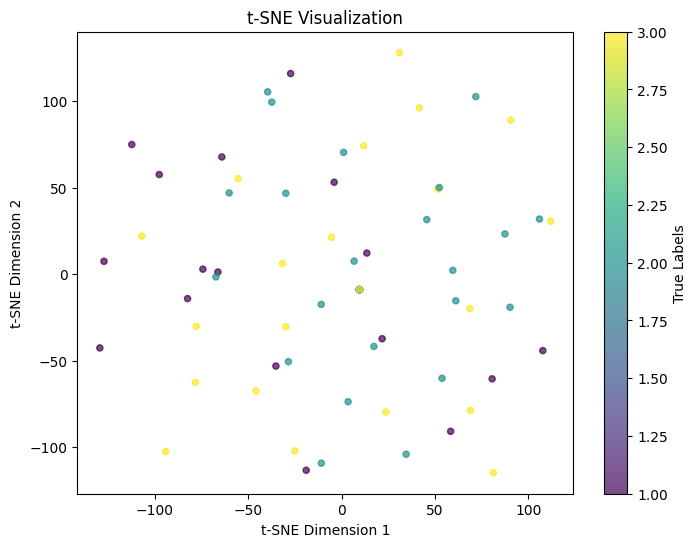

In [152]:
# Visualising the implementation
scaled_data = results_Influencers_OLS_cluster['scaled_data']
true_labels = Influencers_OLS["Category"]
tsne_visualization(scaled_data)

## 18.2. UMAP Visualisation

In [153]:
def umap_visualization(df, scaled_data, label_column='Category', colors=['green', 'orange', 'red'],
                      n_neighbors=10, min_dist=0.1):
    """
    Visualizes data using UMAP with custom colors.

    Parameters:
    - scaled_data: Scaled DataFrame or numpy array (features only).
    - labels: Cluster or category labels for color-coding.
    - categories: List of category values to match labels.
    - colors: List of colors corresponding to each category.
    - n_neighbors: Number of neighbors for UMAP (default=15).
    - min_dist: Minimum distance between points (default=0.1).

    Returns:
    - None (Displays a plot)
    """
    # Get unique categories in order
    categories = sorted(df[label_column].unique())

    # Get category labels from the DataFrame
    labels = df[label_column].values

    # Apply UMAP
    umap_reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, random_state=42)
    umap_results = umap_reducer.fit_transform(scaled_data)

    # Create a mapping from labels to colors
    label_color_map = {category: color for category, color in zip(categories, colors)}
    mapped_colors = [label_color_map[label] for label in labels]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        umap_results[:, 0], umap_results[:, 1],
        c=mapped_colors, alpha=0.8, s=50
    )
    plt.title('UMAP Visualization with Category Colors')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    # Plotting

    # Add legend
    handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=10, label=f'Category {category}')
               for category, color in zip(categories, colors)]
    plt.legend(handles=handles, title='Category', loc='best')

    plt.show()

In [ ]:
scaled_data = results_high_loadings_cluster['scaled_data']
# Extract category labels
category_labels = high_loadings['Category'].values

# Calling the function
umap_visualization(high_loadings, scaled_data, label_column='Category',  colors=['green', 'orange', 'red'],  n_neighbors=20, min_dist=0.7)

/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



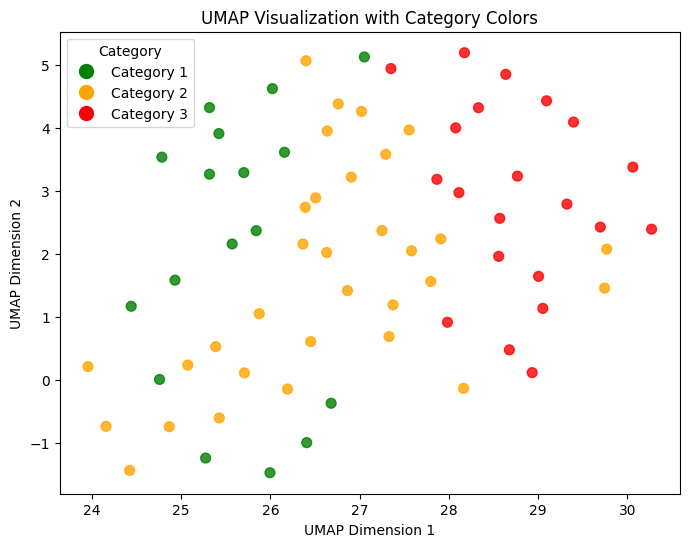

In [143]:
scaled_data = results_Influencers_OLS_cluster['scaled_data']
# Extract category labels
category_labels = Influencers_OLS['Category'].values

# Calling the function
umap_visualization(Influencers_OLS, scaled_data, label_column='Category',  colors=['green', 'orange', 'red'],  n_neighbors=20, min_dist=0.7)

### Visualisation of Influencers_OLS UMAP
presents some patterns that has distintive regions, but still some mixture.
Category 3 (red) tends to cluster on the right side
Category 1 (green) and 2 (orange) have some overlap but show patterns

/home/beatriz/MIC/2_Micro/.venv_general/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



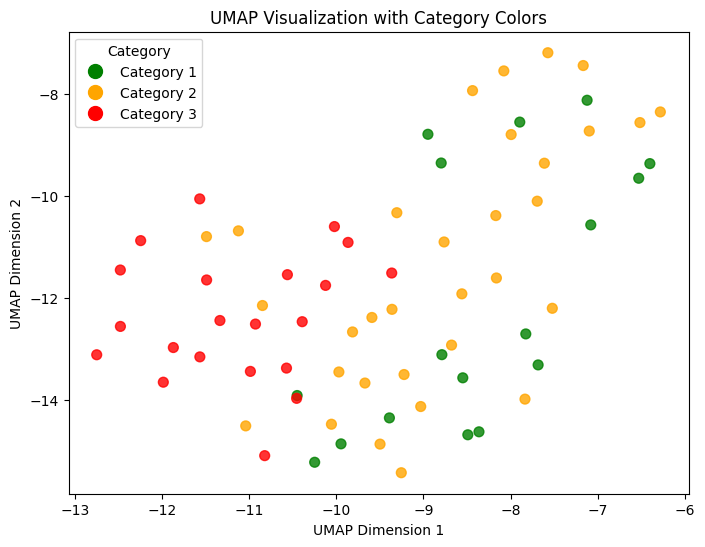

In [144]:
scaled_data = results_influencers_uniques_cluster['scaled_data']
# Extract category labels
category_labels = Influencers_uniques['Category'].values

# Calling the function
umap_visualization(Influencers_uniques, scaled_data, label_column='Category', colors=['green', 'orange', 'red'], n_neighbors=20, min_dist=0.7)

**Influencers_uniques shows**: Different spatial arrangement, better vertical separation of Category 3.
More spread out distribution overall
**Combined/Merged** shows: More mixing between categories, some local clustering but less global structure, higher dimension 2 values (7-11 range)

# 19 Integrating the Taxonomic Levels and saving the selected df

## 19.1.usual_suspect DataFrame
Bacteria known to be corrosive and is found on the present systems are as follows:  

214 Clostridium (Anaerobic, acid-producing bacteria)
264 Desulfobacterium (Sulfate-reducing bacteria)  
265 Desulfobulbus (Sulfate-reducing bacteria)  
270 Desulfotomaculum (Thermophilic sulfate-reducing bacteria)  
271 Desulfovibrio (Sulfate-reducing bacteria, well-documented MIC agent)
332 Gallionella (Iron-oxidizing bacteria)   
587 Pseudomonas (Known for biofilm formation and acid production)  
656 Shewanella (Metal-reducing bacteria)  
727 Thiobacillus (Sulfur-oxidizing bacteria)  

These list underwent a run in the notebook bacteria influencing corrosion and ultimately the literature indicated the list should be updated, the check with the parallel function tables of section 16.5 looking at the significance on the increase or decrease with the label, it was notice that the following usual_suspects wont make sense to keep due to low abundance and no patterns: 270, 656,265,271,264,587,624

GID 271 Desulfovibrio (sulfate-reducing bacteria, well-documented) *does not meet criteria
GID 656 Shewanella (metal-reducing bacteria) *does not meet criteria
GID 264 Desulfobacterium (sulfate-reducing) *does not meet criteria
GID 265 Desulfobulbus (sulfate-reducing) *does not meet criteria
GID 270 Desulfotomaculum (thermophilic sulfate-reducing) *does not meet criteria

In [ ]:
# usual_suspects taxonomic levels and abundance
usuals_gen = {271, 727, 332, 587, 656, 214, 265, 270, 264}

# Check the actual structure of the Category column
category_tuple = tuple(['Category'] + [''] * 7)  # Since we have 8 levels
site_tuple = tuple(['Sites'] + [''] * 7)  # Since we have 8 levels

# Now find columns matching selected GIDs
feature_columns = [col for col in Jointax.columns
                  if col[-1].isdigit() and int(col[-1]) in usuals_gen]

# Create final dataframe with selected columns
usuals= Jointax[[site_tuple]+[category_tuple] + feature_columns]

print("Shape of usual_suspects data:", usuals.shape)
usuals.head()

Shape of usual_suspects data: (70, 11)


,Sites,Category,Clostridiales_Clostridiaceae_Clostridium,Desulfobacterales_Desulfobacteraceae_Desulfobacterium,Desulfobacterales_Desulfobulbaceae_Desulfobulbus,Clostridiales_Peptococcaceae_Desulfotomaculum,Desulfovibrionales_Desulfovibrionaceae_Desulfovibrio,Gallionellales_Gallionellaceae_Gallionella,Pseudomonadales_Pseudomonadaceae_Pseudomonas,Alteromonadales_Shewanellaceae_Shewanella,Hydrogenophilales_Hydrogenophilaceae_Thiobacillus
,,,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria
,,,Firmicutes,Proteobacteria,Proteobacteria,Firmicutes,Proteobacteria,Proteobacteria,Proteobacteria,Proteobacteria,Proteobacteria
,,,Clostridia,Deltaproteobacteria,Deltaproteobacteria,Clostridia,Deltaproteobacteria,Betaproteobacteria,Gammaproteobacteria,Gammaproteobacteria,Betaproteobacteria
,,,Clostridiales,Desulfobacterales,Desulfobacterales,Clostridiales,Desulfovibrionales,Gallionellales,Pseudomonadales,Alteromonadales,Hydrogenophilales
,,,Clostridiaceae,Desulfobacteraceae,Desulfobulbaceae,Peptococcaceae,Desulfovibrionaceae,Gallionellaceae,Pseudomonadaceae,Shewanellaceae,Hydrogenophilaceae
,,,Clostridium,Desulfobacterium,Desulfobulbus,Desulfotomaculum,Desulfovibrio,Gallionella,Pseudomonas,Shewanella,Thiobacillus
,,,214,264,265,270,271,332,587,656,727
1,site_1,3,0.0000,0.0000,0.1723,0.5170,8.7462,0.0000,5.2779,0.1077,0.0000
2,site_2,1,0.0000,0.0000,0.0190,0.2277,0.4933,0.0000,3.4718,0.1328,0.0000
3,site_3,1,0.0000,0.0000,0.0000,1.9642,0.7488,0.0000,2.0624,0.1350,0.0000


In [ ]:
# Core community Bacteria
# Final selected genera taxonomic levels and abundance
core_taxa_gen = {110, 572, 587, 143, 664, 270, 575, 491, 647, 245, 17, 671, 198, 238, 354, 591, 217, 674, 271,
                 449, 269, 731, 7, 13, 853, 687, 296, 550, 89, 344, 715, 146, 371, 214, 676, 130, 683, 484, 634,
                 304, 719, 867, 136, 229, 581, 267, 596, 660,113, 30, 177, 462, 705, 6, 29, 206, 863, 659, 589, 360, 322}
# Check the actual structure of the Category column
category_tuple = tuple(['Category'] + [''] * 7)  # Since we have 8 levels
site_tuple = tuple(['Sites'] + [''] * 7)  # Since we have 8 levels

# Now find columns matching selected GIDs
feature_columns = [col for col in Jointax.columns
                  if col[-1].isdigit() and int(col[-1]) in core_taxa_gen]

# Create final dataframe with selected columns
core_taxa= Jointax[[site_tuple]+[category_tuple] + feature_columns]

print("Shape of selected data:", core_taxa.shape)
core_taxa.head()

Shape of selected data: (70, 63)


,Sites,Category,Clostridiales_Eubacteriaceae_Acetobacterium,Burkholderiales_Alcaligenaceae_Achromobacter,Rhodospirillales_Acetobacteraceae_Acidisoma,Burkholderiales_Comamonadaceae_Acidovorax,Propionibacteriales_Propionibacteriaceae_Aestuariimicrobium,Rhizobiales_Bradyrhizobiaceae_Afipia,Bacillales_Bacillaceae_Anoxybacillus,Rhodocyclales_Rhodocyclaceae_Azospira,...,Sphingomonadales_Sphingomonadaceae_Sphingopyxis,Bacillales_Staphylococcaceae_Staphylococcus,Lactobacillales_Streptococcaceae_Streptococcus,Syntrophobacterales_Syntrophaceae_Syntrophus,Actinomycetales_Propionibacteriaceae_Tessaracoccus,Clostridiales_Peptococcaceae_Thermincola,Spirochaetales_Spirochaetaceae_Treponema,Burkholderiales_Oxalobacteraceae_Oxalobacteraceae_unclassified,Burkholderiales_Comamonadaceae_Variovorax,Anaerolineales_Anaerolinaceae_Wchb1-05
,,,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,...,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria
,,,Firmicutes,Proteobacteria,Proteobacteria,Proteobacteria,Actinobacteria,Proteobacteria,Firmicutes,Proteobacteria,...,Proteobacteria,Firmicutes,Firmicutes,Proteobacteria,Actinobacteria,Firmicutes,Spirochaetes,Proteobacteria,Proteobacteria,Chloroflexi
,,,Clostridia,Betaproteobacteria,Alphaproteobacteria,Betaproteobacteria,Actinobacteria,Alphaproteobacteria,Bacilli,Betaproteobacteria,...,Alphaproteobacteria,Bacilli,Bacilli,Deltaproteobacteria,Actinobacteria,Clostridia,Spirochaetes,Betaproteobacteria,Betaproteobacteria,Anaerolineae
,,,Clostridiales,Burkholderiales,Rhodospirillales,Burkholderiales,Propionibacteriales,Rhizobiales,Bacillales,Rhodocyclales,...,Sphingomonadales,Bacillales,Lactobacillales,Syntrophobacterales,Actinomycetales,Clostridiales,Spirochaetales,Burkholderiales,Burkholderiales,Anaerolineales
,,,Eubacteriaceae,Alcaligenaceae,Acetobacteraceae,Comamonadaceae,Propionibacteriaceae,Bradyrhizobiaceae,Bacillaceae,Rhodocyclaceae,...,Sphingomonadaceae,Staphylococcaceae,Streptococcaceae,Syntrophaceae,Propionibacteriaceae,Peptococcaceae,Spirochaetaceae,Oxalobacteraceae,Comamonadaceae,Anaerolinaceae
,,,Acetobacterium,Achromobacter,Acidisoma,Acidovorax,Aestuariimicrobium,Afipia,Anoxybacillus,Azospira,...,Sphingopyxis,Staphylococcus,Streptococcus,Syntrophus,Tessaracoccus,Thermincola,Treponema,Oxalobacteraceae_unclassified,Variovorax,Wchb1-05
,,,6,7,13,17,29,30,89,110,...,676,683,687,705,715,719,731,853,863,867
1,site_1,3,0.4308,0.5170,0.0000,6.2473,0.0000,0.0000,0.0000,26.9280,...,0.5386,0.7324,0.0862,0.0000,0.0000,0.0000,0.0000,0.0000,1.6588,0.0000
2,site_2,1,0.0190,0.3415,0.0000,1.4798,0.0000,0.0190,0.0000,1.8592,...,0.3984,2.7130,0.1138,0.0000,0.0000,0.0000,0.0000,0.0000,2.1628,0.0000
3,site_3,1,0.0246,0.3192,0.0000,3.7196,0.0000,0.0000,0.0000,3.0935,...,6.1748,1.8291,0.1719,0.0000,0.0000,0.0000,0.0000,0.0000,0.8102,0.0000


Some of this bacteria intercept with the checked dataframe of the statistically significant to corrosion label features, such are:
Halomonas (GID 354)
Clostridium (GID 214)
Streptococcus (GID 687)
Corynebacterium (GID 229)
PSB-M-3 (GID 581)

This suggests these bacteria are both important community members and are involved in corrosion processes

### Selected DataFrame

In [147]:
# Final selected genera taxonomic levels and abundance
new_selected_gen = {110, 140, 154, 201, 214, 229, 354, 408, 471, 497, 512, 526, 581, 584}
                                      # [214, 229, 334, 351, 354, 408, 497, 512, 565, 581, 583, 584, 606, 621, 625]
# Check the actual structure of the Category column
category_tuple = tuple(['Category'] + [''] * 7)  # Since we have 8 levels
site_tuple = tuple(['Sites'] + [''] * 7)  # Since we have 8 levels

# Now find columns matching selected GIDs
feature_columns = [col for col in Jointax.columns
                  if col[-1].isdigit() and int(col[-1]) in new_selected_gen]

# Create final dataframe with selected columns
selected_new = Jointax[[site_tuple]+[category_tuple] + feature_columns]

print("Shape of selected data:", selected_new.shape)


Shape of selected data: (70, 16)


### Making high_loadings DataFrame

In [148]:
# Drop first column
high_loadings_df = high_loadings.drop(high_loadings.columns[0], axis=1)

In [149]:
high_loadings_GIDS = high_loadings.columns.tolist()

In [150]:
# Check the actual structure of the Category column
category_tuple = tuple(['Category'] + [''] * 7)  # Since we have 8 levels
site_tuple = tuple(['Sites'] + [''] * 7)  # Since we have 8 levels

# Now find columns matching selected GIDs
feature_columns = [col for col in Jointax.columns
                  if col[-1].isdigit() and int(col[-1]) in high_loadings_GIDS]

# Create final dataframe with selected columns
high_loadings_df= Jointax[[site_tuple]+[category_tuple] + feature_columns]

print("Shape of high_loadings data:", high_loadings_df.shape)

Shape of high_loadings data: (70, 32)


### Making Influencers_uniques DataFrame

In [151]:
# Drop first column
Influencers_uniques_df = Influencers_uniques.drop(Influencers_uniques.columns[0], axis=1)
Influencers_uniques_GIDS = Influencers_uniques_df.columns.tolist()

In [152]:
# Check the actual structure of the Category column
category_tuple = tuple(['Category'] + [''] * 7)  # Since we have 8 levels
site_tuple = tuple(['Sites'] + [''] * 7)  # Since we have 8 levels

# Now find columns matching selected GIDs
feature_columns = [col for col in Jointax.columns
                  if col[-1].isdigit() and int(col[-1]) in Influencers_uniques_GIDS]

# Create final dataframe with selected columns
Influencers_uniques_df= Jointax[[site_tuple]+[category_tuple] + feature_columns]

print("Shape of Influencers_uniques data:", Influencers_uniques_df.shape)
Influencers_uniques_df.head()

Shape of Influencers_uniques data: (70, 28)


,Sites,Category,Actinomycetales_Actinomycetaceae_Actinomyces,Burkholderiales_Comamonadaceae_Aquabacterium,Actinomycetales_Promicromonosporaceae_Cellulosimicrobium,Clostridiales_Clostridiaceae_Clostridium,Actinomycetales_Corynebacteriaceae_Corynebacterium,Thermoanaerobacterales_Thermoanaerobacteraceae_Gelria,Nitrosomonadales_Sterolibacteriaceae_Georgfuchsia,Pasteurellales_Pasteurellaceae_Haemophilus,...,Bacteroidales_Porphyromonadaceae_Porphyromonas,Vibrionales_Pseudoalteromonadaceae_Pseudoalteromonas,Rhodospirillales_Acetobacteraceae_Roseococcus,Sphingomonadales_Sphingomonadaceae_Sphingosinicella,Burkholderiales_Comamonadaceae_Tepidimonas,Thermales_Thermaceae_Thermus,Rhodocyclales_Rhodocyclaceae_Uncultured_bacterium,Burkholderiales_Comamonadaceae_Variovorax,Clostridiales_Veillonellaceae_Veillonella,Rhizobiales_Xanthobacteraceae_Xanthobacter
,,,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,...,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria,Bacteria
,,,Actinobacteria,Proteobacteria,Actinobacteria,Firmicutes,Actinobacteria,Firmicutes,Proteobacteria,Proteobacteria,...,Bacteroidetes,Proteobacteria,Proteobacteria,Proteobacteria,Proteobacteria,Thermi,Proteobacteria,Proteobacteria,Firmicutes,Proteobacteria
,,,Actinobacteria,Betaproteobacteria,Actinobacteria,Clostridia,Actinobacteria,Clostridia,Betaproteobacteria,Gammaproteobacteria,...,Bacteroidia,Gammaproteobacteria,Alphaproteobacteria,Alphaproteobacteria,Betaproteobacteria,Deinococci,Betaproteobacteria,Betaproteobacteria,Clostridia,Alphaproteobacteria
,,,Actinomycetales,Burkholderiales,Actinomycetales,Clostridiales,Actinomycetales,Thermoanaerobacterales,Nitrosomonadales,Pasteurellales,...,Bacteroidales,Vibrionales,Rhodospirillales,Sphingomonadales,Burkholderiales,Thermales,Rhodocyclales,Burkholderiales,Clostridiales,Rhizobiales
,,,Actinomycetaceae,Comamonadaceae,Promicromonosporaceae,Clostridiaceae,Corynebacteriaceae,Thermoanaerobacteraceae,Sterolibacteriaceae,Pasteurellaceae,...,Porphyromonadaceae,Pseudoalteromonadaceae,Acetobacteraceae,Sphingomonadaceae,Comamonadaceae,Thermaceae,Rhodocyclaceae,Comamonadaceae,Veillonellaceae,Xanthobacteraceae
,,,Actinomyces,Aquabacterium,Cellulosimicrobium,Clostridium,Corynebacterium,Gelria,Georgfuchsia,Haemophilus,...,Porphyromonas,Pseudoalteromonas,Roseococcus,Sphingosinicella,Tepidimonas,Thermus,Uncultured_bacterium,Variovorax,Veillonella,Xanthobacter
,,,23,91,201,214,229,334,342,351,...,565,584,625,678,712,725,799,863,864,871
1,site_1,3,0.2801,0.1939,0.0000,0.0000,0.0000,0.0215,0.0000,0.4739,...,0.1723,0.0000,0.0000,0.0000,0.0000,0.4524,0.0000,1.6588,0.3231,0.0000
2,site_2,1,1.2332,0.1138,0.0000,0.0000,0.0000,0.0000,0.0000,0.6261,...,0.2466,0.0000,0.0000,0.0000,0.0000,0.3035,0.0000,2.1628,3.2821,0.0000
3,site_3,1,0.3069,0.2332,0.0000,0.0000,0.0000,0.0000,0.0000,0.4297,...,1.4854,0.0000,0.0000,0.0000,0.0123,3.5846,0.0000,0.8102,0.2946,0.0000


### On the Making of Checked_genera df
Now after a deep analysis the errors of computational algoritm make me realise we leaving behind some important features, a check was perform on section 16.5 and other features resurface as important for different reasons there explained. Now there was a decision to left behind the cat strong markers because it was no the scope of this study to focus on other but bateria influcing corrosion. However after careful consideration it is decided to take the strong statistically occuring features because it would make the study more complete, since it would give real relationships of the most influential community fundamental genera. The list of features will go forward to the next analysis. This are no the most abundand overall, however present patters associated with the risk label that are consistent. Some of the original are removed: 201,211,223,621,81,92 and some are added 334, 549, 564, 712.


In [153]:
# Final selected genera taxonomic levels and abundance
checked_GIDS = {334, 549, 564, 712, 512, 140, 526, 145, 408, 154, 300, 687, 566, 581, 583, 584, 214, 471, 470, 727, 474, 354, 229, 491, 110, 497, 503}
# Check the actual structure of the Category column
category_tuple = tuple(['Category'] + [''] * 7)  # Since we have 8 levels
site_tuple = tuple(['Sites'] + [''] * 7)  # Since we have 8 levels

# Now find columns matching selected GIDs
feature_columns = [col for col in Jointax.columns
                  if col[-1].isdigit() and int(col[-1]) in checked_GIDS]

# Create final dataframe with selected columns
checked_genera = Jointax[[site_tuple]+[category_tuple] + feature_columns]

print("Shape of checked_genera data:", checked_genera.shape)

Shape of checked_genera data: (70, 29)


from the function of parallel checking, following will make a excel file with the comparison tables, where we can compare the checked dataframe and the usual_suspects dataframe in order to compare abundances and frequencies to see it the statistical analyis made sense.

In [154]:
# Final selected genera taxonomic levels and abundance
usual_suspects = original[['Category'] + [271, 727, 332, 587, 656, 214, 624, 265, 270, 264]]

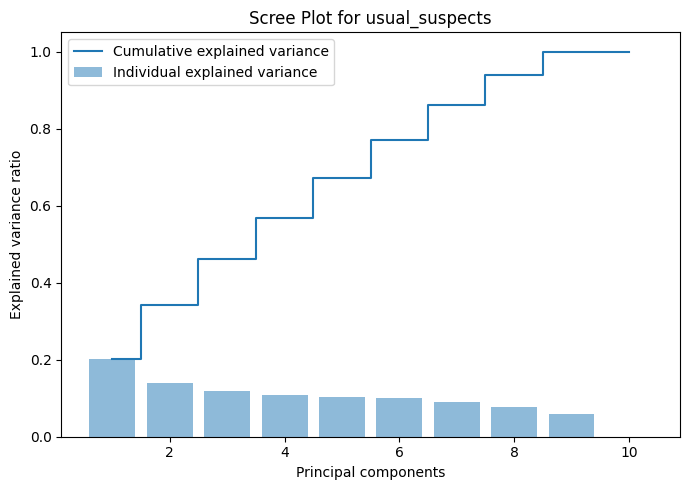

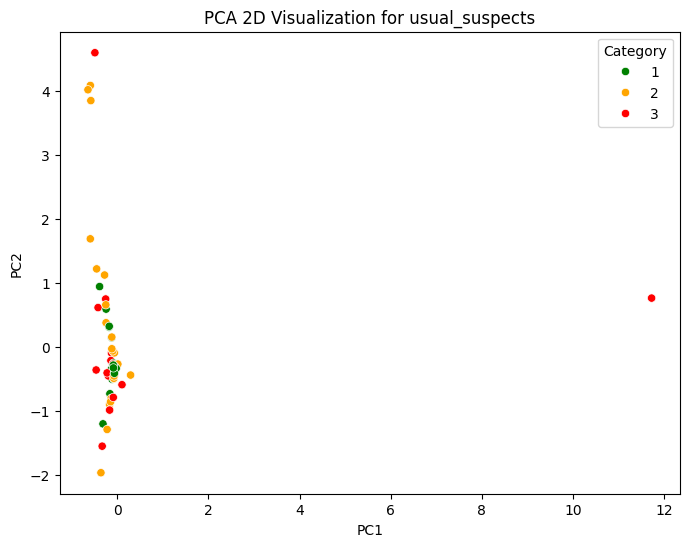

usual_suspects_pipeline:


,Features,Influence
7,265,2.3794
3,587,2.3719
4,656,2.1423
1,727,2.1194
5,214,2.0920
8,270,1.9920
2,332,1.9744
0,271,1.3318
9,264,0.9557
6,624,0.9557


In [155]:
# Aply pipeline for visual results
results_usual_suspects= pca_pipeline(usual_suspects, 'Category', n_components=2, dataset_name='usual_suspects')

# Apply the pipeline for numerical results
usual_suspects_pca_pipeline, df_pca_influence_usual_suspects, explained_variance_usual_suspects, n_components = apply_pipeline_pca(usual_suspects, "usual_suspects", n_components=2, n_top_features=None)

# Display the data side by side
display_side_by_side(df_pca_influence_usual_suspects.head(10), explained_variance_usual_suspects.head(10))

In [156]:
# Final selected genera taxonomic levels and abundance
core = original[['Category'] + [110, 572, 587, 143, 664, 270, 575, 491, 647, 245, 17, 671, 198, 238, 354, 591, 217, 674, 271,
                 449, 269, 731, 7, 13, 853, 687, 296, 550, 89, 344, 715, 146, 371, 214, 676, 130, 683, 484, 634,
                 304, 719, 867, 136, 229, 581, 267, 596, 660,113, 30, 177, 462, 705, 6, 29, 206, 863, 659, 589, 360]]

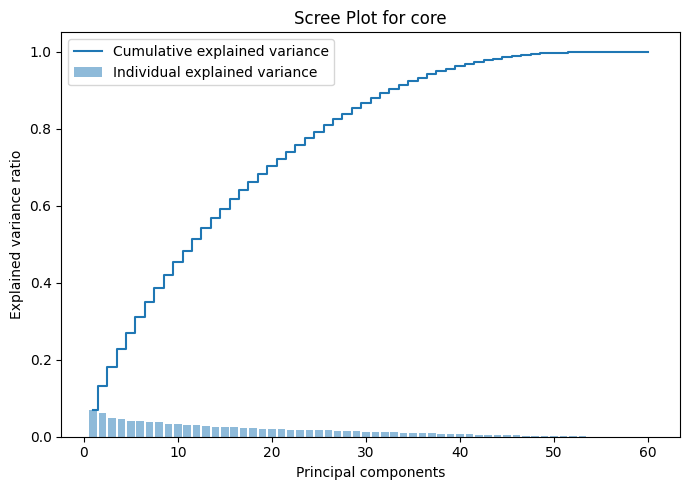

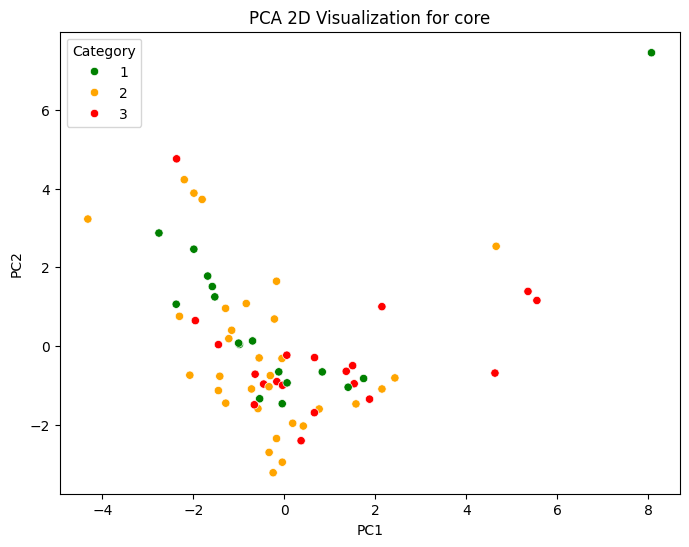

core_pipeline:


In [157]:
# Aply pipeline for visual results
results_core= pca_pipeline(core, 'Category', n_components=2, dataset_name='core')

# Apply the pipeline for numerical results
core_pca_pipeline, df_pca_influence_core, explained_variance_core, n_components = apply_pipeline_pca(core, "core", n_components=2, n_top_features=None)

# Display the data side by side
#display_side_by_side(df_pca_influence_core.head(10), explained_variance_core.head(10))

In [158]:
# Create dictionary of dataframes to analyze
dfs = {'checked':checked, 'usual_suspects': usual_suspects, 'core': core
}
# create single sheet excel file with all tables
create_feature_analysis_tables(dfs_dict=dfs,
                              # output_path = '/content/drive/My Drive/MIC/data',
                              output_path = '~/MIC/2_Micro/data',
                              output_filename= 'comparing_check_usual.xlsx', single_sheet=True)

In [159]:
convergence_checked = check_model_convergence(checked, checked_feature_scores, threshold=0.01)
convergence_checked

(True, 1)

Following saving is silence so that the further files dependency wont change if need to run an special part of the notebook.

In [160]:
# Save multiple dataframes to different sheets in the same Excel file
with pd.ExcelWriter(f'~/MIC/2_Micro/data/finalist_dfs.xlsx') as writer: # for colab /content/drive/My Drive/
    high_loadings_df.to_excel(writer, sheet_name='high_loadings', index=True)
    Influencers_uniques_df.to_excel(writer, sheet_name='Influencers_uniques', index=True)
    checked_genera.to_excel(writer, sheet_name='checked_genera')
    core_taxa.to_excel(writer, sheet_name= 'core_taxa')
    selected_new.to_excel(writer, sheet_name='selected')
    usuals.to_excel(writer, sheet_name= 'usual_genera')